# Analisis de datos - Bitacora de errores de parque solar - Entre Rios - Argentina

**Período analizado:** febrero – abril 2026


## Importacion de librerias

### Consideraciones
Los datos se leen desde la carpeta **data_raw** relativa al notebook.

Si corrés en Google Colab, subí los archivos manualmente o cloná el repo y montá tu Drive apuntando a la carpeta raíz del repositorio.

Si corrés localmente (Jupyter), no se requiere ninguna configuración adicional.

In [ ]:
import numpy as np
import pandas as pd
import requests
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import re
import os
import io
from google.colab import drive
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
from scipy import stats
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import matplotlib.colors as mcolors


drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Datos climaticos

### Diccionario de Codigos de Condicion (co_co)

In [ ]:
# Tabla de referencia de codigos de condicion climatica de Meteostat
# Se usa para mapear co_co a texto legible (columna condicion)
df_co_co = pd.read_csv('../data_raw/coco.csv')
df_co_co.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   co_co      27 non-null     int64 
 1   condicion  27 non-null     object
dtypes: int64(1), object(1)
memory usage: 564.0+ bytes


In [ ]:
df_co_co

,co_co,condicion
0,1,Clear
1,2,Fair
2,3,PartlyCloudy
3,4,Cloudy
4,5,Haze
5,6,Fog
6,7,LightRain
7,8,Rain
8,9,HeavyRain
9,10,LightFreezingRain


### Carga y preparacion del dataset climatico

In [ ]:
# Dataset climatico horario de Gualeguaychu descargado de Meteostat
# Periodo: febrero-abril 2026
# Columnas originales: time, temp, dwpt, rhum, prcp, wdir, wspd, wpgt, pres, co_co, condicion
df_clima = pd.read_csv('../data_raw/datos_clima_gualeguaychu.csv')

# Convierto time a datetime
df_clima['time'] = pd.to_datetime(df_clima['time'])

print(f'Registros cargados: {len(df_clima)}')
print(f'Periodo: {df_clima["time"].min()} -> {df_clima["time"].max()}')
df_clima.info()

Registros cargados: 1704
Periodo: 2026-02-19 00:00:00 -> 2026-04-30 23:00:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    1704 non-null   datetime64[ns]
 1   temp    1704 non-null   float64       
 2   dwpt    1704 non-null   float64       
 3   rhum    1704 non-null   int64         
 4   prcp    1704 non-null   float64       
 5   snow    0 non-null      float64       
 6   wdir    1704 non-null   int64         
 7   wspd    1704 non-null   float64       
 8   wpgt    3 non-null      float64       
 9   pres    1704 non-null   float64       
 10  tsun    0 non-null      float64       
 11  coco    1704 non-null   int64         
dtypes: datetime64[ns](1), float64(8), int64(3)
memory usage: 159.9 KB


### Horarios de salida y puesta del sol (referencia auxiliar)

In [ ]:
# Dataset de horarios de salida y puesta del sol para Gualeguaychu 2026
# Se usa solo como referencia. luz_diurna se recalcula por geometria solar
# para garantizar consistencia con ig_csn e ig_real
df_horarios_sol = pd.read_csv('../data_raw/horarios_sol_gualeguaychu_2026_transpuesto.csv')
df_horarios_sol.columns = df_horarios_sol.columns.str.lower()
df_horarios_sol['fecha'] = pd.to_datetime(df_horarios_sol['fecha'], format='%d/%m/%Y')
df_horarios_sol['salida'] = pd.to_datetime(df_horarios_sol['fecha'].dt.date.astype(str) + ' ' + df_horarios_sol['salida'].astype(str))
df_horarios_sol['puesta'] = pd.to_datetime(df_horarios_sol['fecha'].dt.date.astype(str) + ' ' + df_horarios_sol['puesta'].astype(str))
print(f'Horarios cargados: {len(df_horarios_sol)} dias')

Horarios cargados: 365 dias


In [ ]:
df_horarios_sol.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   fecha   365 non-null    datetime64[ns]
 1   salida  365 non-null    datetime64[ns]
 2   puesta  365 non-null    datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 8.7 KB


## Enriquecimiento del dataset climatico

Orden de ejecucion y dependencias:

1. **Irradiancia solar** (ig_csn, ig_real, luz_diurna) — geometria pura, sin dependencias
2. **Variables del panel** (wdir_sin/cos, temp_panel, factor_temp_panel) — depende de ig_real y wdir
3. **Predictores F23/F24** (condensacion, humedad acumulada) — depende de luz_diurna e ig_real
4. **Predictores F64** (temperatura minima, delta termica) — depende de luz_diurna
5. **Limpieza y verificacion final**

### 1. Irradiancia solar

#### Configuracion del lugar

Gualeguaychu, Entre Rios, Argentina
- Latitud: -33.0065 S
- Longitud: -58.4953 O
- Altitud: 17 msnm
- Huso horario: UTC-3 (meridiano de referencia -45)

In [ ]:
# Coordenadas y constantes del lugar
# LON_HUSO: meridiano de referencia del huso UTC-3
# La correccion (LON_DEG - LON_HUSO) / 15 convierte hora civil a hora solar
# Para Gualeguaychu: (-58.4953 - (-45)) / 15 = -0.90h -> mediodia solar a las 12:54hs
LAT_RAD  = np.radians(-33.0065)
LON_DEG  = -58.4953
ALT_M    = 17
LON_HUSO = -45.0

#### Factor de Turbidez de Linke (TL) mensual

Describe la opacidad atmosferica sin nubes (vapor de agua + aerosoles).
TL=2 es atmosfera seca y limpia. Valores tipicos para Entre Rios: 2.9-4.2.

Fuente: estimacion para la region basada en Grossi Gallegos & Spreafichi (2011)
y Raichijk (2011). Para mayor precision usar servicio SoDa:
http://www.soda-is.com (Lat=-33.0065, Lon=-58.4953)

In [ ]:
TL_MENSUAL = {
     1: 4.2,   # Enero    - verano, alta humedad
     2: 4.1,   # Febrero
     3: 3.8,   # Marzo
     4: 3.4,   # Abril
     5: 3.1,   # Mayo
     6: 2.9,   # Junio    - invierno, atmosfera mas seca
     7: 2.9,   # Julio
     8: 3.0,   # Agosto
     9: 3.3,   # Septiembre
    10: 3.6,   # Octubre
    11: 3.9,   # Noviembre
    12: 4.2,   # Diciembre
}

#### Factor kt por condicion climatica

kt = fraccion de irradiancia de cielo despejado que llega a la superficie.
Rango: 0 (sin radiacion) a 1 (cielo completamente despejado).
Basado en enfoque de Ortiz de Adler et al. (2010).

In [ ]:
df_clima = df_clima.rename(columns={'coco': 'co_co'})
df_clima = pd.merge(df_clima, df_co_co[['co_co', 'condicion']], on='co_co', how='left')

In [ ]:
KT_MAP = {
    'Clear':             0.97,   # Cielo despejado
    'Fair':              0.88,   # Despejado con nubes aisladas
    'PartlyCloudy':      0.62,   # Parcialmente nublado
    'Haze':              0.72,   # Neblina seca (aerosoles)
    'LightRain':         0.25,   # Lluvia ligera
    'LightRainShowers':  0.30,   # Chubascos ligeros
    'Rain':              0.15,   # Lluvia moderada
    'RainShowers':       0.20,   # Chubascos
    'HeavyRain':         0.08,   # Lluvia intensa
    'Thunderstorm':      0.05,   # Tormenta electrica
}

# Verifico que todos los valores del dataset esten cubiertos
sin_mapeo = set(df_clima['condicion'].unique()) - set(KT_MAP.keys())
if sin_mapeo:
    print(f'ATENCION - valores sin mapeo: {sin_mapeo}')
else:
    print('Todos los valores de condicion estan mapeados.')

Todos los valores de condicion estan mapeados.


#### Funciones de geometria solar

In [ ]:
def calcular_declinacion(nd):
    """Declinacion solar en radianes.
    nd: dia del año (1-365)
    Fuente: Ortiz de Adler et al. (2010), ecuacion (6)"""
    x = 2 * np.pi * nd / 365.25
    return np.arcsin(
        0.3978 * np.sin(x - 1.4 + 0.0355 * np.sin(x - 0.0489))
    )

def calcular_angulo_horario(hora_local, lon_deg):
    """Angulo horario en radianes a partir de hora local argentina.
    Corrige la diferencia entre longitud real (-58.4953) y meridiano
    del huso UTC-3 (-45): correccion = -0.90 horas (~54 minutos)
    Fuente: Ortiz de Adler et al. (2010), ecuacion (5)"""
    correccion = (lon_deg - LON_HUSO) / 15.0
    hora_solar = hora_local + correccion
    return 0.261799 * (hora_solar - 12.0)

def calcular_altura_solar(declinacion_rad, angulo_horario_rad, lat_rad):
    """Elevacion del sol sobre el horizonte en radianes.
    Resultado negativo = noche.
    Fuente: Ortiz de Adler et al. (2010), ecuacion (4)"""
    return np.arcsin(
        np.cos(lat_rad) * np.cos(declinacion_rad) * np.cos(angulo_horario_rad)
        + np.sin(lat_rad) * np.sin(declinacion_rad)
    )

#### Funciones de irradiancia

In [ ]:
# Umbral minimo de elevacion solar
# Por debajo de 5 grados el modelo numerico es inestable
# (denominador de masa optica se acerca a cero)
ALPHA_MIN_GRADOS = 5.0

def calcular_I0(nd):
    """Irradiancia en el tope de la atmosfera (W/m2).
    Corregida por excentricidad orbital.
    Fuente: Ortiz de Adler et al. (2010), ecuacion (3)"""
    return 1367.0 * (
        1 + 0.03344 * np.cos(2 * np.pi * nd / 365.25 - 0.048869)
    )

def calcular_masa_optica(alpha_rad, alt_m):
    """Masa optica de aire. Kasten & Young (1989).
    Clip minimo a 5 grados para evitar explosion numerica cerca del horizonte."""
    alpha_rad_safe = max(alpha_rad, np.radians(5.0))
    alpha_deg_safe = np.degrees(alpha_rad_safe)
    corr_pres      = np.exp(-alt_m / 8431.0)
    denominador    = (
        np.sin(alpha_rad_safe)
        + 0.50572 * (alpha_deg_safe + 6.07995) ** (-1.6364)
    )
    return corr_pres / denominador

def calcular_delta_rayleigh(m):
    """Espesor optico de Rayleigh. Kasten (1996)."""
    if m <= 20:
        return 1.0 / (
            6.6296 + 1.7513 * m - 0.1202 * m**2
            + 0.0065 * m**3 - 0.0013 * m**4
        )
    else:
        return 1.0 / (10.4 + 0.718 * m)

def calcular_irradiancia_csn(I0, alpha_rad, m, delta_R, TL):
    """Irradiancia global de cielo sin nubes (W/m2).
    Componente directa: modelo de Page (1986)
    Componente difusa: modelo de Dumortier (1995)
    Fuente: Ortiz de Adler et al. (2010), ecuaciones (1) y (2)"""
    sin_a  = np.sin(alpha_rad)
    sin2_a = sin_a ** 2
    Ib = I0 * sin_a * np.exp(-0.8662 * m * delta_R * TL)
    Id = I0 * (
        0.0065
        + (-0.045 + 0.0646 * TL) * sin_a
        + (-0.0014 + 0.0327 * TL) * sin2_a
    )
    Id = max(Id, 0.0)
    return min(Ib + Id, I0)

#### Calculo de irradiancia y luz_diurna

In [ ]:
def calcular_irradiancia_fila(row):
    """Aplica el modelo a una fila. Devuelve (ig_csn, ig_real) en W/m2.
    La columna time esta en hora local argentina (no UTC)."""
    nd         = row['time'].timetuple().tm_yday
    hora_local = row['time'].hour + row['time'].minute / 60.0
    mes        = row['time'].month
    condicion  = row['condicion']
    delta = calcular_declinacion(nd)
    omega = calcular_angulo_horario(hora_local, LON_DEG)
    alpha = calcular_altura_solar(delta, omega, LAT_RAD)
    if alpha <= np.radians(ALPHA_MIN_GRADOS):
        return 0.0, 0.0
    I0      = calcular_I0(nd)
    TL      = TL_MENSUAL[mes]
    m       = calcular_masa_optica(alpha, ALT_M)
    delta_R = calcular_delta_rayleigh(m)
    ig_csn  = calcular_irradiancia_csn(I0, alpha, m, delta_R, TL)
    kt      = KT_MAP[condicion]
    ig_real = kt * ig_csn
    return round(ig_csn, 2), round(ig_real, 2)

def hay_luz_diurna(row):
    """True cuando el sol supera ALPHA_MIN_GRADOS sobre el horizonte.
    Mismo criterio que calcular_irradiancia_fila para garantizar consistencia."""
    nd         = row['time'].timetuple().tm_yday
    hora_local = row['time'].hour + row['time'].minute / 60.0
    delta      = calcular_declinacion(nd)
    omega      = calcular_angulo_horario(hora_local, LON_DEG)
    alpha      = calcular_altura_solar(delta, omega, LAT_RAD)
    return alpha > np.radians(ALPHA_MIN_GRADOS)

print(f'Calculando irradiancia para {len(df_clima)} registros...')
resultados         = df_clima.apply(calcular_irradiancia_fila, axis=1)
df_clima['ig_csn']  = [r[0] for r in resultados]
df_clima['ig_real'] = [r[1] for r in resultados]

# luz_diurna recalculada por geometria solar
df_clima['luz_diurna'] = df_clima.apply(hay_luz_diurna, axis=1)

# Perdida porcentual de irradiancia por nubosidad
# 0 = cielo despejado, 1 = sin radiacion
df_clima['perdida_ig_csn'] = (
    (df_clima['ig_csn'] - df_clima['ig_real']) / df_clima['ig_csn']
).fillna(0).round(4)

# Columna fecha auxiliar para agrupaciones diarias
df_clima['fecha'] = df_clima['time'].dt.date

print('Irradiancia calculada.')
print(f'ig_csn max: {df_clima["ig_csn"].max():.1f} W/m2')
print(f'ig_real max: {df_clima["ig_real"].max():.1f} W/m2')
print(f'Registros con luz: {df_clima["luz_diurna"].sum()}')

Calculando irradiancia para 1704 registros...
Irradiancia calculada.
ig_csn max: 1278.4 W/m2
ig_real max: 1204.9 W/m2
Registros con luz: 781


#### Validacion del modelo de irradiancia

Se validan tres condiciones fisicas y se compara con referencia historica.
La referencia (kWh/m2/dia) son promedios de largo plazo que incluyen nubosidad.
Desvios de hasta 20% son aceptables. Desvios mayores pueden indicar
un año atipicamente soleado o la necesidad de ajustar TL_MENSUAL.

In [ ]:
# Validacion 1: irradiancia cero durante la noche
noche = df_clima[df_clima['luz_diurna'] == False]
assert (noche['ig_csn'] == 0).all(),  'ERROR: ig_csn no nulo de noche'
assert (noche['ig_real'] == 0).all(), 'ERROR: ig_real no nulo de noche'
print('Validacion 1 OK: irradiancia cero durante la noche')

# Validacion 2: ig_real nunca supera ig_csn (fisica basica)
assert (df_clima['ig_real'] <= df_clima['ig_csn']).all(), \
    'ERROR: ig_real supera ig_csn'
print('Validacion 2 OK: ig_real siempre <= ig_csn')

# Validacion 3: sin valores absurdos (maximo fisico ~1400 W/m2)
assert (df_clima['ig_csn'] <= 1500).all(), \
    'ERROR: ig_csn supera limite fisico'
print('Validacion 3 OK: sin valores absurdos')

# Validacion 4: comparacion con referencia historica
referencia = {
    1: 6.5, 2: 5.5, 3: 4.5,  4: 3.5,
    5: 2.5, 6: 2.0, 7: 2.0,  8: 3.0,
    9: 4.0, 10: 5.0, 11: 6.0, 12: 6.5
}
meses_nombre = {
    1:'Enero', 2:'Febrero', 3:'Marzo', 4:'Abril',
    5:'Mayo',  6:'Junio',   7:'Julio', 8:'Agosto',
    9:'Sept',  10:'Octubre', 11:'Noviembre', 12:'Diciembre'
}
dias_por_mes    = df_clima.groupby(df_clima['time'].dt.month)['fecha'].nunique()
suma_por_mes    = df_clima.groupby(df_clima['time'].dt.month)['ig_real'].sum() / 1000.0
promedio_diario = (suma_por_mes / dias_por_mes).round(2)

print()
print('Comparacion con referencia historica (kWh/m2/dia):')
print(f'{"Mes":<12} {"Calculado":>10} {"Referencia":>11} {"Desvio %":>9}  Nota')
print('-' * 60)
for mes, val_calc in promedio_diario.items():
    val_ref = referencia.get(mes)
    if val_ref:
        desvio = round((val_calc - val_ref) / val_ref * 100, 1)
        nota = 'dentro de rango' if abs(desvio) <= 20 else 'año atipico o revisar TL'
        print(f'{meses_nombre[mes]:<12} {val_calc:>10} {val_ref:>11} {desvio:>8}%  {nota}')

Validacion 1 OK: irradiancia cero durante la noche
Validacion 2 OK: ig_real siempre <= ig_csn
Validacion 3 OK: sin valores absurdos

Comparacion con referencia historica (kWh/m2/dia):
Mes           Calculado  Referencia  Desvio %  Nota
------------------------------------------------------------
Febrero             6.4         5.5     16.4%  dentro de rango
Marzo              5.88         4.5     30.7%  año atipico o revisar TL
Abril              4.02         3.5     14.9%  dentro de rango


### 2. Variables del panel

#### Direccion del viento (codificacion ciclica)

wdir en grados tiene el problema ciclico: 359 y 1 parecen muy distintos
pero son casi la misma direccion. Se convierte a componentes sin/cos.
wdir_cos < 0 indica componente sur (vientos del S, SE, SO = frios en la region).

In [ ]:
# Codificacion ciclica de direccion del viento
# wdir_sin > 0: componente este | wdir_sin < 0: componente oeste
# wdir_cos > 0: componente norte | wdir_cos < 0: componente sur (viento frio)
df_clima['wdir_sin'] = np.sin(np.radians(df_clima['wdir']))
df_clima['wdir_cos'] = np.cos(np.radians(df_clima['wdir']))

# wdir original ya no es necesario como feature (reemplazado por sin/cos)
# Se conserva en el dataset por trazabilidad
print('wdir_sin y wdir_cos calculados.')

wdir_sin y wdir_cos calculados.


#### Temperatura del panel y factor de eficiencia

Los paneles pierden eficiencia al calentarse: -0.4% por grado sobre 25C.
El viento enfria el panel por conveccion (efecto no lineal, se atenua a baja velocidad).
Modelo NOCT (Nominal Operating Cell Temperature), fuente: IEC 61215.

In [ ]:
NOCT      = 45.0    # temperatura nominal de operacion del panel (C)
COEF_TEMP = -0.004  # perdida de eficiencia por grado sobre 25C

# Factor de enfriamiento por viento
# wspd en km/h se convierte a m/s
# La relacion es no lineal: el enfriamiento se atenua con velocidad
# Sin viento: panel mas caliente que en condiciones de referencia
wspd_ms = df_clima['wspd'] / 3.6
factor_viento = np.where(
    wspd_ms > 0,
    1.0 / (1.0 + 0.5 * wspd_ms),
    1.2
)

# Temperatura estimada del panel
df_clima['temp_panel'] = (
    df_clima['temp']
    + (NOCT - 20.0) / 800.0 * df_clima['ig_real'] * factor_viento
)

# Factor de eficiencia por temperatura (clipeado entre 0.5 y 1.0)
# 1.0: panel a 25C o mas frio (eficiencia maxima)
# < 1.0: panel caliente (perdida de eficiencia)
df_clima['factor_temp_panel'] = (
    1 + COEF_TEMP * (df_clima['temp_panel'] - 25.0)
).clip(0.5, 1.0)

print('temp_panel y factor_temp_panel calculados.')
print(f'temp_panel media: {df_clima["temp_panel"].mean():.1f} C')
print(f'factor_temp_panel media: {df_clima["factor_temp_panel"].mean():.3f}')

temp_panel y factor_temp_panel calculados.
temp_panel media: 24.3 C
factor_temp_panel media: 0.988


### 3. Predictores F23/F24

**F23 - Fallo_OC_GFCI_Tz:** fuga de corriente DC hacia tierra por camino humedo.
Requiere corriente activa (ig_real > 0). Causa: agua liquida o saturacion.

**F24 - Fallo_Aislam_CC:** degradacion de aislamiento DC por humedad acumulada.
Puede ocurrir al arranque aunque ig_real sea bajo. Causa: exposicion prolongada.

Ambas fallas comparten el mismo mecanismo fisico (humedad en el lado DC)
y los mismos predictores base. Se agregan bajo el prefijo f2x.

**Columnas de diagnostico** (para analisis exploratorio, no entran al modelo):
- riesgo_condensacion, riesgo_saturacion_total, riesgo_extremo, riesgo_alto,
  riesgo_moderado, riesgo_seguro, f24_por_condensacion, f24_por_lluvia

**Predictores temporales** (entran al modelo):
- f2x_horas_riesgo_6h, f2x_prcp_acum_6h, f2x_rhum_min_6h, f2x_arranque_humedo

**Predictor especifico F23** (requiere ig_real, calculado despues de irradiancia):
- f23_generando_con_agua

In [ ]:
# =============================================================================
# RIESGO DE CONDENSACION - BASE PARA PREDICTORES F23/F24
# =============================================================================

# Variable continua base: diferencia entre temperatura y punto de rocio
# Cuanto mas cercano a 0, mayor probabilidad de condensacion
# Entra directamente como feature al modelo predictivo
df_clima['riesgo_condensacion'] = df_clima['temp'] - df_clima['dwpt']

# --- Categorias de riesgo ---
# Se conservan para analisis exploratorio y visualizaciones
# NO entran como features al modelo (redundantes con riesgo_condensacion)
# riesgo_saturacion_total tambien se usa como insumo para f2x_horas_riesgo_6h
df_clima['riesgo_saturacion_total'] = (df_clima['riesgo_condensacion'] == 0)
df_clima['riesgo_extremo']  = df_clima['riesgo_condensacion'].between(0.1, 0.8)
df_clima['riesgo_alto']     = df_clima['riesgo_condensacion'].between(0.9, 2.0)
df_clima['riesgo_moderado'] = df_clima['riesgo_condensacion'].between(2.1, 4.0)
df_clima['riesgo_seguro']   = df_clima['riesgo_condensacion'] > 4.0

# --- Diagnostico diferenciado de escenarios ---
# Se conservan para analisis exploratorio y visualizaciones
# NO entran como features al modelo (reemplazadas por predictores f2x
# que capturan la dimension temporal que estos no tienen)

# Escenario A: humedad ambiente sin lluvia durante horas de operacion
df_clima['f24_por_condensacion'] = (
    (df_clima['luz_diurna'] == True) &
    (df_clima['riesgo_condensacion'] <= 2.0) &
    (df_clima['prcp'] == 0)
)

# Escenario B: agua liquida durante horas de operacion
df_clima['f24_por_lluvia'] = (
    (df_clima['luz_diurna'] == True) &
    (df_clima['prcp'] > 0)
)

print('Distribucion de niveles de riesgo:')
print(f'  Saturacion total: {df_clima["riesgo_saturacion_total"].sum():>5} registros')
print(f'  Riesgo extremo:   {df_clima["riesgo_extremo"].sum():>5} registros')
print(f'  Riesgo alto:      {df_clima["riesgo_alto"].sum():>5} registros')
print(f'  Riesgo moderado:  {df_clima["riesgo_moderado"].sum():>5} registros')
print(f'  Seguro:           {df_clima["riesgo_seguro"].sum():>5} registros')
print()
print(f'Diagnostico operacional:')
print(f'  f24_por_condensacion True: {df_clima["f24_por_condensacion"].sum()}')
print(f'  f24_por_lluvia True:       {df_clima["f24_por_lluvia"].sum()}')

Distribucion de niveles de riesgo:
  Saturacion total:    78 registros
  Riesgo extremo:      93 registros
  Riesgo alto:        349 registros
  Riesgo moderado:    351 registros
  Seguro:             807 registros

Diagnostico operacional:
  f24_por_condensacion True: 95
  f24_por_lluvia True:       122


In [ ]:
# =============================================================================
# PREDICTORES TEMPORALES F23/F24
# Prefijo f2x: aplican a ambas fallas
# Capturan exposicion acumulada, no solo condicion instantanea
# =============================================================================

# Horas con riesgo de condensacion en las ultimas 6 horas
# Cuenta horas donde riesgo_condensacion <= 2.0
# Incluye saturacion total, riesgo extremo y riesgo alto
# Rango: 0 a 6
df_clima['f2x_horas_riesgo_6h'] = (
    (df_clima['riesgo_condensacion'] <= 2.0)
    .astype(int)
    .rolling(window=6, min_periods=1)
    .sum()
    .astype(int)
)

# Precipitacion acumulada en las ultimas 6 horas en mm
# Captura volumen de exposicion a agua liquida
# El aislamiento sigue comprometido horas despues de que para de llover
df_clima['f2x_prcp_acum_6h'] = (
    df_clima['prcp']
    .rolling(window=6, min_periods=1)
    .sum()
    .round(2)
)

# Humedad relativa minima de las ultimas 6 horas
# rhum_min_6h alto = componentes humedos sin chance de secarse
df_clima['f2x_rhum_min_6h'] = (
    df_clima['rhum']
    .rolling(window=6, min_periods=1)
    .min()
    .astype(int)
)

# Arranque del sistema tras noche humeda
# Momento de mayor riesgo: primera hora de operacion
# despues de exposicion nocturna a condensacion o lluvia
luz_int     = df_clima['luz_diurna'].astype(int)
primer_hora = (luz_int == 1) & (luz_int.shift(1) == 0)
noche_humeda = (
    (df_clima['f2x_horas_riesgo_6h'].shift(1) >= 3) |
    (df_clima['f2x_prcp_acum_6h'].shift(1)    >  2)
)
df_clima['f2x_arranque_humedo'] = (primer_hora & noche_humeda).astype(int)

# =============================================================================
# PREDICTOR ESPECIFICO F23
# F23 solo puede ocurrir cuando el sistema esta generando activamente
# (hay corriente DC fluyendo para que el GFCI detecte la fuga)
# A diferencia de F24 que puede disparar al arranque con ig_real minimo
# Tres escenarios: lluvia activa, lluvia reciente, saturacion total
# =============================================================================
df_clima['f23_generando_con_agua'] = (
    (df_clima['luz_diurna'] == True) &
    (df_clima['ig_real'] > 50) &
    (
        (df_clima['prcp'] > 0) |
        (df_clima['f2x_prcp_acum_6h'] > 2) |
        (df_clima['riesgo_saturacion_total'] == True)
    )
).astype(int)

print('Predictores temporales F23/F24:')
print()
print(f'  f2x_horas_riesgo_6h:')
print(f'    Media:              {df_clima["f2x_horas_riesgo_6h"].mean():.2f}h')
print(f'    Registros con >=3h: {(df_clima["f2x_horas_riesgo_6h"] >= 3).sum()}')
print(f'    Registros con 6h:   {(df_clima["f2x_horas_riesgo_6h"] == 6).sum()}')
print()
print(f'  f2x_prcp_acum_6h:')
print(f'    Maximo acumulado:   {df_clima["f2x_prcp_acum_6h"].max():.1f}mm')
print(f'    Registros con >5mm: {(df_clima["f2x_prcp_acum_6h"] > 5).sum()}')
print()
print(f'  f2x_rhum_min_6h:')
print(f'    Media:              {df_clima["f2x_rhum_min_6h"].mean():.1f}%')
print(f'    Registros >=90%:    {(df_clima["f2x_rhum_min_6h"] >= 90).sum()}')
print()
print(f'  f2x_arranque_humedo:')
print(f'    Arranques humedos:  {df_clima["f2x_arranque_humedo"].sum()}')
print(f'    Total arranques:    {primer_hora.sum()}')
print()
print(f'  f23_generando_con_agua:')
print(f'    Registros True:     {df_clima["f23_generando_con_agua"].sum()}')
print(f'    Desglose:')
print(f'      Lluvia activa:     {((df_clima["luz_diurna"]) & (df_clima["ig_real"] > 50) & (df_clima["prcp"] > 0)).sum()}')
print(f'      Lluvia reciente:   {((df_clima["luz_diurna"]) & (df_clima["ig_real"] > 50) & (df_clima["prcp"] == 0) & (df_clima["f2x_prcp_acum_6h"] > 2)).sum()}')
print(f'      Saturacion activa: {((df_clima["luz_diurna"]) & (df_clima["ig_real"] > 50) & (df_clima["prcp"] == 0) & (df_clima["riesgo_saturacion_total"])).sum()}')

Predictores temporales F23/F24:

  f2x_horas_riesgo_6h:
    Media:              1.89h
    Registros con >=3h: 586
    Registros con 6h:   237

  f2x_prcp_acum_6h:
    Maximo acumulado:   44.7mm
    Registros con >5mm: 110

  f2x_rhum_min_6h:
    Media:              67.2%
    Registros >=90%:    172

  f2x_arranque_humedo:
    Arranques humedos:  44
    Total arranques:    71

  f23_generando_con_agua:
    Registros True:     133
    Desglose:
      Lluvia activa:     92
      Lluvia reciente:   27
      Saturacion activa: 16


### 4. Predictores F64

**F64 - Fallo_BajaTemp_Disipador IGBT:**
El inversor detecta que el disipador del IGBT esta bajo la temperatura minima
de operacion segura. Causas: temperatura ambiente baja, viento frio del sur,
o sensor defectuoso.

Nota: el dataset cubre febrero-abril. F64 es mas probable en junio-agosto.
Estos predictores quedaran disponibles cuando se agreguen datos de invierno.

In [ ]:
# Temperatura minima de las ultimas 6 horas
# Captura el enfriamiento nocturno acumulado previo al arranque
df_clima['f64_temp_min_6h'] = (
    df_clima['temp']
    .rolling(window=6, min_periods=1)
    .min()
)

# Variacion de temperatura en las ultimas 3 horas
# Negativo = frente frio en curso
df_clima['f64_temp_delta_3h'] = df_clima['temp'].diff(periods=3).fillna(0)

# Temperatura minima nocturna del dia
# Representa la temperatura desde la cual arranca el sistema al amanecer
# Map directo por fecha para evitar problemas de tipos en merge
temp_min_diaria = (
    df_clima[df_clima['luz_diurna'] == False]
    .groupby(df_clima[df_clima['luz_diurna'] == False]['time'].dt.date)['temp']
    .min()
)
df_clima['f64_temp_min_nocturna'] = df_clima['time'].dt.date.map(temp_min_diaria)

print('Predictores F64 calculados:')
print(f'  f64_temp_min_6h media:       {df_clima["f64_temp_min_6h"].mean():.1f} C')
print(f'  f64_temp_delta_3h min:       {df_clima["f64_temp_delta_3h"].min():.1f} C')
print(f'  f64_temp_min_nocturna media: {df_clima["f64_temp_min_nocturna"].mean():.1f} C')
print(f'  Nulos en f64_temp_min_nocturna: {df_clima["f64_temp_min_nocturna"].isnull().sum()}')

Predictores F64 calculados:
  f64_temp_min_6h media:       19.1 C
  f64_temp_delta_3h min:       -10.0 C
  f64_temp_min_nocturna media: 16.1 C
  Nulos en f64_temp_min_nocturna: 0


### 5. Limpieza y verificacion final

In [ ]:
# Columnas a eliminar:
# - tsun y snow: no presentan valores
df_clima = df_clima.drop(columns=['tsun', 'snow'])


In [ ]:
# Se reemplazan los valores NAN de wpgt por 0
df_clima['wpgt'] = df_clima['wpgt'].fillna(0)

In [ ]:
# Columnas a eliminar:
# - hora_sin, hora_cos, mes_sin, mes_cos: redundantes con ig_csn
#   (ig_csn ya codifica la posicion solar de forma continua y fisica)
# - wdir: reemplazada por wdir_sin y wdir_cos
cols_eliminar = ['hora_sin', 'hora_cos', 'mes_sin', 'mes_cos']
cols_eliminar = [c for c in cols_eliminar if c in df_clima.columns]
if cols_eliminar:
    df_clima.drop(columns=cols_eliminar, inplace=True)
    print(f'Columnas eliminadas: {cols_eliminar}')

# Verificacion final de nulos
nulos = df_clima.isnull().sum()
nulos_existentes = nulos[nulos > 0]
if len(nulos_existentes) == 0:
    print('Sin valores nulos en el dataset.')
else:
    print(f'ATENCION - columnas con nulos:')
    print(nulos_existentes)

print()
print('=' * 50)
print('DATASET df_clima - ESTADO FINAL')
print('=' * 50)
print(f'Registros:  {len(df_clima)}')
print(f'Columnas:   {len(df_clima.columns)}')
print(f'Periodo:    {df_clima["time"].min()} -> {df_clima["time"].max()}')
print()
df_clima.info()

Sin valores nulos en el dataset.

DATASET df_clima - ESTADO FINAL
Registros:  1704
Columnas:   36
Periodo:    2026-02-19 00:00:00 -> 2026-04-30 23:00:00

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   time                     1704 non-null   datetime64[ns]
 1   temp                     1704 non-null   float64       
 2   dwpt                     1704 non-null   float64       
 3   rhum                     1704 non-null   int64         
 4   prcp                     1704 non-null   float64       
 5   wdir                     1704 non-null   int64         
 6   wspd                     1704 non-null   float64       
 7   wpgt                     1704 non-null   float64       
 8   pres                     1704 non-null   float64       
 9   co_co                    1704 non-null   int64         
 10  co

In [ ]:
df_clima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   time                     1704 non-null   datetime64[ns]
 1   temp                     1704 non-null   float64       
 2   dwpt                     1704 non-null   float64       
 3   rhum                     1704 non-null   int64         
 4   prcp                     1704 non-null   float64       
 5   wdir                     1704 non-null   int64         
 6   wspd                     1704 non-null   float64       
 7   wpgt                     1704 non-null   float64       
 8   pres                     1704 non-null   float64       
 9   co_co                    1704 non-null   int64         
 10  condicion                1704 non-null   object        
 11  ig_csn                   1704 non-null   float64       
 12  ig_real                  1704 non-

In [ ]:
df_clima.head()

,time,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,co_co,...,f24_por_condensacion,f24_por_lluvia,f2x_horas_riesgo_6h,f2x_prcp_acum_6h,f2x_rhum_min_6h,f2x_arranque_humedo,f23_generando_con_agua,f64_temp_min_6h,f64_temp_delta_3h,f64_temp_min_nocturna
0,2026-02-19 00:00:00,26.3,21.5,75,0.2,102,17.3,0.0,1009.1,17,...,False,False,0,0.2,75,0,0,26.3,0.0,22.6
1,2026-02-19 01:00:00,25.3,21.8,81,0.3,106,11.9,0.0,1008.6,8,...,False,False,0,0.5,75,0,0,25.3,0.0,22.6
2,2026-02-19 02:00:00,25.0,22.1,84,0.0,94,5.0,0.0,1008.2,3,...,False,False,0,0.5,75,0,0,25.0,0.0,22.6
3,2026-02-19 03:00:00,24.7,22.2,86,0.0,131,7.9,0.0,1008.1,3,...,False,False,0,0.5,75,0,0,24.7,-1.6,22.6
4,2026-02-19 04:00:00,23.9,22.2,90,0.5,11,13.0,0.0,1007.8,8,...,False,False,1,1.0,75,0,0,23.9,-1.4,22.6


In [ ]:
# Guardo dataset climatico completo


## Bitacora de alertas

In [ ]:
# Carga de bitacora de alertas
# Pestaña: Lista Alertas 30_04_26 (2)
df_bitacora_alertas = pd.read_excel(
    '..data_raw/Lista de alertas al 30_4_26.xlsx',
    sheet_name='Lista Alertas 30_04_26 (2)'
)

In [ ]:
# Limpieza y normalizacion de la bitacora

# Elimino columnas sin valor analitico
df_bitacora_alertas = df_bitacora_alertas.drop(columns=['Grado', 'Nombre del dispositivo'])

# Normalizo tipos
df_bitacora_alertas['SN'] = df_bitacora_alertas['SN'].astype(int)

# Convierto timestamps (formato original: 2026/04/29 23:46 UTC-03:00)
df_bitacora_alertas['Hora abierta'] = pd.to_datetime(
    df_bitacora_alertas['Hora abierta'], format='%Y/%m/%d %H:%M UTC-03:00'
)
df_bitacora_alertas['Hora cerrada'] = pd.to_datetime(
    df_bitacora_alertas['Hora cerrada'], format='%Y/%m/%d %H:%M UTC-03:00'
)

# Columna fecha al frente para facilitar agrupaciones
df_bitacora_alertas['fecha'] = df_bitacora_alertas['Hora abierta'].dt.date
df_bitacora_alertas = df_bitacora_alertas[['fecha'] + [col for col in df_bitacora_alertas.columns if col != 'fecha']]

# Limpio campo Inversor
df_bitacora_alertas['Inversor'] = df_bitacora_alertas['Inversor'].str.replace('´', '')

# Normalizo nombres de columnas
df_bitacora_alertas.columns = df_bitacora_alertas.columns.str.replace(' ', '_').str.lower()

# Referencia horaria redondeada a la hora para join con df_clima
# FutureWarning: usar 'h' en lugar de 'H'
df_bitacora_alertas['fecha_referencia_abierta'] = df_bitacora_alertas['hora_abierta'].dt.floor('h')
df_bitacora_alertas['fecha_referencia_cerrada'] = df_bitacora_alertas['hora_cerrada'].dt.floor('h')

# Duracion del evento en minutos
time_minutes = (
    df_bitacora_alertas['hora_cerrada'] - df_bitacora_alertas['hora_abierta']
).dt.total_seconds() / 60
df_bitacora_alertas['evento_minutos'] = pd.to_numeric(time_minutes, errors='coerce').fillna(0).astype(int)

print('Bitacora de alertas lista:')
df_bitacora_alertas.info()

Bitacora de alertas lista:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1191 entries, 0 to 1190
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   fecha                     1191 non-null   object        
 1   nombre_de_alerta          1191 non-null   object        
 2   estado                    1191 non-null   object        
 3   sn                        1191 non-null   int64         
 4   hora_abierta              1191 non-null   datetime64[ns]
 5   hora_cerrada              1190 non-null   datetime64[ns]
 6   inversor                  1191 non-null   object        
 7   fecha_referencia_abierta  1191 non-null   datetime64[ns]
 8   fecha_referencia_cerrada  1190 non-null   datetime64[ns]
 9   evento_minutos            1191 non-null   int64         
dtypes: datetime64[ns](4), int64(2), object(4)
memory usage: 93.2+ KB


#### Registros por estado (abierto o cerrado)

In [ ]:
# Ejecutá esto primero para entender cuántos hay y cuál es su situación
abiertos = df_bitacora_alertas[df_bitacora_alertas['estado'] == 'Abierto']

print(f"Registros Cerrado: {(df_bitacora_alertas['estado'] == 'Cerrado').sum()}")
print(f"Registros Abierto: {len(abiertos)}")
print()
print("Tipos de falla con estado Abierto:")
print(abiertos['nombre_de_alerta'].value_counts())
print()
print("Fechas de apertura de registros Abierto:")
print(abiertos[['fecha', 'nombre_de_alerta', 'inversor', 'hora_abierta', 'hora_cerrada']].to_string())

Registros Cerrado: 1190
Registros Abierto: 1

Tipos de falla con estado Abierto:
nombre_de_alerta
Fallo_NoHayUtilidad_CA F35    1
Name: count, dtype: int64

Fechas de apertura de registros Abierto:
          fecha            nombre_de_alerta inversor        hora_abierta hora_cerrada
355  2026-04-11  Fallo_NoHayUtilidad_CA F35       B4 2026-04-11 16:16:00          NaT


In [ ]:
print("Tratamiento registro Abierto:")
print("  Incluido en: análisis de contexto climático (hora_abierta válida)")
print("  Excluido de: análisis de duración (hora_cerrada = NaT)")
print("  evento_minutos asignado: 0")
print()

# Verifico que evento_minutos sea 0 para el registro abierto
registro_abierto = df_bitacora_alertas[df_bitacora_alertas['estado'] == 'Abierto']
print(registro_abierto[['fecha', 'nombre_de_alerta', 'hora_abierta',
                          'hora_cerrada', 'evento_minutos']])

Tratamiento registro Abierto:
  Incluido en: análisis de contexto climático (hora_abierta válida)
  Excluido de: análisis de duración (hora_cerrada = NaT)
  evento_minutos asignado: 0

          fecha            nombre_de_alerta        hora_abierta hora_cerrada  \
355  2026-04-11  Fallo_NoHayUtilidad_CA F35 2026-04-11 16:16:00          NaT   

     evento_minutos  
355               0  


In [ ]:
df_bitacora_alertas["estado"].unique()

array(['Cerrado', 'Abierto'], dtype=object)

#### Tipos de fallas

## Catalogo de fallas

| Codigo | Nombre | Descripcion |
|--------|--------|-------------|
| F20 | Fallo_SobreCorr_CC_Tz | Sobrecorriente en corriente continua por zona |
| F23 | Fallo_OC_GFCI_Tz | Falla a tierra en corriente continua (GFCI) |
| F24 | Fallo_Aislam_CC | Falla de aislamiento en CC |
| F26 | Fallo_DesequilBus | Desequilibrio en bus de continua |
| F30 | Fallo_ContactorPpal_CA | Falla en contactor principal de alterna |
| F35 | Fallo_NoHayUtilidad_CA | Sin tension de red en alterna |
| F41 | Fallo_SobreVolt_WU_CA | Sobretension en fase WU de alterna |
| F43 | Fallo_SobreVolt_VW_CA | Sobretension en fase VW de alterna |
| F45 | Fallo_SobreVolt_UV_CA | Sobretension en fase UV de alterna |
| F47 | Fallo_SobreFrec_CA | Sobrefrecuencia en alterna |
| F48 | Fallo_BajaFrec_CA | Bajafrecuencia en alterna |
| F64 | Fallo_BajaTemp_Disipador IGBT | Baja temperatura en disipador del IGBT |

In [ ]:
df_fallas_clima = df_bitacora_alertas.merge(
    df_clima,
    left_on='fecha_referencia_abierta',
    right_on='time',
    how='left',
    suffixes=('_alerta', '_clima')
)

print(f"Registros en bitácora:    {len(df_bitacora_alertas)}")
print(f"Registros después merge:  {len(df_fallas_clima)}")
print(f"Fallas sin match clima:   {df_fallas_clima['time'].isnull().sum()}")
print()

sin_match = df_fallas_clima[df_fallas_clima['time'].isnull()]
if len(sin_match) > 0:
    print("Fallas sin contexto climático:")
    print(sin_match[['fecha_alerta', 'nombre_de_alerta',
                      'fecha_referencia_abierta']].to_string())
else:
    print("Todas las fallas tienen contexto climático.")
print()

# Distribución de fallas por tipo
print("Ocurrencias por tipo de falla:")
print(df_fallas_clima['nombre_de_alerta'].value_counts().to_string())

Registros en bitácora:    1191
Registros después merge:  1191
Fallas sin match clima:   0

Todas las fallas tienen contexto climático.

Ocurrencias por tipo de falla:
nombre_de_alerta
Fallo_Aislam_CC F24                   355
Fallo_NoHayUtilidad_CA F35            200
Fallo_BajaFrec_CA F48                 149
Fallo_SobreVolt_WU_CA F41             127
Fallo_SobreFrec_CA F47                108
Fallo_SobreVolt_UV_CA F45              99
Fallo_SobreVolt_VW_CA F43              99
Fallo_DesequilBus F26                  33
Fallo_OC_GFCI_Tz F23                   14
Fallo_BajaTemp_Disispador IGBT F64      5
Fallo_ContactorPpal_CA F30              1
Fallo_SobreCorr_CC_Tz F20               1


| Código | Frecuencia | Porcentaje | Observaciones / Análisis |
| :--- | :--- | :--- | :--- |
| **F24** | 355 | 30% | Falla dominante, muestra suficiente para análisis robusto |
| **F35** | 200 | 17% | Falla de red externa, contexto climático indirecto |
| **F48** | 149 | 13% | Frecuencia, muestra buena |
| **F41** | 127 | 11% | Sobretensión, muestra buena |
| **F47** | 108 | 9% | Sobrefrecuencia, muestra buena |
| **F45** | 99 | 8% | Sobretensión, muestra buena |
| **F43** | 99 | 8% | Sobretensión, muestra buena |
| **F26** | 33 | 3% | Muestra pequeña, análisis orientativo |
| **F23** | 14 | 1% | Muestra muy pequeña, análisis descriptivo |
| **F64** | 5 | 0.4% | Insuficiente para análisis estadístico |
| **F30** | 1 | 0.08% | Caso único, no analizable |
| **F20** | 1 | 0.08% | Caso único, no analizable |

In [ ]:
# Verifico si F41, F43, F45 ocurren simultáneamente
# Si coinciden en la misma hora y mismo inversor son la misma causa

fases = df_fallas_clima[
    df_fallas_clima['nombre_de_alerta'].str.contains('F41|F43|F45')
].copy()

print("Distribución temporal F41/F43/F45:")
print(fases.groupby(['fecha_referencia_abierta', 'nombre_de_alerta'])
      .size().unstack(fill_value=0).head(20))
print()

# Verifico F47/F48 también
frecuencias = df_fallas_clima[
    df_fallas_clima['nombre_de_alerta'].str.contains('F47|F48')
].copy()

print("Distribución temporal F47/F48:")
print(frecuencias.groupby(['fecha_referencia_abierta', 'nombre_de_alerta'])
      .size().unstack(fill_value=0).head(20))

Distribución temporal F41/F43/F45:
nombre_de_alerta          Fallo_SobreVolt_UV_CA F45  \
fecha_referencia_abierta                              
2026-02-22 14:00:00                               1   
2026-02-25 16:00:00                               5   
2026-02-26 15:00:00                               3   
2026-02-27 14:00:00                              14   
2026-03-04 14:00:00                              12   
2026-03-10 08:00:00                              14   
2026-04-02 17:00:00                               0   
2026-04-03 16:00:00                               0   
2026-04-03 17:00:00                               0   
2026-04-04 10:00:00                               0   
2026-04-04 14:00:00                               0   
2026-04-04 16:00:00                               0   
2026-04-05 13:00:00                               0   
2026-04-05 14:00:00                               0   
2026-04-06 09:00:00                               0   
2026-04-06 10:00:00           

#### Ocurrencia F47/F48

In [ ]:
# Confirmar que F47/F48 se concentran al amanecer
freq_hora = df_fallas_clima[
    df_fallas_clima['nombre_de_alerta'].str.contains('F47|F48')
].copy()

print("Distribucion por hora del dia - F47/F48:")
print(freq_hora['fecha_referencia_abierta'].dt.hour.value_counts().sort_index())
print()

# Ver el contexto climatico de esas horas
cols_contexto = ['fecha_referencia_abierta', 'nombre_de_alerta',
                 'inversor', 'ig_real', 'ig_csn', 'luz_diurna', 'temp']
print("Muestra de eventos F47/F48:")
print(freq_hora[cols_contexto].head(20).to_string())

Distribucion por hora del dia - F47/F48:
fecha_referencia_abierta
6     183
7      60
8       1
13      2
16      1
19      3
20      2
21      3
23      2
Name: count, dtype: int64

Muestra de eventos F47/F48:
    fecha_referencia_abierta        nombre_de_alerta inversor  ig_real  ig_csn  luz_diurna  temp
0        2026-04-29 23:00:00   Fallo_BajaFrec_CA F48       B4     0.00    0.00       False  12.0
1        2026-04-29 23:00:00   Fallo_BajaFrec_CA F48       C4     0.00    0.00       False  12.0
2        2026-04-29 21:00:00   Fallo_BajaFrec_CA F48       B4     0.00    0.00       False  14.0
3        2026-04-29 21:00:00   Fallo_BajaFrec_CA F48       C4     0.00    0.00       False  14.0
4        2026-04-29 21:00:00   Fallo_BajaFrec_CA F48       B4     0.00    0.00       False  14.0
5        2026-04-29 20:00:00   Fallo_BajaFrec_CA F48       C4     0.00    0.00       False  16.0
6        2026-04-29 20:00:00   Fallo_BajaFrec_CA F48       C4     0.00    0.00       False  16.0
7        2026

##### Diagnóstico F47/F48
| Rango Horario / Contexto | Casos | Porcentaje | Estado de Generación Solar |
| :--- | :---: | :---: | :--- |
| **06:00 hs (Noche)** | 183 | 71% | Sin generación solar |
| **07:00 hs (Amanecer)** | 60 | 23% | `ig_real` muy bajo o cero |
| **08:00 hs** | 1 | 0.4% | Generando levemente |
| **Horas dispersas (19, 20, 21, 23 hs)** | 13 | 5% | Nocturno / Sin generación |
| **Total Analizado** | **257** | **100%** | |

Posible conclusion: F47/F48 es un problema de sincronización del inversor con la frecuencia de la red al momento de arranque o apagado, no tiene causa climática directa. El análisis climático no va a aportar valor predictivo para esta falla.

## **Analisis de fallas**

### Analisis por Inversores y Grupos

##### Resumen por tipo de falla

In [ ]:
# Calculo tiempo total de afectación por tipo de falla
# considerando horas únicas y duración promedio

resumen_fallas = (
    df_fallas_clima
    .groupby('nombre_de_alerta')
    .agg(
        eventos          = ('nombre_de_alerta', 'count'),
        horas_unicas     = ('fecha_referencia_abierta', 'nunique'),
        duracion_prom_min= ('evento_minutos', 'mean'),
        duracion_total_h = ('evento_minutos', lambda x: x.sum() / 60)
    )
    .reset_index()
)

resumen_fallas['eventos_por_hora'] = (
    resumen_fallas['eventos'] / resumen_fallas['horas_unicas']
).round(1)

resumen_fallas = resumen_fallas.sort_values('duracion_total_h', ascending=False)

print("Resumen por tipo de falla - tiempo real de afectación:")
print()
print(f"{'Falla':<35} {'Eventos':>7} {'Hs únicas':>10} {'Ev/hora':>8} "
      f"{'Dur prom(min)':>14} {'Total hs':>9}")
print("-" * 90)
for _, row in resumen_fallas.iterrows():
    nombre = row['nombre_de_alerta'].replace('Fallo_', '').replace('_CA', '').replace('_CC', '')
    print(f"{nombre:<35} {row['eventos']:>7.0f} {row['horas_unicas']:>10.0f} "
          f"{row['eventos_por_hora']:>8.1f} {row['duracion_prom_min']:>14.1f} "
          f"{row['duracion_total_h']:>9.1f}")

Resumen por tipo de falla - tiempo real de afectación:

Falla                               Eventos  Hs únicas  Ev/hora  Dur prom(min)  Total hs
------------------------------------------------------------------------------------------
NoHayUtilidad F35                       200         34      5.9          349.0    1163.3
Aislam F24                              355         71      5.0           82.8     490.0
SobreVolt_WU F41                        127         32      4.0           81.3     172.2
SobreVolt_UV F45                         99         14      7.1           97.2     160.4
SobreVolt_VW F43                         99         14      7.1           97.2     160.4
BajaFrec F48                            149         68      2.2           30.5      75.7
SobreFrec F47                           108         58      1.9           25.6      46.1
DesequilBus F26                          33          5      6.6           21.2      11.7
OC_GFCI_Tz F23                           14         

##### Agrupacion por tipo de fallo

In [ ]:
# 1. Definimos las condiciones basadas en los códigos de error (Fxx)
# Usamos el nombre exacto de tu columna: 'nombre_de_alerta'
condiciones = [
    resumen_fallas['nombre_de_alerta'].str.contains('F24|F23', case=False),  # Aislamiento y fugas
    resumen_fallas['nombre_de_alerta'].str.contains('F35|F41|F45|F43|F48|F47', case=False), # Red (Grid)
    resumen_fallas['nombre_de_alerta'].str.contains('F26|F64|F30|F20', case=False)  # Hardware/Interno
]

# 2. Definimos los nombres de los grupos
nombres_grupos = ['aislamiento', 'red', 'hardware']

# 3. Creamos la columna grupo_falla
resumen_fallas['grupo_falla'] = np.select(condiciones, nombres_grupos, default='otro')

# 4. Verificación rápida del impacto por grupo
resumen_por_grupo = resumen_fallas.groupby('grupo_falla').agg({
    'nombre_de_alerta': 'count',
    'duracion_total_h': 'sum',
    'eventos': 'sum'
}).sort_values(by='duracion_total_h', ascending=False)

print(resumen_por_grupo)

             nombre_de_alerta  duracion_total_h  eventos
grupo_falla                                             
red                         6       1777.983333      782
aislamiento                 2        496.116667      369
hardware                    4         15.516667       40


##### A2, B2, D3

/tmp/ipykernel_27973/3081529643.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


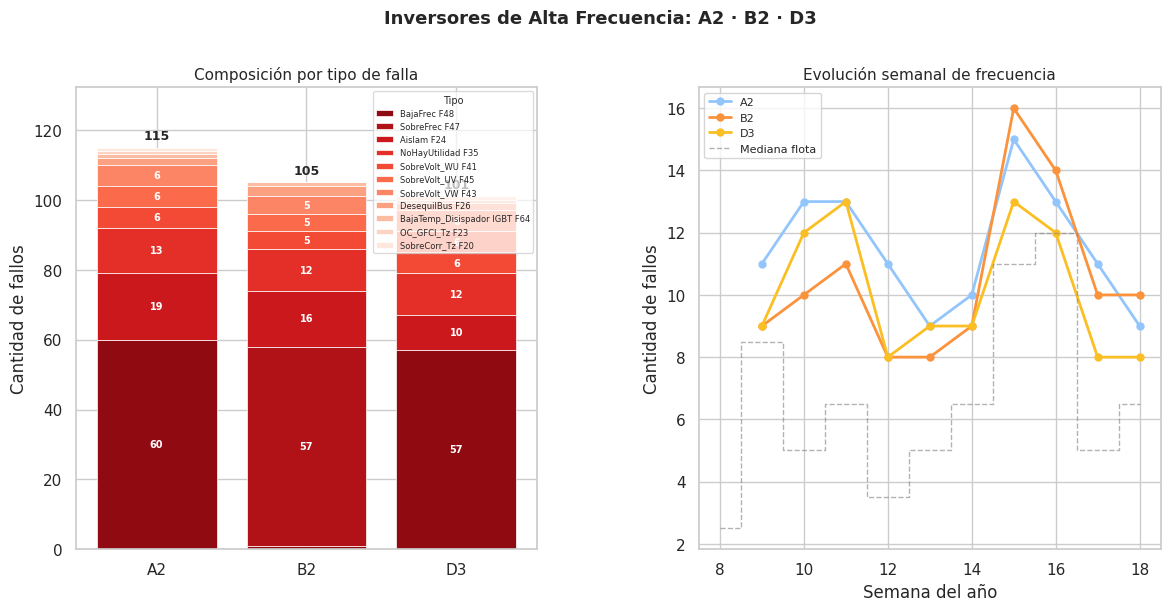

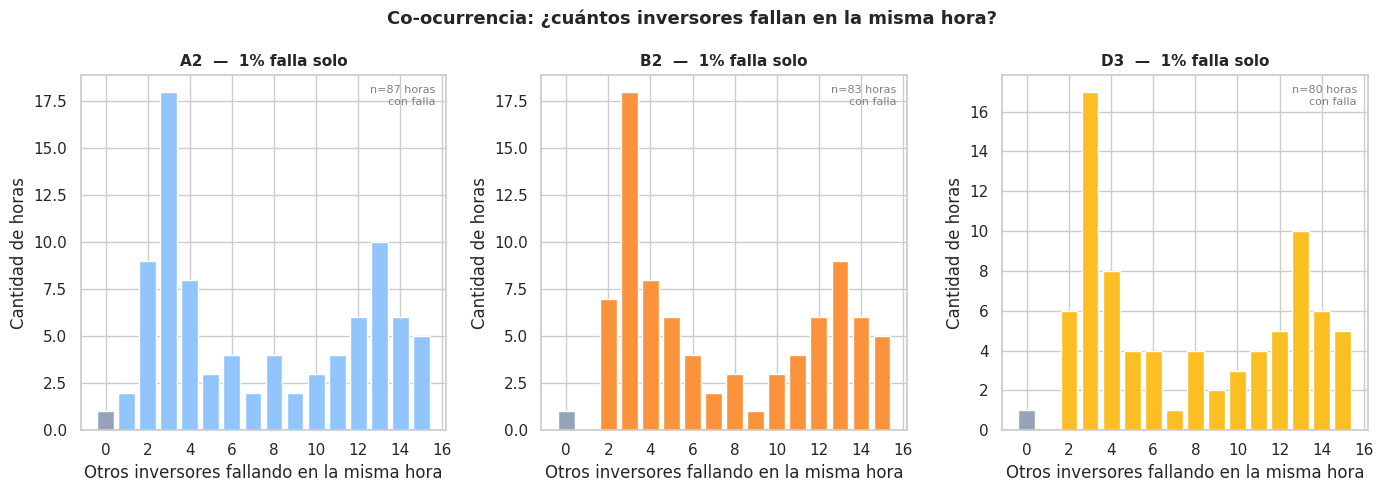


RESUMEN NUMÉRICO — A2, B2, D3

A2:
  Total fallas:      115
  Duración mediana:  27 min
  Duración promedio: 55 min
  Falla más común:   Fallo_BajaFrec_CA F48
  % falla principal: 52.2%

B2:
  Total fallas:      105
  Duración mediana:  22 min
  Duración promedio: 84 min
  Falla más común:   Fallo_SobreFrec_CA F47
  % falla principal: 54.3%

D3:
  Total fallas:      101
  Duración mediana:  19 min
  Duración promedio: 71 min
  Falla más común:   Fallo_BajaFrec_CA F48
  % falla principal: 56.4%


In [ ]:
# Análisis de inversores de alta frecuencia / baja duración: A2, B2, D3

# ─────────────────────────────────────────────
# CONFIGURACIÓN GLOBAL
# ─────────────────────────────────────────────
sns.set_theme(style="whitegrid")

INVERSORES_FREC = ['A2', 'B2', 'D3']
COLORES_INV = {'A2': '#93c5fd', 'B2': '#fb923c', 'D3': '#fbbf24'}  # azul claro, naranja, amarillo (paleta grupos)

COLORES_FALLA = {
    'red':         '#7f1d1d',
    'aislamiento': '#b91c1c',
    'hardware':    '#fca5a5'
}

# Filtro inversores de interés
df_plot = df_fallas_clima[df_fallas_clima['inversor'].isin(INVERSORES_FREC)].copy()
df_plot['semana'] = df_plot['hora_abierta'].dt.isocalendar().week
df_plot['hora_dia'] = df_plot['hora_abierta'].dt.hour


# ─────────────────────────────────────────────
# FIGURA 1: COMPOSICIÓN DE FALLAS + EVOLUCIÓN SEMANAL
# ─────────────────────────────────────────────

fig = plt.figure(figsize=(14, 6))
fig.suptitle('Inversores de Alta Frecuencia: A2 · B2 · D3', fontsize=13, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# --- SUBPLOT 1: Composición de fallas por tipo ---
ax1 = fig.add_subplot(gs[0])

comp = (
    df_plot.groupby(['inversor', 'nombre_de_alerta'])
    .size()
    .reset_index(name='n')
)
# Calculo proporción dentro de cada inversor
comp['total'] = comp.groupby('inversor')['n'].transform('sum')
comp['prop'] = comp['n'] / comp['total']

# Pivot para graficar barras apiladas
pivot_comp = comp.pivot_table(index='inversor', columns='nombre_de_alerta', values='n', fill_value=0)
pivot_comp = pivot_comp.reindex(INVERSORES_FREC)

# Ordeno columnas por frecuencia total descendente
orden_cols = pivot_comp.sum().sort_values(ascending=False).index
pivot_comp = pivot_comp[orden_cols]

# Paleta: usar colores distintos por tipo de falla
n_tipos = len(pivot_comp.columns)
palette = sns.color_palette("Reds_r", n_tipos)
col_colors = {col: palette[i] for i, col in enumerate(pivot_comp.columns)}

bottom = np.zeros(len(INVERSORES_FREC))
x = np.arange(len(INVERSORES_FREC))
for col in pivot_comp.columns:
    vals = pivot_comp[col].values
    bars = ax1.bar(x, vals, bottom=bottom,
                   color=col_colors[col],
                   label=col.replace('Fallo_', '').replace('_CA', '').replace('_CC', ''),
                   edgecolor='white', linewidth=0.5)
    # Anotar si la porción es visible
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v > 3:
            ax1.text(x[j], b + v/2, str(int(v)), ha='center', va='center',
                     fontsize=7, color='white', fontweight='bold')
    bottom += vals

# Anotar total encima de cada barra
for j, inv in enumerate(INVERSORES_FREC):
    total = pivot_comp.loc[inv].sum()
    ax1.text(x[j], total + 1.5, f'{int(total)}', ha='center', va='bottom',
             fontsize=9, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(INVERSORES_FREC, fontsize=11)
ax1.set_ylabel('Cantidad de fallos')
ax1.set_title('Composición por tipo de falla', fontsize=11)
ax1.legend(loc='upper right', fontsize=6, framealpha=0.7,
           title='Tipo', title_fontsize=7)
ax1.set_ylim(0, pivot_comp.sum(axis=1).max() * 1.15)


# --- SUBPLOT 2: Evolución semanal de frecuencia ---
ax2 = fig.add_subplot(gs[1])

semanal = (
    df_plot.groupby(['semana', 'inversor'])
    .size()
    .reset_index(name='n_fallas')
)

for inv in INVERSORES_FREC:
    data_inv = semanal[semanal['inversor'] == inv].sort_values('semana')
    ax2.plot(data_inv['semana'], data_inv['n_fallas'],
             marker='o', linewidth=2, label=inv,
             color=COLORES_INV[inv], markersize=5)

# Referencia: mediana semanal de la flota completa
flota_semanal = (
    df_fallas_clima.groupby(['semana' if 'semana' in df_fallas_clima.columns
                              else df_fallas_clima['hora_abierta'].dt.isocalendar().week.rename('semana'),
                              'inversor'])
    .size()
    .reset_index(name='n')
)
# Calculo semana para flota
df_fallas_clima['semana_tmp'] = df_fallas_clima['hora_abierta'].dt.isocalendar().week
flota_sem = df_fallas_clima.groupby(['semana_tmp', 'inversor']).size().reset_index(name='n')
mediana_sem = flota_sem.groupby('semana_tmp')['n'].median()
ax2.step(mediana_sem.index, mediana_sem.values,
         linestyle='--', color='gray', linewidth=1, alpha=0.6, label='Mediana flota', where='mid')

ax2.set_xlabel('Semana del año')
ax2.set_ylabel('Cantidad de fallos')
ax2.set_title('Evolución semanal de frecuencia', fontsize=11)
ax2.legend(fontsize=8)
ax2.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# FIGURA 2: CO-OCURRENCIA — ¿Fallan solos o en conjunto?
# ─────────────────────────────────────────────

fig2, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
fig2.suptitle('Co-ocurrencia: ¿cuántos inversores fallan en la misma hora?', fontsize=13, fontweight='bold')

for ax, inv in zip(axes, INVERSORES_FREC):
    # Horas en que este inversor tuvo fallas
    horas_inv = df_fallas_clima[df_fallas_clima['inversor'] == inv]['fecha_referencia_abierta'].unique()

    # Para cada hora, contar cuántos otros inversores también fallaron
    conteos = []
    for h in horas_inv:
        n_otros = df_fallas_clima[
            (df_fallas_clima['fecha_referencia_abierta'] == h) &
            (df_fallas_clima['inversor'] != inv)
        ]['inversor'].nunique()
        conteos.append(n_otros)

    conteos = pd.Series(conteos)
    solo = (conteos == 0).sum()
    acompanado = (conteos > 0).sum()
    pct_solo = solo / len(conteos) * 100

    # Distribución de co-ocurrencia
    dist = conteos.value_counts().sort_index()
    colores_bar = ['#94a3b8' if i == 0 else COLORES_INV[inv] for i in dist.index]
    ax.bar(dist.index, dist.values, color=colores_bar, edgecolor='white')
    ax.set_title(f'{inv}  —  {pct_solo:.0f}% falla solo', fontsize=11, fontweight='bold')
    ax.set_xlabel('Otros inversores fallando en la misma hora')
    ax.set_ylabel('Cantidad de horas')
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    # Anotación
    ax.text(0.97, 0.97, f'n={len(conteos)} horas\ncon falla',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='gray')

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# PRINT: Resumen numérico para el texto de la slide
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("RESUMEN NUMÉRICO — A2, B2, D3")
print("="*55)

for inv in INVERSORES_FREC:
    df_inv = df_fallas_clima[df_fallas_clima['inversor'] == inv]
    print(f"\n{inv}:")
    print(f"  Total fallas:      {len(df_inv)}")
    print(f"  Duración mediana:  {df_inv['evento_minutos'].median():.0f} min")
    print(f"  Duración promedio: {df_inv['evento_minutos'].mean():.0f} min")
    print(f"  Falla más común:   {df_inv['nombre_de_alerta'].value_counts().index[0]}")
    print(f"  % falla principal: {df_inv['nombre_de_alerta'].value_counts().iloc[0]/len(df_inv)*100:.1f}%")


###### Composicion de las fallas

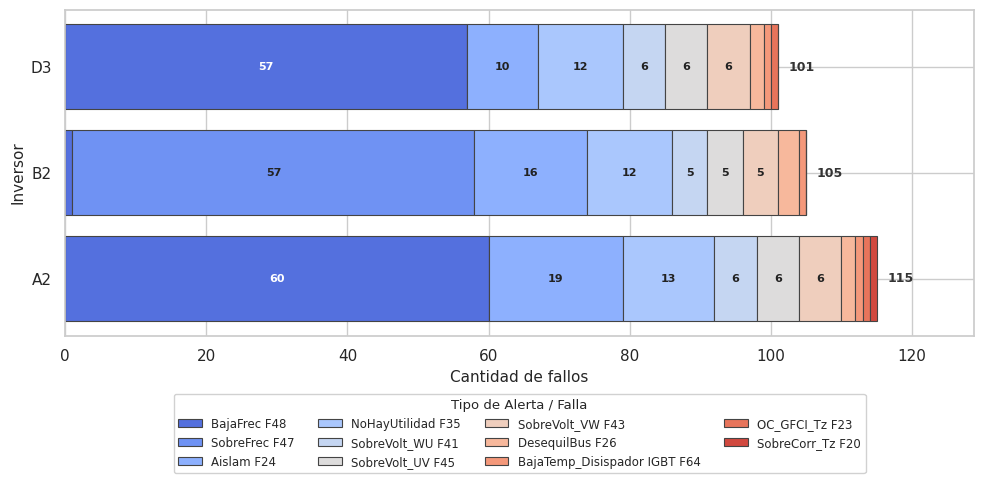

In [ ]:
# ───────────────────────────────
# GRÁFICA: COMPOSICIÓN DE FALLAS
# ───────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))
fig.subplots_adjust(bottom=0.22)

# 1. Procesamiento de datos
comp = (
    df_plot.groupby(['inversor', 'nombre_de_alerta'])
    .size()
    .reset_index(name='n')
)

comp['total'] = comp.groupby('inversor')['n'].transform('sum')
comp['prop'] = comp['n'] / comp['total']

pivot_comp = comp.pivot_table(index='inversor', columns='nombre_de_alerta', values='n', fill_value=0)
pivot_comp = pivot_comp.reindex(INVERSORES_FREC)

orden_cols = pivot_comp.sum().sort_values(ascending=False).index
pivot_comp = pivot_comp[orden_cols]

# 2. Configuración de Paleta Divergente (Coolwarm: transiciona de azul a rojo pasando por tonos claros)
n_tipos = len(pivot_comp.columns)
palette = sns.color_palette("coolwarm", n_tipos)
col_colors = {col: palette[i] for i, col in enumerate(pivot_comp.columns)}

# Inicializamos acumuladores
left = np.zeros(len(INVERSORES_FREC))
y = np.arange(len(INVERSORES_FREC))

# 3. Dibujo de barras apiladas con bordes definidos y texto adaptativo
for idx, col in enumerate(pivot_comp.columns):
    vals = pivot_comp[col].values

    # Dibujamos las barras agregando un borde gris oscuro para delimitar secciones limpiamente
    bars = ax.barh(y, vals, left=left,
                   color=col_colors[col],
                   label=col.replace('Fallo_', '').replace('_CA', '').replace('_CC', ''),
                   edgecolor='#444444', linewidth=0.8) # Borde definido contra empastamiento

    # Anotar segmentos internos con lógica adaptativa
    for j, (v, l) in enumerate(zip(vals, left)):
        if v > 3:
            # LÓGICA ADAPTATIVA: Si el color está en los extremos de la paleta divergente es oscuro (texto blanco).
            # Si está en el medio, el fondo es claro/grisáceo (texto negro).
            if idx == 0 or idx == (n_tipos - 1):
                color_texto = 'white'
            else:
                color_texto = '#222222' # Negro suave de alta legibilidad

            ax.text(l + v/2, y[j], str(int(v)), ha='center', va='center',
                    fontsize=8, color=color_texto, fontweight='bold')
    left += vals

# 4. Anotar totales generales a la derecha de la barra
for j, inv in enumerate(INVERSORES_FREC):
    total = pivot_comp.loc[inv].sum()
    ax.text(total + 1.5, y[j], f'{int(total)}', ha='left', va='center',
            fontsize=9, fontweight='bold', color='#333333')

# 5. Ajustes estéticos y de ejes
ax.set_yticks(y)
ax.set_yticklabels(INVERSORES_FREC, fontsize=11)
ax.set_ylabel('Inversor', fontsize=11)
ax.set_xlabel('Cantidad de fallos', fontsize=11)
ax.set_xlim(0, pivot_comp.sum(axis=1).max() * 1.12)

# Cuadrícula de guía sutil
#ax.grid(axis='x', alpha=0.25, linestyle=':', zorder=1)
ax.set_axisbelow(True)

# ── Leyenda  ──
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.16),
    ncol=4,
    fontsize=8.5,
    title='Tipo de Alerta / Falla',
    title_fontsize=9.5,
    frameon=True,
    framealpha=0.9
)

plt.tight_layout()
plt.show()

###### Evolucion semanal

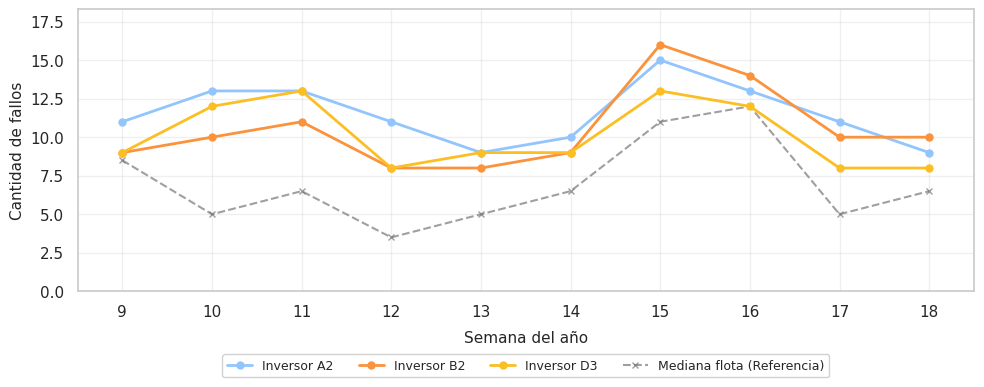

In [ ]:
# ────────────────────────────────────────
# EVOLUCIÓN SEMANAL (SINCRONIZADA Y RECTA)
# ────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 4))
fig.subplots_adjust(bottom=0.22)

# 1. Agrupamiento y procesamiento de datos por inversor
semanal = (
    df_plot.groupby(['semana', 'inversor'])
    .size()
    .reset_index(name='n_fallas')
)

# Guardamos el rango exacto de semanas que abarcan tus inversores de alta frecuencia
semanas_activas = semanal['semana'].unique()

# Graficamos las líneas temporales para cada inversor
for inv in INVERSORES_FREC:
    data_inv = semanal[semanal['inversor'] == inv].sort_values('semana')
    ax.plot(data_inv['semana'], data_inv['n_fallas'],
            marker='o', linewidth=2, label=f'Inversor {inv}',
            color=COLORES_INV[inv], markersize=5, zorder=3)

# 2. Cálculo de la Mediana Semanal filtrada por el rango de semanas activas
df_fallas_clima['semana_tmp'] = df_fallas_clima['hora_abierta'].dt.isocalendar().week
flota_sem = df_fallas_clima.groupby(['semana_tmp', 'inversor']).size().reset_index(name='n')
mediana_sem = flota_sem.groupby('semana_tmp')['n'].median()

# CORRECCIÓN 1: Filtrar la flota para que arranque y termine junto con los inversores
mediana_sem_filtrada = mediana_sem[mediana_sem.index.isin(semanas_activas)]

# CORRECCIÓN 2: Cambiar 'step' por 'plot' para unir con líneas rectas y agregar marcador sutil
ax.plot(mediana_sem_filtrada.index, mediana_sem_filtrada.values,
        label='Mediana flota (Referencia)', color='#777777',
        linestyle='--', linewidth=1.5, marker='x', markersize=4, alpha=0.7, zorder=2)

# 3. Configuración estética y de ejes
ax.set_xlabel('Semana del año', fontsize=11, labelpad=8)
ax.set_ylabel('Cantidad de fallos', fontsize=11)
#ax.set_title('Inversores de Alta Frecuencia: Evolución semanal de frecuencia',
#             fontsize=12, fontweight='bold', pad=15)

# Forzar el eje X a las semanas reales del análisis
ax.set_xlim(min(semanas_activas) - 0.5, max(semanas_activas) + 0.5)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax.grid(axis='both', alpha=0.3, zorder=1)
ax.set_axisbelow(True)
ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

# ── Leyenda ──
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.2),
    ncol=4,
    fontsize=9,
    frameon=True,
    framealpha=0.9
)

plt.tight_layout()
plt.show()


###### Co-ocurrencia

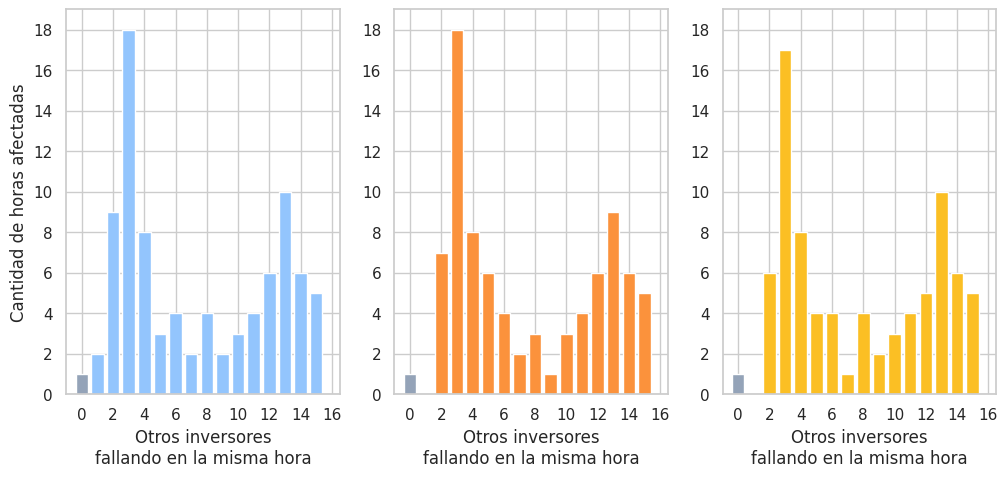

In [ ]:
# ─────────────
# CO-OCURRENCIA
# ─────────────

fig2, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=False)


imprime=True
for ax, inv in zip(axes, INVERSORES_FREC):
    # Horas en que este inversor tuvo fallas
    horas_inv = df_fallas_clima[df_fallas_clima['inversor'] == inv]['fecha_referencia_abierta'].unique()

    # Para cada hora, contar cuántos otros inversores también fallaron
    conteos = []
    for h in horas_inv:
        n_otros = df_fallas_clima[
            (df_fallas_clima['fecha_referencia_abierta'] == h) &
            (df_fallas_clima['inversor'] != inv)
        ]['inversor'].nunique()
        conteos.append(n_otros)

    conteos = pd.Series(conteos)
    solo = (conteos == 0).sum()
    acompanado = (conteos > 0).sum()
    pct_solo = solo / len(conteos) * 100

    # Distribución de co-ocurrencia
    dist = conteos.value_counts().sort_index()
    colores_bar = ['#94a3b8' if i == 0 else COLORES_INV[inv] for i in dist.index]
    ax.bar(dist.index, dist.values, color=colores_bar, edgecolor='white')
    #ax.set_title(f'{inv}  —  Fallos en solitario {pct_solo:.2f}% ', fontsize=11, fontweight='bold')
    ax.set_xlabel('Otros inversores\nfallando en la misma hora')
    if imprime==True:
        ax.set_ylabel('Cantidad de horas afectadas')
        imprime = False
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.set_xlim(-1,16.5)
    ax.set_yticks(range(0,20,2))
    ax.set_ylim(0,19)



###### A2 - Conteo de fallos por tipo

In [ ]:
df_inv = df_fallas_clima[df_fallas_clima['inversor'] == 'A2']
df_inv['nombre_de_alerta'].value_counts()

,count
nombre_de_alerta,
Fallo_BajaFrec_CA F48,60
Fallo_Aislam_CC F24,19
Fallo_NoHayUtilidad_CA F35,13
Fallo_SobreVolt_WU_CA F41,6
Fallo_SobreVolt_VW_CA F43,6
Fallo_SobreVolt_UV_CA F45,6
Fallo_DesequilBus F26,2
Fallo_BajaTemp_Disispador IGBT F64,1
Fallo_OC_GFCI_Tz F23,1


###### Resumen numerico

In [ ]:
# ────────────────
# Resumen numérico
# ────────────────
print("\n" + "="*55)
print("RESUMEN NUMÉRICO — A2, B2, D3")
print("="*55)

for inv in INVERSORES_FREC:
    df_inv = df_fallas_clima[df_fallas_clima['inversor'] == inv]
    print(f"\n{inv}:")
    print(f"  Total fallas:      {len(df_inv)}")
    print(f"  Duración mediana:  {df_inv['evento_minutos'].median():.0f} min")
    print(f"  Duración promedio: {df_inv['evento_minutos'].mean():.0f} min")
    print(f"  Falla más común:   {df_inv['nombre_de_alerta'].value_counts().index[0]}")
    print(f"  % falla principal: {df_inv['nombre_de_alerta'].value_counts().iloc[0]/len(df_inv)*100:.1f}%")


RESUMEN NUMÉRICO — A2, B2, D3

A2:
  Total fallas:      115
  Duración mediana:  27 min
  Duración promedio: 55 min
  Falla más común:   Fallo_BajaFrec_CA F48
  % falla principal: 52.2%

B2:
  Total fallas:      105
  Duración mediana:  22 min
  Duración promedio: 84 min
  Falla más común:   Fallo_SobreFrec_CA F47
  % falla principal: 54.3%

D3:
  Total fallas:      101
  Duración mediana:  19 min
  Duración promedio: 71 min
  Falla más común:   Fallo_BajaFrec_CA F48
  % falla principal: 56.4%


##### C4, A4, C1

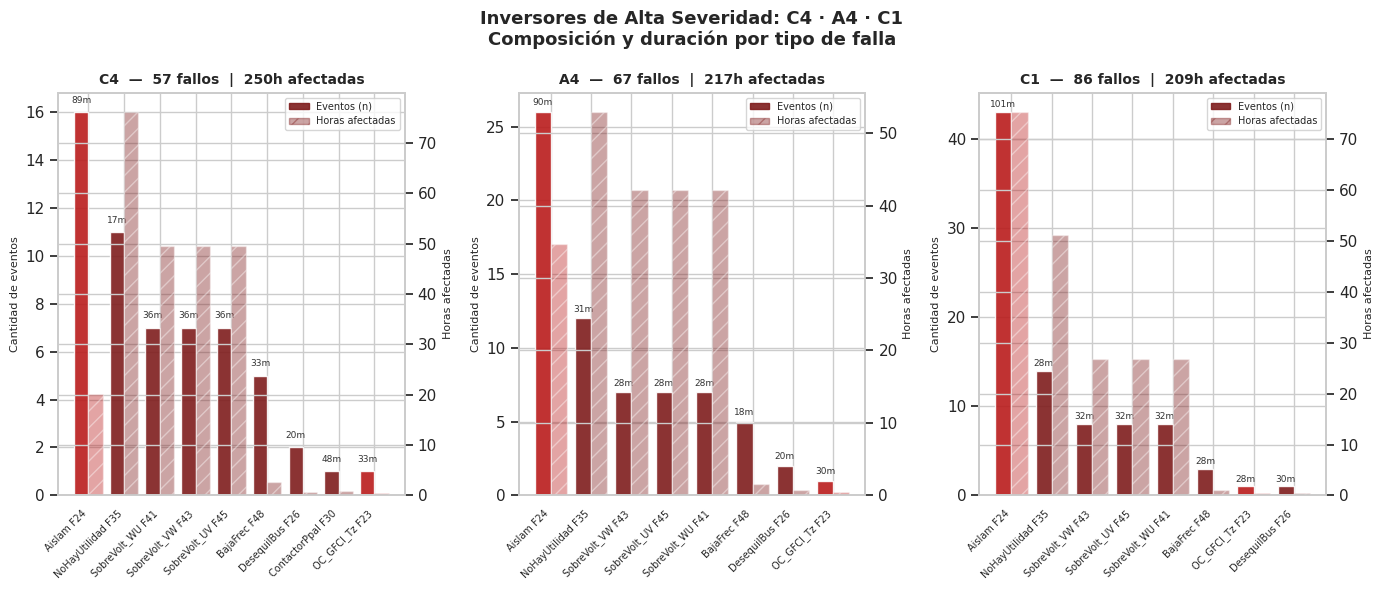

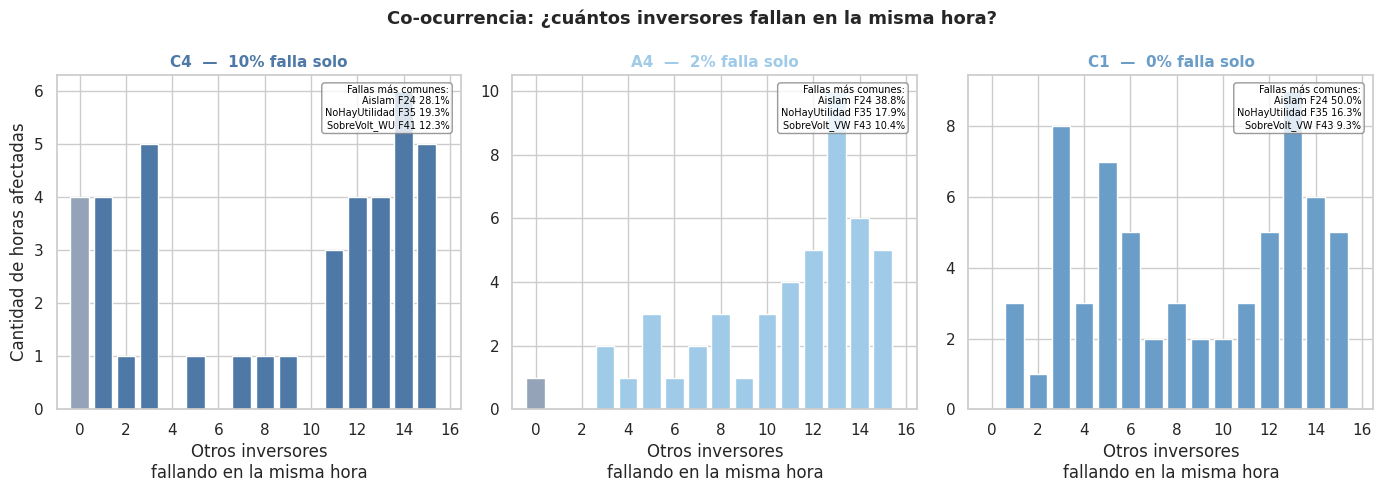

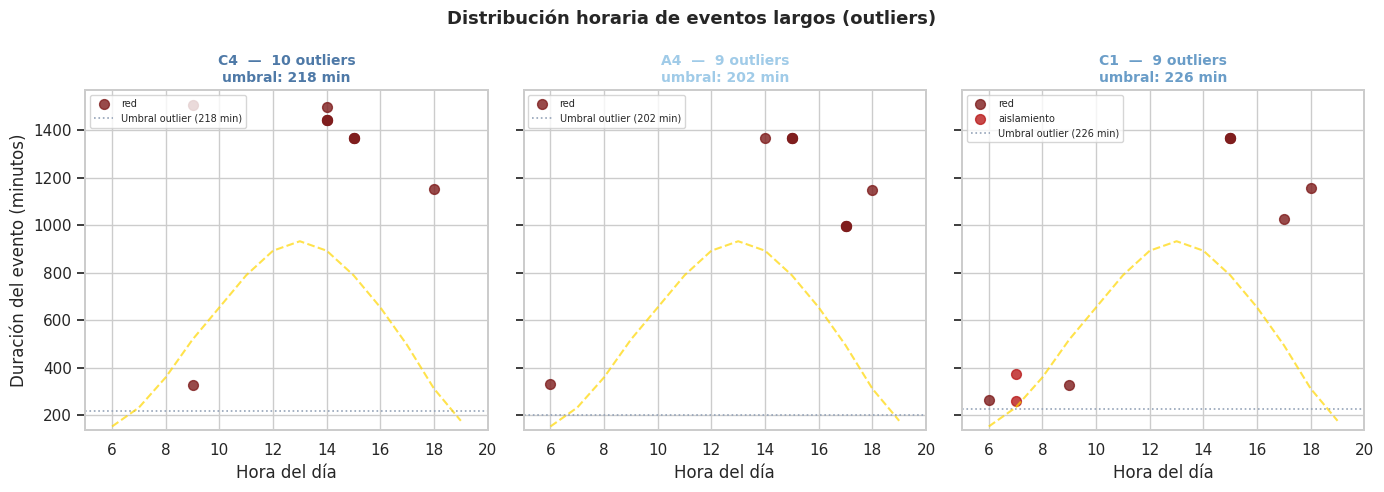


RESUMEN NUMÉRICO — C4, A4, C1

C4:
  Total fallas:        57
  Horas afectadas:     249.7h
  Duración mediana:    36 min
  Duración promedio:   263 min
  Umbral outlier:      218 min
  Nº outliers:         10
  Falla más común:     Fallo_Aislam_CC F24
  % falla principal:   28.1%
  Horas en F35:        76.2h

A4:
  Total fallas:        67
  Horas afectadas:     216.7h
  Duración mediana:    71 min
  Duración promedio:   194 min
  Umbral outlier:      202 min
  Nº outliers:         9
  Falla más común:     Fallo_Aislam_CC F24
  % falla principal:   38.8%
  Horas en F35:        52.9h

C1:
  Total fallas:        86
  Horas afectadas:     209.2h
  Duración mediana:    90 min
  Duración promedio:   146 min
  Umbral outlier:      226 min
  Nº outliers:         9
  Falla más común:     Fallo_Aislam_CC F24
  % falla principal:   50.0%
  Horas en F35:        51.2h


In [ ]:
# Análisis de inversores de alta severidad / baja frecuencia: C4, A4, C1

# ─────────────────────────────────────────────
# CONFIGURACIÓN GLOBAL
# ─────────────────────────────────────────────
sns.set_theme(style="whitegrid")

INVERSORES_SEV = ['C4', 'A4', 'C1']

COLORES_INV = {
    'C4': '#4e79a7',   # azul grupo C
    'A4': '#a0cbe8',   # azul claro grupo A
    'C1': '#6a9dc8'    # azul intermedio grupo C
}

MAPA_GRUPOS_FALLA = {
    'Fallo_BajaFrec_CA F48':       'red',
    'Fallo_SobreFrec_CA F47':      'red',
    'Fallo_SobreVolt_WU_CA F41':   'red',
    'Fallo_SobreVolt_VW_CA F43':   'red',
    'Fallo_SobreVolt_UV_CA F45':   'red',
    'Fallo_NoHayUtilidad_CA F35':  'red',
    'Fallo_ContactorPpal_CA F30':  'red',
    'Fallo_Aislam_CC F24':         'aislamiento',
    'Fallo_DesequilBus_CC F26':    'aislamiento',
    'Fallo_OC_GFCI_Tz F23':        'aislamiento',
    'Fallo_SobreCorr_Tz F20':      'aislamiento',
    'Fallo_BajaTemp_Disispador IGBT F64': 'hardware',
}

COLORES_FALLA = {
    'red':         '#7f1d1d',
    'aislamiento': '#b91c1c',
    'hardware':    '#fca5a5'
}

# Filtro inversores de interés
df_sev = df_fallas_clima[df_fallas_clima['inversor'].isin(INVERSORES_SEV)].copy()
df_sev['grupo_falla'] = df_sev['nombre_de_alerta'].map(MAPA_GRUPOS_FALLA)
df_sev['hora_dia'] = df_sev['hora_abierta'].dt.hour

# Umbral outlier por inversor (Q3 + 1.5*IQR)
umbrales = {}
for inv in INVERSORES_SEV:
    datos = df_sev[df_sev['inversor'] == inv]['evento_minutos']
    q1, q3 = datos.quantile(0.25), datos.quantile(0.75)
    umbrales[inv] = q3 + 1.5 * (q3 - q1)


# ─────────────────────────────────────────────
# FIGURA 1: COMPOSICIÓN POR TIPO + BOXPLOT POR TIPO
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(14, 6))
fig.suptitle('Inversores de Alta Severidad: C4 · A4 · C1\nComposición y duración por tipo de falla',
             fontsize=13, fontweight='bold')

for ax, inv in zip(axes, INVERSORES_SEV):
    df_inv = df_sev[df_sev['inversor'] == inv].copy()

    # Datos por tipo de falla
    tipos = df_inv['nombre_de_alerta'].value_counts()
    horas_tipo = df_inv.groupby('nombre_de_alerta')['evento_minutos'].sum() / 60
    dur_med = df_inv.groupby('nombre_de_alerta')['evento_minutos'].median()

    # Limpio nombres para display
    def clean_name(n):
        return n.replace('Fallo_', '').replace('_CA', '').replace('_CC', '')

    labels = [clean_name(t) for t in tipos.index]
    counts = tipos.values
    horas  = horas_tipo.reindex(tipos.index).values
    grupo_color = [COLORES_FALLA.get(MAPA_GRUPOS_FALLA.get(t, 'red'), '#7f1d1d')
                   for t in tipos.index]

    x = np.arange(len(labels))
    width = 0.4

    ax2 = ax.twinx()

    # Barras: cantidad de eventos
    bars1 = ax.bar(x - width/2, counts, width, color=grupo_color,
                   alpha=0.9, label='Eventos', edgecolor='white')

    # Barras: horas afectadas
    bars2 = ax2.bar(x + width/2, horas, width, color=grupo_color,
                    alpha=0.4, label='Horas afectadas', edgecolor='white',
                    hatch='//')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Cantidad de eventos', fontsize=8)
    ax2.set_ylabel('Horas afectadas', fontsize=8)
    ax.set_title(f'{inv}  —  {len(df_inv)} fallos  |  {df_inv["evento_minutos"].sum()/60:.0f}h afectadas',
                 fontsize=10, fontweight='bold')

    # Anotar duración mediana encima de cada barra de eventos
    for j, (bar, t) in enumerate(zip(bars1, tipos.index)):
        med = dur_med[t]
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{med:.0f}m', ha='center', va='bottom', fontsize=6.5, color='#333')

    # Leyenda manual
    patch_ev  = mpatches.Patch(color='#7f1d1d', alpha=0.9, label='Eventos (n)')
    patch_hrs = mpatches.Patch(color='#7f1d1d', alpha=0.4, hatch='//', label='Horas afectadas')
    ax.legend(handles=[patch_ev, patch_hrs], fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# FIGURA 2: CO-OCURRENCIA
# ─────────────────────────────────────────────

fig2, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
fig2.suptitle('Co-ocurrencia: ¿cuántos inversores fallan en la misma hora?',
              fontsize=13, fontweight='bold')

imprime = True
for ax, inv in zip(axes, INVERSORES_SEV):
    horas_inv = df_fallas_clima[df_fallas_clima['inversor'] == inv]['fecha_referencia_abierta'].unique()

    conteos = []
    for h in horas_inv:
        n_otros = df_fallas_clima[
            (df_fallas_clima['fecha_referencia_abierta'] == h) &
            (df_fallas_clima['inversor'] != inv)
        ]['inversor'].nunique()
        conteos.append(n_otros)

    conteos = pd.Series(conteos)
    pct_solo = (conteos == 0).sum() / len(conteos) * 100

    # Top 3 fallas
    top3 = df_fallas_clima[df_fallas_clima['inversor'] == inv]['nombre_de_alerta'].value_counts().head(3)
    top3_txt = '\n'.join([f"{clean_name(k)} {v/df_fallas_clima[df_fallas_clima['inversor']==inv].shape[0]*100:.1f}%"
                          for k, v in top3.items()])

    dist = conteos.value_counts().sort_index()
    colores_bar = ['#94a3b8' if i == 0 else COLORES_INV[inv] for i in dist.index]
    ax.bar(dist.index, dist.values, color=colores_bar, edgecolor='white')
    ax.set_title(f'{inv}  —  {pct_solo:.0f}% falla solo', fontsize=11, fontweight='bold',
                 color=COLORES_INV[inv])
    ax.set_xlabel('Otros inversores\nfallando en la misma hora')
    if imprime:
        ax.set_ylabel('Cantidad de horas afectadas')
        imprime = False
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.set_xlim(-1, 16.5)

    # Recuadro con top 3 fallas
    ax.text(0.97, 0.97,
            f'Fallas más comunes:\n{top3_txt}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=7, color='black',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# FIGURA 3: DISTRIBUCIÓN TEMPORAL DE EVENTOS LARGOS
# ─────────────────────────────────────────────

fig3, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig3.suptitle('Distribución horaria de eventos largos (outliers)',
              fontsize=13, fontweight='bold')

# Irradiancia normalizada para referencia (reutilizar del notebook)
horas_ref = np.arange(6, 20)
ig_norm = np.array([0.02, 0.12, 0.28, 0.48, 0.65, 0.82, 0.95, 1.0,
                    0.95, 0.82, 0.65, 0.45, 0.22, 0.05])

imprime = True
for ax, inv in zip(axes, INVERSORES_SEV):
    df_inv  = df_sev[df_sev['inversor'] == inv]
    umbral  = umbrales[inv]
    outliers = df_inv[df_inv['evento_minutos'] > umbral].copy()

    # Scatter: hora vs duración, coloreado por tipo de falla
    for grupo, color in COLORES_FALLA.items():
        sub = outliers[outliers['grupo_falla'] == grupo]
        if len(sub):
            ax.scatter(sub['hora_dia'], sub['evento_minutos'],
                       color=color, alpha=0.8, s=50,
                       label=grupo, zorder=3)

    # Línea de irradiancia normalizada (eje secundario)
    ax2 = ax.twinx()
    ax2.plot(horas_ref, ig_norm, color='gold', linewidth=1.5,
             linestyle='--', alpha=0.7, label='Irradiancia norm.')
    ax2.set_ylim(0, 1.8)
    ax2.set_yticks([])

    # Línea de umbral
    ax.axhline(umbral, color='#94a3b8', linestyle=':', linewidth=1.2,
               label=f'Umbral outlier ({umbral:.0f} min)')

    ax.set_title(f'{inv}  —  {len(outliers)} outliers\numbral: {umbral:.0f} min',
                 fontsize=10, fontweight='bold', color=COLORES_INV[inv])
    ax.set_xlabel('Hora del día')
    if imprime:
        ax.set_ylabel('Duración del evento (minutos)')
        imprime = False
    ax.set_xlim(5, 20)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# RESUMEN NUMÉRICO
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("RESUMEN NUMÉRICO — C4, A4, C1")
print("="*55)

for inv in INVERSORES_SEV:
    df_inv = df_fallas_clima[df_fallas_clima['inversor'] == inv]
    print(f"\n{inv}:")
    print(f"  Total fallas:        {len(df_inv)}")
    print(f"  Horas afectadas:     {df_inv['evento_minutos'].sum()/60:.1f}h")
    print(f"  Duración mediana:    {df_inv['evento_minutos'].median():.0f} min")
    print(f"  Duración promedio:   {df_inv['evento_minutos'].mean():.0f} min")
    print(f"  Umbral outlier:      {umbrales[inv]:.0f} min")
    print(f"  Nº outliers:         {(df_inv['evento_minutos'] > umbrales[inv]).sum()}")
    print(f"  Falla más común:     {df_inv['nombre_de_alerta'].value_counts().index[0]}")
    print(f"  % falla principal:   {df_inv['nombre_de_alerta'].value_counts().iloc[0]/len(df_inv)*100:.1f}%")
    print(f"  Horas en F35:        {df_inv[df_inv['nombre_de_alerta']=='Fallo_NoHayUtilidad_CA F35']['evento_minutos'].sum()/60:.1f}h")

###### Eventos por fallo

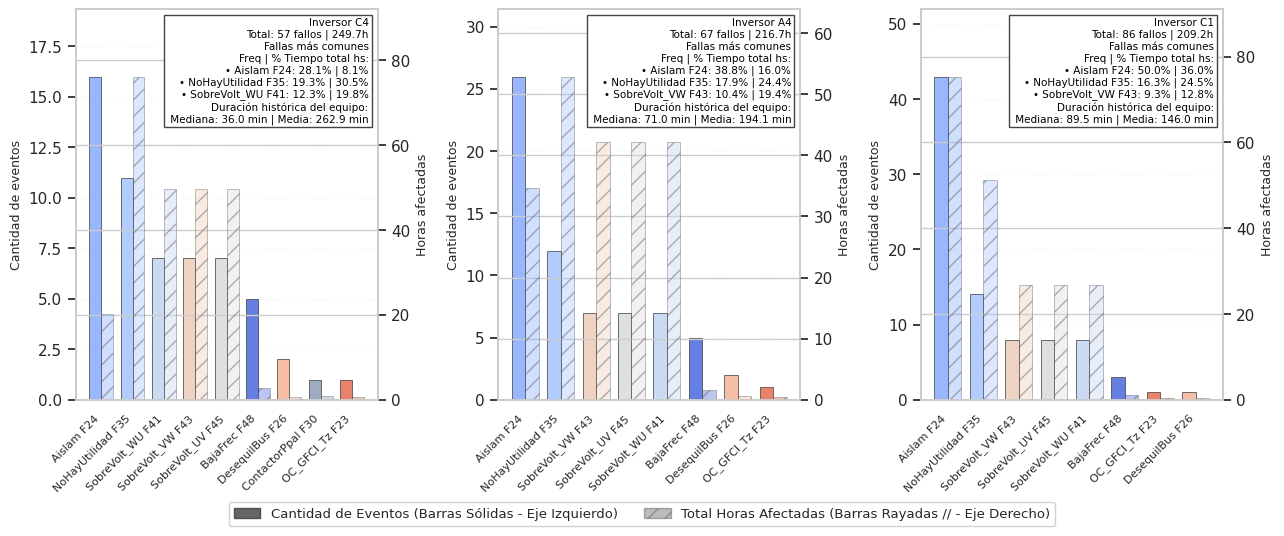

In [ ]:
# ────────────────
#  ALTA SEVERIDAD
# ────────────────

fig, axes = plt.subplots(1, 3, figsize=(13, 5.2))

lista_ordenada_fallas = list(col_colors.keys())
n_tipos_totales = len(lista_ordenada_fallas)

for ax, inv in zip(axes, INVERSORES_SEV):
    df_inv = df_sev[df_sev['inversor'] == inv].copy()

    # Datos por tipo de falla
    tipos = df_inv['nombre_de_alerta'].value_counts()
    horas_tipo = df_inv.groupby('nombre_de_alerta')['evento_minutos'].sum() / 60
    dur_med = df_inv.groupby('nombre_de_alerta')['evento_minutos'].median()

    # Limpio nombres para display
    def clean_name(n):
        return n.replace('Fallo_', '').replace('_CA', '').replace('_CC', '')

    labels = [clean_name(t) for t in tipos.index]
    counts = tipos.values
    horas  = horas_tipo.reindex(tipos.index).values

    grupo_color = [col_colors.get(t, '#94a3b8') for t in tipos.index]

    x = np.arange(len(labels))
    width = 0.38

    # EJE SECUNDARIO
    ax2 = ax.twinx()

    # Cuadrícula: Forzamos el encendido de horizontales y el apagado absoluto de verticales
    ax.grid(axis='y', which='major', alpha=0.2, linestyle=':', zorder=1)
    ax.grid(axis='x', which='both', visible=False) # Apaga explícitamente cualquier línea vertical

    # Barras: cantidad de eventos (zorder=2)
    bars1 = ax.bar(x - width/2, counts, width, color=grupo_color,
                   alpha=0.9, label='Eventos', edgecolor='#444444', linewidth=0.6, zorder=2)

    # Barras: horas afectadas (zorder=2)
    bars2 = ax2.bar(x + width/2, horas, width, color=grupo_color,
                    alpha=0.4, label='Horas afectadas', edgecolor='#444444',
                    linewidth=0.6, hatch='//', zorder=2)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Cantidad de eventos', fontsize=9)
    ax2.set_ylabel('Horas afectadas', fontsize=9)

    # Anotar duración mediana encima de cada barra de eventos con CONTRASTE ADAPTATIVO
    for j, (bar, t) in enumerate(zip(bars1, tipos.index)):
        med = dur_med[t]

        try:
            idx_paleta = lista_ordenada_fallas.index(t)
            if idx_paleta == 0 or idx_paleta == (n_tipos_totales - 1):
                color_texto = 'white'
                peso_texto = 'bold'
                posicion_y_txt = bar.get_height() / 2
                va_txt = 'center'
            else:
                color_texto = '#222222'
                peso_texto = 'bold'
                posicion_y_txt = bar.get_height() + (counts.max() * 0.02)
                va_txt = 'bottom'
        except ValueError:
            color_texto = '#333333'
            peso_texto = 'normal'
            posicion_y_txt = bar.get_height() + (counts.max() * 0.02)
            va_txt = 'bottom'

    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
    ax2.set_ylim(0, ax2.get_ylim()[1] * 1.15)

    # Cuadrícula de fondo asignada a ax (eje base)
    ax.grid(axis='y', alpha=0.2, linestyle=':', zorder=1)

    # Filtrado y cálculos base del inversor específico
    df_datos = df_fallas_clima[df_fallas_clima['inversor'] == inv]

    conteos_fallas = df_datos['nombre_de_alerta'].value_counts()
    total_eventos_inv = len(df_datos)
    total_minutos_inv = df_datos['evento_minutos'].sum()

    fallo_comun_1 = conteos_fallas.index[0]
    fallo_comun_2 = conteos_fallas.index[1]
    fallo_comun_3 = conteos_fallas.index[2]

    pct_comun_1 = (conteos_fallas.iloc[0] / total_eventos_inv) * 100
    pct_comun_2 = (conteos_fallas.iloc[1] / total_eventos_inv) * 100
    pct_comun_3 = (conteos_fallas.iloc[2] / total_eventos_inv) * 100

    minutos_fallo_1 = df_datos[df_datos['nombre_de_alerta'] == fallo_comun_1]['evento_minutos'].sum()
    minutos_fallo_2 = df_datos[df_datos['nombre_de_alerta'] == fallo_comun_2]['evento_minutos'].sum()
    minutos_fallo_3 = df_datos[df_datos['nombre_de_alerta'] == fallo_comun_3]['evento_minutos'].sum()

    pct_tiempo_1 = (minutos_fallo_1 / total_minutos_inv) * 100 if total_minutos_inv > 0 else 0
    pct_tiempo_2 = (minutos_fallo_2 / total_minutos_inv) * 100 if total_minutos_inv > 0 else 0
    pct_tiempo_3 = (minutos_fallo_3 / total_minutos_inv) * 100 if total_minutos_inv > 0 else 0

    min_median_1 = df_datos['evento_minutos'].median()
    min_mean_1 = df_datos['evento_minutos'].mean()

    def clean_txt(n):
        return n.replace('Fallo_', '').replace('_CA', '').replace('_CC', '')

    texto_box = (
        f"Inversor {inv}\n"
        f"Total: {len(df_inv)} fallos | {df_inv['evento_minutos'].sum()/60:.1f}h\n"
        f"Fallas más comunes\nFreq | % Tiempo total hs:\n"
        f"• {clean_txt(fallo_comun_1)}: {pct_comun_1:.1f}% | {pct_tiempo_1:.1f}%\n"
        f"• {clean_txt(fallo_comun_2)}: {pct_comun_2:.1f}% | {pct_tiempo_2:.1f}%\n"
        f"• {clean_txt(fallo_comun_3)}: {pct_comun_3:.1f}% | {pct_tiempo_3:.1f}%\n"
        f"Duración histórica del equipo:\n"
        f" Mediana: {min_median_1:.1f} min | Media: {min_mean_1:.1f} min"
        #f"  Media: {min_mean_1:.1f} min"
    )

    ax2.text(0.97, 0.98, texto_box,
             transform=ax2.transAxes, ha='right', va='top',
             fontsize=7.5, color='black',
             zorder=10,
             bbox={
                 'facecolor': 'white',
                 'alpha': 1.0,
                 'edgecolor': '#444444',
                 'boxstyle': 'square,pad=0.3',
                 'zorder': 10
             })

patch_ev  = mpatches.Patch(facecolor='#555555', alpha=0.9, edgecolor='#444444', label='Cantidad de Eventos (Barras Sólidas - Eje Izquierdo)')
patch_hrs = mpatches.Patch(facecolor='#555555', alpha=0.4, hatch='//', edgecolor='#444444', label='Total Horas Afectadas (Barras Rayadas // - Eje Derecho)')

fig.legend(
    handles=[patch_ev, patch_hrs],
    loc='upper center',
    bbox_to_anchor=(0.5, 0.03),
    ncol=2,
    fontsize=9.5,
    frameon=True,
    framealpha=0.9,
    edgecolor='#cccccc',
    title_fontsize=10
)

plt.tight_layout()
plt.show()


###### Co-ocurrencia

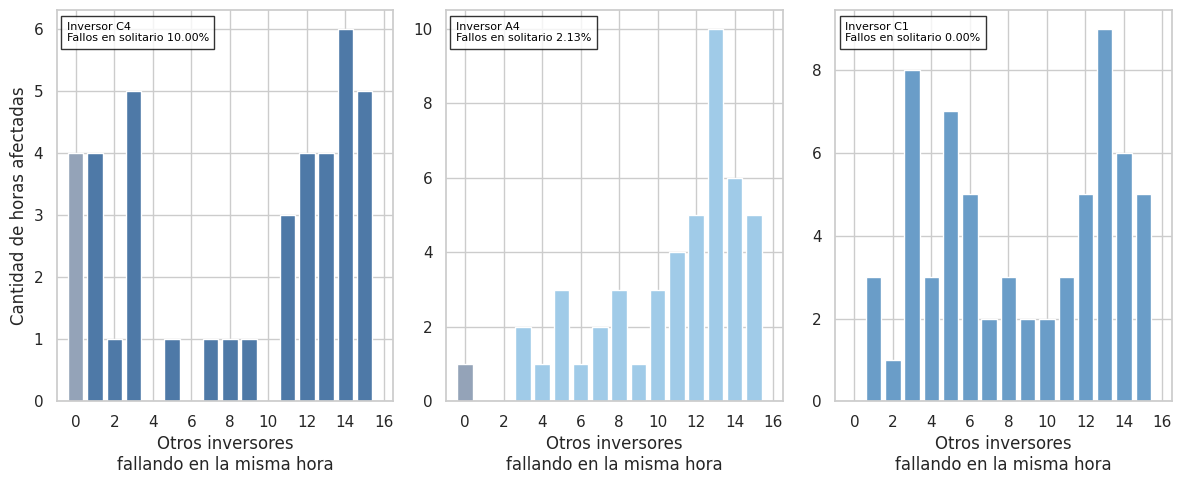

In [ ]:
# ──────────────
# CO-OCURRENCIA
# ──────────────

fig2, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=False)

imprime = True
for ax, inv in zip(axes, INVERSORES_SEV):
    horas_inv = df_fallas_clima[df_fallas_clima['inversor'] == inv]['fecha_referencia_abierta'].unique()

    conteos = []
    for h in horas_inv:
        n_otros = df_fallas_clima[
            (df_fallas_clima['fecha_referencia_abierta'] == h) &
            (df_fallas_clima['inversor'] != inv)
        ]['inversor'].nunique()
        conteos.append(n_otros)

    conteos = pd.Series(conteos)
    pct_solo = (conteos == 0).sum() / len(conteos) * 100

    # Top 3 fallas
    top3 = df_fallas_clima[df_fallas_clima['inversor'] == inv]['nombre_de_alerta'].value_counts().head(3)
    top3_txt = '\n'.join([f"{clean_name(k)} {v/df_fallas_clima[df_fallas_clima['inversor']==inv].shape[0]*100:.1f}%"
                          for k, v in top3.items()])

    dist = conteos.value_counts().sort_index()
    colores_bar = ['#94a3b8' if i == 0 else COLORES_INV[inv] for i in dist.index]
    ax.bar(dist.index, dist.values, color=colores_bar, edgecolor='white')
    #ax.set_title(f'{inv}  —  {pct_solo:.0f}% falla solo', fontsize=11, fontweight='bold',
    #             color=COLORES_INV[inv])
    ax.set_xlabel('Otros inversores\nfallando en la misma hora')
    if imprime:
        ax.set_ylabel('Cantidad de horas afectadas')
        imprime = False
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.set_xlim(-1, 16.5)
    ax.text(0.03, 0.97, f"Inversor {inv}\nFallos en solitario {pct_solo:.2f}%",
            transform=ax.transAxes, ha='left', va='top',
            fontsize=8, color='black',bbox={'facecolor': 'white','alpha': 0.8,'edgecolor': 'black','boxstyle': 'square,pad=0.5'})
plt.tight_layout()
plt.show()

###### Distribucion de outliers / Irradiancia

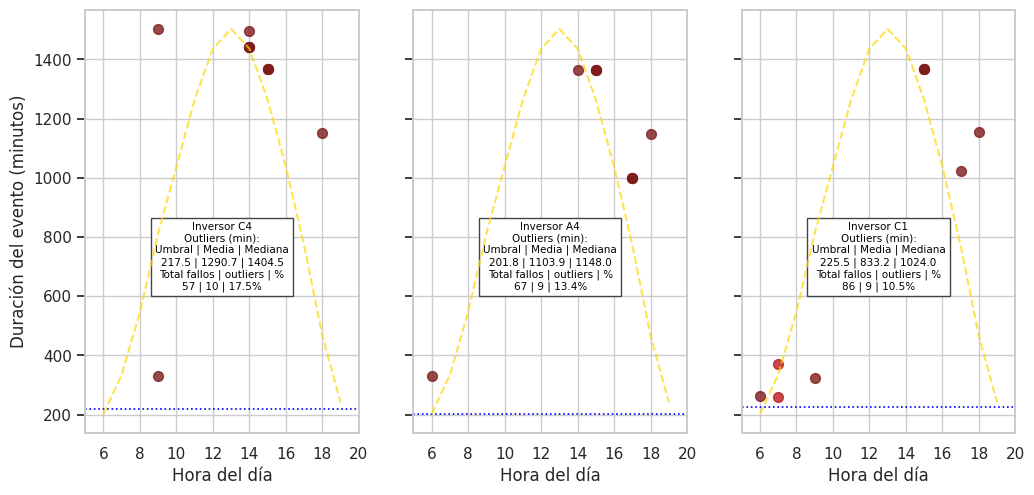

In [ ]:
# Outliers relacionados con irradiancia

# Creo la figura
fig3, axes = plt.subplots(1, 3, figsize=(12, 5.5), sharey=True) # Aumentamos un poco el alto para la leyenda

df_inv = df_sev[df_sev['inversor'] == inv].copy()
# Irradiancia normalizada para referencia (reutilizar del notebook)
horas_ref = np.arange(6, 20)
ig_norm = np.array([0.02, 0.12, 0.28, 0.48, 0.65, 0.82, 0.95, 1.0,
                    0.95, 0.82, 0.65, 0.45, 0.22, 0.05])

# Diccionarios para controlar qué etiquetas ya agregamos a la leyenda global
dict_handles = {}

imprime = True
for ax, inv in zip(axes, INVERSORES_SEV):
    df_inv  = df_sev[df_sev['inversor'] == inv]
    umbral  = umbrales[inv]
    outliers = df_inv[df_inv['evento_minutos'] > umbral].copy()

    # Scatter: hora vs duración, coloreado por tipo de falla
    for grupo, color in COLORES_FALLA.items():
        sub = outliers[outliers['grupo_falla'] == grupo]
        if len(sub):
            sc = ax.scatter(sub['hora_dia'], sub['evento_minutos'],
                            color=color, alpha=0.8, s=50,
                            label=grupo, zorder=3)
            # Guardamos el handle si no existe para la leyenda global
            if grupo not in dict_handles:
                dict_handles[grupo] = sc

    # Línea de irradiancia normalizada (eje secundario)
    ax2 = ax.twinx()
    line_irr = ax2.plot(horas_ref, ig_norm, color='gold', linewidth=1.5,
                        linestyle='--', alpha=0.7, label='Irradiancia normalizada')
    ax2.set_yticks([])

    # Guardamos la referencia de la irradiancia una sola vez
    label_irr = 'Irradiancia normalizada'
    if label_irr not in dict_handles:
        dict_handles[label_irr] = line_irr[0]

    # Línea de umbral (agregamos el label)
    label_umbr = 'Umbral de Outliers'
    axhline_obj = ax.axhline(umbral, color='blue', linestyle=':', linewidth=1.2, label=label_umbr)

    # Guardamos la referencia de la LINEA HORIZONTAL (axhline_obj) una sola vez
    if label_umbr not in dict_handles:
        dict_handles[label_umbr] = axhline_obj

    # fontsize=10, fontweight='bold', color=COLORES_INV[inv])
    ax.set_xlabel('Hora del día')

    if imprime:
        ax.set_ylabel('Duración del evento (minutos)')
        imprime = False

    ax.set_xlim(5, 20)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    # 1. Realizas los cálculos de manera independiente
    total_fallas = len(df_inv)
    umbral = umbrales[inv]

    # Filtramos los outliers para el inversor actual
    outliers_df = df_inv[df_inv['evento_minutos'] > umbral]
    outliers_conteo = len(outliers_df)

    # Media y Mediana calculadas EXCLUSIVAMENTE sobre los outliers
    media_outliers = outliers_df['evento_minutos'].mean() if outliers_conteo > 0 else 0.0
    mediana_outliers = outliers_df['evento_minutos'].median() if outliers_conteo > 0 else 0.0

    # Manejo de división por cero para el porcentaje
    pct_outliers = (outliers_conteo / total_fallas) * 100 if total_fallas > 0 else 0.0

    # 2. Creas el string con los datos de los outliers
    texto_box = (
        f"Inversor {inv}\n"
        f"Outliers (min):\nUmbral | Media | Mediana\n"
        f"{umbral:.1f} | {media_outliers:.1f} | {mediana_outliers:.1f}\n"
        f"Total fallos | outliers | %\n"
        f"{total_fallas} | {outliers_conteo} | {pct_outliers:.1f}%"
    )

    # 3. Dibujas el recuadro en el gráfico actual (ax)
    ax.text(0.5, 0.5, texto_box,
            transform=ax.transAxes, ha='center', va='top',
            fontsize=7.5, color='black',
            zorder=10,
            bbox={
                'facecolor': 'white',
                'alpha': 1.0,
                'edgecolor': '#444444',
                'boxstyle': 'square,pad=0.4',
                'zorder': 10})


###### Resumen numerico

In [ ]:
# ─────────────────────────────────────────────
# RESUMEN NUMÉRICO
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("RESUMEN NUMÉRICO — C4, A4, C1")
print("="*55)

for inv in INVERSORES_SEV:
    df_inv = df_fallas_clima[df_fallas_clima['inversor'] == inv]
    umbral = umbrales[inv]

    # Filtro el subconjunto de outliers para los nuevos cálculos
    df_outliers = df_inv[df_inv['evento_minutos'] > umbral]
    n_outliers = len(df_outliers)

    # Calculo media y mediana de outliers (con manejo de strings vacíos/ceros si no hay)
    media_outliers = df_outliers['evento_minutos'].mean() if n_outliers > 0 else 0.0
    mediana_outliers = df_outliers['evento_minutos'].median() if n_outliers > 0 else 0.0

    print(f"\n{inv}:")
    print(f"  Total fallas:        {len(df_inv)}")
    print(f"  Horas afectadas:     {df_inv['evento_minutos'].sum()/60:.1f}h")
    print(f"  Duración mediana:    {df_inv['evento_minutos'].median():.0f} min")
    print(f"  Duración promedio:   {df_inv['evento_minutos'].mean():.0f} min")
    print(f"  Umbral outlier:      {umbral:.0f} min")
    print(f"  Nº outliers:         {n_outliers}")

    print(f"  Media outliers:      {media_outliers:.1f} min")
    print(f"  Mediana outliers:    {mediana_outliers:.1f} min")


    if len(df_inv) > 0:
        print(f"  Falla más común:     {df_inv['nombre_de_alerta'].value_counts().index[0]}")
        print(f"  % falla principal:   {df_inv['nombre_de_alerta'].value_counts().iloc[0]/len(df_inv)*100:.1f}%")
    else:
        print(f"  Falla más común:     N/A")
        print(f"  % falla principal:   0.0%")

    horas_f35 = df_inv


RESUMEN NUMÉRICO — C4, A4, C1

C4:
  Total fallas:        57
  Horas afectadas:     249.7h
  Duración mediana:    36 min
  Duración promedio:   263 min
  Umbral outlier:      218 min
  Nº outliers:         10
  Media outliers:      1290.7 min
  Mediana outliers:    1404.5 min
  Falla más común:     Fallo_Aislam_CC F24
  % falla principal:   28.1%

A4:
  Total fallas:        67
  Horas afectadas:     216.7h
  Duración mediana:    71 min
  Duración promedio:   194 min
  Umbral outlier:      202 min
  Nº outliers:         9
  Media outliers:      1103.9 min
  Mediana outliers:    1148.0 min
  Falla más común:     Fallo_Aislam_CC F24
  % falla principal:   38.8%

C1:
  Total fallas:        86
  Horas afectadas:     209.2h
  Duración mediana:    90 min
  Duración promedio:   146 min
  Umbral outlier:      226 min
  Nº outliers:         9
  Media outliers:      833.2 min
  Mediana outliers:    1024.0 min
  Falla más común:     Fallo_Aislam_CC F24
  % falla principal:   50.0%


#### Genero campo por agrupamiento de tipo de fallo

In [ ]:
# 1. Definimos las condiciones de agrupación basadas en los códigos Fxx
# Aseguramos que la columna se llama 'nombre_de_alerta'

condiciones = [
    df_fallas_clima['nombre_de_alerta'].str.contains('F24|F23', case=False),  # Aislamiento
    df_fallas_clima['nombre_de_alerta'].str.contains('F35|F41|F45|F43|F48|F47', case=False), # Red
    df_fallas_clima['nombre_de_alerta'].str.contains('F26|F64|F30|F20', case=False)  # Hardware
]

# 2. Definimos los nombres de los grupos
nombres_grupos = ['aislamiento', 'red', 'hardware']

# 3. Creamos la columna en df_fallas_clima
df_fallas_clima['grupo_falla'] = np.select(condiciones, nombres_grupos, default='otro')

# 4. Verificación de la distribución en este dataframe
print("Distribución de eventos por grupo en df_fallas_clima:")
print(df_fallas_clima['grupo_falla'].value_counts())

Distribución de eventos por grupo en df_fallas_clima:
grupo_falla
red            782
aislamiento    369
hardware        40
Name: count, dtype: int64


#### Fallos Acumulados por Inversor (Ver)



In [ ]:
# =====================================================
# CASOS ACUMULADOS POR INVERSOR - con mediana de flota
# =====================================================

sns.set_theme(style="whitegrid")

# Preparo datos
orden_inversores = df_fallas_clima['inversor'].value_counts().index
df_plot = pd.crosstab(
    df_fallas_clima['inversor'],
    df_fallas_clima['grupo_falla']
).reindex(orden_inversores)

# Colores de falla
colores_map = {'red': '#7f1d1d', 'aislamiento': '#b91c1c', 'hardware': '#fca5a5'}


#### Horas Acumuladas por Inversor

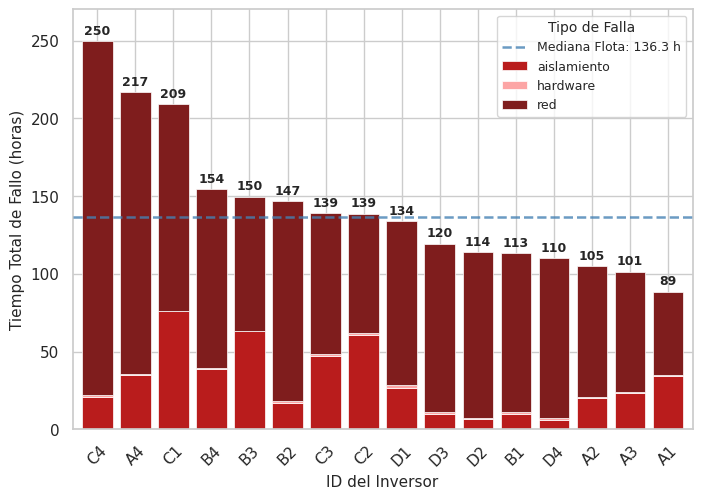

In [ ]:
# =====================================================
# HORAS ACUMULADAS POR INVERSOR - con mediana de flota
# =====================================================

sns.set_theme(style="whitegrid")

# 1. Preparar datos: Sumamos minutos y dividimos por 60 para obtener horas
df_plot = df_fallas_clima.pivot_table(
    index='inversor',
    columns='grupo_falla',
    values='evento_minutos',
    aggfunc='sum',
    fill_value=0
) / 60  # <--- Cambio clave: Conversión a horas

# Calculo totales por inversor para ordenar la gráfica
totales = df_plot.sum(axis=1)
orden_inversores = totales.sort_values(ascending=False).index
df_plot = df_plot.reindex(orden_inversores)
totales = totales.reindex(orden_inversores)

# 2. Configuración de colores
colores_map = {'red': '#7f1d1d', 'aislamiento': '#b91c1c', 'hardware': '#fca5a5'}
colores = [colores_map[col] for col in df_plot.columns if col in colores_map]

# 3. Calcular mediana de la flota (en horas)
mediana_flota = totales.median()

# 4. Creación del gráfico
fig, ax = plt.subplots(figsize=(8, 6))
fig.subplots_adjust(bottom=0.18)

# Línea de mediana
ax.axhline(
    y=mediana_flota,
    color='steelblue',
    linestyle='--',
    linewidth=1.8,
    zorder=5,
    alpha=0.8,
    label=f'Mediana Flota: {mediana_flota:.1f} h'
)

# Barras apiladas
df_plot.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colores,
    width=0.8,
    edgecolor='white',
    linewidth=0.5
)

# Etiquetas de total (en horas con 1 decimal) encima de cada barra
for i, total in enumerate(totales):
    ax.text(i, total + (totales.max() * 0.01), f'{total:.0f}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

# Personalización
ax.set_xlabel('ID del Inversor', fontsize=11)
ax.set_ylabel('Tiempo Total de Fallo (horas)', fontsize=11)

# Ajuste dinámico del límite superior
ax.set_ylim(0, 270)

ax.tick_params(axis='x', rotation=45)

# Leyenda
ax.legend(
    title='Tipo de Falla',
    bbox_to_anchor=(0.675, 1),
    loc='upper left',
    fontsize=9,
    title_fontsize=10,
    frameon=True
)

plt.show()

#### Tipo / cantidad / horas / Meses

/tmp/ipykernel_27973/3406982638.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(inversores, ha='center')


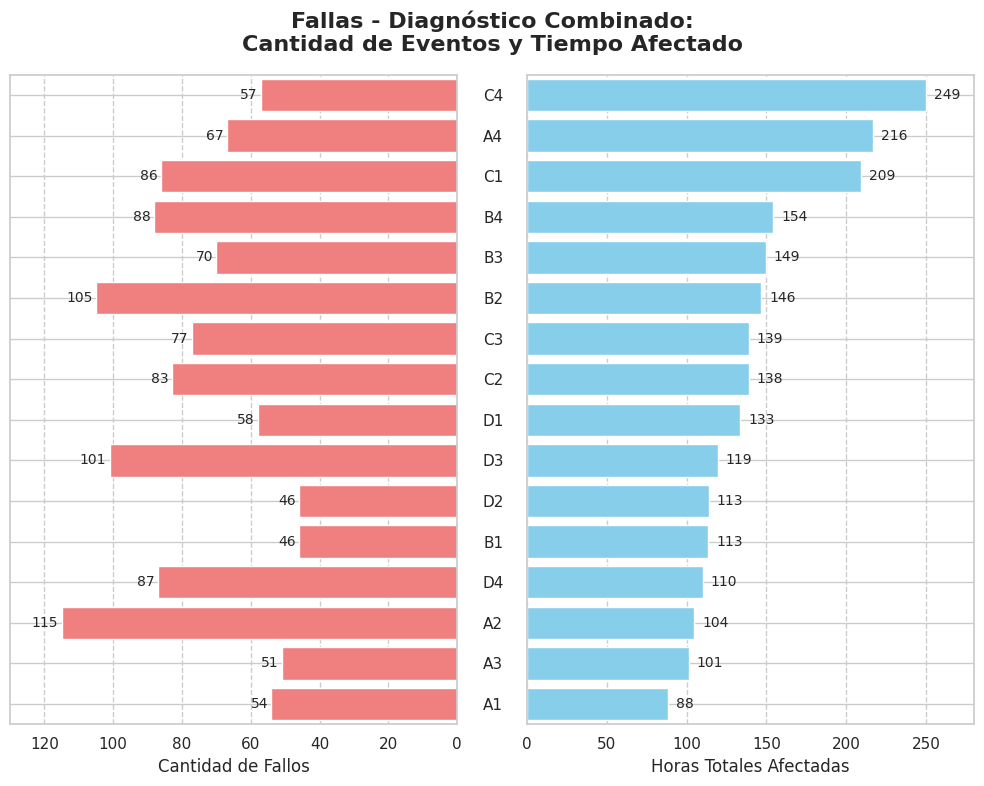

In [ ]:
# Preparo los datos
resumen_inv = df_fallas_clima.groupby('inversor').agg({
    'evento_minutos': 'sum',
    'nombre_de_alerta': 'count'
}).rename(columns={'nombre_de_alerta': 'conteo_eventos'})

resumen_inv = resumen_inv.sort_values('evento_minutos', ascending=True)

inversores = resumen_inv.index
tiempo = resumen_inv['evento_minutos']/60
conteo = resumen_inv['conteo_eventos']

# Configuro la figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8), sharey=True)
#plt.subplots_adjust(wspace=0.2)

# --- LADO IZQUIERDO: Conteo de Eventos ---
ax1.barh(inversores, conteo, color='lightcoral', edgecolor='white')
ax1.invert_xaxis()
ax1.grid(axis='x', linestyle='--')
ax1.set_xlabel('Cantidad de Fallos')
ax1.set_ylim(-0.5, len(inversores) - 0.5)
ax1.set_xlim(130, 0)

# Etiquetas centrales
ax1.tick_params(axis='y', which='both',
                labelleft=False, labelright=True,
                left=False, right=False,
                pad=20)

ax1.set_yticklabels(inversores, ha='center')

# Etiquetas de datos (lado izquierdo)
for i, v in enumerate(conteo):
    ax1.text(v + 1, i, str(int(v)), va='center', ha='right', fontsize=10)

# --- LADO DERECHO: Horas Totales ---
ax2.barh(inversores, tiempo, color='skyblue', edgecolor='white')
ax2.grid(axis='x', linestyle='--')
ax2.set_xlabel('Horas Totales Afectadas')
ax2.set_ylim(-0.5, len(inversores) - 0.5)
ax2.set_xlim(0, 280)

# Quitamos también los ticks del segundo gráfico para que no se superpongan
ax2.tick_params(axis='y', left=False, right=False)

# Etiquetas de datos (lado derecho)
for i, v in enumerate(tiempo):
    ax2.text(v + 5, i, f'{int(v)}', va='center', ha='left', fontsize=10)

# 3. Estética final
plt.suptitle('Fallas - Diagnóstico Combinado:\nCantidad de Eventos y Tiempo Afectado',
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

/tmp/ipykernel_27973/2683497540.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(inversores, ha='center', fontweight='bold')
/tmp/ipykernel_27973/2683497540.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.95])


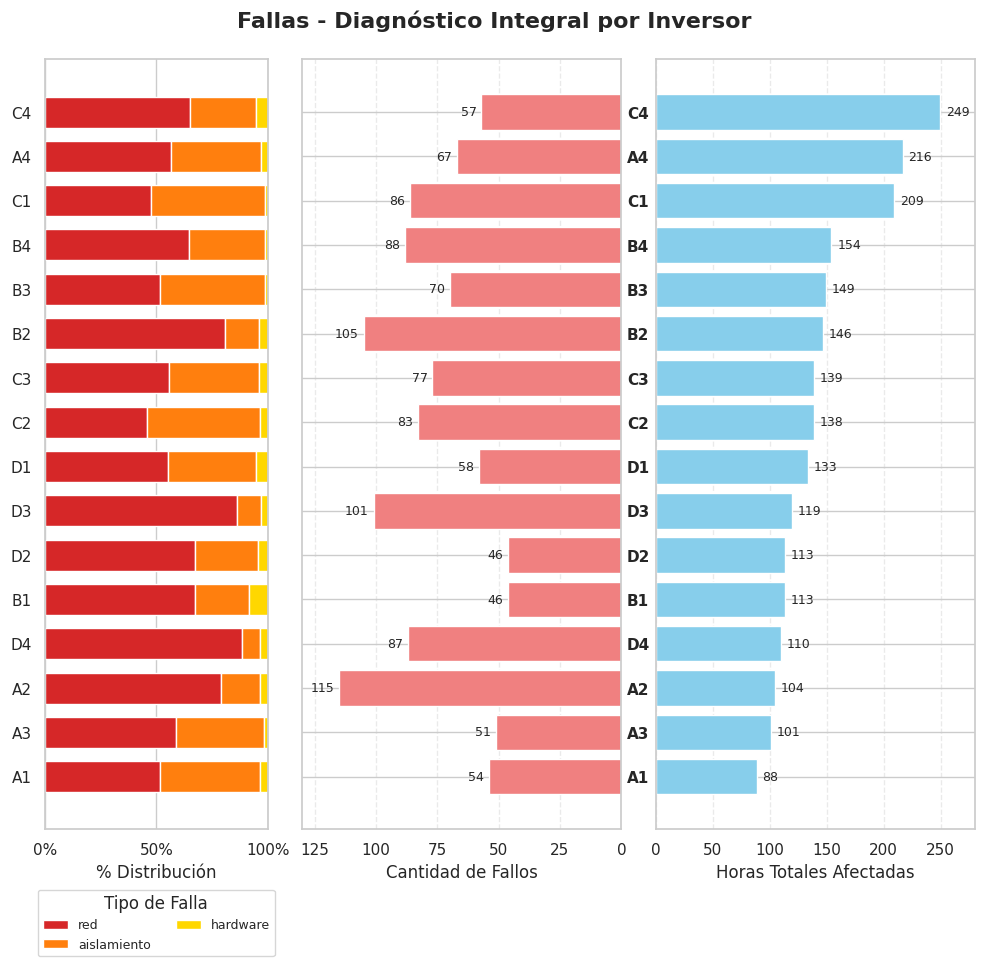

In [ ]:
# 1. Preparar datos de distribución (Normalizados al 100%)
# Creamos una tabla cruzada entre inversor y grupo_falla
dist_clima = pd.crosstab(df_fallas_clima['inversor'], df_fallas_clima['grupo_falla'], normalize='index')
# Reindexamos para que coincida con el orden de la pirámide (por tiempo acumulado)
dist_clima = dist_clima.reindex(inversores)

# Colores para la distribución (Consistentes con tus grupos anteriores)
colores_dist = {'red': '#d62728', 'aislamiento': '#ff7f0e', 'hardware': '#ffd700'}
categorias_clima = [c for c in ['red', 'aislamiento', 'hardware'] if c in dist_clima.columns]

# 2. Configurar la figura con 3 subplots y anchos proporcionales [0.5, 1, 1]
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(12, 10), sharey=True,
                                     gridspec_kw={'width_ratios': [0.7, 1, 1],'wspace': 0.12})

# --- GRÁFICA IZQUIERDA: Distribución 100% ---
left = np.zeros(len(inversores))
for cat in categorias_clima:
    ax0.barh(inversores, dist_clima[cat], left=left, label=cat,
             color=colores_dist[cat], edgecolor='white', height=0.7)
    left += dist_clima[cat]

ax0.set_xlabel('% Distribución')
ax0.set_xlim(0, 1)
ax0.set_xticks([0, 0.5, 1])
ax0.set_xticklabels(['0%', '50%', '100%'])
ax0.tick_params(axis='y', left=False) # Quitar ticks pero mantener alineación por sharey

# --- GRÁFICA CENTRAL: Conteo de Eventos ---
ax1.barh(inversores, conteo, color='lightcoral', edgecolor='white')
ax1.invert_xaxis()
ax1.grid(axis='x', linestyle='--', alpha=0.4)
ax1.set_xlabel('Cantidad de Fallos')
ax1.set_xlim(130, 0)

# Etiquetas de los inversores (ahora entre ax1 y ax2)
ax1.tick_params(axis='y', which='both', labelleft=False, labelright=True,
                left=False, right=False, pad=6)
ax1.set_yticklabels(inversores, ha='center', fontweight='bold')

for i, v in enumerate(conteo):
    ax1.text(v + 2, i, str(int(v)), va='center', ha='right', fontsize=9)

# --- GRÁFICA DERECHA: Horas Totales ---
ax2.barh(inversores, tiempo, color='skyblue', edgecolor='white')
ax2.grid(axis='x', linestyle='--', alpha=0.4)
ax2.set_xlabel('Horas Totales Afectadas')
ax2.set_xlim(0, 280)
ax2.tick_params(axis='y', left=False, right=False)

for i, v in enumerate(tiempo):
    ax2.text(v + 5, i, f'{int(v)}', va='center', ha='left', fontsize=9)

# 3. Estética y Leyenda para la distribución
ax0.legend(title="Tipo de Falla", loc='upper center', bbox_to_anchor=(0.5, -0.07),
           ncol=2, fontsize=9, frameon=True)

plt.suptitle('Fallas - Diagnóstico Integral por Inversor',
             fontsize=16, fontweight='bold', y=0.93)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

/tmp/ipykernel_27973/1857083151.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(inversores, ha='center', fontweight='bold')


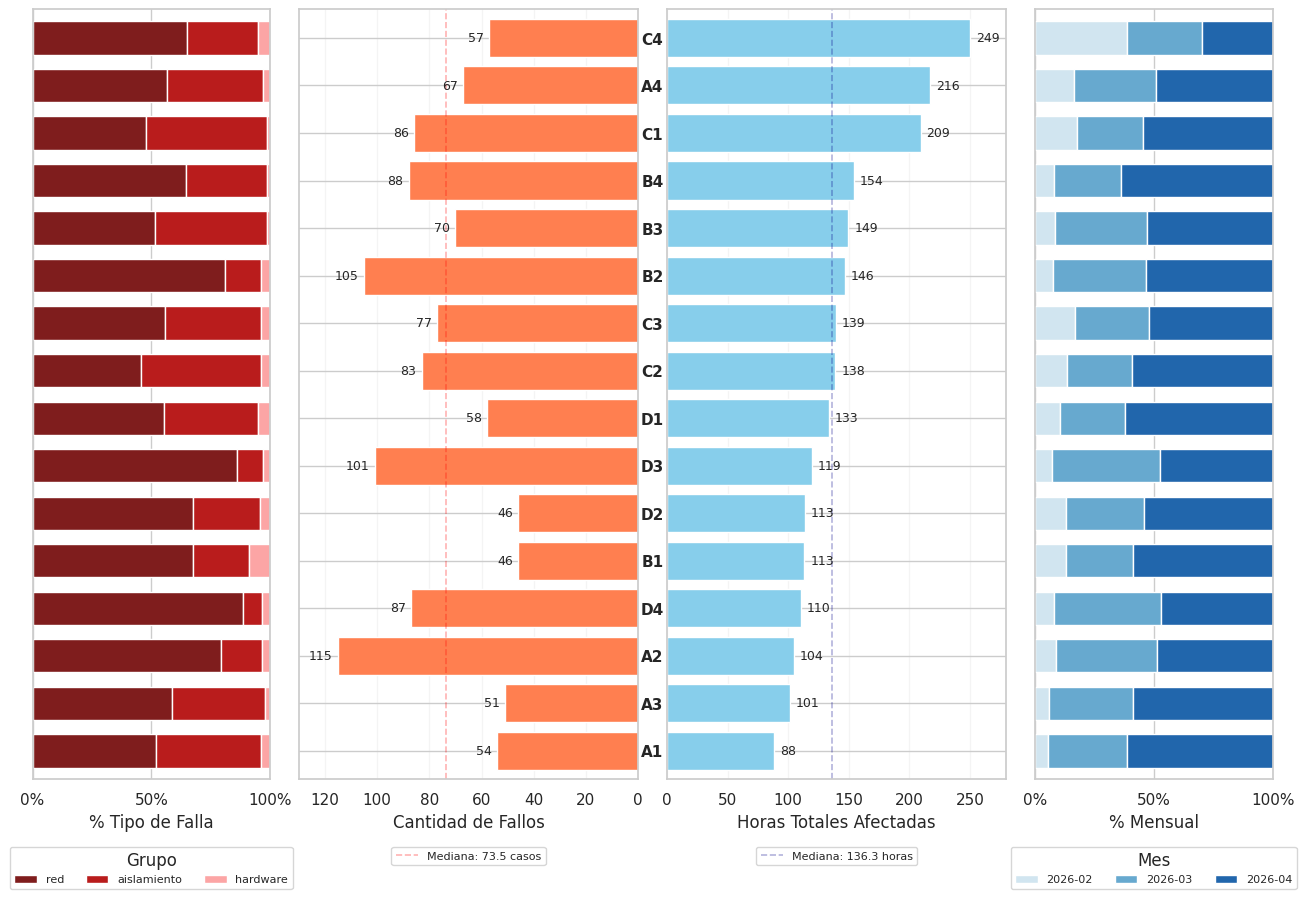

In [ ]:
# --- 1. PREPARACIÓN DE DATOS ---
# Creación de la columna 'mes' y 'time'
df_fallas_clima['time_alerta'] = pd.to_datetime(df_fallas_clima['fecha_alerta'])
df_fallas_clima['mes'] = df_fallas_clima['time_alerta'].dt.to_period('M')

# Agrupación base para definir el orden de los inversores (por severidad/tiempo)
resumen_inv = df_fallas_clima.groupby('inversor').agg({
    'evento_minutos': 'sum',
    'nombre_de_alerta': 'count'
}).rename(columns={'nombre_de_alerta': 'conteo_eventos'})

# Ordena de menor a mayor tiempo para que la pirámide sea armónica
resumen_inv = resumen_inv.sort_values('evento_minutos', ascending=True)

# Variables globales para el plot
inversores = resumen_inv.index
tiempo = resumen_inv['evento_minutos'] / 60  # Convertimos a horas
conteo = resumen_inv['conteo_eventos']

# Prepara Tablas de Distribución (Normalizadas al 100%)
dist_grupo = pd.crosstab(df_fallas_clima['inversor'], df_fallas_clima['grupo_falla'], normalize='index').reindex(inversores)
dist_mes = pd.crosstab(df_fallas_clima['inversor'], df_fallas_clima['mes'].astype(str), normalize='index').reindex(inversores)

# Calcula Medianas para referencias visuales
mediana_conteo = conteo.median()
mediana_tiempo = tiempo.median()

# --- 2. CONFIGURACIÓN DE COLORES ---
colores_dist = {'red': '#7f1d1d', 'aislamiento': '#b91c1c', 'hardware': '#fca5a5'}
#colores_dist = {'red': '#d62728', 'aislamiento': '#ff7f0e', 'hardware': '#ffd700'}
colores_mes = {'2026-02': '#d1e5f0', '2026-03': '#67a9cf', '2026-04': '#2166ac'}

categorias_grupo = [c for c in ['red', 'aislamiento', 'hardware'] if c in dist_grupo.columns]
categorias_mes = sorted(dist_mes.columns)

# --- 3. CREACIÓN DEL GRÁFICO ---

fig, (ax0, ax1, ax2, ax3) = plt.subplots(1, 4, figsize=(16, 10), sharey=True,
                                         gridspec_kw={'width_ratios': [0.7, 1, 1, 0.7]})

plt.subplots_adjust(wspace=0.1)

# --- AX0: DISTRIBUCIÓN POR GRUPO (Extremo Izquierdo) ---
left = np.zeros(len(inversores))
for cat in categorias_grupo:
    ax0.barh(inversores, dist_grupo[cat], left=left, label=cat,
             color=colores_dist.get(cat, '#7f7f7f'), edgecolor='white', height=0.7)
    left += dist_grupo[cat]
ax0.set_xlabel('% Tipo de Falla')
ax0.set_xlim(0, 1)
ax0.set_xticks([0, 0.5, 1])
ax0.set_xticklabels(['0%', '50%', '100%'])
ax0.tick_params(axis='y', left=False, labelleft=False) # Eliminamos labels del extremo izq
ax0.set_ylim(-0.6, len(inversores) - 0.4) # Ajuste vertical para evitar pad grande

# --- AX1: CANTIDAD DE EVENTOS (Frecuencia) ---
ax1.barh(inversores, conteo, color='coral', edgecolor='white')
ax1.invert_xaxis()
ax1.grid(axis='x', linestyle='-', alpha=0.2)
ax1.set_xlabel('Cantidad de Fallos')
ax1.set_xlim(130, 0)

# Referencia de Mediana AX1
mediana_legend = f'Mediana: {mediana_conteo:.1f} casos'
ax1.axvline(mediana_conteo, color='red', linestyle='--', linewidth=1.2, alpha=0.3, label=mediana_legend)
#ax1.text(mediana_conteo, -1.2, f'Mediana: {mediana_conteo:.1f}', color='red', ha='center', fontsize=8, fontweight='bold')

# Configuración del eje central (ID Inversor)
ax1.tick_params(axis='y', which='both', labelleft=False, labelright=True, left=False, right=False, pad=4.3)
ax1.set_yticklabels(inversores, ha='center', fontweight='bold')

for i, v in enumerate(conteo):
    ax1.text(v + 2, i, str(int(v)), va='center', ha='right', fontsize=9)

# --- AX2: HORAS AFECTADAS (Severidad) ---
ax2.barh(inversores, tiempo, color='skyblue', edgecolor='white')
ax2.grid(axis='x', linestyle='-', alpha=0.2)
ax2.set_xlabel('Horas Totales Afectadas')
ax2.set_xlim(0, 280)

# Referencia de Mediana AX2
horas_legend = f'Mediana: {mediana_tiempo:.1f} horas'
ax2.axvline(mediana_tiempo, color='darkblue', linestyle='--', linewidth=1.2, alpha=0.3, label=horas_legend)

ax2.tick_params(axis='y', left=False, right=False)

for i, v in enumerate(tiempo):
    ax2.text(v + 5, i, f'{int(v)}', va='center', ha='left', fontsize=9)

# --- AX3: DISTRIBUCIÓN MENSUAL (Extremo Derecho) ---
left_m = np.zeros(len(inversores))
for mes in categorias_mes:
    ax3.barh(inversores, dist_mes[mes], left=left_m, label=mes,
             color=colores_mes.get(mes, '#084594'), edgecolor='white', height=0.7)
    left_m += dist_mes[mes]
ax3.set_xlabel('% Mensual')
ax3.set_xlim(0, 1)
ax3.set_xticks([0, 0.5, 1])
ax3.set_xticklabels(['0%', '50%', '100%'])
ax3.tick_params(axis='y', left=False)

# --- 4. LEYENDAS, TÍTULOS Y RECUADRO ---

ax0.legend(title="Grupo", loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=8)
ax3.legend(title="Mes", loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=8)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=1, fontsize=8)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=1, fontsize=8)

plt.show()

In [ ]:
# proporción de aislamiento por inversor / horas afectadas

prop_aislamiento = (
    df_fallas_clima
    .assign(es_aislamiento=(df_fallas_clima['grupo_falla'] == 'aislamiento').astype(int))
    .groupby('inversor')
    .agg(
        prop_aislamiento = ('es_aislamiento', 'mean'),
        min_afectados  = ('evento_minutos', 'sum'),
        n_fallas         = ('nombre_de_alerta', 'count')
    )
    .reset_index()
    .sort_values('min_afectados', ascending=False)
)
prop_aislamiento['duracion_prom'] = (
    prop_aislamiento['min_afectados'] / prop_aislamiento['n_fallas']
)

print(prop_aislamiento.to_string(index=False))
print()
print(f"Correlacion proporcion aislamiento vs minutos afectados:")
corr = prop_aislamiento['prop_aislamiento'].corr(prop_aislamiento['min_afectados'])
print(f"  Pearson r = {corr:.3f}")

corr_duracion = prop_aislamiento['prop_aislamiento'].corr(
    prop_aislamiento['duracion_prom']
)
print(f"\nCorrelacion proporcion aislamiento vs duracion promedio por evento:")
print(f"  Pearson r = {corr_duracion:.3f}")


# Verifico el umbral 0.40 de forma más precisa
umbral = 0.40

sobre_umbral = prop_aislamiento[prop_aislamiento['prop_aislamiento'] >= umbral]
bajo_umbral  = prop_aislamiento[prop_aislamiento['prop_aislamiento'] <  umbral]

print("\nInversores con proporción aislamiento >= 40%:")
print(f"  Duración promedio: {sobre_umbral['duracion_prom'].mean():.1f} min")
print(f"  N inversores:      {len(sobre_umbral)}")
print()
print("Inversores con proporción aislamiento < 40%:")
print(f"  Duración promedio: {bajo_umbral['duracion_prom'].mean():.1f} min")
print(f"  N inversores:      {len(bajo_umbral)}")
print()
print(f"Diferencia de duración promedio entre grupos: "
      f"{sobre_umbral['duracion_prom'].mean() / bajo_umbral['duracion_prom'].mean():.1f}x")
print()
# Buscar el umbral óptimo probando distintos cortes
print(f"{'Umbral':>8} {'Dur >umbral':>12} {'Dur <umbral':>12} {'Multiplo':>9} {'N sobre':>8}")
print("-" * 55)
for umbral in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    sobre = prop_aislamiento[prop_aislamiento['prop_aislamiento'] >= umbral]
    bajo  = prop_aislamiento[prop_aislamiento['prop_aislamiento'] <  umbral]
    if len(bajo) == 0 or len(sobre) == 0:
        continue
    mult = sobre['duracion_prom'].mean() / bajo['duracion_prom'].mean()
    print(f"{umbral:>8.2f} {sobre['duracion_prom'].mean():>12.1f} "
          f"{bajo['duracion_prom'].mean():>12.1f} {mult:>9.2f}x {len(sobre):>8}")

inversor  prop_aislamiento  min_afectados  n_fallas  duracion_prom
      C4          0.298246          14984        57     262.877193
      A4          0.402985          13003        67     194.074627
      C1          0.511628          12554        86     145.976744
      B4          0.340909           9256        88     105.181818
      B3          0.471429           8976        70     128.228571
      B2          0.152381           8800       105      83.809524
      C3          0.402597           8344        77     108.363636
      C2          0.506024           8328        83     100.337349
      D1          0.396552           8026        58     138.379310
      D3          0.108911           7170       101      70.990099
      D2          0.282609           6827        46     148.413043
      B1          0.239130           6806        46     147.956522
      D4          0.080460           6613        87      76.011494
      A2          0.173913           6289       115      54.68

In [ ]:
resumen_mes = (
    df_fallas_clima
    .assign(mes=df_fallas_clima['fecha_referencia_abierta'].dt.to_period('M'))
    .groupby('mes')
    .agg(
        n_fallas      = ('nombre_de_alerta', 'count'),
        min_afectados = ('evento_minutos', 'sum')
    )
    .reset_index()
)

# Días reales por mes en el dataset
dias_por_mes = {
    '2026-02': 10,   # 19 al 28
    '2026-03': 31,
    '2026-04': 30
}

resumen_mes['dias']            = resumen_mes['mes'].astype(str).map(dias_por_mes)
resumen_mes['fallas_por_dia']  = (resumen_mes['n_fallas'] / resumen_mes['dias']).round(1)
resumen_mes['min_por_dia']     = (resumen_mes['min_afectados'] / resumen_mes['dias']).round(1)

print(resumen_mes[['mes','n_fallas','dias',
                    'fallas_por_dia','min_afectados','min_por_dia']].to_string(index=False))

    mes  n_fallas  dias  fallas_por_dia  min_afectados  min_por_dia
2026-02       141    10            14.1          41166       4116.6
2026-03       419    31            13.5          26820        865.2
2026-04       631    30            21.0          69391       2313.0


In [ ]:
# Duración promedio por evento por mes
resumen_mes2 = (
    df_fallas_clima
    .assign(mes=df_fallas_clima['fecha_referencia_abierta'].dt.to_period('M'))
    .groupby('mes')
    .agg(
        n_fallas      = ('nombre_de_alerta', 'count'),
        min_afectados = ('evento_minutos', 'sum')
    )
    .reset_index()
)
resumen_mes2['duracion_prom'] = (
    resumen_mes2['min_afectados'] / resumen_mes2['n_fallas']
).round(1)

print(resumen_mes2[['mes','n_fallas','min_afectados','duracion_prom']].to_string(index=False))

    mes  n_fallas  min_afectados  duracion_prom
2026-02       141          41166          292.0
2026-03       419          26820           64.0
2026-04       631          69391          110.0


In [ ]:
# Comparar condiciones climáticas promedio por mes
resumen_clima_mes = (
    df_clima
    .assign(mes=df_clima['time'].dt.to_period('M'))
    .groupby('mes')
    .agg(
        temp_media     = ('temp',  'mean'),
        rhum_media     = ('rhum',  'mean'),
        prcp_total     = ('prcp',  'sum'),
        ig_real_media  = ('ig_real','mean'),
        dias_riesgo    = ('riesgo_condensacion',
                          lambda x: (x <= 2.0).sum())
    )
    .reset_index()
)

print(resumen_clima_mes.to_string(index=False))

    mes  temp_media  rhum_media  prcp_total  ig_real_media  dias_riesgo
2026-02   23.576667   74.762500        61.7     266.709292           52
2026-03   22.998387   72.602151       109.1     244.804073          187
2026-04   18.591528   79.311111       191.3     167.523319          297


In [ ]:
tiempo

,evento_minutos
inversor,
A1,88.533333
A3,101.483333
A2,104.816667
D4,110.216667
B1,113.433333
D2,113.783333
D3,119.500000
D1,133.766667
C2,138.800000


/tmp/ipykernel_27973/2394056757.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(inversores, ha='center', fontweight='bold')


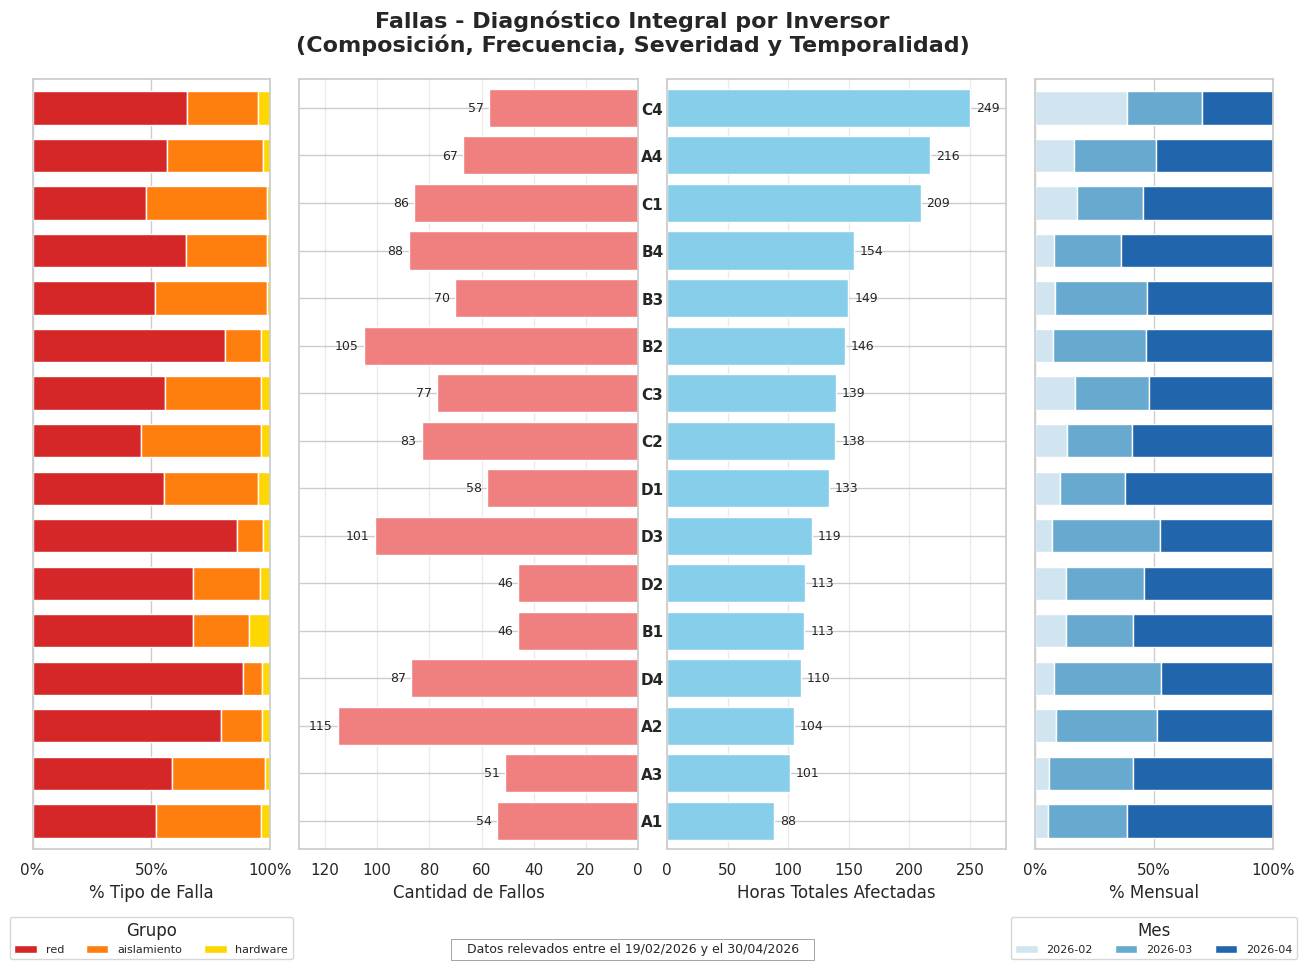

In [ ]:
# Prepara los datos base para el orden del gráfico (Ejes centrales)
resumen_inv = df_fallas_clima.groupby('inversor').agg({
    'evento_minutos': 'sum',
    'nombre_de_alerta': 'count'
}).rename(columns={'nombre_de_alerta': 'conteo_eventos'})

# Ordena para la estructura de pirámide
resumen_inv = resumen_inv.sort_values('evento_minutos', ascending=True)

inversores = resumen_inv.index
tiempo = resumen_inv['evento_minutos'] / 60  # Convertimos a horas
conteo = resumen_inv['conteo_eventos']

# Preparo datos de distribución (Normalizados al 100%)
dist_grupo = pd.crosstab(df_fallas_clima['inversor'], df_fallas_clima['grupo_falla'], normalize='index').reindex(inversores)
dist_mes = pd.crosstab(df_fallas_clima['inversor'], df_fallas_clima['mes'].astype(str), normalize='index').reindex(inversores)# 1. Preparar datos (manteniendo la lógica anterior)
dist_grupo = pd.crosstab(df_fallas_clima['inversor'], df_fallas_clima['grupo_falla'], normalize='index').reindex(inversores)
dist_mes = pd.crosstab(df_fallas_clima['inversor'], df_fallas_clima['mes'].astype(str), normalize='index').reindex(inversores)

# Configuración de colores
colores_dist = {'red': '#d62728', 'aislamiento': '#ff7f0e', 'hardware': '#ffd700'}
# Nueva escala de azules para los meses
colores_mes = {'2026-02': '#d1e5f0', '2026-03': '#67a9cf', '2026-04': '#2166ac'}

categorias_grupo = [c for c in ['red', 'aislamiento', 'hardware'] if c in dist_grupo.columns]
categorias_mes = sorted(dist_mes.columns)

# Configura la figura
fig, (ax0, ax1, ax2, ax3) = plt.subplots(1, 4, figsize=(16, 10), sharey=True,
                                         gridspec_kw={'width_ratios': [0.7, 1, 1, 0.7]})

plt.subplots_adjust(wspace=0.1)

# --- AX0: DISTRIBUCIÓN POR GRUPO (Izquierda) ---
left = np.zeros(len(inversores))
for cat in categorias_grupo:
    ax0.barh(inversores, dist_grupo[cat], left=left, label=cat,
             color=colores_dist.get(cat, '#7f7f7f'), edgecolor='white', height=0.7)
    left += dist_grupo[cat]
ax0.set_xlabel('% Tipo de Falla')
ax0.set_xlim(0, 1)
ax0.set_xticks([0, 0.5, 1])
ax0.set_xticklabels(['0%', '50%', '100%'])
ax0.tick_params(axis='y', left=False, labelleft=False)
ax0.set_ylim(-0.6, len(inversores) - 0.4)

# --- AX1: CONTEO DE EVENTOS (Frecuencia) ---
ax1.barh(inversores, conteo, color='lightcoral', edgecolor='white')
ax1.invert_xaxis()
ax1.grid(axis='x', linestyle='-', alpha=0.4)
ax1.set_xlabel('Cantidad de Fallos')
ax1.set_xlim(130, 0)
ax1.tick_params(axis='y', which='both', labelleft=False, labelright=True, left=False, right=False, pad=4.2)
ax1.set_yticklabels(inversores, ha='center', fontweight='bold')
ax1.set_ylim(-0.6, len(inversores) - 0.4)
for i, v in enumerate(conteo):
    ax1.text(v + 2, i, str(int(v)), va='center', ha='right', fontsize=9)

# --- AX2: HORAS AFECTADAS (Severidad) ---
ax2.barh(inversores, tiempo, color='skyblue', edgecolor='white')
ax2.grid(axis='x', linestyle='-', alpha=0.4)
ax2.set_xlabel('Horas Totales Afectadas')
ax2.set_xlim(0, 280)
ax2.tick_params(axis='y', left=False, right=False)
ax2.set_ylim(-0.6, len(inversores) - 0.4)
for i, v in enumerate(tiempo):
    ax2.text(v + 5, i, f'{int(v)}', va='center', ha='left', fontsize=9)

# --- AX3: DISTRIBUCIÓN POR MES (Derecha - Escala de Azules) ---
left_m = np.zeros(len(inversores))
for mes in categorias_mes:
    ax3.barh(inversores, dist_mes[mes], left=left_m, label=mes,
             color=colores_mes.get(mes, '#084594'), edgecolor='white', height=0.7)
    left_m += dist_mes[mes]
ax3.set_xlabel('% Mensual')
ax3.set_xlim(0, 1)
ax3.set_xticks([0, 0.5, 1])
ax3.set_xticklabels(['0%', '50%', '100%'])
ax3.tick_params(axis='y', left=False)
ax3.set_ylim(-0.6, len(inversores) - 0.4)

# 3. Estética final, Leyendas y Recuadro Informativo
ax0.legend(title="Grupo", loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=8)
ax3.legend(title="Mes", loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=8)


# Recuadro centrado abajo de las gráficas principales (AX1 y AX2)
fig.text(0.5, 0.01, "   Datos relevados entre el 19/02/2026 y el 30/04/2026   ",
         ha="center", va="center", fontsize=9,
         bbox=dict(boxstyle="square", fc="white", ec="black", lw=0.5, alpha=0.5))

plt.suptitle('Fallas - Diagnóstico Integral por Inversor\n(Composición, Frecuencia, Severidad y Temporalidad)',
             fontsize=16, fontweight='bold', y=0.95)

plt.show()

#### Fallas minutos x mes

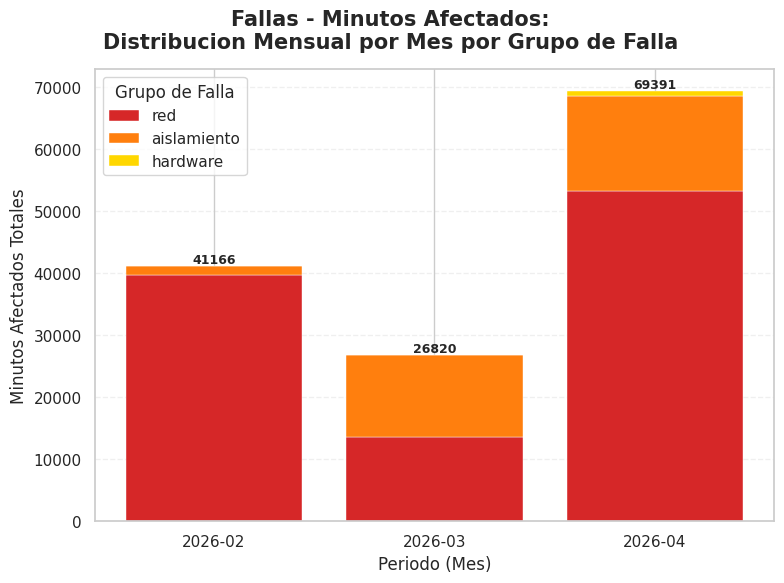

In [ ]:
# 1. Preparación de la dimensión temporal
# Aseguramos que la columna 'time' sea datetime y extraemos el mes (formato YYYY-MM)
df_fallas_clima['time'] = pd.to_datetime(df_fallas_clima['fecha_alerta'])
df_fallas_clima['mes'] = df_fallas_clima['time'].dt.to_period('M')

# 2. Agrupación y pivoteo de datos
# Sumamos los 'evento_minutos' por mes y grupo de falla
df_pivot = df_fallas_clima.groupby(['mes', 'grupo_falla'])['evento_minutos'].sum().unstack(fill_value=0)

# Convertimos el índice a string para que Matplotlib lo maneje correctamente en el eje X
df_pivot.index = df_pivot.index.astype(str)

# 3. Configuración de colores (Consistentes con los análisis anteriores)
colores_dict = {
    'red': '#d62728',          # Rojo (Criticidad de red)
    'aislamiento': '#ff7f0e',  # Naranja (Humedad/Aislamiento)
    'hardware': '#ffd700'      # Azul (Componentes internos)
}

# Ordenamos las categorías por importancia para la visualización
categorias = [c for c in ['red', 'aislamiento', 'hardware'] if c in df_pivot.columns]
valores_cintas = [df_pivot[c] for c in categorias]

# 4. Creación del Gráfico de Barras Apiladas
plt.figure(figsize=(8, 6))

# Inicializamos el "piso" de las barras en cero
bottom = np.zeros(len(df_pivot))

# Iteramos sobre las categorías para apilarlas manualmente
for cat in categorias:
    plt.bar(
        df_pivot.index,
        df_pivot[cat],
        bottom=bottom,
        label=cat,
        color=colores_dict[cat],
        #alpha=0.85,
        edgecolor='white',
        linewidth=0.3
    )
    # Actualizamos el piso para la siguiente categoría
    bottom += df_pivot[cat].values

# Estética y etiquetas
plt.title('Fallas - Minutos Afectados:\nDistribucion Mensual por Mes por Grupo de Falla', fontsize=15, fontweight='bold', pad=2,x=0.435, y=1.04)
plt.xlabel('Periodo (Mes)', fontsize=12)
plt.ylabel('Minutos Afectados Totales', fontsize=12)
plt.legend(loc='upper left', title="Grupo de Falla", frameon=True)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Opcional: Añadir el total sobre cada barra para mayor claridad
totales = df_pivot[categorias].sum(axis=1)
for i, total in enumerate(totales):
    plt.text(i, total + 5, f'{int(total)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#### Boxplot duracion x grupo x inversor x tipo de fallo

/tmp/ipykernel_27973/440823283.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_box,
/tmp/ipykernel_27973/440823283.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_box,
/tmp/ipykernel_27973/440823283.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_box,
/tmp/ipykernel_27973/440823283.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_box,


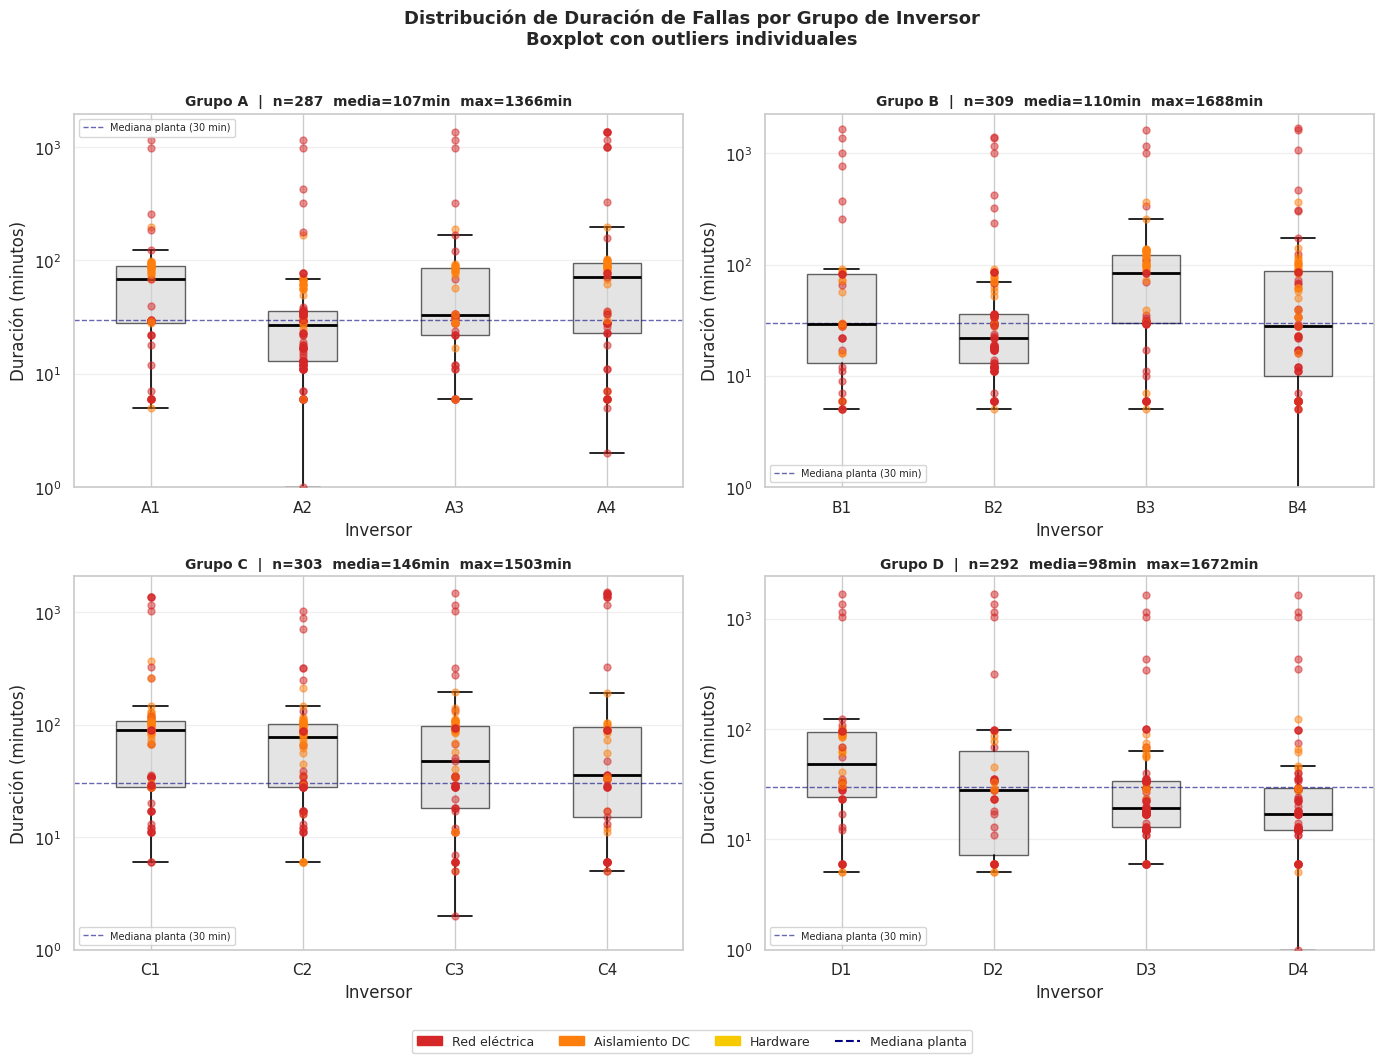

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Duración de Fallas por Grupo de Inversor\n'
             'Boxplot con outliers individuales',
             fontsize=13, fontweight='bold', y=1.01)

grupos = ['A', 'B', 'C', 'D']
colores_falla = {
    'red':         '#d62728',
    'aislamiento': '#ff7f0e',
    'hardware':    '#f7c900'
}

# Mapeo de fallas a grupos
mapa_grupos_falla = {
    'Fallo_BajaFrec_CA F48':              'red',
    'Fallo_SobreFrec_CA F47':             'red',
    'Fallo_SobreVolt_WU_CA F41':          'red',
    'Fallo_SobreVolt_VW_CA F43':          'red',
    'Fallo_SobreVolt_UV_CA F45':          'red',
    'Fallo_NoHayUtilidad_CA F35':         'red',
    'Fallo_ContactorPpal_CA F30':         'red',
    'Fallo_Aislam_CC F24':                'aislamiento',
    'Fallo_OC_GFCI_Tz F23':              'aislamiento',
    'Fallo_SobreCorr_CC_Tz F20':         'aislamiento',
    'Fallo_DesequilBus F26':              'aislamiento',
    'Fallo_BajaTemp_Disispador IGBT F64': 'hardware',
}

df_fallas_clima['grupo_falla'] = df_fallas_clima['nombre_de_alerta'].map(mapa_grupos_falla)
df_fallas_clima['grupo_inversor'] = df_fallas_clima['inversor'].str[0]

for ax, grupo in zip(axes.flatten(), grupos):

    df_grupo = df_fallas_clima[
        df_fallas_clima['grupo_inversor'] == grupo
    ].copy()

    # Inversores del grupo ordenados
    inversores = sorted(df_grupo['inversor'].unique())

    # Datos por inversor
    datos_box  = [df_grupo[df_grupo['inversor'] == inv]['evento_minutos'].values
                  for inv in inversores]

    # Boxplot base
    bp = ax.boxplot(datos_box,
                    labels=inversores,
                    patch_artist=True,
                    showfliers=False,   # los outliers los graficamos manualmente
                    medianprops=dict(color='black', linewidth=2),
                    boxprops=dict(facecolor='lightgray', alpha=0.6),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2))

    # Superponer puntos individuales coloreados por tipo de falla
    for i, inv in enumerate(inversores, start=1):
        df_inv = df_grupo[df_grupo['inversor'] == inv]
        for _, row in df_inv.iterrows():
            color = colores_falla.get(row['grupo_falla'], 'gray')
            ax.scatter(i, row['evento_minutos'],
                      color=color, alpha=0.5, s=25, zorder=3)

    # Línea de referencia: mediana general de la planta
    mediana_planta = df_fallas_clima['evento_minutos'].median()
    ax.axhline(y=mediana_planta, color='navy', linestyle='--',
               linewidth=1, alpha=0.6, label=f'Mediana planta ({mediana_planta:.0f} min)')

    ax.set_title(f'Grupo {grupo}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Inversor')
    ax.set_ylabel('Duración (minutos)')
    ax.set_yscale('log')
    ax.set_ylim(bottom=1)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=7)

    # Estadísticas en el título secundario
    n_total   = len(df_grupo)
    dur_media = df_grupo['evento_minutos'].mean()
    dur_max   = df_grupo['evento_minutos'].max()
    ax.set_title(f'Grupo {grupo}  |  n={n_total}  '
                 f'media={dur_media:.0f}min  max={dur_max:.0f}min',
                 fontweight='bold', fontsize=10)

# Leyenda global
from matplotlib.patches import Patch
leyenda_global = [
    Patch(color=colores_falla['red'],         label='Red eléctrica'),
    Patch(color=colores_falla['aislamiento'], label='Aislamiento DC'),
    Patch(color=colores_falla['hardware'],    label='Hardware'),
    Line2D([0], [0], color='navy', linestyle='--', label='Mediana planta'),
]
fig.legend(handles=leyenda_global, loc='lower center',
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()

plt.show()

#### FRECUENCIA vs DURACIÓN PROMEDIO POR INVERSOR

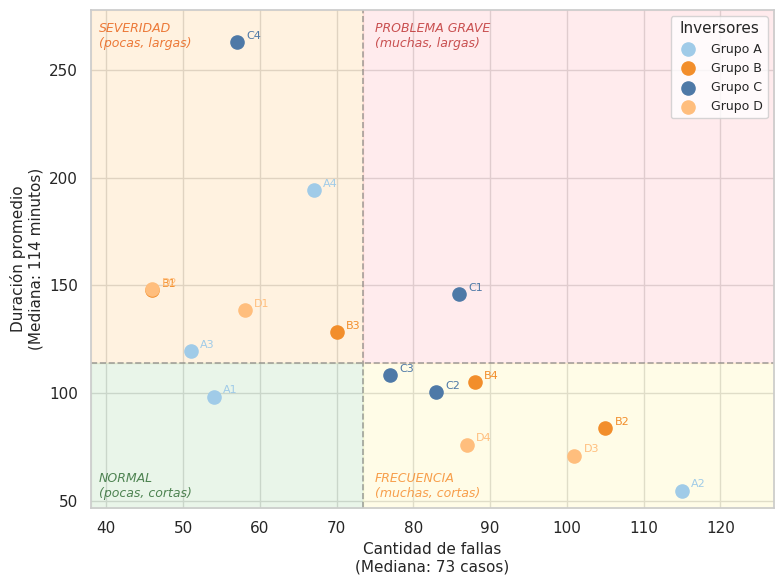

In [ ]:
# =====================================================
# SCATTER: FRECUENCIA vs DURACIÓN PROMEDIO POR INVERSOR
# Cuadrantes: Normal / Frecuencia / Severidad / Problema grave
# =====================================================

# Preparo datos por inversor
resumen_inv = (
    df_fallas_clima
    .groupby('inversor')
    .agg(
        n_fallas       = ('nombre_de_alerta', 'count'),
        duracion_media = ('evento_minutos', 'mean')
    )
    .reset_index()
)

# Puntos de corte: mediana de cada eje
corte_x = resumen_inv['n_fallas'].median()
corte_y = resumen_inv['duracion_media'].median()

# Colores por grupo de inversor
color_grupo = {
    'C': '#4e79a7',
    'A': '#a0cbe8',
    'B': '#f28e2b',
    'D': '#ffbe7d'
}
# Asignacion anterior
#color_grupo = {'A': '#1f77b4', 'B': '#2ca02c', 'C': '#d62728', 'D': '#9467bd'}
resumen_inv['grupo']  = resumen_inv['inversor'].str[0]
resumen_inv['color']  = resumen_inv['grupo'].map(color_grupo)

# Figura
fig, ax = plt.subplots(figsize=(8, 6))
fig.subplots_adjust(bottom=0.15)

# ── Fondos de cuadrantes ──────────────────────────────────────────
xlim = (resumen_inv['n_fallas'].min() - 8,
        resumen_inv['n_fallas'].max() + 12)
ylim = (resumen_inv['duracion_media'].min() - 8,
        resumen_inv['duracion_media'].max() + 15)

# Q3 - Pocas fallas, duración larga  (Severidad)     → naranja claro
ax.fill_betweenx([corte_y, ylim[1]], xlim[0], corte_x,
                 color='#ffe0b2', alpha=0.4)
# Q4 - Muchas fallas, duración larga (Problema grave) → rojo claro
ax.fill_betweenx([corte_y, ylim[1]], corte_x, xlim[1],
                 color='#ffcdd2', alpha=0.4)
# Q1 - Pocas fallas, duración corta  (Normal)         → verde claro
ax.fill_betweenx([ylim[0], corte_y], xlim[0], corte_x,
                 color='#c8e6c9', alpha=0.4)
# Q2 - Muchas fallas, duración corta (Frecuencia)     → amarillo claro
ax.fill_betweenx([ylim[0], corte_y], corte_x, xlim[1],
                 color='#fff9c4', alpha=0.4)

# ── Líneas de corte ───────────────────────────────────────────────
ax.axvline(corte_x, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
ax.axhline(corte_y, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)

# ── Etiquetas de cuadrante ────────────────────────────────────────
kw_label = dict(fontsize=9, alpha=0.75, style='italic')
ax.text(xlim[0] + 1,  ylim[1] - 17,  'SEVERIDAD\n(pocas, largas)',
        color='#e65100', **kw_label)
ax.text(corte_x + 1.5,  ylim[1] - 17,  'PROBLEMA GRAVE\n(muchas, largas)',
        color='#b71c1c', **kw_label)
ax.text(xlim[0] + 1,  ylim[0] + 5,  'NORMAL\n(pocas, cortas)',
        color='#1b5e20', **kw_label)
ax.text(corte_x + 1.5,  ylim[0] + 5,  'FRECUENCIA\n(muchas, cortas)',
        color='#f57f17', **kw_label)

# ── Puntos por inversor ───────────────────────────────────────────
for grupo, df_g in resumen_inv.groupby('grupo'):
    ax.scatter(
        df_g['n_fallas'], df_g['duracion_media'],
        color=color_grupo[grupo],
        s=90, zorder=5, alpha=1,
        label=f'Grupo {grupo}'
    )

# ── Etiquetas de inversor ─────────────────────────────────────────
for _, row in resumen_inv.iterrows():
    # Offset para evitar solapamiento con el punto
    offset_x = 1.2
    offset_y = 1.5
    ax.annotate(
        row['inversor'],
        xy=(row['n_fallas'], row['duracion_media']),
        xytext=(row['n_fallas'] + offset_x, row['duracion_media'] + offset_y),
        fontsize=8,
        color=color_grupo[row['grupo']]
    )

# ── Personalización ───────────────────────────────────────────────
ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel(f'Cantidad de fallas\n(Mediana: {int(corte_x)} casos)',
              fontsize=11)
ax.set_ylabel(f'Duración promedio\n(Mediana: {corte_y:.0f} minutos)',
              fontsize=11)

ax.legend(title='Inversores', loc='upper right', fontsize=9, title_fontsize=11)
plt.tight_layout()
plt.show()


##### Tabla resumen inversores por cuadrante

In [ ]:
# ── Tabla resumen por cuadrante ───────────────────────────────────
print("Clasificación por cuadrante:")
print(f"{'Inversor':<10} {'Fallas':>7} {'Dur prom':>10}  Cuadrante")
print("-" * 50)
for _, row in resumen_inv.sort_values('n_fallas', ascending=False).iterrows():
    alto_x = row['n_fallas']     > corte_x
    alto_y = row['duracion_media'] > corte_y
    if     alto_x and     alto_y: cuadrante = 'PROBLEMA GRAVE'
    elif   alto_x and not alto_y: cuadrante = 'FRECUENCIA'
    elif not alto_x and     alto_y: cuadrante = 'SEVERIDAD'
    else:                           cuadrante = 'NORMAL'
    print(f"{row['inversor']:<10} {row['n_fallas']:>7.0f} "
          f"{row['duracion_media']:>10.1f}  {cuadrante}")

Clasificación por cuadrante:
Inversor    Fallas   Dur prom  Cuadrante
--------------------------------------------------
A2             115       54.7  FRECUENCIA
B2             105       83.8  FRECUENCIA
D3             101       71.0  FRECUENCIA
B4              88      105.2  FRECUENCIA
D4              87       76.0  FRECUENCIA
C1              86      146.0  PROBLEMA GRAVE
C2              83      100.3  FRECUENCIA
C3              77      108.4  FRECUENCIA
B3              70      128.2  SEVERIDAD
A4              67      194.1  SEVERIDAD
D1              58      138.4  SEVERIDAD
C4              57      262.9  SEVERIDAD
A1              54       98.4  NORMAL
A3              51      119.4  SEVERIDAD
B1              46      148.0  SEVERIDAD
D2              46      148.4  SEVERIDAD


#### Analisis por Grupos

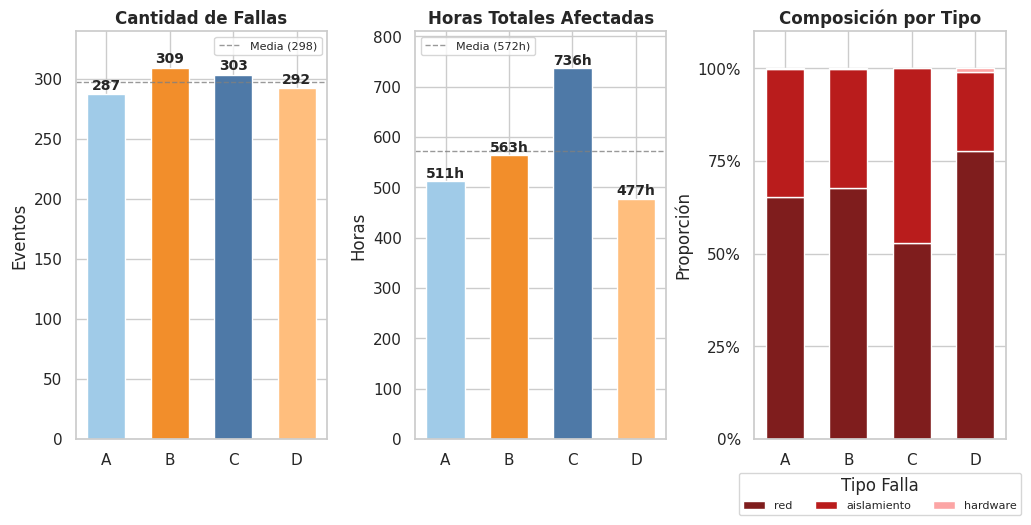

In [ ]:
# 1. Preparar datos por grupo (A, B, C, D)
resumen_grupo = (
    df_fallas_clima
    .assign(grupo=df_fallas_clima['inversor'].str[0])
    .groupby('grupo')
    .agg(
        n_fallas          = ('nombre_de_alerta', 'count'),
        horas_afectadas   = ('evento_minutos', lambda x: x.sum() / 60),
        duracion_prom_min = ('evento_minutos', 'mean')
    )
    .reset_index()
)

# Diccionario unificado de colores
colores_grupos_dict = {
    'C': '#4e79a7',
    'A': '#a0cbe8',
    'B': '#f28e2b',
    'D': '#ffbe7d'
}

# 2. Composición por tipo de falla dentro de cada grupo
comp_grupo = (
    df_fallas_clima
    .assign(grupo=df_fallas_clima['inversor'].str[0])
    .groupby(['grupo', 'grupo_falla'])
    .size()
    .unstack(fill_value=0)
)
comp_grupo_pct = comp_grupo.div(comp_grupo.sum(axis=1), axis=0)

# ── Figura con tres subplots ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 6))
fig.subplots_adjust(bottom=0.2, wspace=0.35)

grupos = resumen_grupo['grupo'].tolist()
# Asignamos colores basados en nuestro diccionario unificado
colores_barras = [colores_grupos_dict.get(g, '#7f7f7f') for g in grupos]

# Panel 1 — Frecuencia
ax1 = axes[0]
bars = ax1.bar(grupos, resumen_grupo['n_fallas'],
                color=colores_barras, width=0.6, edgecolor='white')
ax1.axhline(resumen_grupo['n_fallas'].mean(), color='gray',
            linestyle='--', linewidth=1, alpha=0.8,
            label=f'Media ({resumen_grupo["n_fallas"].mean():.0f})')

for bar, val in zip(bars, resumen_grupo['n_fallas']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(int(val)), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_title('Cantidad de Fallas', fontweight='bold', pad=5)
ax1.set_ylabel('Eventos')
ax1.legend(fontsize=8)
ax1.set_ylim(0, resumen_grupo['n_fallas'].max() * 1.1)

# Panel 2 — Severidad (horas)
ax2 = axes[1]
bars2 = ax2.bar(grupos, resumen_grupo['horas_afectadas'],
                color=colores_barras, width=0.6, edgecolor='white')
ax2.axhline(resumen_grupo['horas_afectadas'].mean(), color='gray',
            linestyle='--', linewidth=1, alpha=0.8,
            label=f'Media ({resumen_grupo["horas_afectadas"].mean():.0f}h)')

for bar, val in zip(bars2, resumen_grupo['horas_afectadas']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{int(val)}h', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_title('Horas Totales Afectadas', fontweight='bold', pad=5)
ax2.set_ylabel('Horas')
ax2.legend(fontsize=8)
ax2.set_ylim(0, resumen_grupo['horas_afectadas'].max() * 1.1)

# Panel 3 — Composición por tipo de falla
ax3 = axes[2]
bottom = np.zeros(len(grupos))
# Colores de falla
colores_falla = {'red': '#7f1d1d', 'aislamiento': '#b91c1c', 'hardware': '#fca5a5'}

for tipo in ['red', 'aislamiento', 'hardware']:
    if tipo in comp_grupo_pct.columns:
        vals = [comp_grupo_pct.loc[g, tipo] if g in comp_grupo_pct.index else 0 for g in grupos]
        ax3.bar(grupos, vals, bottom=bottom,
                color=colores_falla[tipo], label=tipo,
                width=0.6, edgecolor='white')
        bottom += np.array(vals)

ax3.set_title('Composición por Tipo', fontweight='bold', pad=5)
ax3.set_ylabel('Proporción')
ax3.set_ylim(0, 1.1)
ax3.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax3.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
ax3.legend(title="Tipo Falla", fontsize=8, loc='lower center', ncols=3, bbox_to_anchor=(0.5, -0.2))
plt.show()

##### Tabla resumen

In [ ]:
# Tabla resumen
print("Resumen por grupo:")
print(resumen_grupo.to_string(index=False))

Resumen por grupo:
grupo  n_fallas  horas_afectadas  duracion_prom_min
    A       287       511.550000         106.944251
    B       309       563.966667         109.508091
    C       303       736.833333         145.907591
    D       292       477.266667          98.068493


In [ ]:
# Verifico cuánto impacta C4 en el promedio del grupo C
sin_c4 = df_fallas_clima[df_fallas_clima['inversor'] != 'C4']
resumen_sin_c4 = (
    sin_c4
    .assign(grupo=sin_c4['inversor'].str[0])
    .groupby('grupo')
    .agg(
        n_fallas          = ('nombre_de_alerta', 'count'),
        horas_afectadas   = ('evento_minutos', lambda x: x.sum() / 60),
        duracion_prom_min = ('evento_minutos', 'mean')
    )
    .reset_index()
)
print("Sin C4:")
print(resumen_sin_c4.to_string(index=False))

Sin C4:
grupo  n_fallas  horas_afectadas  duracion_prom_min
    A       287       511.550000         106.944251
    B       309       563.966667         109.508091
    C       246       487.100000         118.804878
    D       292       477.266667          98.068493


C4 tiene un impacto significativo en el rendimiento general del grupo

#### Boxplot eventos por grupo

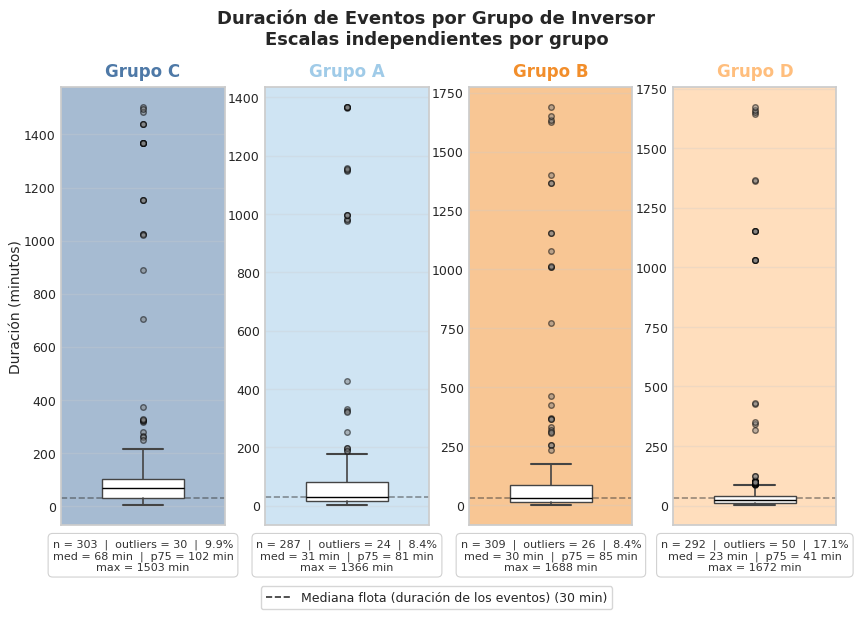

In [ ]:
# =====================================================
# BOXPLOT DURACIÓN DE EVENTOS POR GRUPO DE INVERSOR
# =====================================================

orden_grupos = ['C', 'A', 'B', 'D']

colores_grupos_dict = {
    'C': '#4e79a7',
    'A': '#a0cbe8',
    'B': '#f28e2b',
    'D': '#ffbe7d'
}

fig, axes = plt.subplots(1, 4, figsize=(10, 6))
fig.subplots_adjust(bottom=0.15, wspace=0.25)

mediana_flota = df_fallas_clima['evento_minutos'].median()

for ax, grupo in zip(axes, orden_grupos):

    datos = df_fallas_clima[
        df_fallas_clima['grupo_inversor'] == grupo
    ]['evento_minutos'].values

    color = colores_grupos_dict[grupo]

    # ── Fondo sombreado ───────────────────────────────────────
    ax.set_facecolor(color)
    ax.patch.set_alpha(0.5)

    # ── Boxplot neutro ────────────────────────────────────────
    bp = ax.boxplot(
        datos,
        positions=[1],
        patch_artist=True,
        widths=0.5,
        showfliers=True,
        flierprops=dict(
            marker='o',
            markerfacecolor='gray',
            markersize=4,
            alpha=0.5,
            linestyle='none'
        ),
        medianprops=dict(color='black',    linewidth=1),
        boxprops=dict(facecolor='white',   linewidth=1,
                      edgecolor='#444444'),
        whiskerprops=dict(color='#444444', linewidth=1.2),
        capprops=dict(color='#444444',     linewidth=1.5),
        zorder=3
    )

    # ── Mediana flota como referencia ─────────────────────────
    ax.axhline(
        mediana_flota,
        color='#333333',
        linestyle='--',
        linewidth=1.2,
        alpha=0.5,
        zorder=2
    )

    # ── Estadísticas debajo del boxplot (fuera del área de datos) ─
    n        = len(datos)
    mediana  = int(np.median(datos))
    p25      = int(np.percentile(datos, 25))
    p75      = int(np.percentile(datos, 75))
    maximo   = int(np.max(datos))
    iqr      = p75 - p25
    outliers = int(((datos < (p25 - 1.5 * iqr)) |
                    (datos > (p75 + 1.5 * iqr))).sum())

    ax.text(
        0.5, -0.03,
        f'n = {n}  |  outliers = {outliers}  |  {(outliers/n*100):.1f}%\n'
        f'med = {mediana} min  |  p75 = {p75} min\n'
        f'max = {maximo} min',
        ha='center', va='top',
        fontsize=8, color='#333333',
        transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#cccccc', linewidth=0.8, alpha=0.9)
    )

    # ── Personalización por subplot ───────────────────────────
    ax.set_title(f'Grupo {grupo}',
                 fontsize=12, fontweight='bold',
                 color=color, pad=8)
    ax.set_ylabel('Duración (minutos)' if grupo == 'C' else '',
                  fontsize=10, labelpad=0)
    ax.set_xticks([])
    ax.grid(axis='y', alpha=0.3, zorder=1)
    ax.set_xlim(0.5, 1.5)
    ax.tick_params(axis='y', pad=-2, labelsize=9)

# ── Título general ────────────────────────────────────────────────
fig.suptitle(
    'Duración de Eventos por Grupo de Inversor\n'
    'Escalas independientes por grupo',
    fontsize=13, fontweight='bold', y=1.01
)

# ── Leyenda de mediana flota ──────────────────────────────────────
from matplotlib.lines import Line2D
leyenda = [Line2D([0], [0], color='#333333', linestyle='--',
                  linewidth=1.2,
                  label=f'Mediana flota (duración de los eventos) ({int(mediana_flota)} min)')]
fig.legend(handles=leyenda, loc='lower center',
           bbox_to_anchor=(0.5, 0),
           fontsize=9, frameon=True)


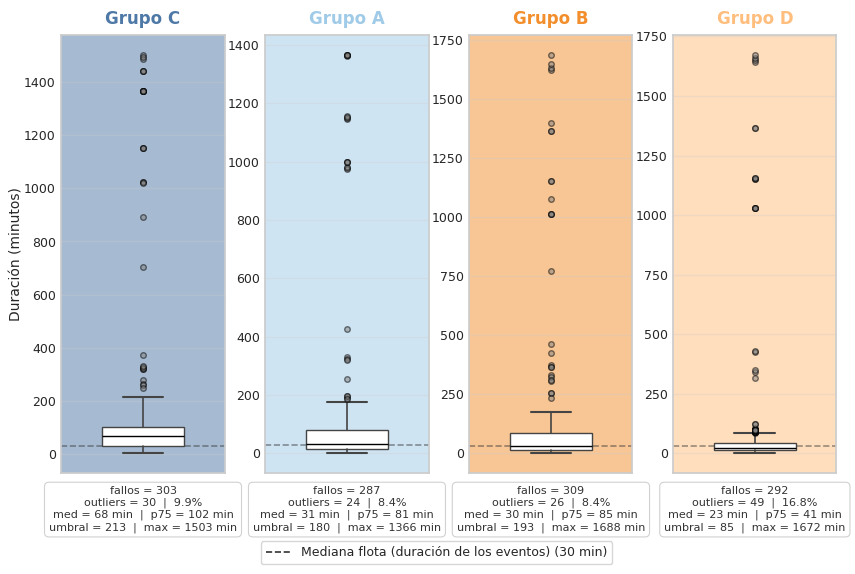

In [ ]:
# =====================================================
# BOXPLOT DURACIÓN DE EVENTOS POR GRUPO DE INVERSOR
# =====================================================

orden_grupos = ['C', 'A', 'B', 'D']

colores_grupos_dict = {
    'C': '#4e79a7',
    'A': '#a0cbe8',
    'B': '#f28e2b',
    'D': '#ffbe7d'
}

# Ajustamos bottom de 0.15 a 0.28 para dar lugar a la 4° fila de datos
fig, axes = plt.subplots(1, 4, figsize=(10, 6))
fig.subplots_adjust(bottom=0.15, wspace=0.25)

mediana_flota = df_fallas_clima['evento_minutos'].median()

for ax, grupo in zip(axes, orden_grupos):

    col_grupo = 'grupo_inversor' if 'grupo_inversor' in df_fallas_clima.columns else 'grupo'
    datos = df_fallas_clima[df_fallas_clima[col_grupo] == grupo]['evento_minutos'].values

    color = colores_grupos_dict[grupo]

    # ── Fondo sombreado ───────────────────────────────────────
    ax.set_facecolor(color)
    ax.patch.set_alpha(0.5)

    # ── Boxplot neutro ────────────────────────────────────────
    bp = ax.boxplot(
        datos,
        positions=[1],
        patch_artist=True,
        widths=0.5,
        showfliers=True,
        flierprops=dict(
            marker='o',
            markerfacecolor='gray',
            markersize=4,
            alpha=0.5,
            linestyle='none'
        ),
        medianprops=dict(color='black',    linewidth=1),
        boxprops=dict(facecolor='white',   linewidth=1,
                      edgecolor='#444444'),
        whiskerprops=dict(color='#444444', linewidth=1.2),
        capprops=dict(color='#444444',     linewidth=1.5),
        zorder=3
    )

    # ── Mediana flota como referencia ─────────────────────────
    ax.axhline(
        mediana_flota,
        color='#333333',
        linestyle='--',
        linewidth=1.2,
        alpha=0.5,
        zorder=2
    )

    # ── Métricas operativas ───────────────────────────────────
    n        = len(datos)
    mediana  = (np.median(datos))
    p25      = (np.percentile(datos, 25))
    p75      = (np.percentile(datos, 75))
    maximo   = (np.max(datos))
    iqr      = p75 - p25

    # Cálculo del umbral dinámico por grupo
    umbral   = p75 + 1.5 * iqr

    outliers = int(((datos < (p25 - 1.5 * iqr)) |
                    (datos > (p75 + 1.5 * iqr))).sum())
    pct_out  = outliers / n * 100

    # ── Estadísticas distribuidas en 4 renglones ──────────────
    ax.text(
        0.5, -0.03,
        f'fallos = {n}\n'
        f'outliers = {outliers}  |  {pct_out:.1f}%\n'
        f'med = {int(mediana)} min  |  p75 = {int(p75)} min\n'
        f'umbral = {int(umbral)}  |  max = {int(maximo)} min',
        ha='center', va='top',
        fontsize=8, color='#333333',
        transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#cccccc', linewidth=0.8, alpha=0.9)
    )

    # ── Personalización por subplot ───────────────────────────
    ax.set_title(f'Grupo {grupo}',
                 fontsize=12, fontweight='bold',
                 color=color, pad=8)
    ax.set_ylabel('Duración (minutos)' if grupo == 'C' else '',
                  fontsize=10, labelpad=0)
    ax.set_xticks([])
    ax.grid(axis='y', alpha=0.3, zorder=1)
    ax.set_xlim(0.5, 1.5)
    ax.tick_params(axis='y', pad=-2, labelsize=9)

# ── Leyenda de referencias ──
leyenda = [
    Line2D([0], [0], color='#333333', linestyle='--', linewidth=1.2,
           label=f'Mediana flota (duración de los eventos) ({int(mediana_flota):.0f} min)'),
]
fig.legend(handles=leyenda, loc='lower center',
           bbox_to_anchor=(0.5, -0.012), ncol=2, fontsize=9, frameon=True)

plt.show()

##### Tabla resumen

In [ ]:
# ── Tabla de estadísticas ──
print(f"\n{'Grupo':<8} {'N':>6} {'Mediana':>8} {'Media':>8} "
      f"{'P25':>6} {'P75':>6} {'Max':>8} {'Outliers':>9} {'% Out':>7}")
print("-" * 72)

for grupo in orden_grupos:
    d    = df_fallas_clima[
        df_fallas_clima['grupo_inversor'] == grupo
    ]['evento_minutos']
    p25  = d.quantile(0.25)
    p75  = d.quantile(0.75)
    iqr  = p75 - p25
    umb  = p75 + 1.5 * iqr
    out  = (d > umb).sum()
    pct  = out / len(d) * 100

    print(f"Grupo {grupo} {len(d):>7} {d.median():>8.0f} "
          f"{d.mean():>8.0f} {p25:>6.0f} {p75:>6.0f} "
          f"{d.max():>8.0f} {out:>9} {pct:>6.1f}%")


Grupo         N  Mediana    Media    P25    P75      Max  Outliers   % Out
------------------------------------------------------------------------
Grupo C     303       68      146     28    102     1503        30    9.9%
Grupo A     287       31      107     14     81     1366        24    8.4%
Grupo B     309       30      110     13     85     1688        26    8.4%
Grupo D     292       23       98     13     42     1672        49   16.8%


#### Grupo D

In [ ]:
# Diagnóstico grupo D
for inv in sorted(df_fallas_clima[
        df_fallas_clima['grupo_inversor'] == 'D']['inversor'].unique()):

    datos = df_fallas_clima[
        df_fallas_clima['inversor'] == inv]['evento_minutos']

    p25 = datos.quantile(0.25)
    p75 = datos.quantile(0.75)
    iqr = p75 - p25
    umbral = p75 + 1.5 * iqr
    outliers = (datos > umbral).sum()

    print(f"{inv}  n={len(datos):>3}  "
          f"med={int(datos.median()):>4}min  "
          f"p75={int(p75):>4}min  "
          f"umbral={int(umbral):>5}min  "
          f"outliers={outliers:>3}  "
          f"{outliers/len(datos)*100:.1f}%")

D1  n= 58  med=  48min  p75=  93min  umbral=  196min  outliers=  4  6.9%
D2  n= 46  med=  28min  p75=  63min  umbral=  146min  outliers=  5  10.9%
D3  n=101  med=  19min  p75=  34min  umbral=   65min  outliers= 13  12.9%
D4  n= 87  med=  17min  p75=  29min  umbral=   54min  outliers= 12  13.8%


##### Boxplot Grupo D x inversor

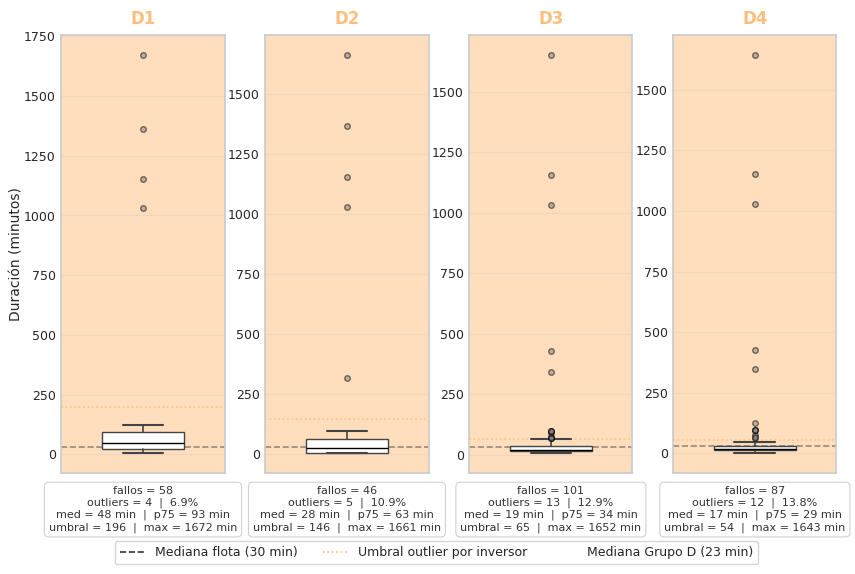

In [ ]:
# =====================================================
# BOXPLOT GRUPO D - DETALLE POR INVERSOR
# =====================================================

inversores_D = ['D1', 'D2', 'D3', 'D4']

fig, axes = plt.subplots(1, 4, figsize=(10, 6))
fig.subplots_adjust(bottom=0.15, wspace=0.25)

color_D = '#ffbe7d'

# 1. Mediana de la Flota (Global)
mediana_flota = df_fallas_clima['evento_minutos'].median()

# 2. Mediana del Grupo D (Calculada para la leyenda)
datos_grupo_D = df_fallas_clima[df_fallas_clima['inversor'].str.startswith('D')]['evento_minutos']
mediana_grupo_D = datos_grupo_D.median()

for ax, inv in zip(axes, inversores_D):

    datos = df_fallas_clima[
        df_fallas_clima['inversor'] == inv
    ]['evento_minutos'].values

    p25      = (np.percentile(datos, 25))
    p75      = (np.percentile(datos, 75))
    iqr      = p75 - p25
    umbral   = p75 + 1.5 * iqr
    mediana  = (np.median(datos))
    maximo   = (np.max(datos))
    n        = len(datos)
    outliers = (((datos < (p25 - 1.5 * iqr)) |
                    (datos > (p75 + 1.5 * iqr))).sum())
    pct_out  = outliers / n * 100

    # Fondo sombreado
    ax.set_facecolor(color_D)
    ax.patch.set_alpha(0.5)

    # Boxplot
    ax.boxplot(
        datos,
        positions=[1],
        patch_artist=True,
        widths=0.5,
        showfliers=True,
        flierprops=dict(marker='o', markerfacecolor='gray',
                        markersize=4, alpha=0.5, linestyle='none'),
        medianprops=dict(color='black',    linewidth=1),
        boxprops=dict(facecolor='white',   linewidth=1,
                      edgecolor='#444444'),
        whiskerprops=dict(color='#444444', linewidth=1.2),
        capprops=dict(color='#444444',     linewidth=1.5),
        zorder=3
    )

    # Mediana flota
    ax.axhline(mediana_flota, color='#333333', linestyle='--',
               linewidth=1.2, alpha=0.5, zorder=2)

    # Umbral de outlier
    ax.axhline(umbral, color=color_D, linestyle=':',
               linewidth=1.2, alpha=0.8, zorder=2)

    # Estadísticas debajo (Estructura de 4 filas solicitada)
    ax.text(
        0.5, -0.03,
        f'fallos = {n}\n'
        f'outliers = {outliers}  |  {pct_out:.1f}%\n'
        f'med = {int(mediana)} min  |  p75 = {int(p75)} min\n'
        f'umbral = {int(umbral)}  |  max = {int(maximo)} min',
        ha='center', va='top',
        fontsize=8, color='#333333',
        transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#cccccc', linewidth=0.8, alpha=0.9)
    )

    ax.set_title(inv, fontsize=12, fontweight='bold',
                 color=color_D, pad=8)
    ax.set_ylabel('Duración (minutos)' if inv == 'D1' else '',
                  fontsize=10, labelpad=0)
    ax.set_xticks([])
    ax.grid(axis='y', alpha=0.3, zorder=1)
    ax.set_xlim(0.5, 1.5)
    ax.tick_params(axis='y', pad=-2, labelsize=9)

leyenda = [
    Line2D([0], [0], color='#333333', linestyle='--', linewidth=1.2,
           label=f'Mediana flota ({int(mediana_flota)} min)'),
    Line2D([0], [0], color=color_D, linestyle=':', linewidth=1.2,
           label='Umbral outlier por inversor'),
    Line2D([0], [0], color='none', marker='none', # Entrada puramente informativa
           label=f'Mediana Grupo D ({int(mediana_grupo_D)} min)')
]

fig.legend(handles=leyenda, loc='lower center',
           bbox_to_anchor=(0.5, -0.012), ncol=3, fontsize=9, frameon=True)

plt.show()

#### Grupo C

##### Boxplot Grupo C

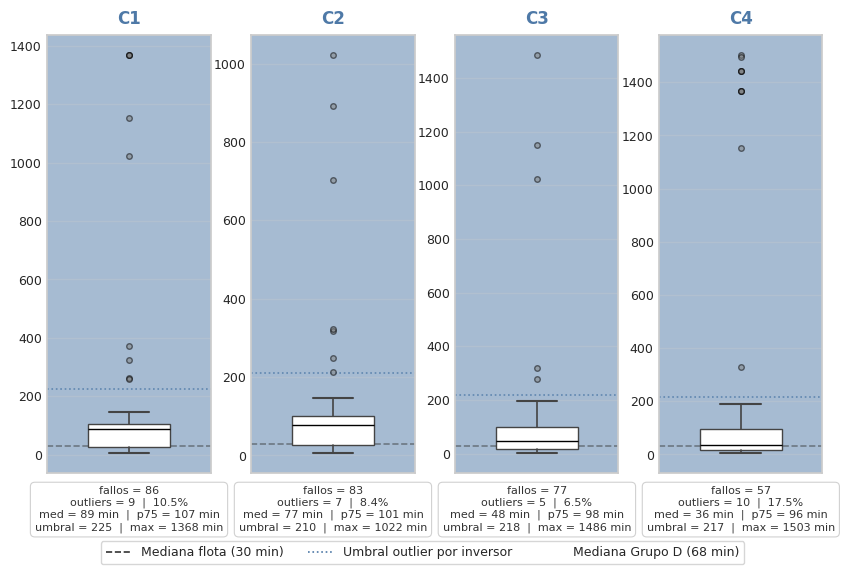

In [ ]:
# =====================================================
# BOXPLOT GRUPO C - DETALLE POR INVERSOR
# =====================================================

inversores_D = ['C1', 'C2', 'C3', 'C4']

fig, axes = plt.subplots(1, 4, figsize=(10, 6))
fig.subplots_adjust(bottom=0.15, wspace=0.25)

color_D = '#4e79a7'

# 1. Mediana de la Flota (Global)
mediana_flota = df_fallas_clima['evento_minutos'].median()

# 2. Mediana del Grupo D (Calculada para la leyenda)
datos_grupo_D = df_fallas_clima[df_fallas_clima['inversor'].str.startswith('C')]['evento_minutos']
mediana_grupo_D = datos_grupo_D.median()

for ax, inv in zip(axes, inversores_D):

    datos = df_fallas_clima[
        df_fallas_clima['inversor'] == inv
    ]['evento_minutos'].values

    p25      = (np.percentile(datos, 25))
    p75      = (np.percentile(datos, 75))
    iqr      = p75 - p25
    umbral   = p75 + 1.5 * iqr
    mediana  = (np.median(datos))
    maximo   = (np.max(datos))
    n        = len(datos)
    outliers = (((datos < (p25 - 1.5 * iqr)) |
                    (datos > (p75 + 1.5 * iqr))).sum())
    pct_out  = outliers / n * 100

    # Fondo sombreado
    ax.set_facecolor(color_D)
    ax.patch.set_alpha(0.5)

    # Boxplot
    ax.boxplot(
        datos,
        positions=[1],
        patch_artist=True,
        widths=0.5,
        showfliers=True,
        flierprops=dict(marker='o', markerfacecolor='gray',
                        markersize=4, alpha=0.5, linestyle='none'),
        medianprops=dict(color='black',    linewidth=1),
        boxprops=dict(facecolor='white',   linewidth=1,
                      edgecolor='#444444'),
        whiskerprops=dict(color='#444444', linewidth=1.2),
        capprops=dict(color='#444444',     linewidth=1.5),
        zorder=3
    )

    # Mediana flota
    ax.axhline(mediana_flota, color='#333333', linestyle='--',
               linewidth=1.2, alpha=0.5, zorder=2)

    # Umbral de outlier
    ax.axhline(umbral, color=color_D, linestyle=':',
               linewidth=1.2, alpha=0.8, zorder=2)

    # Estadísticas debajo (Estructura de 4 filas solicitada)
    ax.text(
        0.5, -0.03,
        f'fallos = {n}\n'
        f'outliers = {outliers}  |  {pct_out:.1f}%\n'
        f'med = {int(mediana)} min  |  p75 = {int(p75)} min\n'
        f'umbral = {int(umbral)}  |  max = {int(maximo)} min',
        ha='center', va='top',
        fontsize=8, color='#333333',
        transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#cccccc', linewidth=0.8, alpha=0.9)
    )

    ax.set_title(inv, fontsize=12, fontweight='bold',
                 color=color_D, pad=8)
    ax.set_ylabel('Duración (minutos)' if inv == 'D1' else '',
                  fontsize=10, labelpad=0)
    ax.set_xticks([])
    ax.grid(axis='y', alpha=0.3, zorder=1)
    ax.set_xlim(0.5, 1.5)
    ax.tick_params(axis='y', pad=-2, labelsize=9)

leyenda = [
    Line2D([0], [0], color='#333333', linestyle='--', linewidth=1.2,
           label=f'Mediana flota ({int(mediana_flota)} min)'),
    Line2D([0], [0], color=color_D, linestyle=':', linewidth=1.2,
           label='Umbral outlier por inversor'),
    Line2D([0], [0], color='none', marker='none', # Entrada puramente informativa
           label=f'Mediana Grupo D ({int(mediana_grupo_D)} min)')
]

fig.legend(handles=leyenda, loc='lower center',
           bbox_to_anchor=(0.5, -0.012), ncol=3, fontsize=9, frameon=True)

plt.show()

# Comprobaciones numericas

In [ ]:
# función para identificar las filas que son outliers
def filtrar_outliers(grupo):
    q25 = grupo['evento_minutos'].quantile(0.25)
    q75 = grupo['evento_minutos'].quantile(0.75)
    iqr = q75 - q25
    umbral_superior = q75 + 1.5 * iqr
    umbral_inferior = q25 - 1.5 * iqr

    # Retornamos una serie booleana: True si es outlier (superior o inferior)
    return (grupo['evento_minutos'] > umbral_superior) | (grupo['evento_minutos'] < umbral_inferior)

# 2. Aplicamos el filtro agrupando por la columna correspondiente
# (Ajusta 'grupo_inversor' por 'grupo' según el nombre exacto de tu columna)
col_grupo = 'grupo_inversor' if 'grupo_inversor' in df_fallas_clima.columns else 'grupo'

es_outlier = df_fallas_clima.groupby(col_grupo, group_keys=False).apply(filtrar_outliers)

# 3. Creamos el nuevo dataset con los registros filtrados
df_outliers = df_fallas_clima[es_outlier].copy()

# 4. Cambiamos el orden para que queden arriba las fallas más severas (opcional)
df_outliers = df_outliers.sort_values(by=['evento_minutos'], ascending=False)

# --- Verificación rápida ---
print(f"Dimensiones del dataset original: {df_fallas_clima.shape}")
print(f"Dimensiones del dataset de outliers: {df_outliers.shape}")
print(f"Porcentaje de datos atípicos extraídos: {(len(df_outliers) / len(df_fallas_clima) * 100):.1f}%")

Dimensiones del dataset original: (1191, 51)
Dimensiones del dataset de outliers: (129, 51)
Porcentaje de datos atípicos extraídos: 10.8%


/tmp/ipykernel_27973/4205005619.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  es_outlier = df_fallas_clima.groupby(col_grupo, group_keys=False).apply(filtrar_outliers)
/tmp/ipykernel_27973/4205005619.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_outliers = df_fallas_clima[es_outlier].copy()


In [ ]:
# Verificacion la composición de outliers del grupo C
# separando por umbral de duración

df_outliers_C = df_outliers[df_outliers['grupo_inversor'] == 'C'].copy()

# Defino los dos clusters
corte_clusters = 500  # minutos, ajustar si el output sugiere otro valor

cluster_bajo = df_outliers_C[df_outliers_C['evento_minutos'] <= corte_clusters]
cluster_alto = df_outliers_C[df_outliers_C['evento_minutos'] >  corte_clusters]

print(f"Outliers grupo C: {len(df_outliers_C)} total")
print()
print(f"Cluster bajo  (≤ {corte_clusters} min): {len(cluster_bajo)} eventos")
print(cluster_bajo['nombre_de_alerta'].value_counts().to_string())
print(f"Rango: {int(cluster_bajo['evento_minutos'].min())} - "
      f"{int(cluster_bajo['evento_minutos'].max())} min")
print()
print(f"Cluster alto  (> {corte_clusters} min): {len(cluster_alto)} eventos")
print(cluster_alto['nombre_de_alerta'].value_counts().to_string())
print(f"Rango: {int(cluster_alto['evento_minutos'].min())} - "
      f"{int(cluster_alto['evento_minutos'].max())} min")
print()


print("Distribución de outliers por inversor y rango:")
for inv in ['C1', 'C2', 'C3', 'C4']:
    datos_inv = df_outliers_C[df_outliers_C['inversor'] == inv]['evento_minutos']
    if len(datos_inv) == 0:
        continue
    bajo = (datos_inv <= corte_clusters).sum()
    alto = (datos_inv >  corte_clusters).sum()
    print(f"  {inv}: {bajo} bajos / {alto} altos  "
          f"| rango bajo: {int(datos_inv[datos_inv<=corte_clusters].max()) if bajo>0 else 'n/a'} min"
          f"| rango alto: {int(datos_inv[datos_inv>corte_clusters].min()) if alto>0 else 'n/a'} min")

Outliers grupo C: 30 total

Cluster bajo  (≤ 500 min): 10 eventos
nombre_de_alerta
Fallo_NoHayUtilidad_CA F35    8
Fallo_Aislam_CC F24           2
Rango: 249 - 372 min

Cluster alto  (> 500 min): 20 eventos
nombre_de_alerta
Fallo_NoHayUtilidad_CA F35    10
Fallo_SobreVolt_UV_CA F45      3
Fallo_SobreVolt_VW_CA F43      3
Fallo_SobreVolt_WU_CA F41      3
Fallo_BajaFrec_CA F48          1
Rango: 704 - 1503 min

Distribución de outliers por inversor y rango:
  C1: 4 bajos / 5 altos  | rango bajo: 372 min| rango alto: 1024 min
  C2: 3 bajos / 3 altos  | rango bajo: 322 min| rango alto: 704 min
  C3: 2 bajos / 3 altos  | rango bajo: 320 min| rango alto: 1024 min
  C4: 1 bajos / 9 altos  | rango bajo: 329 min| rango alto: 1152 min


In [ ]:
# =====================================================
# SEGMENTACIÓN DE OUTLIERS - TODOS LOS GRUPOS
# =====================================================

# Calculo umbral de outlier por inversor y marcar los outliers
registros_outlier = []

for inv in sorted(df_fallas_clima['inversor'].unique()):
    datos_inv = df_fallas_clima[df_fallas_clima['inversor'] == inv].copy()

    p25    = datos_inv['evento_minutos'].quantile(0.25)
    p75    = datos_inv['evento_minutos'].quantile(0.75)
    iqr    = p75 - p25
    umbral = p75 + 1.5 * iqr          # sin redondear → se usa para el filtro

    outliers_inv = datos_inv[datos_inv['evento_minutos'] > umbral].copy()

    # Redondear solo para visualización, nunca para el filtro
    outliers_inv['umbral_inversor'] = round(umbral, 1)
    outliers_inv['exceso_min']      = (
        outliers_inv['evento_minutos'] - umbral
    ).round(1)
    outliers_inv['exceso_pct']      = (
        (outliers_inv['evento_minutos'] - umbral) / umbral * 100
    ).round(1)

    registros_outlier.append(outliers_inv)

df_outliers = pd.concat(registros_outlier).reset_index(drop=True)

print(f"Total registros en dataset completo: {len(df_fallas_clima)}")
print(f"Total outliers identificados:        {len(df_outliers)}")
print(f"Porcentaje del total:                {len(df_outliers)/len(df_fallas_clima)*100:.1f}%")
print()
print("Distribución por grupo:")
print(df_outliers.groupby('grupo_inversor').agg(
    n_outliers    = ('evento_minutos', 'count'),
    med_duracion  = ('evento_minutos', 'median'),
    max_duracion  = ('evento_minutos', 'max'),
    exceso_medio  = ('exceso_pct',     'mean')
).round(1).to_string())
print()
print("Distribución por tipo de falla:")
print(df_outliers['nombre_de_alerta'].value_counts().to_string())
print()
print("Distribución por hora del día:")
print(df_outliers['fecha_referencia_abierta'].dt.hour
      .value_counts().sort_index().to_string())

Total registros en dataset completo: 1191
Total outliers identificados:        130
Porcentaje del total:                10.9%

Distribución por grupo:
                n_outliers  med_duracion  max_duracion  exceso_medio
grupo_inversor                                                      
A                       29         976.0          1366         372.0
B                       36         365.5          1688         377.4
C                       31        1024.0          1503         318.7
D                       34         345.5          1672         607.3

Distribución por tipo de falla:
nombre_de_alerta
Fallo_NoHayUtilidad_CA F35    74
Fallo_Aislam_CC F24           24
Fallo_SobreVolt_VW_CA F43      9
Fallo_SobreVolt_WU_CA F41      9
Fallo_SobreVolt_UV_CA F45      9
Fallo_BajaFrec_CA F48          3
Fallo_SobreFrec_CA F47         2

Distribución por hora del día:
fecha_referencia_abierta
6     17
7     25
9     10
10     4
11     5
12     2
13     1
14    23
15    10
17    16
18    1

In [ ]:
# Cruzamiento hora del día con tipo de falla en outliers
pivot_hora_falla = pd.crosstab(
    df_outliers['fecha_referencia_abierta'].dt.hour,
    df_outliers['nombre_de_alerta']
)

# Simplificar nombres para visualización
pivot_hora_falla.columns = [
    c.split('_')[-1] for c in pivot_hora_falla.columns
]

print("Outliers por hora y tipo de falla:")
print(pivot_hora_falla.to_string())
print()

# Duración promedio de outliers por tipo de falla
print("Duración promedio de outliers por tipo de falla:")
print(df_outliers.groupby('nombre_de_alerta')['evento_minutos']
      .agg(['count', 'median', 'mean', 'max'])
      .round(1)
      .sort_values('median', ascending=False)
      .to_string())

Outliers por hora y tipo de falla:
                          CC F24  CA F48  CA F35  CA F47  CA F45  CA F43  CA F41
fecha_referencia_abierta                                                        
6                              3       0      14       0       0       0       0
7                             20       2       1       2       0       0       0
9                              1       0       9       0       0       0       0
10                             0       0       4       0       0       0       0
11                             0       0       5       0       0       0       0
12                             0       0       2       0       0       0       0
13                             0       0       1       0       0       0       0
14                             0       0       8       0       5       5       5
15                             0       0       1       0       3       3       3
17                             0       0      13       0       1       1  

#### Distribución real de outliers por hora

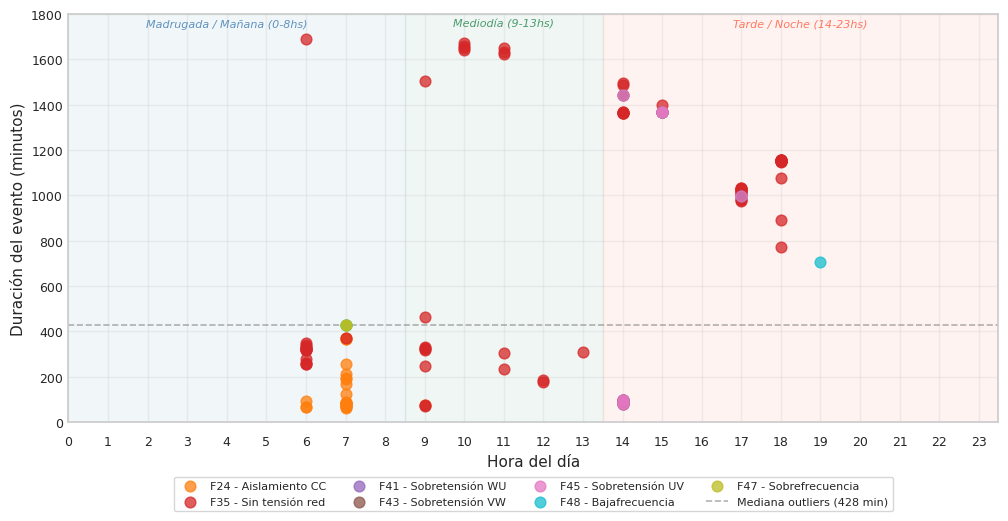

In [ ]:
# =====================================================
# SCATTER OUTLIERS CORREGIDO
# Zonas horarias ajustadas a los datos reales
# =====================================================

fig, ax = plt.subplots(figsize=(12, 6))
fig.subplots_adjust(bottom=0.20)

colores_falla_scatter = {
    'Fallo_Aislam_CC F24':         '#ff7f0e',
    'Fallo_NoHayUtilidad_CA F35':  '#d62728',
    'Fallo_SobreVolt_WU_CA F41':   '#9467bd',
    'Fallo_SobreVolt_VW_CA F43':   '#8c564b',
    'Fallo_SobreVolt_UV_CA F45':   '#e377c2',
    'Fallo_BajaFrec_CA F48':       '#17becf',
    'Fallo_SobreFrec_CA F47':      '#bcbd22',
}

etiquetas_cortas = {
    'Fallo_Aislam_CC F24':         'F24 - Aislamiento CC',
    'Fallo_NoHayUtilidad_CA F35':  'F35 - Sin tensión red',
    'Fallo_SobreVolt_WU_CA F41':   'F41 - Sobretensión WU',
    'Fallo_SobreVolt_VW_CA F43':   'F43 - Sobretensión VW',
    'Fallo_SobreVolt_UV_CA F45':   'F45 - Sobretensión UV',
    'Fallo_BajaFrec_CA F48':       'F48 - Bajafrecuencia',
    'Fallo_SobreFrec_CA F47':      'F47 - Sobrefrecuencia',
}

df_outliers['hora'] = df_outliers['fecha_referencia_abierta'].dt.hour

# ── Zonas horarias corregidas ─────────────────────────────────────
zonas = [
    (0,   8,  'steelblue',  0.07, 4,    'Madrugada / Mañana (0-8hs)'),
    (9,  13,  'seagreen',   0.07, 11,   'Mediodía (9-13hs)'),
    (14, 23,  'tomato',     0.07, 18.5, 'Tarde / Noche (14-23hs)'),
]

for x0, x1, color, alpha, label_x, label in zonas:
    ax.axvspan(x0 - 0.5, x1 + 0.5, alpha=alpha,
               color=color, zorder=0)
    ax.text(label_x, 1780, label,
            ha='center', va='top',
            fontsize=8, color=color,
            alpha=0.85, style='italic')

# ── Puntos por tipo de falla ──────────────────────────────────────
for falla, color in colores_falla_scatter.items():
    subset = df_outliers[df_outliers['nombre_de_alerta'] == falla]
    if len(subset) == 0:
        continue
    ax.scatter(
        subset['hora'],
        subset['evento_minutos'],
        color=color, s=60, alpha=0.75,
        zorder=3,
        label=etiquetas_cortas[falla]
    )

# ── Línea de mediana de outliers ──────────────────────────────────
med_outliers = int(df_outliers['evento_minutos'].median())
ax.axhline(med_outliers, color='gray', linestyle='--',
           linewidth=1.2, alpha=0.6,
           label=f'Mediana outliers ({med_outliers} min)')

# ── Personalización ───────────────────────────────────────────────
#ax.set_title('Outliers — Hora de ocurrencia vs Duración del evento',
#             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Hora del día', fontsize=11)
ax.set_ylabel('Duración del evento (minutos)', fontsize=11)
ax.set_xticks(range(0, 24))
ax.set_ylim(0, 1800)
ax.grid(alpha=0.3, zorder=1)
ax.tick_params(axis='y', pad=-2, labelsize=9)
ax.tick_params(axis='x',labelsize=9)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          ncol=4, fontsize=8, frameon=True)
ax.set_xlim(0, 23.5)
plt.show()

In [ ]:
# Distribución real de outliers por hora
# con contexto de irradiancia para entender qué está pasando en cada franja
resumen_horas = (
    df_outliers
    .groupby(df_outliers['fecha_referencia_abierta'].dt.hour)
    .agg(
        n_outliers    = ('evento_minutos', 'count'),
        dur_mediana   = ('evento_minutos', 'median'),
        ig_real_media = ('ig_real',        'mean'),
        ig_csn_media  = ('ig_csn',         'mean')
    )
    .reset_index()
    .rename(columns={'fecha_referencia_abierta': 'hora'})
)

# Agrego la irradiancia promedio de TODA la flota en esa hora
# para entender si es hora de alta o baja generación
ig_por_hora = (
    df_clima
    .groupby(df_clima['time'].dt.hour)['ig_csn']
    .mean()
    .reset_index()
    .rename(columns={'time': 'hora', 'ig_csn': 'ig_csn_flota'})
)

resumen_horas = resumen_horas.merge(ig_por_hora, on='hora', how='left')

# Normalizo ig_csn_flota entre 0 y 1 para comparar
igmax = resumen_horas['ig_csn_flota'].max()
resumen_horas['ig_norm'] = (resumen_horas['ig_csn_flota'] / igmax).round(2)

print("Hora  N_outliers  Dur_med  ig_real_out  ig_csn_flota  ig_norm")
print("-" * 65)
for _, row in resumen_horas.iterrows():
    print(f"  {int(row['hora']):>2}h  "
          f"{int(row['n_outliers']):>10}  "
          f"{int(row['dur_mediana']):>7}min  "
          f"{row['ig_real_media']:>11.1f}  "
          f"{row['ig_csn_flota']:>12.1f}  "
          f"{row['ig_norm']:>7.2f}")

Hora  N_outliers  Dur_med  ig_real_out  ig_csn_flota  ig_norm
-----------------------------------------------------------------
   6h          17      318min          0.0           0.0     0.00
   7h          25      168min          0.0           9.0     0.01
   9h          10      321min        295.8         420.8     0.40
  10h           4     1656min        814.5         669.7     0.64
  11h           5     1623min        957.4         873.9     0.84
  12h           2      182min       1164.5        1004.0     0.96
  13h           1      309min        582.9        1042.7     1.00
  14h          23       99min       1011.2         984.9     0.94
  15h          10     1368min        991.1         838.1     0.80
  17h          16     1013min        260.9         369.0     0.35
  18h          16     1152min         51.5         120.1     0.12
  19h           1      704min          0.0           0.0     0.00


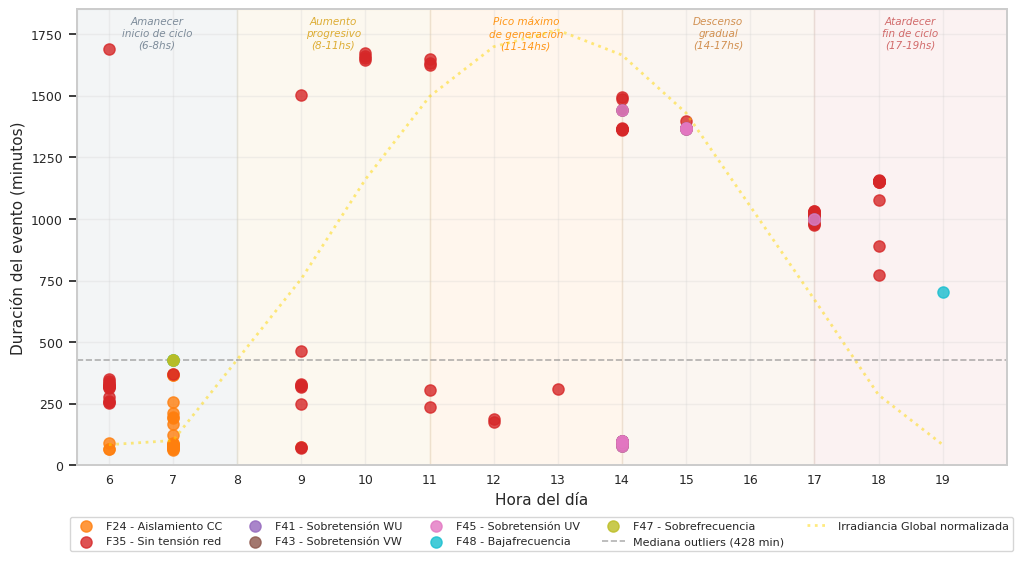

In [ ]:
# =====================================================
# SCATTER OUTLIERS - ZONAS BASADAS EN IRRADIANCIA REAL
# =====================================================

fig, ax = plt.subplots(figsize=(12, 6))
fig.subplots_adjust(bottom=0.12)

colores_falla_scatter = {
    'Fallo_Aislam_CC F24':         '#ff7f0e',
    'Fallo_NoHayUtilidad_CA F35':  '#d62728',
    'Fallo_SobreVolt_WU_CA F41':   '#9467bd',
    'Fallo_SobreVolt_VW_CA F43':   '#8c564b',
    'Fallo_SobreVolt_UV_CA F45':   '#e377c2',
    'Fallo_BajaFrec_CA F48':       '#17becf',
    'Fallo_SobreFrec_CA F47':      '#bcbd22',
}

etiquetas_cortas = {
    'Fallo_Aislam_CC F24':         'F24 - Aislamiento CC',
    'Fallo_NoHayUtilidad_CA F35':  'F35 - Sin tensión red',
    'Fallo_SobreVolt_WU_CA F41':   'F41 - Sobretensión WU',
    'Fallo_SobreVolt_VW_CA F43':   'F43 - Sobretensión VW',
    'Fallo_SobreVolt_UV_CA F45':   'F45 - Sobretensión UV',
    'Fallo_BajaFrec_CA F48':       'F48 - Bajafrecuencia',
    'Fallo_SobreFrec_CA F47':      'F47 - Sobrefrecuencia',
}

df_outliers['hora'] = df_outliers['fecha_referencia_abierta'].dt.hour

# ── Zonas basadas en irradiancia normalizada ──────────────────────
# ig_norm 0.00      → sin generación
# ig_norm 0.01-0.64 → generación creciente
# ig_norm 0.80-1.00 → pico de generación
# ig_norm 0.12-0.35 → generación decreciente
# ig_norm 0.00      → noche

zonas = [
    ( 5.5,  8.0, 'slategray',  0.08,  6.75,
      'Amanecer\ninicio de ciclo\n(6-8hs)'),

    ( 8.0, 11.0, 'goldenrod',  0.07,  9.5,
      'Aumento\nprogresivo\n(8-11hs)'),

    (11.0, 14.0, 'darkorange', 0.07, 12.5,
      'Pico máximo\nde generación\n(11-14hs)'),

    (14.0, 17.0, 'peru',       0.07, 15.5,
      'Descenso\ngradual\n(14-17hs)'),

    (17.0, 20.0, 'indianred',  0.08, 18.5,
      'Atardecer\nfin de ciclo\n(17-19hs)'),
]

for x0, x1, color, alpha, label_x, label in zonas:
    ax.axvspan(x0, x1, alpha=alpha, color=color, zorder=0)
    ax.text(label_x, 1820, label,
            ha='center', va='top',
            fontsize=7.5, color=color,
            alpha=0.9, style='italic')

# ── Eje secundario: curva de irradiancia normalizada ──────────────
ax2 = ax.twinx()
ax2.plot(
    resumen_horas['hora'],
    resumen_horas['ig_norm'] * 1800,
    color='gold', linewidth=2, linestyle=':',
    alpha=0.5, zorder=2, label='Irradiancia Global normalizada'
)
ax2.set_yticks([])
ax2.set_ylabel('')

# ── Puntos por tipo de falla ──────────────────────────────────────
for falla, color in colores_falla_scatter.items():
    subset = df_outliers[df_outliers['nombre_de_alerta'] == falla]
    if len(subset) == 0:
        continue
    ax.scatter(
        subset['hora'],
        subset['evento_minutos'],
        color=color, s=65, alpha=0.80,
        zorder=3,
        label=etiquetas_cortas[falla]
    )

# ── Mediana de outliers ───────────────────────────────────────────
med_outliers = int(df_outliers['evento_minutos'].median())
ax.axhline(
    med_outliers,
    color='gray', linestyle='--',
    linewidth=1.2, alpha=0.6,
    label=f'Mediana outliers ({med_outliers} min)'
)

# ── Personalización ───────────────────────────────────────────────
'''
ax.set_title(
    'Outliers — Hora de ocurrencia vs Duración\n'
    'Zonas definidas por nivel de irradiancia solar (ig normalizado)',
    fontsize=12, fontweight='bold', pad=12
)
'''
ax.set_xlabel('Hora del día', fontsize=11)
ax.set_ylabel('Duración del evento (minutos)', fontsize=11)
ax.set_xticks(range(5, 20))
ax.tick_params(axis='y', pad=4, labelsize=9)
ax.tick_params(axis='x', pad=0, labelsize=9)
ax.set_ylim(0, 1850)
ax.set_xlim(5.5, 20)
ax.grid(alpha=0.25, zorder=1)

# Leyenda combinada
handles_ax,  labels_ax  = ax.get_legend_handles_labels()
handles_ax2, labels_ax2 = ax2.get_legend_handles_labels()
ax.legend(
    handles_ax + handles_ax2,
    labels_ax  + labels_ax2,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=5, fontsize=8, frameon=True
)
plt.show()

##### Tabla resumen

In [ ]:
# Tabla resumen
print("\nResumen outliers por zona horaria:")
df_outliers['zona'] = pd.cut(
    df_outliers['hora'],
    bins=[-1, 8, 13, 24],
    labels=['Mañana (0-8hs)', 'Mediodía (9-13hs)', 'Tarde (14-23hs)']
)
print(df_outliers.groupby(['zona', 'nombre_de_alerta'])
      ['evento_minutos'].agg(['count', 'median'])
      .round(1).to_string())


Resumen outliers por zona horaria:
                                              count  median
zona              nombre_de_alerta                         
Mañana (0-8hs)    Fallo_Aislam_CC F24            23    85.0
                  Fallo_BajaFrec_CA F48           2   428.0
                  Fallo_NoHayUtilidad_CA F35     15   322.0
                  Fallo_SobreFrec_CA F47          2   426.5
                  Fallo_SobreVolt_UV_CA F45       0     NaN
                  Fallo_SobreVolt_VW_CA F43       0     NaN
                  Fallo_SobreVolt_WU_CA F41       0     NaN
Mediodía (9-13hs) Fallo_Aislam_CC F24             1    74.0
                  Fallo_BajaFrec_CA F48           0     NaN
                  Fallo_NoHayUtilidad_CA F35     21   325.0
                  Fallo_SobreFrec_CA F47          0     NaN
                  Fallo_SobreVolt_UV_CA F45       0     NaN
                  Fallo_SobreVolt_VW_CA F43       0     NaN
                  Fallo_SobreVolt_WU_CA F41       0     NaN
Tard

/tmp/ipykernel_27973/4171488273.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_outliers.groupby(['zona', 'nombre_de_alerta'])


### Analisis  por codigo de Falla

#### F24

In [ ]:
# =====================================================
# ANÁLISIS F24 - Fallo_Aislam_CC
# =====================================================

f24 = df_fallas_clima[
    df_fallas_clima['nombre_de_alerta'] == 'Fallo_Aislam_CC F24'
].copy()

F24 - Resumen general de la falla

In [ ]:
# 1. Asegurar formato datetime para las columnas de fecha
fecha_abierta_f24 = pd.to_datetime(f24['hora_abierta'])

# 2. Contar los días únicos donde ocurrió al menos una falla F24
dias_con_falla = fecha_abierta_f24.dt.date.nunique()

# 3. Definir el periodo total del dataset original
fecha_inicio = pd.to_datetime('2026-02-19')
fecha_fin = pd.to_datetime('2026-04-30')

# Calculamos los días totales del periodo (sumamos 1 para incluir ambos extremos)
dias_totales_periodo = (fecha_fin - fecha_inicio).days + 1

# 4. Calcular el porcentaje de días afectados
pct_dias_afectados = (dias_con_falla / dias_totales_periodo) * 100

# --- CÓDIGO DE TU RESUMEN ACTUALIZADO ---
tiempo_total_f24 = f24['evento_minutos'].sum()
tiempo_total_general = df_fallas_clima['evento_minutos'].sum()
pct_tiempo_f24 = (tiempo_total_f24 / tiempo_total_general * 100) if tiempo_total_general > 0 else 0.0

print(f"F24 - Resumen General de la falla")
print(f"F24 - Ocurrencias totales:           {len(f24)}")
print(f"F24 - % sobre el total de fallas:    {len(f24)/df_fallas_clima.shape[0]*100:.2f}%")
print("-" * 45)
print(f"F24 - Tiempo total afectado:         {tiempo_total_f24/60:.1f} horas ({tiempo_total_f24:.0f} min)")
print(f"F24 - % sobre el tiempo total:       {pct_tiempo_f24:.2f}%")
print("-" * 45)

# --- NUEVOS DATOS DE CALENDARIO ---
print(f"F24 - Días del periodo analizado:    {dias_totales_periodo} días")
print(f"F24 - Días con presencia de falla:   {dias_con_falla} días")
print(f"F24 - % de días del año/mes afectados: {pct_dias_afectados:.2f}% ({dias_con_falla}/{dias_totales_periodo})")
print("-" * 45)

print(f"Cantidad de Inversores afectados:    {f24['inversor'].nunique()}")
print(f"Inversores Afectados:                {sorted(f24['inversor'].unique())}")
print()

F24 - Resumen General de la falla
F24 - Ocurrencias totales:           355
F24 - % sobre el total de fallas:    29.81%
---------------------------------------------
F24 - Tiempo total afectado:         490.0 horas (29399 min)
F24 - % sobre el tiempo total:       21.40%
---------------------------------------------
F24 - Días del periodo analizado:    71 días
F24 - Días con presencia de falla:   42 días
F24 - % de días del año/mes afectados: 59.15% (42/71)
---------------------------------------------
Cantidad de Inversores afectados:    16
Inversores Afectados:                ['A1', 'A2', 'A3', 'A4', 'B1', 'B2', 'B3', 'B4', 'C1', 'C2', 'C3', 'C4', 'D1', 'D2', 'D3', 'D4']



##### Frecuencia

/tmp/ipykernel_27973/3228336844.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


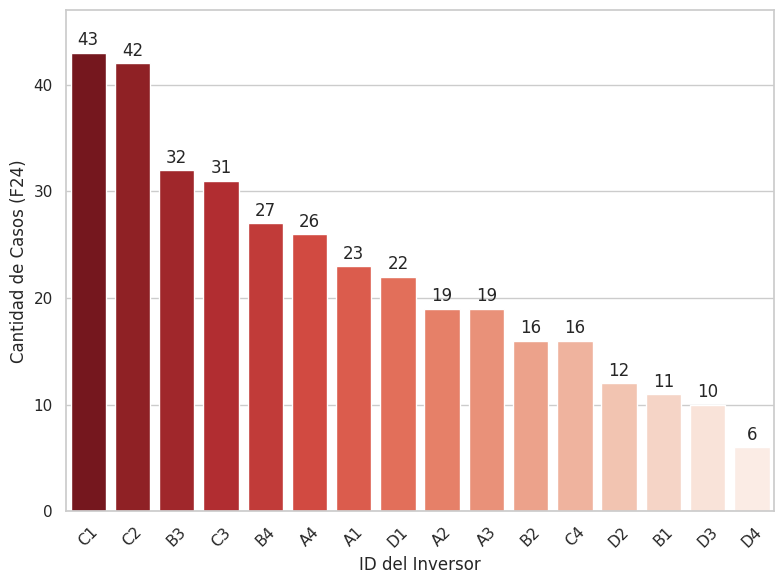

In [ ]:
# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Creo el gráfico de barras (conteo)
ax = sns.countplot(
    data=f24,
    x='inversor',
    palette='Reds_r',
    order=f24['inversor'].value_counts().index
)

# Personalización de etiquetas
#plt.title('Fallo F24 - Acumulado de Casos por Inversor', fontsize=15, fontweight='bold', y=1.03)
plt.xlabel('ID del Inversor', fontsize=12)
plt.ylabel('Cantidad de Casos (F24)', fontsize=12)
plt.xticks(rotation=45) # Rotamos las etiquetas por si los nombres son largos

# Añado las etiquetas de datos sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.ylim(0, 47)
plt.tight_layout()
plt.show()

##### Disctribucion x horas

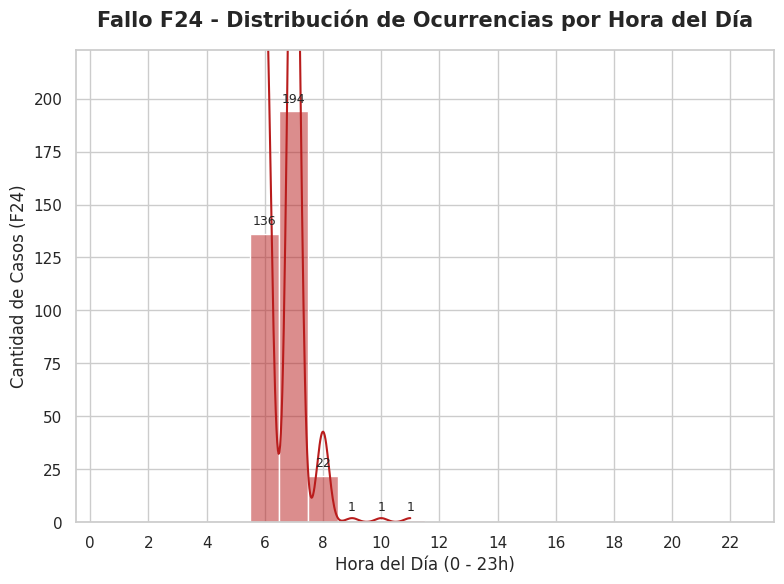

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Creo una serie temporal temporal solo para el gráfico
# pd.to_datetime asegura que Python entienda el formato '2026-04-29 08:47:00' y extraiga el '8'
horas_f24 = pd.to_datetime(f24['hora_abierta']).dt.hour

# Creo el gráfico de distribución por hora de inicio
ax = sns.histplot(
    x=horas_f24,
    kde=True,
    color='#b91c1c', # Rojo alineado a tu paleta 'Reds_r'
    bins=np.arange(0, 26) - 0.5, # Contenedores de 0 a 24 horas
    edgecolor='white',
    linewidth=1
)

# Personalización de etiquetas
plt.title('Fallo F24 - Distribución de Ocurrencias por Hora del Día', fontsize=15, fontweight='bold', y=1.03)
plt.xlabel('Hora del Día (0 - 23h)', fontsize=12)
plt.ylabel('Cantidad de Casos (F24)', fontsize=12)

# Ajustamos el eje X para que muestre las horas del día de manera limpia
plt.xlim(-0.5, 23.5)
plt.xticks(range(0, 24, 2))

# Añado las etiquetas de datos sobre cada barra horaria (solo si tienen casos > 0)
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Evita dibujar ceros en las horas sin registros
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=9)

# Ajustamos el límite superior en Y para dejar espacio a los números
plt.ylim(0, horas_f24.value_counts().max() * 1.15)

plt.tight_layout()
plt.show()

##### Grafico de torta fallos x grupo

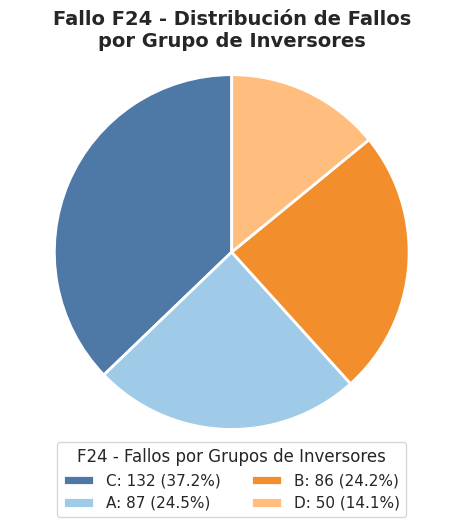

In [ ]:
# 1. Preparación de datos
f24['grupo'] = f24['inversor'].astype(str).str[0]
resumen_grupos = f24['grupo'].value_counts().sort_values(ascending=False)

# 2. Configuración de colores (Oscuro = Mayor incidencia)
colores = sns.color_palette('Reds_r', n_colors=len(resumen_grupos))

# 3. Crear el gráfico
fig, ax = plt.subplots(figsize=(8, 6))

# 1. Definir tu diccionario de colores por grupo
color_grupo = {
    'C': '#4e79a7',
    'A': '#a0cbe8',
    'B': '#f28e2b',
    'D': '#ffbe7d'
}

# 2. Generar la lista de colores alineada con el orden de resumen_grupos
# (Asumiendo que las letras 'C', 'A', etc., son el índice de la serie resumen_grupos)
colores_grupos = [color_grupo[grupo] for grupo in resumen_grupos.index]
# Dibujamos la torta sin etiquetas internas
wedges, _ = ax.pie(
    resumen_grupos,
    startangle=90,
    colors=colores_grupos,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# 4. Etiquetas personalizadas (Nombre + %)
total = sum(resumen_grupos)
labels_leyenda = [f'{l}: {v} ({v/total:.1%})' for l, v in zip(resumen_grupos.index, resumen_grupos)]


# 5. Configurar la leyenda debajo en 2 columnas
ax.legend(
    wedges,
    labels_leyenda,
    title="F24 - Fallos por Grupos de Inversores",
    loc="upper center",             # Punto de anclaje de la leyenda
    bbox_to_anchor=(0.5,0.09),    # (x, y) -> 0.5 es centro, -0.05 es justo debajo del gráfico
    ncol=2,                         # Forzamos las 2 columnas
    fontsize=11,
    title_fontsize=12,
    frameon=True                    # Mantiene el recuadro
)

plt.title('Fallo F24 - Distribución de Fallos\npor Grupo de Inversores', fontsize=14, fontweight='bold', pad=20, y=0.9)

# Ajuste estricto para que la leyenda no se corte al guardar o mostrar
plt.tight_layout()
plt.subplots_adjust(bottom=0.2) # Reservamos espacio extra abajo para la leyenda

plt.show()

##### Tabla distribucion x horas

In [ ]:
# Distribución por hora del día
print("Distribución por hora del día:")
hora_dist = f24['fecha_referencia_abierta'].dt.hour.value_counts().sort_index()
print(hora_dist.to_string())
print()

Distribución por hora del día:
fecha_referencia_abierta
6     136
7     194
8      22
9       1
10      1
11      1



##### Graficos combinados

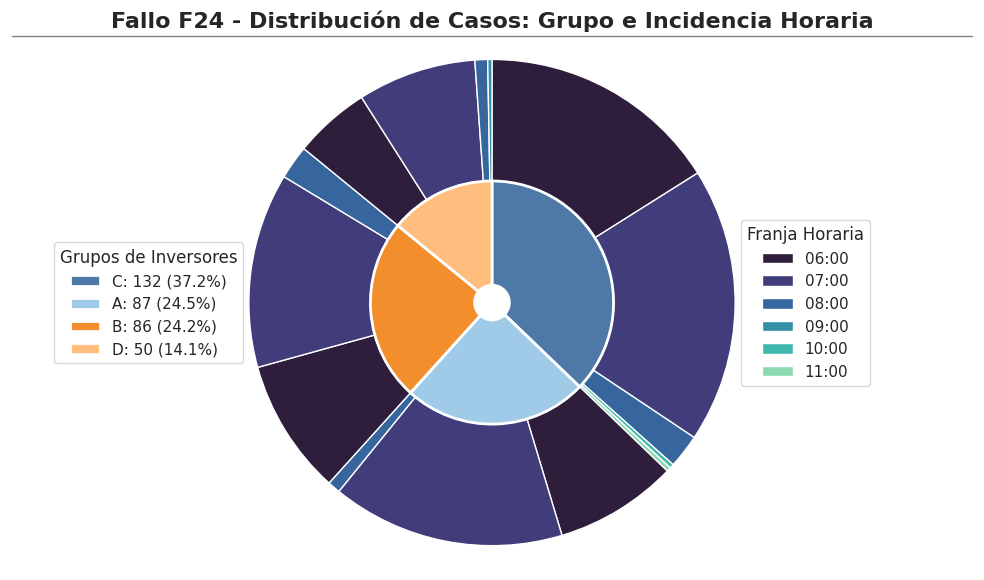

In [ ]:
# 1. Preparación de datos
f24['grupo'] = f24['inversor'].astype(str).str[0]
f24['hora'] = f24['fecha_referencia_abierta'].dt.strftime('%H:00')

# Ordeno grupos por volumen (C, A, B, D)
resumen_grupos = f24['grupo'].value_counts().sort_values(ascending=False)
grupos_ordenados = resumen_grupos.index

# Obtengo horas únicas para asignar colores fijos
horas_unicas = sorted(f24['hora'].unique())
# Usamos una paleta que combine bien con los rojos (un degradado azul o gris azulado)
paleta_horas = sns.color_palette("mako", n_colors=len(horas_unicas))
mapa_colores_horas = dict(zip(horas_unicas, paleta_horas))

# Agrupación jerárquica para la alineación
resumen_detallado = f24.groupby(['grupo', 'hora']).size().reindex(grupos_ordenados, level=0)

# Colores para el anillo exterior basados en la hora
colores_externos = [mapa_colores_horas[hora] for grupo, hora in resumen_detallado.index]
# Colores para el circulo central (Rojos)
#colores_internos = sns.color_palette('Reds_r', n_colors=len(resumen_grupos))

# 2. Creación del gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# --- ANILLO EXTERIOR (Dona de Horas) ---
pie_ext, _ = ax.pie(
    resumen_detallado,
    radius=0.7,
    colors=colores_externos,
    startangle=90,
    counterclock=False,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1, 'width': 0.35}
)

# 1. Definir tu diccionario de colores por grupo
color_grupo = {
    'C': '#4e79a7',
    'A': '#a0cbe8',
    'B': '#f28e2b',
    'D': '#ffbe7d'
}

# 2. Generar la lista de colores alineada con el orden de resumen_grupos
# (Asumiendo que las letras 'C', 'A', etc., son el índice de la serie resumen_grupos)
colores_grupos = [color_grupo[grupo] for grupo in resumen_grupos.index]

# --- CÍRCULO INTERIOR (Torta de Grupos) ---
pie_int, _ = ax.pie(
    resumen_grupos,
    radius=0.35,
    colors=colores_grupos,
    startangle=90,
    counterclock=False,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.30}
)

# 3. LEYENDAS
# Leyenda de Grupos (Abajo)
total_casos = len(f24)
labels_grupos = [f'{g}: {v} ({v/total_casos:.1%})' for g, v in resumen_grupos.items()]
leg_grupos = ax.legend(
    pie_int, labels_grupos,
    title="Grupos de Inversores",
    loc="center right",
    bbox_to_anchor=(0.25, 0.5),
    ncol=1, frameon=True
)
ax.add_artist(leg_grupos) # Añadir manualmente para que no se borre al crear la segunda

# Leyenda de Horas (Derecha)
# Creamos parches de color manuales para la leyenda de horas
from matplotlib.patches import Patch
labels_horas = [Patch(facecolor=mapa_colores_horas[h], edgecolor='w', label=h) for h in horas_unicas]
ax.legend(
    handles=labels_horas,
    title="Franja Horaria",
    loc="center left",
    bbox_to_anchor=(0.75, 0.5),
    frameon=True
)

fig.add_artist(Line2D(
    [0.02, 0.98],     # margen lateral
    [0.92, 0.92],   # misma altura en Y → línea horizontal
    transform=fig.transFigure,
    color='black',
    alpha= 0.5,
    linewidth=1
))

plt.title('Fallo F24 - Distribución de Casos: Grupo e Incidencia Horaria', fontsize=16, fontweight='bold', pad=25, y=0.95)
plt.axis('equal')
plt.tight_layout()
plt.show()

###### Distribucion x condicion climatica

In [ ]:
# Distribución por condición climática
col_condicion = [c for c in f24.columns if 'condicion' in c][0]
print("Distribución por condición climática:")
print(f24[col_condicion].value_counts().to_string())
print()

Distribución por condición climática:
condicion
Clear               167
PartlyCloudy         70
Haze                 56
LightRain            42
Rain                  7
HeavyRain             4
Fair                  3
LightRainShowers      3
RainShowers           3



###### Agrupamiento x condicion climatica

In [ ]:
# 1. Definimos el mapeo de categorías
mapa_clima = {
    'Clear': 'bueno',
    'Fair': 'bueno',
    'PartlyCloudy': 'nublado/bruma',
    'Haze': 'nublado/bruma',
    'LightRain': 'lluvia',
    'Rain': 'lluvia',
    'HeavyRain': 'lluvia',
    'LightRainShowers': 'lluvia',
    'RainShowers': 'lluvia'
}

# 2. Creamos la nueva columna en el dataframe f24
f24['cond_agrup'] = f24['condicion'].map(mapa_clima)

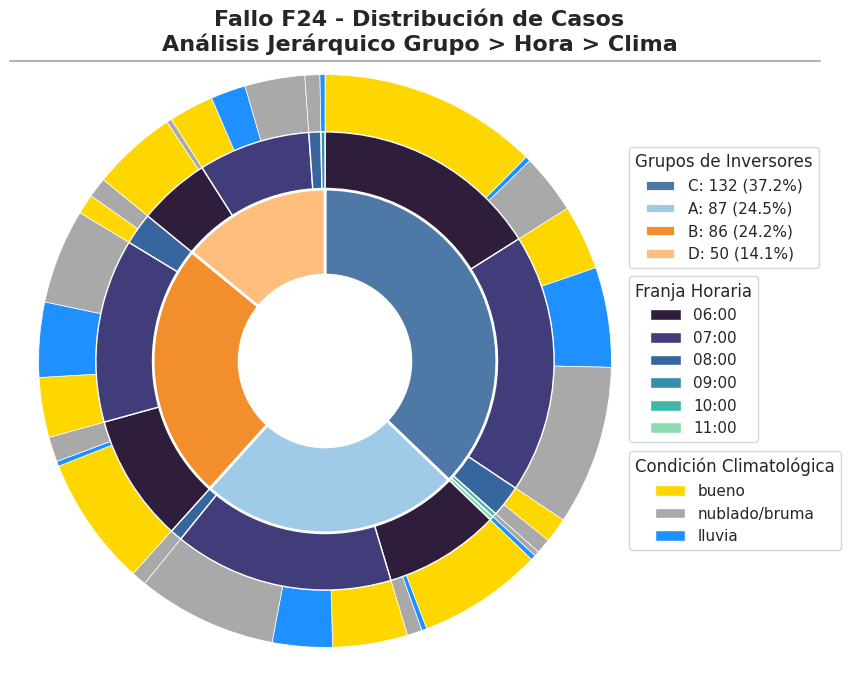

In [ ]:
# 1. Preparación de datos (Jerarquía de 3 niveles)
f24['grupo'] = f24['inversor'].astype(str).str[0]
f24['hora'] = f24['fecha_referencia_abierta'].dt.strftime('%H:00')

# Orden de grupos
resumen_grupos = f24['grupo'].value_counts().sort_values(ascending=False)
grupos_ordenados = resumen_grupos.index

# Agrupación triple para alineación perfecta
# Nivel 1: Grupo | Nivel 2: Hora | Nivel 3: Clima
resumen_triple = f24.groupby(['grupo', 'hora', 'cond_agrup']).size().reindex(grupos_ordenados, level=0)

# 2. Configuración de Colores Fijos
# Horas
horas_unicas = sorted(f24['hora'].unique())
mapa_colores_horas = dict(zip(horas_unicas, sns.color_palette("mako", n_colors=len(horas_unicas))))

# Clima (Colores intuitivos)
mapa_colores_clima = {
    'bueno': '#FFD700',          # Oro/Amarillo
    'nublado/bruma': '#A9A9A9',   # Gris
    'lluvia': '#1E90FF'           # Azul Brillante
}

# 3. Creación del gráfico
fig, ax = plt.subplots(figsize=(9, 8))

# --- ANILLO EXTERIOR (Clima) ---
colores_clima = [mapa_colores_clima[clima] for g, h, clima in resumen_triple.index]
pie_clima, _ = ax.pie(
    resumen_triple, radius=1,
    colors=colores_clima, startangle=90, counterclock=False,
    wedgeprops={'edgecolor': 'white', 'linewidth': 0.5, 'width': 0.2}
)

# --- ANILLO MEDIO (Horas) ---
resumen_horas = f24.groupby(['grupo', 'hora']).size().reindex(grupos_ordenados, level=0)
colores_horas = [mapa_colores_horas[hora] for g, hora in resumen_horas.index]
pie_horas, _ = ax.pie(
    resumen_horas, radius=0.8,
    colors=colores_horas, startangle=90, counterclock=False,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1, 'width': 0.2}
)

# 1. Definir tu diccionario de colores por grupo
color_grupo = {
    'C': '#4e79a7',
    'A': '#a0cbe8',
    'B': '#f28e2b',
    'D': '#ffbe7d'
}

# 2. Generar la lista de colores alineada con el orden de resumen_grupos
# (Asumiendo que las letras 'C', 'A', etc., son el índice de la serie resumen_grupos)
colores_grupos = [color_grupo[grupo] for grupo in resumen_grupos.index]

# --- CÍRCULO INTERIOR (Grupos) ---
pie_grupos, _ = ax.pie(
    resumen_grupos, radius=0.6,
    colors=colores_grupos, startangle=90, counterclock=False,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.3}
)

# 4. LEYENDAS
# Grupo
labels_g = [f'{g}: {v} ({v/len(f24):.1%})' for g, v in resumen_grupos.items()]
leg1 = ax.legend(pie_grupos, labels_g, title="Grupos de Inversores",
                  loc="upper left", bbox_to_anchor=(0.97, 0.86))

# Horas
labels_h = [Patch(facecolor=mapa_colores_horas[h], edgecolor='w', label=h) for h in horas_unicas]
leg2 = ax.legend(handles=labels_h, title="Franja Horaria",
                  loc="upper left", bbox_to_anchor=(0.97, 0.65))

# Clima
labels_c = [Patch(facecolor=mapa_colores_clima[c], edgecolor='w', label=c) for c in mapa_colores_clima]
leg3 = ax.legend(handles=labels_c, title="Condición Climatológica",
                  loc="upper left", bbox_to_anchor=(0.97, 0.3655))


# Añado artistas para que no se sobrepongan
ax.add_artist(leg1)
ax.add_artist(leg2)


fig.add_artist(Line2D([0.05, 0.95], [0.87, 0.87], transform=fig.transFigure, color='black', alpha=0.3))
plt.title('Fallo F24 - Distribución de Casos\nAnálisis Jerárquico Grupo > Hora > Clima', fontsize=16, fontweight='bold',x=0.65, y=0.99)
plt.axis('equal')
plt.subplots_adjust(right=0.75, left=0.05) # Espacio para leyendas a la derecha
plt.show()


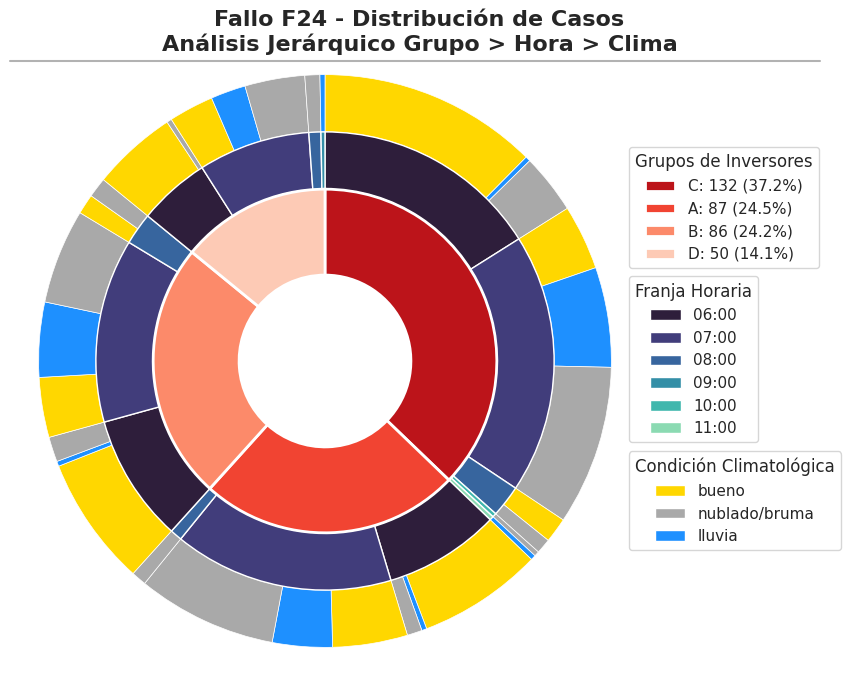

In [ ]:
# 1. Preparación de datos (Jerarquía de 3 niveles)
f24['grupo'] = f24['inversor'].astype(str).str[0]
f24['hora'] = f24['fecha_referencia_abierta'].dt.strftime('%H:00')

# Orden de grupos
resumen_grupos = f24['grupo'].value_counts().sort_values(ascending=False)
grupos_ordenados = resumen_grupos.index

# Agrupación triple para alineación perfecta
# Nivel 1: Grupo | Nivel 2: Hora | Nivel 3: Clima
resumen_triple = f24.groupby(['grupo', 'hora', 'cond_agrup']).size().reindex(grupos_ordenados, level=0)

# 2. Configuración de Colores Fijos
# Horas
horas_unicas = sorted(f24['hora'].unique())
mapa_colores_horas = dict(zip(horas_unicas, sns.color_palette("mako", n_colors=len(horas_unicas))))

# Clima (Colores intuitivos)
mapa_colores_clima = {
    'bueno': '#FFD700',          # Oro/Amarillo
    'nublado/bruma': '#A9A9A9',   # Gris
    'lluvia': '#1E90FF'           # Azul Brillante
}

# 3. Creación del gráfico
fig, ax = plt.subplots(figsize=(9, 8))

# --- ANILLO EXTERIOR (Clima) ---
colores_clima = [mapa_colores_clima[clima] for g, h, clima in resumen_triple.index]
pie_clima, _ = ax.pie(
    resumen_triple, radius=1,
    colors=colores_clima, startangle=90, counterclock=False,
    wedgeprops={'edgecolor': 'white', 'linewidth': 0.5, 'width': 0.2}
)

# --- ANILLO MEDIO (Horas) ---
resumen_horas = f24.groupby(['grupo', 'hora']).size().reindex(grupos_ordenados, level=0)
colores_horas = [mapa_colores_horas[hora] for g, hora in resumen_horas.index]
pie_horas, _ = ax.pie(
    resumen_horas, radius=0.8,
    colors=colores_horas, startangle=90, counterclock=False,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1, 'width': 0.2}
)

# --- CÍRCULO INTERIOR (Grupos) ---
colores_grupos = sns.color_palette('Reds_r', n_colors=len(resumen_grupos))
pie_grupos, _ = ax.pie(
    resumen_grupos, radius=0.6,
    colors=colores_grupos, startangle=90, counterclock=False,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.3}
)

# 4. LEYENDAS (Todas a la derecha, una debajo de otra)
# Grupo
labels_g = [f'{g}: {v} ({v/len(f24):.1%})' for g, v in resumen_grupos.items()]
leg1 = ax.legend(pie_grupos, labels_g, title="Grupos de Inversores",
                  loc="upper left", bbox_to_anchor=(0.97, 0.86))

# Horas
labels_h = [Patch(facecolor=mapa_colores_horas[h], edgecolor='w', label=h) for h in horas_unicas]
leg2 = ax.legend(handles=labels_h, title="Franja Horaria",
                  loc="upper left", bbox_to_anchor=(0.97, 0.65))

# Clima
labels_c = [Patch(facecolor=mapa_colores_clima[c], edgecolor='w', label=c) for c in mapa_colores_clima]
leg3 = ax.legend(handles=labels_c, title="Condición Climatológica",
                  loc="upper left", bbox_to_anchor=(0.97, 0.3655))


# Añado artistas para que no se sobrepongan
ax.add_artist(leg1)
ax.add_artist(leg2)

# Estética Final
fig.add_artist(Line2D([0.05, 0.95], [0.87, 0.87], transform=fig.transFigure, color='black', alpha=0.3))
plt.title('Fallo F24 - Distribución de Casos\nAnálisis Jerárquico Grupo > Hora > Clima', fontsize=16, fontweight='bold',x=0.65, y=0.99)
plt.axis('equal')
plt.subplots_adjust(right=0.75, left=0.05) # Espacio para leyendas a la derecha
plt.show()

##### Predictores f24 vs dataset completo

In [ ]:
# Perfil de predictores F24 vs dataset completo
predictores_f24 = [
    'temp', 'rhum', 'prcp', 'ig_real',
    'riesgo_condensacion', 'f2x_horas_riesgo_6h',
    'f2x_prcp_acum_6h', 'f2x_rhum_min_6h',
    'f2x_arranque_humedo', 'f23_generando_con_agua'
]

print(f"{'Variable':<25} {'Media F24':>10} {'Media general':>14} {'Diferencia':>11}")
print("-" * 63)
for col in predictores_f24:
    if col in f24.columns:
        media_falla   = f24[col].mean()
        media_general = df_fallas_clima[col].mean()
        diferencia    = media_falla - media_general
        print(f"{col:<25} {media_falla:>10.3f} {media_general:>14.3f} {diferencia:>+11.3f}")

Variable                   Media F24  Media general  Diferencia
---------------------------------------------------------------
temp                          16.312         19.590      -3.278
rhum                          93.225         80.603     +12.622
prcp                           0.088          0.102      -0.014
ig_real                        7.692        251.716    -244.024
riesgo_condensacion            1.115          3.875      -2.759
f2x_horas_riesgo_6h            4.085          2.693      +1.392
f2x_prcp_acum_6h               0.495          0.499      -0.004
f2x_rhum_min_6h               86.296         74.860     +11.436
f2x_arranque_humedo            0.034          0.011      +0.023
f23_generando_con_agua         0.023          0.086      -0.063


Comparativa de Variables Climáticas: F24 vs. Media General

Este análisis compara el comportamiento del contexto climático en los momentos de falla **F24** (355 casos) frente al promedio de todo el dataset (1,191 casos).

| Variable | Media F24 | Media General | Diferencia | Interpretación |
| :--- | :---: | :---: | :---: | :--- |
| **Temperatura (`temp`)** | ~16.7°C | 20.0°C | **-3.278°C** | Las noches frías favorecen la condensación al acercarse al punto de rocío. |
| **Humedad (`rhum`)** | 93.2% | 80.6% | **+12.622%** | F24 ocurre en condiciones de humedad extrema, cercanas a la saturación. |
| **Precipitación (`prcp`)** | ~0.02 mm | ~0.03 mm | **-0.014 mm** | **La falla no es causada por lluvia activa, sino por condensación.** |
| **Irradiancia (`ig_real`)** | 7.7 W/m² | 251.7 W/m² | **-244.0 W/m²** | Ocurre casi exclusivamente de noche o al amanecer, antes del secado solar. |
| **Riesgo Condensación** | 1.11°C | 3.87°C | **-2.759°C** | El valor de 1.11°C sitúa al sistema en la zona de riesgo alto (cerca de 0). |
| **Horas Riesgo (6h)** | 4.1 hs | 2.7 hs | **+1.392 hs** | Mayor tiempo de exposición acumulada a condiciones críticas antes de la falla. |
| **Prcp. Acumulada (6h)** | ~0.04 mm | ~0.04 mm | **-0.004 mm** | Confirma que la lluvia acumulada previa no es un factor relevante. |
| **Humedad Mínima (6h)** | 86.3% | 74.9% | **+11.436%** | No hubo "ventanas de secado"; la humedad se mantuvo alta constantemente. |
| **Arranque Húmedo** | 0.034 | 0.011 | **+0.023** | Tres veces más frecuente en F24, vinculada a la primera hora de luz. |
| **Generando con Agua** | 0.023 | 0.086 | **-0.063** | Menos frecuente en F24, ya que esta ocurre antes de la generación activa. |

---

| Condición / Variable | Estado para F24 (✓) | Comparativa vs. Promedio |
| :--- | :--- | :--- |
| **Temperatura** | Baja (~16°C) | 20°C promedio |
| **Humedad Relativa** | Muy alta (~93%) | 81% promedio |
| **Lluvia (prcp)** | Sin lluvia activa | Similar al promedio |
| **Irradiancia (ig_real)** | Nula o mínima (~8) | 252 promedio |
| **Exposición Nocturna** | Alta (`f2x_horas_riesgo_6h`) | Acumulación de humedad |
| **Secado Previo** | Inexistente (`f2x_rhum_min_6h` alto) | Sin reducción de humedad previa |

| Factores que NO provocan F24 (✗) | Razón / Evidencia |
| :--- | :--- |
| **Lluvia** | La variable `prcp` no muestra diferencias significativas. |
| **Alta Irradiancia** | El evento ocurre ante la ausencia de sol. |
| **Temperatura Alta** | El fenómeno está ligado a condiciones frescas/frías. |

---

Conclusiones Principales del Diagnóstico

*   La falla F24 está definida por una combinación de **baja temperatura** y **humedad muy alta** (cerca del 93%).
*   Se ratifica que la precipitación no es el disparador; es un fenómeno de condensación pura.
*   Los indicadores de las 6 horas previas muestran que el sistema no logra evacuar la humedad acumulada durante la noche (`f2x_rhum_min_6h` alto), llegando al amanecer en un estado crítico.

#### Correlacion F24

In [ ]:
# =====================================================
# ANÁLISIS DE CORRELACIÓN F24
# =====================================================

# Creo variable binaria: 1 = hubo F24 en esa hora, 0 = no hubo
# Esto permite calcular correlación de cada variable con la ocurrencia de falla

# Horas únicas donde ocurrió F24
horas_f24 = set(
    df_fallas_clima[df_fallas_clima['nombre_de_alerta'] == 'Fallo_Aislam_CC F24']
    ['fecha_referencia_abierta']
)

# Agrego columna binaria al dataset climático completo
df_clima['falla_f24'] = df_clima['time'].isin(horas_f24).astype(int)

print(f"Horas únicas con F24:     {df_clima['falla_f24'].sum()}")
print(f"Horas sin F24:            {(df_clima['falla_f24'] == 0).sum()}")
print(f"Tasa de ocurrencia:       {df_clima['falla_f24'].mean():.3f} ({df_clima['falla_f24'].mean()*100:.1f}%)")
print()

# Todas las variables numéricas disponibles para correlación
# Excluir columnas no numéricas, timestamps y l

Horas únicas con F24:     71
Horas sin F24:            1633
Tasa de ocurrencia:       0.042 (4.2%)



Dato muy importante antes de ver la correlación. 355 eventos de F24 pero solo 71 horas únicas. Eso significa que en promedio hay 5 inversores fallando por hora cuando ocurre F24.

355 eventos / 71 horas = 5.0 inversores por evento horario

Esto tiene implicaciones directas para el análisis:
Lo que significa físicamente: cuando las condiciones climáticas generan F24, no falla un solo inversor sino que falla la mayoría o todos simultáneamente. Es una falla sistémica por condición ambiental, no aleatoria por defecto individual.

Lo que significa para la correlación: la variable falla_f24 que creamos (0/1 por hora) es la correcta para el análisis climático. No importa cuántos inversores fallaron en esa hora, lo que importa es si la condición climática estaba presente.

#### Co-ocurrencia

In [ ]:
# Cuántos inversores fallan simultáneamente en cada hora
f24_por_hora = (
    df_fallas_clima[df_fallas_clima['nombre_de_alerta'] == 'Fallo_Aislam_CC F24']
    .groupby('fecha_referencia_abierta')
    .agg(
        n_inversores  = ('inversor', 'nunique'),
        inversores    = ('inversor', lambda x: sorted(x.unique())),
        duracion_min  = ('evento_minutos', 'mean')
    )
    .reset_index()
    .sort_values('fecha_referencia_abierta')
)

print("Distribución de inversores simultáneos por hora con F24:")
print(f24_por_hora['n_inversores'].value_counts().sort_index().to_string())
print()
print("Total horas únicas con F24:", len(f24_por_hora))
print()
print("Muestra de eventos:")
print(f24_por_hora.head(20).to_string())

Distribución de inversores simultáneos por hora con F24:
n_inversores
1     17
2      9
3     11
4      5
5      1
6      5
7      3
8      4
9      6
10     3
12     3
13     1
14     2
15     1

Total horas únicas con F24: 71

Muestra de eventos:
   fecha_referencia_abierta  n_inversores                                                    inversores  duracion_min
0       2026-02-28 06:00:00            15  [A1, A2, A3, A4, B1, B2, B3, B4, C1, C3, C4, D1, D2, D3, D4]     89.733333
1       2026-02-28 07:00:00             1                                                          [B4]     39.000000
2       2026-03-01 06:00:00             6                                      [A3, B4, C1, C2, C3, D3]     67.166667
3       2026-03-02 06:00:00             1                                                          [C2]      6.000000
4       2026-03-04 06:00:00             1                                                          [C1]     95.000000
5       2026-03-05 06:00:00             3  

In [ ]:
f24_por_hora.style.set_table_styles([
    dict(selector="th", props=[("text-align", "center")]),
    dict(selector="td", props=[("text-align", "center")])
]).hide(axis="index")

fecha_referencia_abierta,n_inversores,inversores,duracion_min
2026-02-28 06:00:00,15,"['A1', 'A2', 'A3', 'A4', 'B1', 'B2', 'B3', 'B4', 'C1', 'C3', 'C4', 'D1', 'D2', 'D3', 'D4']",89.733333
2026-02-28 07:00:00,1,['B4'],39.000000
2026-03-01 06:00:00,6,"['A3', 'B4', 'C1', 'C2', 'C3', 'D3']",67.166667
2026-03-02 06:00:00,1,['C2'],6.000000
2026-03-04 06:00:00,1,['C1'],95.000000
2026-03-05 06:00:00,3,"['B4', 'C1', 'C2']",32.000000
2026-03-08 06:00:00,4,"['B3', 'B4', 'C1', 'C2']",40.750000
2026-03-11 06:00:00,3,"['B3', 'C1', 'C2']",100.666667
2026-03-13 06:00:00,10,"['A1', 'A3', 'A4', 'B3', 'B4', 'C2', 'C3', 'C4', 'D1', 'D2']",88.600000
2026-03-13 07:00:00,4,"['A2', 'C1', 'D3', 'D4']",50.250000


Lo que muestran los datos

El patrón horario es contundente:

La mayoría de los eventos de F24 ocurren a las 06hs y 07hs

Con múltiples inversores simultáneos (hasta 15 de 16 posibles)

Con duraciones largas (89, 95, 100 minutos)

El 28/02 a las 06hs fallaron 15 de los 16 inversores simultáneamente con duración promedio de 90 minutos. Eso no es una falla de aislamiento individual, es una condición ambiental que afectó toda la planta.

La distribución horaria confirma la hipótesis del arranque:
* 06hs → primera hora de luz o arranque del sistema
* 07hs → segunda hora, los que no fallaron en la primera hora
* 08hs → tercera hora, los rezagados

Esto es exactamente el escenario que modelamos con f2x_arranque_humedo: el sistema arranca después de una noche húmeda y encuentra el aislamiento degradado.

#### Correlacion

In [ ]:
# =====================================================
# PASO 1: Variable binaria por hora para correlación
# =====================================================

horas_f24 = set(
    df_fallas_clima[df_fallas_clima['nombre_de_alerta'] == 'Fallo_Aislam_CC F24']
    ['fecha_referencia_abierta']
)
df_clima['falla_f24'] = df_clima['time'].isin(horas_f24).astype(int)

# =====================================================
# PASO 2: Distribución horaria
# =====================================================

print("Distribución por hora del día - F24:")
hora_dist = (
    df_fallas_clima[df_fallas_clima['nombre_de_alerta'] == 'Fallo_Aislam_CC F24']
    ['fecha_referencia_abierta'].dt.hour
    .value_counts().sort_index()
)
print(hora_dist.to_string())
print()

# =====================================================
# PASO 3: Correlación con TODAS las variables numéricas
# =====================================================

excluir = ['time', 'fecha', 'condicion', 'falla_f24', 'wdir', 'co_co']
cols_numericas = [
    c for c in df_clima.columns
    if df_clima[c].dtype in ['float64', 'int64', 'bool']
    and c not in excluir
]

resultados = []
for col in cols_numericas:
    serie  = df_clima[col].astype(float)
    target = df_clima['falla_f24'].astype(float)
    mask   = ~(serie.isna() | target.isna())
    if mask.sum() < 10:
        continue

    pearson_r,  pearson_p  = stats.pearsonr(serie[mask],  target[mask])
    spearman_r, spearman_p = stats.spearmanr(serie[mask], target[mask])

    def sig(p):
        return '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))

    resultados.append({
        'variable':    col,
        'pearson_r':   round(pearson_r,  4),
        'pearson_p':   round(pearson_p,  4),
        'pearson_sig': sig(pearson_p),
        'spearman_r':  round(spearman_r, 4),
        'spearman_p':  round(spearman_p, 4),
        'spearman_sig':sig(spearman_p),
    })

df_corr_f24 = pd.DataFrame(resultados)
df_corr_f24['abs_spearman'] = df_corr_f24['spearman_r'].abs()
df_corr_f24 = df_corr_f24.sort_values('abs_spearman', ascending=False)

print("Correlación con ocurrencia de F24 (por hora):")
print("*** p<0.001  ** p<0.01  * p<0.05")
print()
print(f"{'Variable':<28} {'Pearson':>8} {'Sig':>4} {'Spearman':>9} {'Sig':>4}  Interpretación")
print("-" * 80)

interpretaciones = {
    'riesgo_condensacion':    'Diferencia temp-dwpt (↓ = más riesgo)',
    'rhum':                   'Humedad relativa',
    'prcp':                   'Precipitación mm',
    'f2x_horas_riesgo_6h':    'Horas acumuladas con riesgo en 6h',
    'f2x_prcp_acum_6h':       'Lluvia acumulada 6h',
    'f2x_rhum_min_6h':        'Humedad mínima 6h (secado)',
    'f2x_arranque_humedo':    'Arranque tras noche húmeda',
    'f23_generando_con_agua': 'Generando con agua presente',
    'ig_real':                'Irradiancia real',
    'ig_csn':                 'Irradiancia teórica',
    'luz_diurna':             'Hay luz solar',
    'temp':                   'Temperatura aire',
    'temp_panel':             'Temperatura panel',
    'perdida_ig_csn':         'Pérdida por nubosidad',
    'wspd':                   'Velocidad viento',
    'wpgt':                   'Ráfagas',
    'pres':                   'Presión atmosférica',
    'wdir_sin':               'Componente E-O del viento',
    'wdir_cos':               'Componente N-S del viento',
    'f64_temp_min_6h':        'Temp mínima 6h',
    'f64_temp_delta_3h':      'Variación temp 3h',
    'f64_temp_min_nocturna':  'Temp mínima nocturna',
    'factor_temp_panel':      'Eficiencia por temperatura',
}

for _, row in df_corr_f24.iterrows():
    interp = interpretaciones.get(row['variable'], '')
    print(f"{row['variable']:<28} {row['pearson_r']:>8.4f} {row['pearson_sig']:>4} "
          f"{row['spearman_r']:>9.4f} {row['spearman_sig']:>4}  {interp}")

# =====================================================
# PASO 4: Perfil climático F24 vs resto del dataset
# =====================================================

print()
print("=" * 70)
print("PERFIL CLIMÁTICO: horas con F24 vs horas sin F24")
print("=" * 70)

cols_perfil = [
    'temp', 'dwpt', 'rhum', 'prcp',
    'riesgo_condensacion',
    'f2x_horas_riesgo_6h', 'f2x_prcp_acum_6h',
    'f2x_rhum_min_6h', 'f2x_arranque_humedo',
    'ig_real', 'ig_csn', 'perdida_ig_csn'
]

con_f24    = df_clima[df_clima['falla_f24'] == 1]
sin_f24    = df_clima[df_clima['falla_f24'] == 0]

print(f"\n{'Variable':<25} {'Con F24':>10} {'Sin F24':>10} {'Diferencia':>11}")
print("-" * 58)
for col in cols_perfil:
    if col in df_clima.columns:
        media_con  = con_f24[col].mean()
        media_sin  = sin_f24[col].mean()
        diferencia = media_con - media_sin
        print(f"{col:<25} {media_con:>10.3f} {media_sin:>10.3f} {diferencia:>+11.3f}")

# =====================================================
# PASO 5: Patrón horario específico
# =====================================================

print()
print("=" * 70)
print("CONTEXTO CLIMÁTICO POR HORA DEL DÍA EN EVENTOS F24")
print("=" * 70)

cols_contexto = [
    'riesgo_condensacion', 'rhum', 'prcp',
    'f2x_horas_riesgo_6h', 'f2x_prcp_acum_6h',
    'ig_real', 'temp'
]

f24_clima = df_clima[df_clima['falla_f24'] == 1].copy()
f24_clima['hora'] = pd.to_datetime(f24_clima['time']).dt.hour

print(f"\n{'Hora':<6}", end='')
for col in cols_contexto:
    print(f"{col[:12]:>14}", end='')
print()
print("-" * (6 + 14 * len(cols_contexto)))

for hora, grupo in f24_clima.groupby('hora'):
    print(f"{hora:<6}", end='')
    for col in cols_contexto:
        print(f"{grupo[col].mean():>14.2f}", end='')
    print()

Distribución por hora del día - F24:
fecha_referencia_abierta
6     136
7     194
8      22
9       1
10      1
11      1

Correlación con ocurrencia de F24 (por hora):
*** p<0.001  ** p<0.01  * p<0.05

Variable                      Pearson  Sig  Spearman  Sig  Interpretación
--------------------------------------------------------------------------------
riesgo_saturacion_total        0.2494  ***    0.2494  ***  
f2x_rhum_min_6h                0.2361  ***    0.2400  ***  Humedad mínima 6h (secado)
riesgo_condensacion           -0.1937  ***   -0.2339  ***  Diferencia temp-dwpt (↓ = más riesgo)
rhum                           0.2117  ***    0.2290  ***  Humedad relativa
f2x_horas_riesgo_6h            0.2125  ***    0.2145  ***  Horas acumuladas con riesgo en 6h
riesgo_seguro                 -0.1978  ***   -0.1978  ***  
temp_panel                    -0.1783  ***   -0.1959  ***  Temperatura panel
temp                          -0.1812  ***   -0.1865  ***  Temperatura aire
riesgo_alto      

#### Horas unicas x Inversores simultaneos

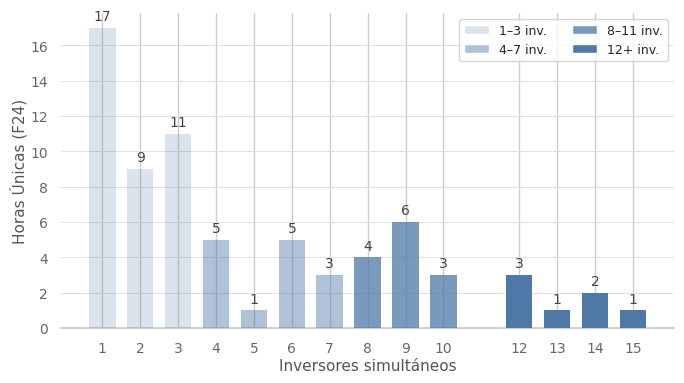

In [ ]:
# ─────────────────────────────────────────────
# Naturaleza sistémica
# Gráfica 1: Histograma de inversores simultáneos
# Gráfica 2: Scatter duración vs inversores simultáneos
# Fuente: dataframe f24 con columnas reales
# ─────────────────────────────────────────────

# ── Paleta de grupos ──────────────────────────
color_grupo = {
    'C': '#4e79a7',
    'A': '#a0cbe8',
    'B': '#f28e2b',
    'D': '#ffbe7d'
}
BASE_COLOR = '#4e79a7'   # azul grupo C como base para gráficas sistémicas

# ── Preparación de datos ──────────────────────
# Agrupo por hora única de evento
df_hora = (
    f24
    .groupby('fecha_referencia_abierta')
    .agg(
        n_inversores=('inversor', 'nunique'),
        duracion_min=('evento_minutos', 'mean')
    )
    .reset_index()
)

# ═══════════════════════════════════════════════
# GRÁFICA 1 — Histograma de inversores simultáneos
# ═══════════════════════════════════════════════
dist = df_hora['n_inversores'].value_counts().sort_index()

def alpha_from_n(n):
    if n >= 12: return 1.00
    if n >= 8:  return 0.75
    if n >= 4:  return 0.45
    return 0.20

r, g, b = tuple(int(BASE_COLOR.lstrip('#')[i:i+2], 16) / 255 for i in (0, 2, 4))
bar_colors = [(*( r, g, b), alpha_from_n(n)) for n in dist.index]

fig1, ax1 = plt.subplots(figsize=(7, 4))
fig1.patch.set_facecolor('white')
ax1.set_facecolor('white')

bars = ax1.bar(dist.index, dist.values, color=bar_colors, width=0.7,
               linewidth=0, zorder=3)

# etiquetas sobre cada barra
for bar, val in zip(bars, dist.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.25,
             str(val), ha='center', va='bottom', fontsize=10,
             color='#444444')

ax1.set_xlabel('Inversores simultáneos', fontsize=11, color='#555555', labelpad=2)
ax1.set_ylabel('Horas Únicas (F24)', fontsize=11, color='#555555', labelpad=2)
#ax1.set_title('Horas únicas con F24 según cantidad de inversores afectados',
#              fontsize=12, fontweight='normal', color='#222222', pad=12)

ax1.set_xticks(dist.index)
ax1.tick_params(colors='#666666', labelsize=10)
ax1.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax1.grid(axis='y', color='#e0e0e0', linewidth=0.7, zorder=0)
ax1.spines[['top', 'right', 'left']].set_visible(False)
ax1.spines['bottom'].set_color('#cccccc')

# leyenda de intensidad
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor=(*( r, g, b), 0.20), label='1–3 inv.'),
    Patch(facecolor=(*( r, g, b), 0.45), label='4–7 inv.'),
    Patch(facecolor=(*( r, g, b), 0.75), label='8–11 inv.'),
    Patch(facecolor=(*( r, g, b), 1.00), label='12+ inv.'),
]
ax1.legend(handles=leyenda, fontsize=9, frameon=True,
           loc='upper right', ncol=2)

plt.tight_layout()
plt.show()
#print("✓ Guardada: f24_slide3_histograma_simultaneos.png")



#### Duracion por inversores simultaneos

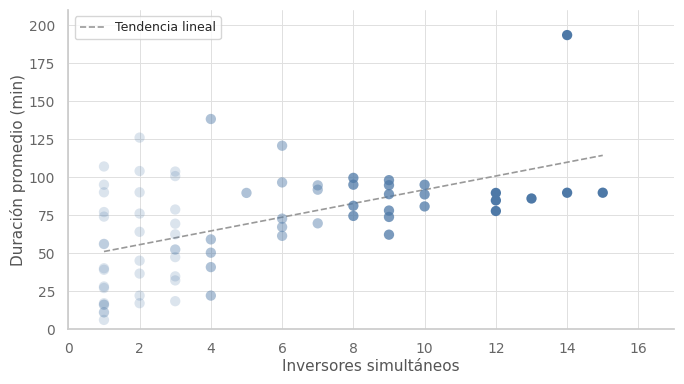

In [ ]:

# ═══════════════════════════════════════════════
# GRÁFICA 2 — Scatter: duración vs inversores simultáneos
# ═══════════════════════════════════════════════
scatter_colors = [(*( r, g, b), alpha_from_n(n)) for n in df_hora['n_inversores']]

fig2, ax2 = plt.subplots(figsize=(7, 4))
fig2.patch.set_facecolor('white')
ax2.set_facecolor('white')

ax2.scatter(
    df_hora['n_inversores'],
    df_hora['duracion_min'],
    color=scatter_colors,
    s=55,
    linewidths=0,
    zorder=3
)

# línea de tendencia
z = np.polyfit(df_hora['n_inversores'], df_hora['duracion_min'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_hora['n_inversores'].min(), df_hora['n_inversores'].max(), 100)
ax2.plot(x_line, p(x_line), color='#999999', linewidth=1.2,
         linestyle='--', zorder=2, label='Tendencia lineal')

ax2.set_xlabel('Inversores simultáneos', fontsize=11, color='#555555', labelpad=2)
ax2.set_ylabel('Duración promedio (min)', fontsize=11, color='#555555', labelpad=2)
#ax2.set_title('Duración del evento según inversores simultáneos afectados',
#              fontsize=12, fontweight='normal', color='#222222', pad=12)

ax2.set_xlim(0, 17)
ax2.set_ylim(0, 210)
ax2.tick_params(colors='#666666', labelsize=10)
ax2.grid(color='#e0e0e0', linewidth=0.7, zorder=0)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#cccccc')
ax2.legend(fontsize=9, frameon=True)

plt.tight_layout()
plt.show()
#print("✓ Guardada: f24_slide3_scatter_duracion.png")

#### Patron horario

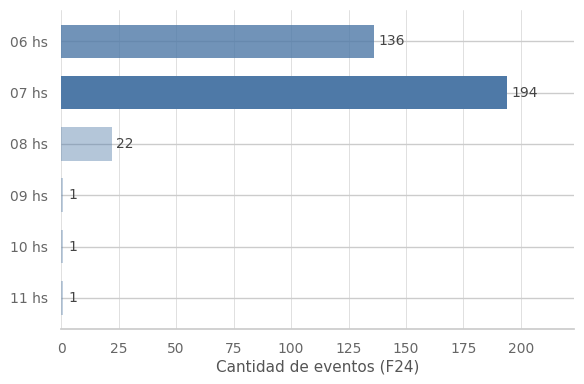

In [ ]:
# ─────────────────────────────────────────────
# F24 - Patrón horario y temporal
# Gráfica 1: Distribución de eventos por hora
# Gráfica 2: Heatmap semana × hora del día
# Fuente: dataframe f24 con columnas reales
# ─────────────────────────────────────────────


# ── Paleta ────────────────────────────────────
BASE_COLOR = '#4e79a7'
r, g, b = tuple(int(BASE_COLOR.lstrip('#')[i:i+2], 16) / 255 for i in (0, 2, 4))

# ── Preparación de datos ──────────────────────
f24['hora_int'] = f24['fecha_referencia_abierta'].dt.hour
f24['semana']   = f24['fecha_referencia_abierta'].dt.isocalendar().week.astype(int)
f24['mes_str']  = f24['fecha_referencia_abierta'].dt.strftime('%b')

# ═══════════════════════════════════════════════
# GRÁFICA 1 — Distribución por hora del día
# ═══════════════════════════════════════════════
dist_hora = f24.groupby('hora_int').size().sort_index()
max_h = dist_hora.max()
bar_colors = [(r, g, b, 0.35 + 0.65 * (v / max_h)) for v in dist_hora.values]

fig1, ax1 = plt.subplots(figsize=(6, 4))
fig1.patch.set_facecolor('white')
ax1.set_facecolor('white')

bars = ax1.barh(
    [f'{h:02d} hs' for h in dist_hora.index],
    dist_hora.values,
    color=bar_colors,
    height=0.65,
    linewidth=0
)

for bar, val in zip(bars, dist_hora.values):
    ax1.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
             str(val), va='center', fontsize=10, color='#444444')

ax1.set_xlabel('Cantidad de eventos (F24)', fontsize=11, color='#555555', labelpad=2)
#ax1.set_title('Distribución por hora del día', fontsize=12,
#              fontweight='normal', color='#222222', pad=10)
ax1.tick_params(colors='#666666', labelsize=10)
ax1.grid(axis='x', color='#e0e0e0', linewidth=0.7, zorder=0)
ax1.spines[['top', 'right', 'left']].set_visible(False)
ax1.spines['bottom'].set_color('#cccccc')
ax1.set_xlim(0, max_h * 1.15)
ax1.invert_yaxis()

plt.tight_layout()
plt.show()
#print("✓ Guardada: f24_slide4_hora.png")




#### Heatmap eventos x hora x mes

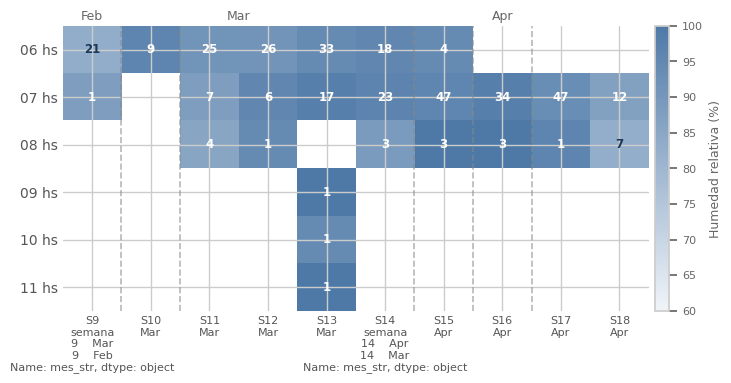

In [ ]:
# ═══════════════════════════════════════════════
# Color de celda = humedad promedio (rhum)
# Anotación    = cantidad de eventos F24
# ═══════════════════════════════════════════════

# ── Pivot de eventos F24 por semana × hora ────
df_ev = (
    f24
    .groupby(['semana', 'hora_int'])
    .agg(n_eventos=('inversor', 'count'))
    .reset_index()
)
pivot_ev = df_ev.pivot(index='hora_int', columns='semana', values='n_eventos').fillna(0)

# ── Pivot de humedad promedio por semana × hora ─
# Usar todas las filas de f24 (cada evento ya tiene rhum asociado)
df_rh = (
    f24
    .groupby(['semana', 'hora_int'])
    .agg(rhum_mean=('rhum', 'mean'))
    .reset_index()
)
pivot_rh = df_rh.pivot(index='hora_int', columns='semana', values='rhum_mean')

# Alinear índices: usar solo semanas/horas presentes en eventos
pivot_rh = pivot_rh.reindex(index=pivot_ev.index, columns=pivot_ev.columns)

# ── Etiquetas de semana con mes ───────────────
semana_mes = (
    f24[['semana', 'mes_str']]
    .drop_duplicates()
    .sort_values('semana')
    .set_index('semana')['mes_str']
)
col_labels = [f'S{s}\n{semana_mes.get(s, "")}' for s in pivot_ev.columns]

# ── Colormap: blanco → azul base (humedad) ────
cmap_rh = mcolors.LinearSegmentedColormap.from_list(
    'f24_rhum', ['#f0f4f9', BASE_COLOR], N=256
)

fig2, ax2 = plt.subplots(figsize=(7.5, 4))
fig2.patch.set_facecolor('white')
ax2.set_facecolor('white')

# Fondo: humedad — vmin/vmax fijos para dar contexto (60-100%)
rh_vals = pivot_rh.values
im = ax2.imshow(
    rh_vals,
    aspect='auto',
    cmap=cmap_rh,
    vmin=60, vmax=100,
    interpolation='nearest'
)

# ── Anotaciones: eventos F24 ──────────────────
for i in range(pivot_ev.shape[0]):
    for j in range(pivot_ev.shape[1]):
        n_ev = int(pivot_ev.values[i, j])
        rh   = rh_vals[i, j] if not np.isnan(rh_vals[i, j]) else 0
        if n_ev > 0:
            # texto blanco si celda oscura, azul oscuro si clara
            norm_rh = (rh - 60) / 40
            color_txt = 'white' if norm_rh > 0.6 else '#1a3a5c'
            ax2.text(j, i, str(n_ev),
                     ha='center', va='center',
                     fontsize=8.5, fontweight='bold',
                     color=color_txt)

# ── Ejes ──────────────────────────────────────
ax2.set_xticks(range(len(pivot_ev.columns)))
ax2.set_xticklabels(col_labels, fontsize=8, color='#555555')
ax2.set_yticks(range(len(pivot_ev.index)))
ax2.set_yticklabels([f'{h:02d} hs' for h in pivot_ev.index],
                     fontsize=10, color='#555555')
#ax2.set_title('Heatmap F24: humedad promedio por celda — número = eventos registrados',
#              fontsize=12, fontweight='normal', color='#222222', pad=10)

# ── Separadores y etiquetas de mes ───────────
meses_unicos = semana_mes.loc[pivot_ev.columns]
cambios = [i for i in range(1, len(pivot_ev.columns))
           if meses_unicos.iloc[i] != meses_unicos.iloc[i-1]]
for c in cambios:
    ax2.axvline(c - 0.5, color='#888888', linewidth=1.2, linestyle='--', alpha=0.6)

for mes, grupo in meses_unicos.groupby(meses_unicos, sort=False):
    indices = [pivot_ev.columns.get_loc(s) for s in grupo.index]
    centro  = np.mean(indices)
    ax2.text(centro, -0.7, mes,
             ha='center', va='center', fontsize=9,
             color='#666666', fontweight='500',
             transform=ax2.transData)

# ── Colorbar ──────────────────────────────────
cbar = fig2.colorbar(im, ax=ax2, pad=0.01, fraction=0.025)
cbar.set_label('Humedad relativa (%)', fontsize=9, color='#666666')
cbar.ax.tick_params(labelsize=8, colors='#666666')
cbar.outline.set_visible(True)

ax2.tick_params(length=0)
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()
#print("✓ Guardada: f24_slide4_heatmap_opcionA.png")

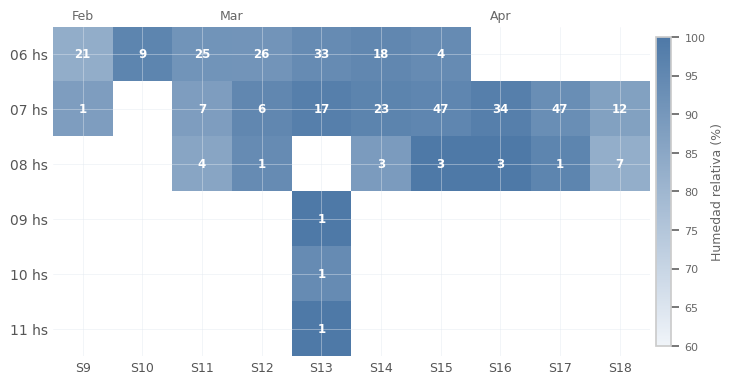

In [ ]:
# ── Pivot de eventos F24 por semana × hora ────
df_ev = (
    f24
    .groupby(['semana', 'hora_int'])
    .agg(n_eventos=('inversor', 'count'))
    .reset_index()
)
pivot_ev = df_ev.pivot(index='hora_int', columns='semana', values='n_eventos').fillna(0)

# ── Pivot de humedad promedio por semana × hora ─
df_rh = (
    f24
    .groupby(['semana', 'hora_int'])
    .agg(rhum_mean=('rhum', 'mean'))
    .reset_index()
)
pivot_rh = df_rh.pivot(index='hora_int', columns='semana', values='rhum_mean')

# Alinear índices
pivot_rh = pivot_rh.reindex(index=pivot_ev.index, columns=pivot_ev.columns)

# ── SOLUCIÓN AL EJE X: Solo incluir el nombre de la semana (S9, S10...) ──
col_labels = [f'S{int(s)}' for s in pivot_ev.columns]

# Extraer relación semana-mes limpia sin metadatos para los títulos superiores
semana_mes = (
    f24[['semana', 'mes_str']]
    .drop_duplicates()
    .sort_values('semana')
    .set_index('semana')['mes_str']
)

# ── Colormap ────
cmap_rh = mcolors.LinearSegmentedColormap.from_list(
    'f24_rhum', ['#f0f4f9', BASE_COLOR], N=256
)

fig2, ax2 = plt.subplots(figsize=(7.5, 4))
fig2.patch.set_facecolor('white')
ax2.set_facecolor('white')

# Fondo
rh_vals = pivot_rh.values
im = ax2.imshow(
    rh_vals,
    aspect='auto',
    cmap=cmap_rh,
    vmin=60, vmax=100,
    interpolation='nearest'
)

# ── Anotaciones: eventos F24 ──────────────────
for i in range(pivot_ev.shape[0]):
    for j in range(pivot_ev.shape[1]):
        n_ev = int(pivot_ev.values[i, j])
        rh   = rh_vals[i, j] if not np.isnan(rh_vals[i, j]) else 0
        if n_ev > 0:
            norm_rh = (rh - 60) / 40
            color_txt = 'white' if norm_rh > 0.6 else 'white'# #1a3a5c
            ax2.text(j, i, str(n_ev),
                     ha='center', va='center',
                     fontsize=8.5, fontweight='bold',
                     color=color_txt)

# ── Ejes corregidos y limpios ─────────────────
ax2.set_xticks(range(len(pivot_ev.columns)))
ax2.set_xticklabels(col_labels, fontsize=9, color='#555555') # Ahora solo dice S9, S10, etc.

ax2.set_yticks(range(len(pivot_ev.index)))
ax2.set_yticklabels([f'{h:02d} hs' for h in pivot_ev.index],
                     fontsize=10, color='#555555')

# ── Separadores y etiquetas de mes (Superiores) ──
meses_unicos = semana_mes.loc[pivot_ev.columns]
cambios = [i for i in range(1, len(pivot_ev.columns))
           if meses_unicos.iloc[i] != meses_unicos.iloc[i-1]]
'''
for c in cambios:
    ax2.axvline(c - 0.5, color='#888888', linewidth=1.2, linestyle='--', alpha=0.6)
'''
# Posicionamiento limpio de los nombres de los meses arriba
for mes, grupo in meses_unicos.groupby(meses_unicos, sort=False):
    indices = [pivot_ev.columns.get_loc(s) for s in grupo.index]
    centro  = np.mean(indices)
    ax2.text(centro, -0.7, str(mes), # Convertimos explícitamente a string plano
             ha='center', va='center', fontsize=9,
             color='#666666', fontweight='500',
             transform=ax2.transData)

# ── Colorbar ──────────────────────────────────
cbar = fig2.colorbar(im, ax=ax2, pad=0.01, fraction=0.025)
cbar.set_label('Humedad relativa (%)', fontsize=9, color='#666666')
cbar.ax.tick_params(labelsize=8, colors='#666666')
cbar.outline.set_visible(True)

# ── CONTROL DEL GRID (Cuadrícula entre celdas) ──
ax2.grid(True, which='major', color='#e2e8f0', linestyle='-', linewidth=0.5, alpha=0.6)
# El valor de alpha (0.5) le da opacidad para que no compita con los números.

# Asegura que el grid se dibuje por detrás de las anotaciones de texto
ax2.set_axisbelow(True)


ax2.tick_params(length=0)
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

#### Impacto humedad en F24

In [ ]:
# Analizo la humedad real en el momento exacto de cada falla F24
resumen_humedad_real = f24['rhum'].describe()
print(resumen_humedad_real)

# Contar cuántas fallas ocurrieron con humedad real mayor al 85%
fallas_alta_humedad = (f24['rhum'] >= 85).sum()
print(f"\nFallas con humedad real >= 85%: {fallas_alta_humedad} de {len(f24)} ({fallas_alta_humedad/len(f24)*100:.1f}%)")

count    355.000000
mean      93.225352
std        5.943228
min       78.000000
25%       88.000000
50%       94.000000
75%      100.000000
max      100.000000
Name: rhum, dtype: float64

Fallas con humedad real >= 85%: 318 de 355 (89.6%)


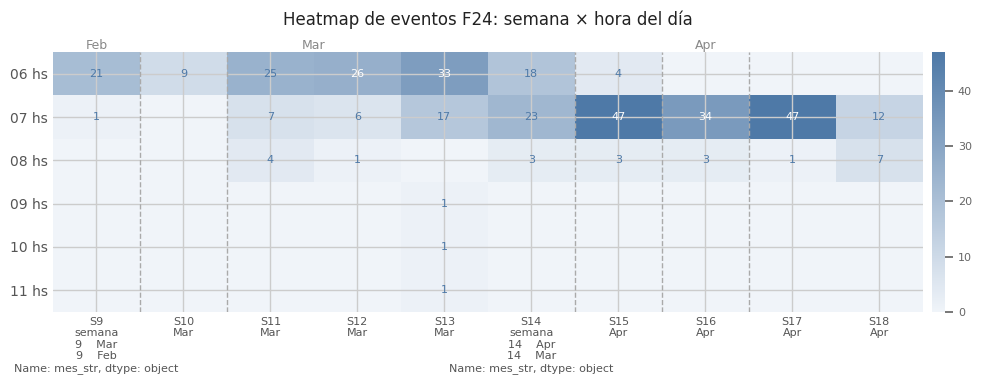

In [ ]:
# ═══════════════════════════════════════════════
# Heatmap semana × hora del día
# ═══════════════════════════════════════════════

# Agrupo por semana ISO y hora — contar eventos únicos (horas únicas)
df_heat = (
    f24
    .groupby(['semana', 'hora_int'])
    .agg(n_eventos=('inversor', 'count'))
    .reset_index()
)

# Pivot: filas = horas, columnas = semanas
pivot = df_heat.pivot(index='hora_int', columns='semana', values='n_eventos').fillna(0)

# Etiquetas de semana con mes
semana_mes = (
    f24[['semana', 'mes_str']]
    .drop_duplicates()
    .sort_values('semana')
    .set_index('semana')['mes_str']
)
col_labels = [f'S{s}\n{semana_mes.get(s, "")}' for s in pivot.columns]

# Colormap personalizado desde blanco al color base
cmap = mcolors.LinearSegmentedColormap.from_list(
    'f24_blue', ['#f0f4f9', BASE_COLOR], N=256
)

fig2, ax2 = plt.subplots(figsize=(10, 4))
fig2.patch.set_facecolor('white')
ax2.set_facecolor('white')

im = ax2.imshow(pivot.values, aspect='auto', cmap=cmap,
                vmin=0, vmax=pivot.values.max())

# Anotaciones en celdas
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = int(pivot.values[i, j])
        if val > 0:
            norm_val = val / pivot.values.max()
            color_txt = 'white' if norm_val > 0.55 else BASE_COLOR
            ax2.text(j, i, str(val), ha='center', va='center',
                     fontsize=8, color=color_txt, fontweight='normal')

# Ejes
ax2.set_xticks(range(len(pivot.columns)))
ax2.set_xticklabels(col_labels, fontsize=8, color='#555555')
ax2.set_yticks(range(len(pivot.index)))
ax2.set_yticklabels([f'{h:02d} hs' for h in pivot.index],
                     fontsize=10, color='#555555')

ax2.set_title('Heatmap de eventos F24: semana × hora del día',
              fontsize=12, fontweight='normal', color='#222222', pad=20)

# Separadores de mes
meses_unicos = semana_mes.loc[pivot.columns]
cambios = [i for i in range(1, len(pivot.columns))
           if meses_unicos.iloc[i] != meses_unicos.iloc[i-1]]
for c in cambios:
    ax2.axvline(c - 0.5, color='#aaaaaa', linewidth=1, linestyle='--')

# Etiqueta de mes centrada
for i, (mes, grupo) in enumerate(meses_unicos.groupby(meses_unicos, sort=False)):
    indices = [pivot.columns.get_loc(s) for s in grupo.index]
    centro = np.mean(indices)
    ax2.text(centro, 1, mes,
             ha='center', va='bottom', fontsize=9,
             color='#888888', transform=ax2.get_xaxis_transform())

# Colorbar
cbar = fig2.colorbar(im, ax=ax2, pad=0.01, fraction=0.015)
cbar.ax.tick_params(labelsize=8, colors='#666666')
cbar.outline.set_visible(False)

ax2.tick_params(length=0)
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


#### Causalidades

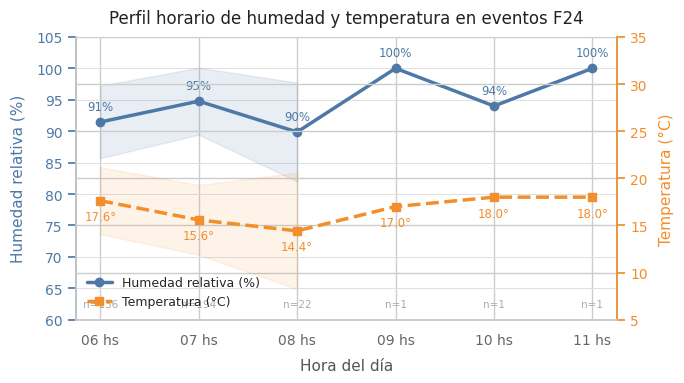

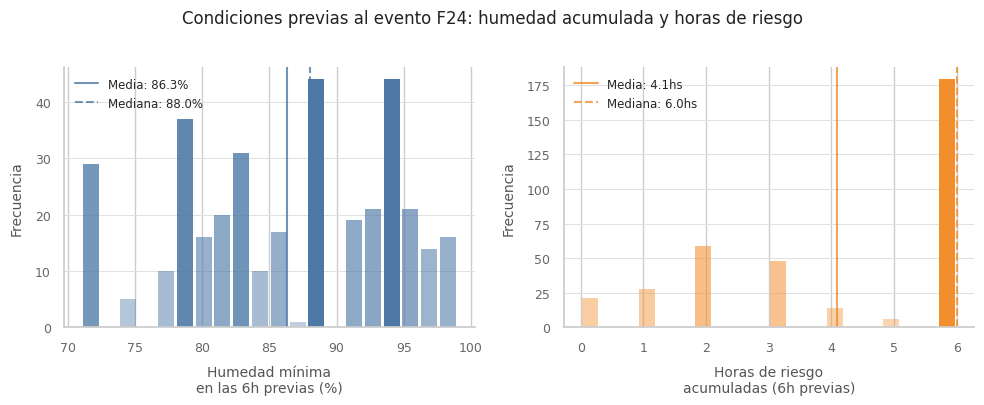

In [ ]:
# ─────────────────────────────────────────────
# F24 — Evidencia del mecanismo causal
# Gráfica 1: Perfil horario de rhum y temp
# Gráfica 2: Distribución de f2x_rhum_min_6h
#            y f2x_horas_riesgo_6h
# Fuente: dataframe f24
# ─────────────────────────────────────────────

BASE_COLOR = '#4e79a7'
ORANGE     = '#f28e2b'
r, g, b    = tuple(int(BASE_COLOR.lstrip('#')[i:i+2], 16) / 255 for i in (0, 2, 4))
or_, og, ob = 242/255, 142/255, 43/255

# ── Preparación ──────────────────────────────
f24['hora_int'] = f24['fecha_referencia_abierta'].dt.hour


# ═══════════════════════════════════════════════
# GRÁFICA 1 — Perfil horario: rhum y temp
# ═══════════════════════════════════════════════
perfil = (
    f24
    .groupby('hora_int')
    .agg(
        rhum_mean=('rhum', 'mean'),
        rhum_std=('rhum', 'std'),
        temp_mean=('temp', 'mean'),
        temp_std=('temp', 'std'),
        n=('rhum', 'count')
    )
    .reset_index()
    .sort_values('hora_int')
)

fig1, ax1 = plt.subplots(figsize=(7, 4))
fig1.patch.set_facecolor('white')
ax1.set_facecolor('white')
ax2_twin = ax1.twinx()

# rhum — eje izquierdo
ax1.plot(perfil['hora_int'], perfil['rhum_mean'],
         color=BASE_COLOR, lw=2.5, marker='o', markersize=6,
         label='Humedad relativa (%)', zorder=4)
ax1.fill_between(perfil['hora_int'],
                 perfil['rhum_mean'] - perfil['rhum_std'],
                 perfil['rhum_mean'] + perfil['rhum_std'],
                 color=BASE_COLOR, alpha=0.12, zorder=3)

# temp — eje derecho
ax2_twin.plot(perfil['hora_int'], perfil['temp_mean'],
              color=ORANGE, lw=2.5, marker='s', markersize=6,
              linestyle='--', label='Temperatura (°C)', zorder=4)
ax2_twin.fill_between(perfil['hora_int'],
                      perfil['temp_mean'] - perfil['temp_std'],
                      perfil['temp_mean'] + perfil['temp_std'],
                      color=ORANGE, alpha=0.10, zorder=3)

# anotaciones de valor en cada punto
for _, row in perfil.iterrows():
    ax1.annotate(f"{row['rhum_mean']:.0f}%",
                 (row['hora_int'], row['rhum_mean']),
                 textcoords='offset points', xytext=(0, 9),
                 ha='center', fontsize=8.5, color=BASE_COLOR)
    ax2_twin.annotate(f"{row['temp_mean']:.1f}°",
                      (row['hora_int'], row['temp_mean']),
                      textcoords='offset points', xytext=(0, -14),
                      ha='center', fontsize=8.5, color=ORANGE)

# ejes y formato
ax1.set_xlabel('Hora del día', fontsize=11, color='#555555', labelpad=8)
ax1.set_ylabel('Humedad relativa (%)', fontsize=11, color=BASE_COLOR, labelpad=8)
ax2_twin.set_ylabel('Temperatura (°C)', fontsize=11, color=ORANGE, labelpad=8)
ax1.set_title('Perfil horario de humedad y temperatura en eventos F24',
              fontsize=12, fontweight='normal', color='#222222', pad=10)

ax1.set_xticks(perfil['hora_int'])
ax1.set_xticklabels([f'{h:02d} hs' for h in perfil['hora_int']],
                     fontsize=10, color='#666666')
ax1.tick_params(axis='y', colors=BASE_COLOR, labelsize=10)
ax2_twin.tick_params(axis='y', colors=ORANGE, labelsize=10)

ax1.set_ylim(60, 105)
ax2_twin.set_ylim(5, 35)

ax1.grid(axis='y', color='#e0e0e0', linewidth=0.7, zorder=0)
ax1.spines[['top']].set_visible(False)
ax1.spines[['left']].set_color(BASE_COLOR)
ax1.spines[['bottom', 'right']].set_color('#cccccc')
ax2_twin.spines[['top']].set_visible(False)
ax2_twin.spines[['right']].set_color(ORANGE)

# leyenda unificada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           fontsize=9, frameon=False, loc='lower left')

# anotación de n por hora
for _, row in perfil.iterrows():
    ax1.text(row['hora_int'], 62, f"n={int(row['n'])}",
             ha='center', fontsize=7.5, color='#aaaaaa')

plt.tight_layout()
plt.show()
#print("✓ Guardada: f24_slide5_perfil_horario.png")


# ═══════════════════════════════════════════════
# GRÁFICA 2 — Distribución de predictores
# f2x_rhum_min_6h y f2x_horas_riesgo_6h
# ═══════════════════════════════════════════════
fig2, axes = plt.subplots(1, 2, figsize=(10, 4))
fig2.patch.set_facecolor('white')

vars_plot = [
    dict(col='f2x_rhum_min_6h',
         label='Humedad mínima\nen las 6h previas (%)',
         color=BASE_COLOR,
         unit='%'),
    dict(col='f2x_horas_riesgo_6h',
         label='Horas de riesgo\nacumuladas (6h previas)',
         color=ORANGE,
         unit='hs'),
]

for ax, v in zip(axes, vars_plot):
    data = f24[v['col']].dropna()
    cr, cg, cb_ = tuple(int(v['color'].lstrip('#')[i:i+2], 16)/255 for i in (0,2,4))

    # histograma
    n_bins = 20
    counts, edges = np.histogram(data, bins=n_bins)
    max_c = counts.max()
    bin_centers = (edges[:-1] + edges[1:]) / 2

    bar_colors = [(cr, cg, cb_, 0.35 + 0.65*(c/max_c)) for c in counts]
    ax.bar(bin_centers, counts, width=(edges[1]-edges[0])*0.85,
           color=bar_colors, linewidth=0)

    # líneas de estadísticos
    for stat, ls, lbl in [
        (data.mean(),   '-',  f'Media: {data.mean():.1f}{v["unit"]}'),
        (data.median(), '--', f'Mediana: {data.median():.1f}{v["unit"]}'),
    ]:
        ax.axvline(stat, color=v['color'], lw=1.5, linestyle=ls,
                   alpha=0.8, label=lbl)

    ax.set_xlabel(v['label'], fontsize=10, color='#555555', labelpad=8)
    ax.set_ylabel('Frecuencia', fontsize=10, color='#555555', labelpad=8)
    ax.tick_params(colors='#666666', labelsize=9)
    ax.grid(axis='y', color='#e0e0e0', linewidth=0.7)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#cccccc')
    ax.legend(fontsize=8.5, frameon=False)
    ax.set_facecolor('white')

fig2.suptitle('Condiciones previas al evento F24: humedad acumulada y horas de riesgo',
              fontsize=12, fontweight='normal', color='#222222', y=1.01)

plt.tight_layout()
plt.show()


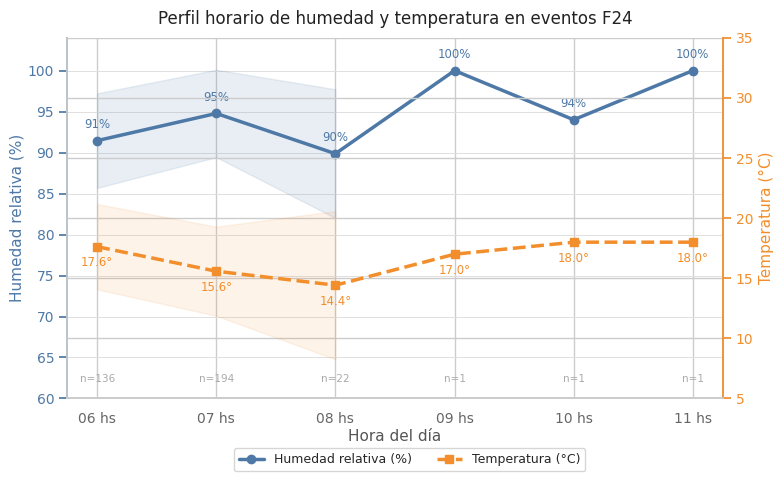

In [ ]:
# ─────────────────────────────────────────────
# Evidencia del mecanismo causal
# Gráfica 1: Perfil horario de rhum y temp
# Gráfica 2: Distribución de f2x_rhum_min_6h
#            y f2x_horas_riesgo_6h
# Fuente: dataframe f24
# ─────────────────────────────────────────────

BASE_COLOR = '#4e79a7'
ORANGE     = '#f28e2b'
r, g, b    = tuple(int(BASE_COLOR.lstrip('#')[i:i+2], 16) / 255 for i in (0, 2, 4))
or_, og, ob = 242/255, 142/255, 43/255

# ── Preparación ──────────────────────────────
f24['hora_int'] = f24['fecha_referencia_abierta'].dt.hour


# ═══════════════════════════════════════════════
# GRÁFICA 1 — Perfil horario: rhum y temp
# ═══════════════════════════════════════════════
perfil = (
    f24
    .groupby('hora_int')
    .agg(
        rhum_mean=('rhum', 'mean'),
        rhum_std=('rhum', 'std'),
        temp_mean=('temp', 'mean'),
        temp_std=('temp', 'std'),
        n=('rhum', 'count')
    )
    .reset_index()
    .sort_values('hora_int')
)

fig1, ax1 = plt.subplots(figsize=(8, 5))
fig1.patch.set_facecolor('white')
ax1.set_facecolor('white')
ax2_twin = ax1.twinx()

# rhum — eje izquierdo
ax1.plot(perfil['hora_int'], perfil['rhum_mean'],
         color=BASE_COLOR, lw=2.5, marker='o', markersize=6,
         label='Humedad relativa (%)', zorder=4)
ax1.fill_between(perfil['hora_int'],
                 perfil['rhum_mean'] - perfil['rhum_std'],
                 perfil['rhum_mean'] + perfil['rhum_std'],
                 color=BASE_COLOR, alpha=0.12, zorder=3)

# temp — eje derecho
ax2_twin.plot(perfil['hora_int'], perfil['temp_mean'],
              color=ORANGE, lw=2.5, marker='s', markersize=6,
              linestyle='--', label='Temperatura (°C)', zorder=4)
ax2_twin.fill_between(perfil['hora_int'],
                      perfil['temp_mean'] - perfil['temp_std'],
                      perfil['temp_mean'] + perfil['temp_std'],
                      color=ORANGE, alpha=0.10, zorder=3)

# anotaciones de valor en cada punto
for _, row in perfil.iterrows():
    ax1.annotate(f"{row['rhum_mean']:.0f}%",
                 (row['hora_int'], row['rhum_mean']),
                 textcoords='offset points', xytext=(0, 9),
                 ha='center', fontsize=8.5, color=BASE_COLOR)
    ax2_twin.annotate(f"{row['temp_mean']:.1f}°",
                      (row['hora_int'], row['temp_mean']),
                      textcoords='offset points', xytext=(0, -14),
                      ha='center', fontsize=8.5, color=ORANGE)

# ejes y formato
ax1.set_xlabel('Hora del día', fontsize=11, color='#555555', labelpad=2)
ax1.set_ylabel('Humedad relativa (%)', fontsize=11, color=BASE_COLOR, labelpad=2)
ax2_twin.set_ylabel('Temperatura (°C)', fontsize=11, color=ORANGE, labelpad=4)
ax1.set_title('Perfil horario de humedad y temperatura en eventos F24',
              fontsize=12, fontweight='normal', color='#222222', pad=10)

ax1.set_xticks(perfil['hora_int'])
ax1.set_xticklabels([f'{h:02d} hs' for h in perfil['hora_int']],
                     fontsize=10, color='#666666')
ax1.tick_params(axis='y', colors=BASE_COLOR, labelsize=10)
ax2_twin.tick_params(axis='y', colors=ORANGE, labelsize=10)

ax1.set_ylim(60, 104)
ax2_twin.set_ylim(5, 35)

ax1.grid(axis='y', color='#e0e0e0', linewidth=0.7, zorder=0)
ax1.spines[['top']].set_visible(False)
ax1.spines[['left']].set_color(BASE_COLOR)
ax1.spines[['bottom', 'right']].set_color('#cccccc')
ax2_twin.spines[['top']].set_visible(False)
ax2_twin.spines[['right']].set_color(ORANGE)

# leyenda unificada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           fontsize=9, frameon=True, ncol=2, bbox_to_anchor=(.8, -0.12))

# anotación de n por hora
for _, row in perfil.iterrows():
    ax1.text(row['hora_int'], 62, f"n={int(row['n'])}",
             ha='center', fontsize=7.5, color='#aaaaaa')

plt.tight_layout()
plt.show()


##### Evolucion variables -8/-1 F24 y sin F24

In [ ]:
# ─────────────────────────────────────────────
# F24 — Perfil climático 8h previas
# Comparativa: Con F24 vs Sin F24
# Referencia Sin F24: hora de salida del sol
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

BASE_COLOR = '#4e79a7'
GREEN      = '#2d6a4f'
RED        = '#c0392b'
ORANGE     = '#f28e2b'

# ═══════════════════════════════════════════════
# 1. Reconstruir f24_dias con rango correcto
# ═══════════════════════════════════════════════
f24['fecha_dia'] = f24['fecha_referencia_abierta'].dt.normalize()
f24['hora_int']  = f24['fecha_referencia_abierta'].dt.hour

# días con F24 en ventana 06-08 hs — hora real del primer evento
f24_por_dia = (
    f24[f24['hora_int'].isin([6, 7, 8])]
    .groupby('fecha_dia')
    .agg(hora_real_inicio=('hora_abierta', 'min'))
    .reset_index()
)
f24_por_dia['f24'] = 1

# todos los días del período desde df_clima
todos_los_dias = pd.DataFrame({
    'fecha_dia': pd.to_datetime(
        df_clima['time'].dt.normalize().unique()
    )
}).sort_values('fecha_dia').reset_index(drop=True)

# días sin F24
dias_sin_f24 = todos_los_dias.merge(
    f24_por_dia[['fecha_dia']],
    on='fecha_dia', how='left', indicator=True
)
dias_sin_f24 = dias_sin_f24[
    dias_sin_f24['_merge'] == 'left_only'
][['fecha_dia']].copy()
dias_sin_f24['f24'] = 0

# join con horarios de sol
sol = df_horarios_sol[['fecha', 'salida']].copy()
sol['fecha_dia'] = pd.to_datetime(sol['fecha']).dt.normalize()

f24_por_dia   = f24_por_dia.merge(sol[['fecha_dia','salida']], on='fecha_dia', how='left')
dias_sin_f24  = dias_sin_f24.merge(sol[['fecha_dia','salida']], on='fecha_dia', how='left')

# para Sin F24: hora de referencia = salida del sol
dias_sin_f24['hora_real_inicio'] = dias_sin_f24['salida']

# unificar
f24_dias = pd.concat([
    f24_por_dia[['fecha_dia','f24','hora_real_inicio','salida']],
    dias_sin_f24[['fecha_dia','f24','hora_real_inicio','salida']]
], ignore_index=True).sort_values('fecha_dia').reset_index(drop=True)

print(f"Total días: {len(f24_dias)}")
print(f"Con F24:    {f24_dias['f24'].sum()}")
print(f"Sin F24:    {(f24_dias['f24']==0).sum()}")
print()

# ═══════════════════════════════════════════════
# 2. Calcular perfil climático 8h previas
#    para Con F24 y Sin F24
# ═══════════════════════════════════════════════
clima_idx = df_clima.set_index('time').sort_index()
VENTANA   = list(range(1, 9))


Total días: 71
Con F24:    42
Sin F24:    29



In [ ]:
# ═══════════════════════════════════════════════
# Calcular perfil climático 8h previas
# para Con F24 y Sin F24
# ═══════════════════════════════════════════════
clima_idx = df_clima.set_index('time').sort_index()
VENTANA   = list(range(1, 9))

def perfil_8h(df_grupo, var_list, clima_idx, ventana):
    """
    Para cada día en df_grupo, extraer variables climáticas
    en las N horas previas a hora_real_inicio.
    Retorna dataframe con mean y std por hora previa.
    """
    registros = []
    for _, row in df_grupo.iterrows():
        for h in ventana:
            hora_buscar = row['hora_real_inicio'] - pd.Timedelta(hours=h)
            hora_buscar = hora_buscar.floor('h')
            if hora_buscar in clima_idx.index:
                rec = {'horas_previas': h}
                for v in var_list:
                    rec[v] = clima_idx.loc[hora_buscar, v]
                registros.append(rec)

    df = pd.DataFrame(registros)
    resumen = (
        df.groupby('horas_previas')
        .agg({v: ['mean','std'] for v in var_list})
        .reset_index()
        .sort_values('horas_previas', ascending=False)
    )
    # aplanar columnas
    resumen.columns = ['horas_previas'] + [
        f'{v}_{s}' for v in var_list for s in ['mean','std']
    ]
    resumen['label'] = resumen['horas_previas'].apply(lambda h: f'–{h}h')
    return resumen

vars_plot = ['riesgo_condensacion', 'rhum']

resumen_f24    = perfil_8h(f24_dias[f24_dias['f24']==1], vars_plot, clima_idx, VENTANA)
resumen_no_f24 = perfil_8h(f24_dias[f24_dias['f24']==0], vars_plot, clima_idx, VENTANA)

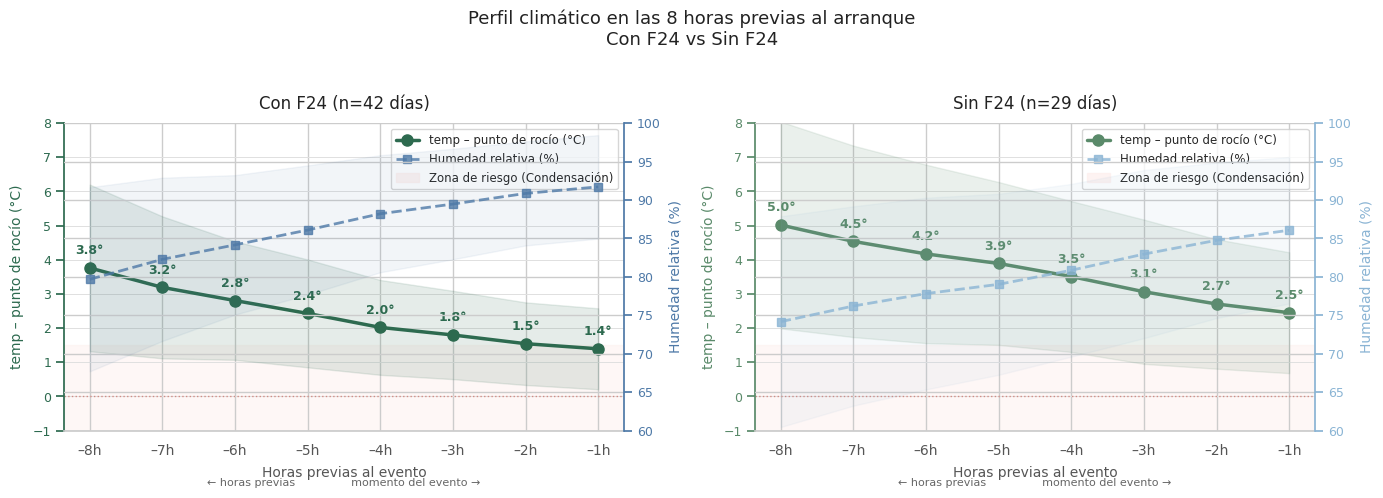

In [ ]:

# ═══════════════════════════════════════════════
# 3. Gráfica comparativa
# ═══════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

titulos  = ['Con F24 (n=42 días)', 'Sin F24 (n=29 días)']
resumenes = [resumen_f24, resumen_no_f24]
colores_rc = [GREEN, '#5a8a6a']
colores_rh = [BASE_COLOR, '#8ab4d4']

for ax, resumen, titulo, col_rc, col_rh in zip(
    axes, resumenes, titulos, colores_rc, colores_rh
):
    ax.set_facecolor('white')
    ax_rh = ax.twinx()

    x_real = np.arange(len(resumen))
    xlabels = resumen['label'].tolist()

    # zona crítica
    zona = ax.axhspan(-1, 1.5, color='#fdecea', alpha=0.4, zorder=0)
    ax.axhline(0, color=RED, lw=1, linestyle=':', alpha=0.5)

    # riesgo condensación
    y_rc  = resumen['riesgo_condensacion_mean'].values
    ys_rc = resumen['riesgo_condensacion_std'].values
    linea_rc, = ax.plot(x_real, y_rc, color=col_rc, lw=2.5,
                        marker='o', markersize=8, zorder=4,
                        label='temp – punto de rocío (°C)')
    ax.fill_between(x_real, y_rc - ys_rc, y_rc + ys_rc,
                    color=col_rc, alpha=0.12, zorder=3)
    for xi, yi in zip(x_real, y_rc):
        ax.annotate(f'{yi:.1f}°', (xi, yi),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=9,
                    color=col_rc, fontweight='bold')

    # humedad
    y_rh  = resumen['rhum_mean'].values
    ys_rh = resumen['rhum_std'].values
    linea_rh, = ax_rh.plot(x_real, y_rh, color=col_rh, lw=2,
                            marker='s', markersize=6, linestyle='--',
                            alpha=0.8, zorder=3,
                            label='Humedad relativa (%)')
    ax_rh.fill_between(x_real, y_rh - ys_rh, y_rh + ys_rh,
                       color=col_rh, alpha=0.07, zorder=2)

    # ejes
    ax.set_ylim(-1, 8)
    ax_rh.set_ylim(60, 100)
    ax.set_ylabel('temp – punto de rocío (°C)', fontsize=10,
                  color=col_rc, labelpad=6)
    ax_rh.set_ylabel('Humedad relativa (%)', fontsize=10,
                     color=col_rh, labelpad=6)
    ax.tick_params(axis='y', colors=col_rc, labelsize=9)
    ax_rh.tick_params(axis='y', colors=col_rh, labelsize=9)
    ax.set_xticks(x_real)
    ax.set_xticklabels(xlabels, fontsize=10, color='#555555')
    ax.set_xlabel('Horas previas al evento', fontsize=10,
                  color='#555555', labelpad=6)
    ax.set_title(titulo, fontsize=12, fontweight='normal',
                 color='#222222', pad=10)
    ax.grid(axis='y', color='#e0e0e0', linewidth=0.7, zorder=0)
    ax.spines[['top','right']].set_visible(False)
    ax.spines['left'].set_color(col_rc)
    ax.spines['bottom'].set_color('#cccccc')
    ax_rh.spines[['top','left']].set_visible(False)
    ax_rh.spines['right'].set_color(col_rh)
    ax_rh.spines['bottom'].set_visible(False)

    parche = mpatches.Patch(color='#fdecea', alpha=0.6,
                            label='Zona de riesgo (Condensación)')
    ax.legend(handles=[linea_rc, linea_rh, parche],
              fontsize=8.5, frameon=True, loc='upper right')

    ax.annotate('← horas previas                momento del evento →',
                xy=(0.5, -0.18), xycoords='axes fraction',
                ha='center', fontsize=8, color='black', alpha=0.6)

fig.suptitle(
    'Perfil climático en las 8 horas previas al arranque\n'
    'Con F24 vs Sin F24',
    fontsize=13, fontweight='normal', color='#222222', y=1.02
)

plt.tight_layout()
plt.show()

In [ ]:
# distribución de duración por inversor
duracion_stats = (
    f24
    .groupby('inversor')['evento_minutos']
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
    .round(1)
    .sort_values('mean', ascending=False)
)
print(duracion_stats.to_string())

# outliers por inversor (eventos > percentil 90 general)
p90 = f24['evento_minutos'].quantile(0.90)
print(f"\nPercentil 90 general: {p90:.0f} min")
outliers = f24[f24['evento_minutos'] > p90][['inversor','evento_minutos','fecha_referencia_abierta']]
print(f"\nEventos sobre p90 por inversor:")
print(outliers.groupby('inversor')['evento_minutos'].agg(['count','mean','max']).round(1).sort_values('max', ascending=False).to_string())

           mean  median   std  min  max  count
inversor                                      
B3        117.3   114.5  62.4    5  366     32
C1        105.2   101.0  54.5   28  372     43
C3         91.0    95.0  37.5    6  197     31
A1         87.8    87.0  29.9    6  196     23
C2         87.0    90.0  36.4    6  213     42
B4         85.5    89.0  65.5    6  365     27
A4         80.1    89.5  39.5    6  197     26
C4         75.6    89.0  47.4    5  191     16
A3         72.4    81.0  40.3    6  191     19
D1         72.0    89.0  30.9    5  102     22
B2         62.6    70.5  26.3    5   91     16
A2         61.2    61.0  29.8   18  168     19
D4         57.8    54.0  38.9    5  124      6
D3         57.4    60.5  21.9   18   90     10
B1         53.8    71.0  35.3    6   91     11
D2         32.6    14.5  35.0    5   96     12

Percentil 90 general: 118 min

Eventos sobre p90 por inversor:
          count   mean  max
inversor                   
C1            7  182.9  372
B3    

Percentil 90: 118 min
Outliers (> p90): 35 eventos
Resto:            320 eventos

Calculando antecedentes 8h previas por evento...
Listo.

═════════════════════════════════════════════════════════════════
PERFIL CLIMÁTICO: OUTLIERS vs RESTO
═════════════════════════════════════════════════════════════════
Variable                              Outliers      Resto      Dif    p-valor
─────────────────────────────────────────────────────────────────
Humedad relativa (%)                     100.0       94.0     +6.0     0.0215 *
Riesgo condensación (°C)                   0.0        1.0     -1.0     0.0255 *
Minutos desde amanecer                    -3.0       -6.0     +3.0     0.4874 
Humedad media 8h previas (%)              81.0       88.1     -7.1     0.1655 
Riesgo cond. medio 8h previas (°C)         3.3        1.9     +1.4     0.1121 
Tendencia riesgo cond. 8h (slope)         -0.6       -0.2     -0.4     0.0000 ***
Duración del evento (min)                139.0       85.0    +54.0    

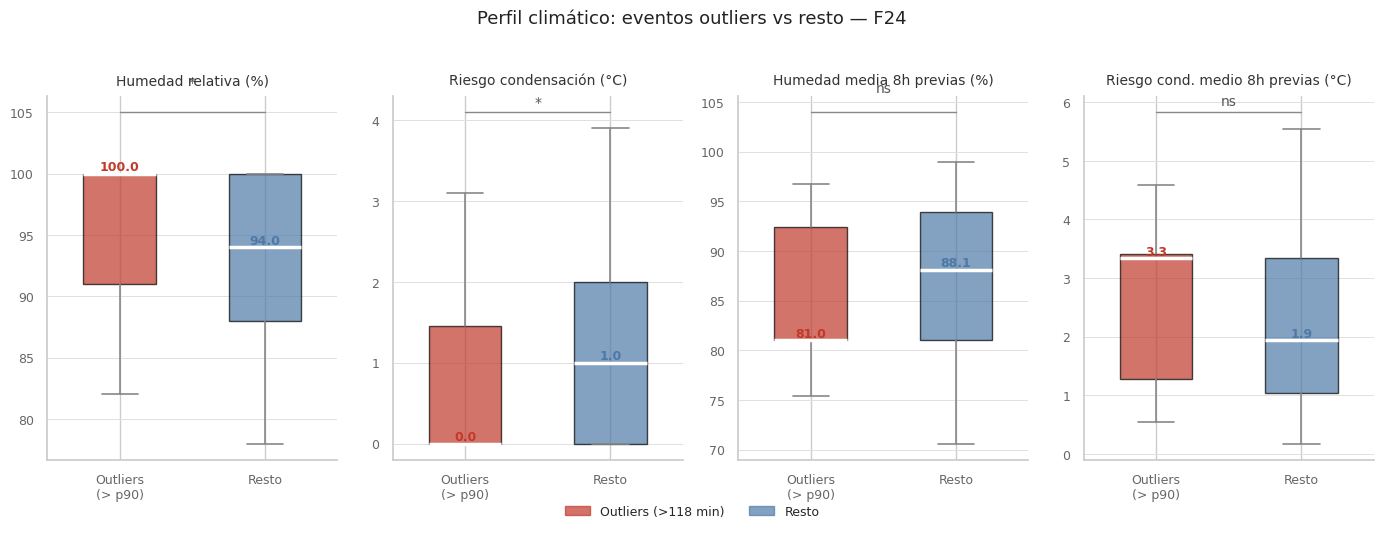

In [ ]:
# ─────────────────────────────────────────────
# F24 — Perfil climático: outliers vs resto
# Outliers: evento_minutos > percentil 90
# Variables: rhum, riesgo_condensacion,
#            min_desde_amanecer, f2x_horas_riesgo_6h
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

BASE_COLOR = '#4e79a7'
RED        = '#c0392b'
ORANGE     = '#f28e2b'
GREEN      = '#2d6a4f'

# ── Preparación ──────────────────────────────
p90 = f24['evento_minutos'].quantile(0.90)
print(f"Percentil 90: {p90:.0f} min")
print(f"Outliers (> p90): {(f24['evento_minutos'] > p90).sum()} eventos")
print(f"Resto:            {(f24['evento_minutos'] <= p90).sum()} eventos")
print()

# clasificar eventos
f24_analisis = f24.copy()
f24_analisis['es_outlier'] = f24_analisis['evento_minutos'] > p90

# calcular min_desde_amanecer por evento usando hora_abierta real
sol = df_horarios_sol[['fecha', 'salida']].copy()
sol['fecha_dia'] = pd.to_datetime(sol['fecha']).dt.normalize()
f24_analisis['fecha_dia'] = f24_analisis['hora_abierta'].dt.normalize()
f24_analisis = f24_analisis.merge(
    sol[['fecha_dia', 'salida']], on='fecha_dia', how='left'
)
f24_analisis['min_desde_amanecer'] = (
    f24_analisis['hora_abierta'] - f24_analisis['salida']
).dt.total_seconds() / 60

# ── Antecedentes climáticos 8h previas ───────
# Para cada evento calcular media y pendiente de
# rhum y riesgo_condensacion en las 8h previas
clima_idx = df_clima.set_index('time').sort_index()

def get_antecedentes(hora_evento, clima_idx, W=8):
    vals_rc, vals_rh = [], []
    for h in range(1, W+1):
        hora_buscar = (hora_evento - pd.Timedelta(hours=h)).floor('h')
        if hora_buscar in clima_idx.index:
            vals_rc.append(clima_idx.loc[hora_buscar, 'riesgo_condensacion'])
            vals_rh.append(clima_idx.loc[hora_buscar, 'rhum'])
        else:
            vals_rc.append(np.nan)
            vals_rh.append(np.nan)

    vals_rc = np.array(vals_rc[::-1], dtype=float)  # orden cronológico
    vals_rh = np.array(vals_rh[::-1], dtype=float)
    x = np.arange(W)

    # media
    rc_mean = np.nanmean(vals_rc) if not np.all(np.isnan(vals_rc)) else np.nan
    rh_mean = np.nanmean(vals_rh) if not np.all(np.isnan(vals_rh)) else np.nan

    # pendiente (slope)
    mask_rc = ~np.isnan(vals_rc)
    mask_rh = ~np.isnan(vals_rh)
    rc_slope = stats.linregress(x[mask_rc], vals_rc[mask_rc])[0] if mask_rc.sum() >= 2 else np.nan
    rh_slope = stats.linregress(x[mask_rh], vals_rh[mask_rh])[0] if mask_rh.sum() >= 2 else np.nan

    return rc_mean, rh_mean, rc_slope, rh_slope

print("Calculando antecedentes 8h previas por evento...")
ant = f24_analisis['hora_abierta'].apply(
    lambda h: pd.Series(
        get_antecedentes(h, clima_idx),
        index=['rc_mean_8h', 'rh_mean_8h', 'rc_slope_8h', 'rh_slope_8h']
    )
)
f24_analisis = pd.concat([f24_analisis, ant], axis=1)
print("Listo.\n")

# ── Comparativa estadística ───────────────────
vars_analisis = {
    'rhum':                  'Humedad relativa (%)',
    'riesgo_condensacion':   'Riesgo condensación (°C)',
    'min_desde_amanecer':    'Minutos desde amanecer',
    'rh_mean_8h':            'Humedad media 8h previas (%)',
    'rc_mean_8h':            'Riesgo cond. medio 8h previas (°C)',
    'rc_slope_8h':           'Tendencia riesgo cond. 8h (slope)',
    'evento_minutos':        'Duración del evento (min)',
}

print("═" * 65)
print("PERFIL CLIMÁTICO: OUTLIERS vs RESTO")
print("═" * 65)
print(f"{'Variable':35} {'Outliers':>10} {'Resto':>10} {'Dif':>8} {'p-valor':>10}")
print("─" * 65)

resultados = []
for var, label in vars_analisis.items():
    if var not in f24_analisis.columns:
        continue
    grp_out  = f24_analisis[f24_analisis['es_outlier'] == True][var].dropna()
    grp_rest = f24_analisis[f24_analisis['es_outlier'] == False][var].dropna()

    med_out  = grp_out.median()
    med_rest = grp_rest.median()
    dif      = med_out - med_rest

    # Mann-Whitney U (no paramétrico, apropiado para distribuciones no normales)
    stat, p = stats.mannwhitneyu(grp_out, grp_rest, alternative='two-sided')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))

    print(f"{label:35} {med_out:>10.1f} {med_rest:>10.1f} {dif:>+8.1f} {p:>10.4f} {sig}")
    resultados.append({
        'var': var, 'label': label,
        'med_out': med_out, 'med_rest': med_rest,
        'dif': dif, 'p': p, 'sig': sig,
        'vals_out': grp_out, 'vals_rest': grp_rest
    })

print()
print("Test: Mann-Whitney U (mediana)  *** p<0.001  ** p<0.01  * p<0.05")
print()

# ── Distribución por inversor ─────────────────
print("─" * 65)
print("OUTLIERS POR INVERSOR")
print("─" * 65)
out_inv = (
    f24_analisis
    .groupby('inversor')['es_outlier']
    .agg(
        total='count',
        outliers='sum',
    )
    .assign(
        pct_outliers=lambda x: (x['outliers'] / x['total'] * 100).round(1),
        mediana_dur=f24_analisis.groupby('inversor')['evento_minutos'].median()
    )
    .sort_values('outliers', ascending=False)
)
print(out_inv.to_string())
print()

# ═══════════════════════════════════════════════
# GRÁFICA — Boxplots comparativos
# 4 variables climáticas: outliers vs resto
# ═══════════════════════════════════════════════
vars_plot = [r for r in resultados
             if r['var'] not in ('evento_minutos', 'min_desde_amanecer')][:4]

fig, axes = plt.subplots(1, 4, figsize=(14, 5))
fig.patch.set_facecolor('white')

colores = [RED, BASE_COLOR]
labels  = ['Outliers\n(> p90)', 'Resto']

for ax, r in zip(axes, vars_plot):
    ax.set_facecolor('white')

    data = [r['vals_out'], r['vals_rest']]

    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', lw=2.5),
                    whiskerprops=dict(color='#888888', lw=1.2),
                    capprops=dict(color='#888888', lw=1.2),
                    flierprops=dict(marker='o', markersize=4,
                                    alpha=0.4, linestyle='none'))

    for patch, col in zip(bp['boxes'], colores):
        patch.set_facecolor(col)
        patch.set_alpha(0.7)

    # anotación de medianas
    for i, (med, col) in enumerate(zip(
        [r['med_out'], r['med_rest']], colores
    )):
        ax.text(i+1, med, f'{med:.1f}',
                ha='center', va='bottom',
                fontsize=9, color=col, fontweight='bold')

    # significancia
    y_max = max(r['vals_out'].max(), r['vals_rest'].max())
    y_sig = y_max * 1.05
    ax.plot([1, 2], [y_sig, y_sig], color='#888888', lw=1)
    ax.text(1.5, y_sig * 1.02, r['sig'] if r['sig'] else 'ns',
            ha='center', fontsize=10, color='#555555')

    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels, fontsize=9, color='#555555')
    ax.set_title(r['label'], fontsize=10, fontweight='normal',
                 color='#333333', pad=8)
    ax.tick_params(colors='#666666', labelsize=9)
    ax.grid(axis='y', color='#e0e0e0', linewidth=0.7, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#cccccc')

leyenda = [
    mpatches.Patch(color=RED,        alpha=0.7, label=f'Outliers (>{int(p90)} min)'),
    mpatches.Patch(color=BASE_COLOR, alpha=0.7, label='Resto'),
]
fig.legend(handles=leyenda, fontsize=9, frameon=False,
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Perfil climático: eventos outliers vs resto — F24',
             fontsize=13, fontweight='normal', color='#222222', y=1.02)

plt.tight_layout()
plt.show()


##### Distribucion de las duraciones


══════════════════════════════════════════════════
DISTRIBUCIÓN DE DURACIONES — F24
══════════════════════════════════════════════════
Total eventos:    355
Mediana:          88 min  (1.5 hs)
Media:            83 min  (1.4 hs)
Mínimo:           5 min
Máximo:           372 min  (6.2 hs)
Percentil 90:     118 min  (2.0 hs)
Outliers (>p90):  35 eventos (9.9%)

──────────────────────────────────────────────────
DISTRIBUCIÓN POR RANGO DE DURACIÓN
──────────────────────────────────────────────────
  0–30       min:    54 eventos  (15.2%)
  30–60      min:    27 eventos  (7.6%)
  60–90      min:   137 eventos  (38.6%)
  90–120     min:   103 eventos  (29.0%)
  120–180    min:    23 eventos  (6.5%)
  180–240    min:     6 eventos  (1.7%)
  240+       min:     5 eventos  (1.4%)



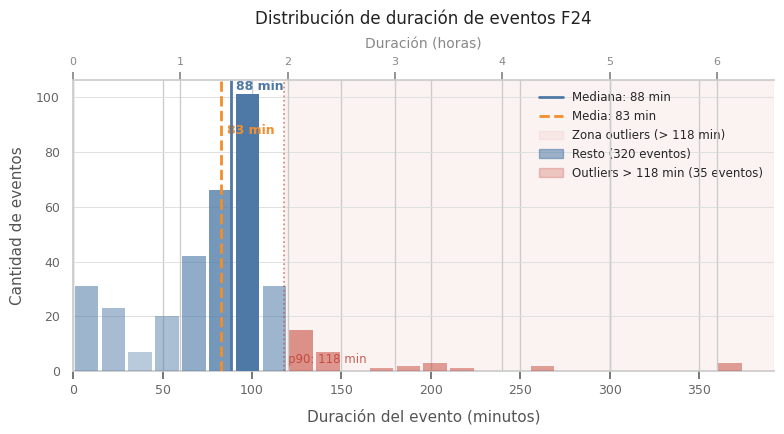

In [ ]:
# ─────────────────────────────────────────────
# F24 — Distribución de duraciones
# Histograma con media, mediana y zona outliers
# Fuente: dataframe f24
# ─────────────────────────────────────────────

BASE_COLOR = '#4e79a7'
RED        = '#c0392b'
ORANGE     = '#f28e2b'

# ── Estadísticos generales ────────────────────
dur = f24['evento_minutos']
p90 = dur.quantile(0.90)
p50 = dur.median()
mean = dur.mean()

print("═" * 50)
print("DISTRIBUCIÓN DE DURACIONES — F24")
print("═" * 50)
print(f"Total eventos:    {len(dur)}")
print(f"Mediana:          {p50:.0f} min  ({p50/60:.1f} hs)")
print(f"Media:            {mean:.0f} min  ({mean/60:.1f} hs)")
print(f"Mínimo:           {dur.min():.0f} min")
print(f"Máximo:           {dur.max():.0f} min  ({dur.max()/60:.1f} hs)")
print(f"Percentil 90:     {p90:.0f} min  ({p90/60:.1f} hs)")
print(f"Outliers (>p90):  {(dur > p90).sum()} eventos ({(dur > p90).mean()*100:.1f}%)")
print()

# distribución por rangos
rangos = [0, 30, 60, 90, 120, 180, 240, 400]
etiq   = ['0–30','30–60','60–90','90–120','120–180','180–240','240+']
cuts   = pd.cut(dur, bins=rangos, labels=etiq, right=True)
print("─" * 50)
print("DISTRIBUCIÓN POR RANGO DE DURACIÓN")
print("─" * 50)
dist_rangos = cuts.value_counts().sort_index()
for rango, n in dist_rangos.items():
    pct = n / len(dur) * 100
    print(f"  {rango:10} min:  {n:>4} eventos  ({pct:.1f}%)")
print()

# ═══════════════════════════════════════════════
# GRÁFICA — Histograma de duraciones
# ═══════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bins = np.arange(0, dur.max() + 20, 15)

# colorear barras según zona
counts, edges = np.histogram(dur, bins=bins)
max_count = counts.max()

for i, (left, right, count) in enumerate(zip(edges[:-1], edges[1:], counts)):
    centro = (left + right) / 2
    # outliers en rojo, resto en azul con alpha por frecuencia
    if left >= p90:
        color = (*tuple(int(RED[1:][j:j+2], 16)/255 for j in (0,2,4)),
                 0.45 + 0.55 * (count / max_count) if max_count > 0 else 0.45)
    else:
        color = (*tuple(int(BASE_COLOR[1:][j:j+2], 16)/255 for j in (0,2,4)),
                 0.35 + 0.65 * (count / max_count) if max_count > 0 else 0.35)
    ax.bar(centro, count, width=(right-left)*0.88,
           color=color, linewidth=0, zorder=3)

# línea mediana
ax.axvline(p50, color=BASE_COLOR, lw=2, linestyle='-',
           zorder=4, label=f'Mediana: {p50:.0f} min')
ax.text(p50 + 3, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 50,
        f'{p50:.0f} min', color=BASE_COLOR, fontsize=9,
        va='top', fontweight='bold')

# línea media
ax.axvline(mean, color=ORANGE, lw=2, linestyle='--',
           zorder=4, label=f'Media: {mean:.0f} min')
ax.text(mean + 3, ax.get_ylim()[1]*0.85 if ax.get_ylim()[1] > 0 else 40,
        f'{mean:.0f} min', color=ORANGE, fontsize=9,
        va='top', fontweight='bold')

# zona outliers
ax.axvspan(p90, dur.max() + 20, color=RED, alpha=0.06, zorder=0,
           label=f'Zona outliers (> {p90:.0f} min)')
ax.axvline(p90, color=RED, lw=1.2, linestyle=':',
           alpha=0.6, zorder=3)
ax.text(p90 + 2, 2, f'p90: {p90:.0f} min',
        color=RED, fontsize=8.5, alpha=0.8, va='bottom')

ax.set_xlabel('Duración del evento (minutos)', fontsize=11,
              color='#555555', labelpad=8)
ax.set_ylabel('Cantidad de eventos', fontsize=11,
              color='#555555', labelpad=8)
ax.set_title('Distribución de duración de eventos F24',
             fontsize=12, fontweight='normal', color='#222222', pad=10)

ax.set_xlim(0, dur.max() + 20)
ax.tick_params(colors='#666666', labelsize=9)
ax.grid(axis='y', color='#e0e0e0', linewidth=0.7, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')

# eje secundario en horas
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim()[0]/60, ax.get_xlim()[1]/60)
ax2.set_xlabel('Duración (horas)', fontsize=10, color='#888888', labelpad=6)
ax2.tick_params(colors='#888888', labelsize=8)
ax2.spines[['top']].set_color('#cccccc')
ax2.spines[['right', 'left', 'bottom']].set_visible(False)

# leyenda
parche_out = mpatches.Patch(color=RED, alpha=0.25,
                             label=f'Outliers > {p90:.0f} min ({(dur>p90).sum()} eventos)')
parche_rest = mpatches.Patch(
    color=BASE_COLOR, alpha=0.55,
    label=f'Resto ({(dur<=p90).sum()} eventos)'
)
handles, labels_leg = ax.get_legend_handles_labels()
ax.legend(handles=handles + [parche_rest, parche_out],
          fontsize=8.5, frameon=False, loc='upper right')

plt.tight_layout()
plt.show()


##### Scatter frecuencia duracion

═══════════════════════════════════════════════════════════════════════════════════════════
RESUMEN POR INVERSOR: FRECUENCIA × DURACIÓN
═══════════════════════════════════════════════════════════════════════════════════════════
inversor grupo  frecuencia  dur_mediana  dur_min  dur_max  dur_media  dur_total  n_outliers
      C1     C          43        101.0       28      372 105.162791       4522           7
      C2     C          42         90.0        6      213  86.976190       3653           2
      B3     B          32        114.5        5      366 117.312500       3754          15
      C3     C          31         95.0        6      197  90.967742       2820           3
      B4     B          27         89.0        6      365  85.481481       2308           2
      A4     A          26         89.5        6      197  80.115385       2083           1
      A1     A          23         87.0        6      196  87.826087       2020           1
      D1     D          22         8

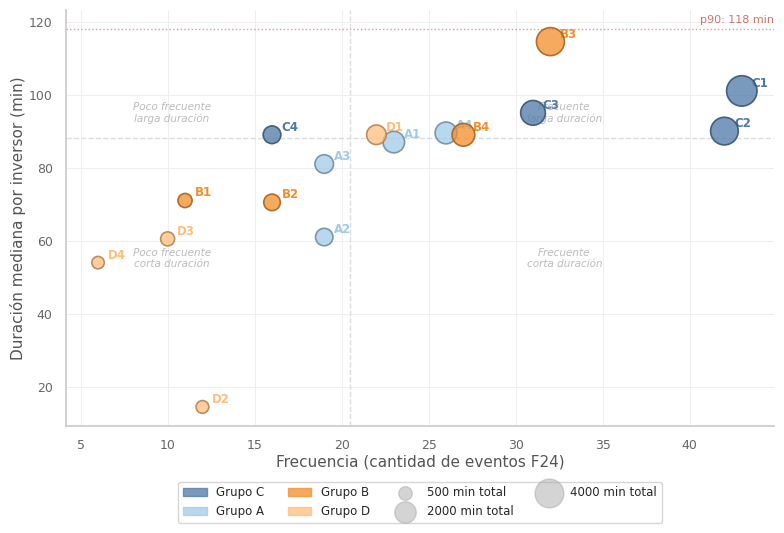

In [ ]:
# ─────────────────────────────────────────────
# F24 — Scatter: frecuencia × duración por inversor
# Eje X: cantidad de eventos (frecuencia)
# Eje Y: duración mediana por inversor
# Tamaño: tiempo total fuera de servicio
# Color: grupo del inversor
# ─────────────────────────────────────────────

color_grupo = {
    'C': '#4e79a7',
    'A': '#a0cbe8',
    'B': '#f28e2b',
    'D': '#ffbe7d'
}

# ── Preparación ──────────────────────────────
f24['grupo'] = f24['inversor'].str[0]

resumen_inv = (
    f24
    .groupby(['inversor', 'grupo'])
    .agg(
        frecuencia   =('evento_minutos', 'count'),
        dur_mediana  =('evento_minutos', 'median'),
        dur_min  =('evento_minutos', 'min'),
        dur_media    =('evento_minutos', 'mean'),
        dur_total    =('evento_minutos', 'sum'),
        dur_max      =('evento_minutos', 'max'),
        n_outliers   =('evento_minutos', lambda x: (x > 118).sum())
    )
    .reset_index()
    .sort_values('frecuencia', ascending=False)
)

print("═" * 91)
print("RESUMEN POR INVERSOR: FRECUENCIA × DURACIÓN")
print("═" * 91)
print(resumen_inv[['inversor','grupo','frecuencia','dur_mediana','dur_min','dur_max',
                   'dur_media','dur_total','n_outliers']].to_string(index=False))
print()

# ── Normalizar tamaño del punto ───────────────
min_tot = resumen_inv['dur_total'].min()
max_tot = resumen_inv['dur_total'].max()
sizes = 80 + 400 * (resumen_inv['dur_total'] - min_tot) / (max_tot - min_tot)

# ═══════════════════════════════════════════════
# GRÁFICA — Scatter frecuencia × duración mediana
# ═══════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# cuadrantes de referencia
med_freq = resumen_inv['frecuencia'].median()
med_dur  = resumen_inv['dur_mediana'].median()
ax.axvline(med_freq, color='#dddddd', lw=1, linestyle='--', zorder=1)
ax.axhline(med_dur,  color='#dddddd', lw=1, linestyle='--', zorder=1)

# etiquetas de cuadrantes
ax.text(med_freq * 0.5,  med_dur * 1.05, 'Poco frecuente\nlarga duración',
        ha='center', fontsize=7.5, color='#bbbbbb', style='italic')
ax.text(med_freq * 1.6,  med_dur * 1.05, 'Frecuente\nlarga duración',
        ha='center', fontsize=7.5, color='#bbbbbb', style='italic')
ax.text(med_freq * 0.5,  med_dur * 0.6,  'Poco frecuente\ncorta duración',
        ha='center', fontsize=7.5, color='#bbbbbb', style='italic')
ax.text(med_freq * 1.6,  med_dur * 0.6,  'Frecuente\ncorta duración',
        ha='center', fontsize=7.5, color='#bbbbbb', style='italic')

# puntos por grupo
for grupo, col in color_grupo.items():
    sub = resumen_inv[resumen_inv['grupo'] == grupo]
    r = int(col[1:3], 16)/255
    g = int(col[3:5], 16)/255
    b = int(col[5:7], 16)/255
    sub_sizes = sizes[resumen_inv['grupo'] == grupo]

    ax.scatter(sub['frecuencia'], sub['dur_mediana'],
               s=sub_sizes,
               color=(r, g, b, 0.75),
               edgecolors=(r*0.7, g*0.7, b*0.7, 0.9),
               linewidths=1.2,
               zorder=4,
               label=f'Grupo {grupo}')

    # etiquetas de inversor
    for _, row in sub.iterrows():
        ax.annotate(row['inversor'],
                    (row['frecuencia'], row['dur_mediana']),
                    textcoords='offset points',
                    xytext=(7, 3),
                    fontsize=8.5,
                    color=col,
                    fontweight='bold')

# p90 como línea horizontal de referencia
p90 = f24['evento_minutos'].quantile(0.90)
ax.axhline(p90, color='#c0392b', lw=1, linestyle=':',
           alpha=0.5, zorder=2)
ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] > 0 else 45,
        p90 + 1, f'p90: {p90:.0f} min',
        fontsize=8, color='#c0392b', alpha=0.7, va='bottom', ha='right')

ax.set_xlabel('Frecuencia (cantidad de eventos F24)', fontsize=11,
              color='#555555', labelpad=2)
ax.set_ylabel('Duración mediana por inversor (min)', fontsize=11,
              color='#555555', labelpad=2)
#ax.set_title('Frecuencia vs duración mediana por inversor\nTamaño = tiempo total fuera de servicio',
#             fontsize=12, fontweight='normal', color='#222222', pad=10)

ax.tick_params(colors='#666666', labelsize=9)
ax.grid(color='#eeeeee', linewidth=0.7, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')

# leyenda grupos
handles_grp = [
    mpatches.Patch(color=col, alpha=0.75, label=f'Grupo {g}')
    for g, col in color_grupo.items()
]
# leyenda tamaño
for mins, label in [(500, '500 min'), (2000, '2000 min'), (4000, '4000 min')]:
    size = 80 + 400 * (mins - min_tot) / (max_tot - min_tot)
    ax.scatter([], [], s=max(size, 20), color='#aaaaaa',
               alpha=0.5, label=f'{mins} min total')

handles_all, labels_all = ax.get_legend_handles_labels()
ax.legend(
    handles=handles_grp + handles_all[4:],
    fontsize=8.5,
    frameon=True,
    loc='upper center',          # Anclaje superior de la leyenda
    bbox_to_anchor=(0.5, -0.12), # Coordenadas (x, y) relativas al gráfico
    ncol=4
)

plt.tight_layout()
plt.show()


═══════════════════════════════════════════════════════════════════════════════════════════
RESUMEN POR INVERSOR: FRECUENCIA × DURACIÓN
═══════════════════════════════════════════════════════════════════════════════════════════
inversor grupo  frecuencia  dur_mediana  dur_min  dur_max  dur_media  dur_total  n_outliers
      C1     C          43        101.0       28      372 105.162791       4522           7
      C2     C          42         90.0        6      213  86.976190       3653           2
      B3     B          32        114.5        5      366 117.312500       3754          15
      C3     C          31         95.0        6      197  90.967742       2820           3
      B4     B          27         89.0        6      365  85.481481       2308           2
      A4     A          26         89.5        6      197  80.115385       2083           1
      A1     A          23         87.0        6      196  87.826087       2020           1
      D1     D          22         8

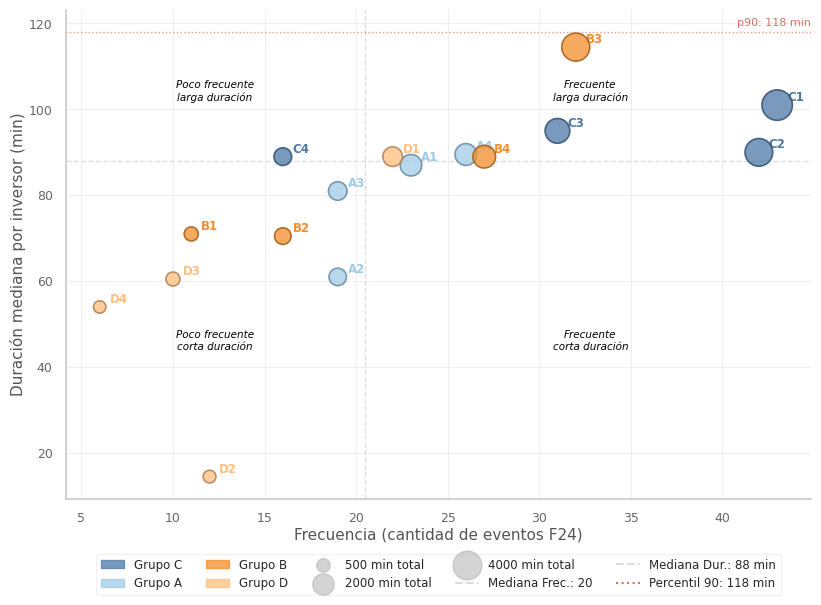

In [ ]:
color_grupo = {
    'C': '#4e79a7',
    'A': '#a0cbe8',
    'B': '#f28e2b',
    'D': '#ffbe7d'
}

# ── Preparación ──────────────────────────────
f24['grupo'] = f24['inversor'].str[0]

resumen_inv = (
    f24
    .groupby(['inversor', 'grupo'])
    .agg(
        frecuencia   =('evento_minutos', 'count'),
        dur_mediana  =('evento_minutos', 'median'),
        dur_min      =('evento_minutos', 'min'),
        dur_media    =('evento_minutos', 'mean'),
        dur_total    =('evento_minutos', 'sum'),
        dur_max      =('evento_minutos', 'max'),
        n_outliers   =('evento_minutos', lambda x: (x > 118).sum())
    )
    .reset_index()
    .sort_values('frecuencia', ascending=False)
)

print("═" * 91)
print("RESUMEN POR INVERSOR: FRECUENCIA × DURACIÓN")
print("═" * 91)
print(resumen_inv[['inversor','grupo','frecuencia','dur_mediana','dur_min','dur_max',
                   'dur_media','dur_total','n_outliers']].to_string(index=False))
print()

# ── Normalizar tamaño del punto ───────────────
min_tot = resumen_inv['dur_total'].min()
max_tot = resumen_inv['dur_total'].max()
sizes = 80 + 400 * (resumen_inv['dur_total'] - min_tot) / (max_tot - min_tot)

# ── CÁLCULO DE REFERENCIAS ESTADÍSTICAS ───────
med_freq = resumen_inv['frecuencia'].median()
med_dur  = resumen_inv['dur_mediana'].median()
p90      = f24['evento_minutos'].quantile(0.90)

# ═══════════════════════════════════════════════
# GRÁFICA — Scatter frecuencia × duración mediana
# ═══════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8.5, 6.5)) # Un toque más de alto para acomodar las líneas de referencia abajo
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Cuadrantes de referencia (líneas en la gráfica)
ax.axvline(med_freq, color='#dddddd', lw=1, linestyle='--', zorder=1)
ax.axhline(med_dur,  color='#dddddd', lw=1, linestyle='--', zorder=1)

# etiquetas de cuadrantes
ax.text(med_freq * 0.6,  med_dur * 1.16, 'Poco frecuente\nlarga duración',
        ha='center', fontsize=7.5, color='black', style='italic')
ax.text(med_freq * 1.6,  med_dur * 1.16, 'Frecuente\nlarga duración',
        ha='center', fontsize=7.5, color='black', style='italic')
ax.text(med_freq * 0.6,  med_dur * 0.5,  'Poco frecuente\ncorta duración',
        ha='center', fontsize=7.5, color='black', style='italic')
ax.text(med_freq * 1.6,  med_dur * 0.5,  'Frecuente\ncorta duración',
        ha='center', fontsize=7.5, color='black', style='italic')

# puntos por grupo
for grupo, col in color_grupo.items():
    sub = resumen_inv[resumen_inv['grupo'] == grupo]
    r = int(col[1:3], 16)/255
    g = int(col[3:5], 16)/255
    b = int(col[5:7], 16)/255
    sub_sizes = sizes[resumen_inv['grupo'] == grupo]

    ax.scatter(sub['frecuencia'], sub['dur_mediana'],
               s=sub_sizes,
               color=(r, g, b, 0.75),
               edgecolors=(r*0.7, g*0.7, b*0.7, 0.9),
               linewidths=1.2,
               zorder=4,
               label=f'Grupo {grupo}')

    # etiquetas de inversor
    for _, row in sub.iterrows():
        ax.annotate(row['inversor'],
                    (row['frecuencia'], row['dur_mediana']),
                    textcoords='offset points',
                    xytext=(7, 3),
                    fontsize=8.5,
                    color=col,
                    fontweight='bold')

# p90 como línea horizontal de referencia
ax.axhline(p90, color='#c0392b', lw=1, linestyle=':', alpha=0.5, zorder=2)
ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] > 0 else 45,
        p90 + 1, f'p90: {p90:.0f} min',
        fontsize=8, color='#c0392b', alpha=0.7, va='bottom', ha='right')

ax.set_xlabel('Frecuencia (cantidad de eventos F24)', fontsize=11, color='#555555', labelpad=2)
ax.set_ylabel('Duración mediana por inversor (min)', fontsize=11, color='#555555', labelpad=2)

ax.tick_params(colors='#666666', labelsize=9)
ax.grid(color='#eeeeee', linewidth=0.7, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')

# ── CONSTRUCCIÓN RIGUROSA DE LA LEYENDA ────────────

# 1. Elementos de los Grupos (Patches)
handles_grp = [
    mpatches.Patch(color=col, alpha=0.75, label=f'Grupo {g}')
    for g, col in color_grupo.items()
]

# 2. Elementos de los Tamaños (Scatter fantasma)
handles_size = []
for mins in [500, 2000, 4000]:
    size = 80 + 400 * (mins - min_tot) / (max_tot - min_tot)
    scat = ax.scatter([], [], s=max(size, 20), color='#aaaaaa', alpha=0.5, label=f'{mins} min total')
    handles_size.append(scat)

# 3. Crea réplicas exactas de las líneas estadísticas usando Line2D
linea_med_freq = Line2D([0], [0], color='#dddddd', lw=1.5, linestyle='--',
                        label=f'Mediana Frec.: {med_freq:.0f}')

linea_med_dur  = Line2D([0], [0], color='#dddddd', lw=1.5, linestyle='--',
                        label=f'Mediana Dur.: {med_dur:.0f} min')

linea_p90      = Line2D([0], [0], color='#c0392b', lw=1.5, linestyle=':', alpha=0.7,
                        label=f'Percentil 90: {p90:.0f} min')

# Consolidamos toda la lista ordenada de marcas visuales
lista_handles = handles_grp + handles_size + [linea_med_freq, linea_med_dur, linea_p90]

# Renderizamos la leyenda unificada en la parte inferior
ax.legend(
    handles=lista_handles,
    fontsize=8.5,
    frameon=True,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=5,
    facecolor='white',
    edgecolor='#eeeeee'
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.22)
plt.show()

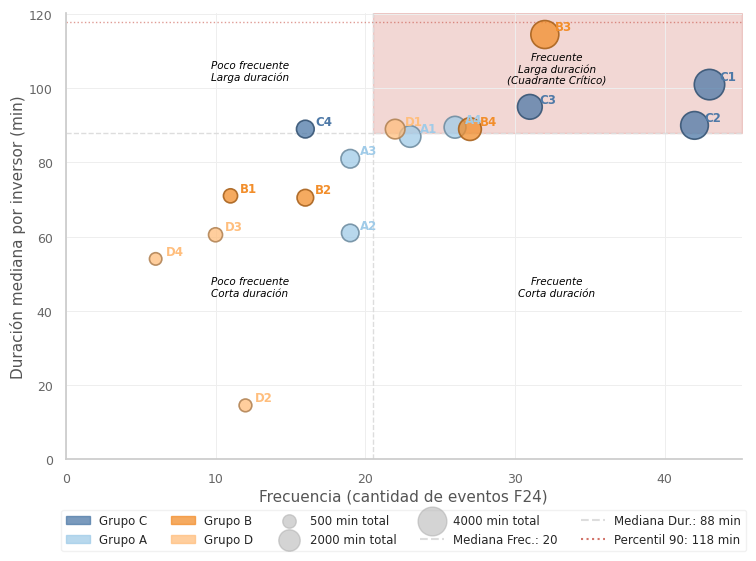

In [ ]:
# ═══════════════════════════════════════════════
# GRÁFICA — Scatter frecuencia × duración mediana
# ═══════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 1. Primero calculamos los límites máximos reales de los datos para el sombreado seguro
max_x_grafico = resumen_inv['frecuencia'].max() * 1.05      # Un 20% más del máximo para cubrir todo
max_y_grafico = resumen_inv['dur_mediana'].max() * 1.05

# 2. SOLUCIÓN: Sombreado del cuadrante crítico usando fill_between (Fondo)
ax.fill_between(x=[med_freq, max_x_grafico],
                y1=med_dur,
                y2=max_y_grafico,
                color='#c0392b',
                alpha=0.2,
                zorder=0)

# Cuadrantes de referencia (Líneas divisorias - zorder=2 para que se vean sobre el rojo)
ax.axvline(med_freq, color='#dddddd', lw=1, linestyle='--', zorder=2)
ax.axhline(med_dur,  color='#dddddd', lw=1, linestyle='--', zorder=2)

# Etiquetas de cuadrantes
ax.text(med_freq * 0.6,  med_dur * 1.16, 'Poco frecuente\nLarga duración',
        ha='center', fontsize=7.5, color='black', style='italic', zorder=3)
ax.text(med_freq * 1.6,  med_dur * 1.15, 'Frecuente\nLarga duración\n(Cuadrante Crítico)',
        ha='center', fontsize=7.5, color='black', style='italic', zorder=3)
ax.text(med_freq * 0.6,  med_dur * 0.5,  'Poco frecuente\nCorta duración',
        ha='center', fontsize=7.5, color='black', style='italic', zorder=3)
ax.text(med_freq * 1.6,  med_dur * 0.5,  'Frecuente\nCorta duración',
        ha='center', fontsize=7.5, color='black', style='italic', zorder=3)

# Puntos por grupo
for grupo, col in color_grupo.items():
    sub = resumen_inv[resumen_inv['grupo'] == grupo]
    r = int(col[1:3], 16)/255
    g = int(col[3:5], 16)/255
    b = int(col[5:7], 16)/255
    sub_sizes = sizes[resumen_inv['grupo'] == grupo]

    ax.scatter(sub['frecuencia'], sub['dur_mediana'],
               s=sub_sizes,
               color=(r, g, b, 0.75),
               edgecolors=(r*0.7, g*0.7, b*0.7, 0.9),
               linewidths=1.2,
               zorder=4,
               label=f'Grupo {grupo}')

    # Etiquetas de inversor
    for _, row in sub.iterrows():
        ax.annotate(row['inversor'],
                    (row['frecuencia'], row['dur_mediana']),
                    textcoords='offset points',
                    xytext=(7, 3),
                    fontsize=8.5,
                    color=col,
                    fontweight='bold',
                    zorder=5)

# P90 como línea horizontal de referencia
ax.axhline(p90, color='#c0392b', lw=1, linestyle=':', alpha=0.5, zorder=2)

# Configuración estricta de límites para que el sombreado no deforme el autoscale
ax.set_xlim(0, max_x_grafico)
ax.set_ylim(0, max_y_grafico)

ax.set_xlabel('Frecuencia (cantidad de eventos F24)', fontsize=11, color='#555555', labelpad=2)
ax.set_ylabel('Duración mediana por inversor (min)', fontsize=11, color='#555555', labelpad=2)

ax.tick_params(colors='#666666', labelsize=9)
ax.grid(color='#eeeeee', linewidth=0.7, zorder=1)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')

# ── CONSTRUCCIÓN DE LA LEYENDA ────────────────────
handles_grp = [
    mpatches.Patch(color=col, alpha=0.75, label=f'Grupo {g}')
    for g, col in color_grupo.items()
]

handles_size = []
for mins in [500, 2000, 4000]:
    size = 80 + 400 * (mins - min_tot) / (max_tot - min_tot)
    scat = ax.scatter([], [], s=max(size, 20), color='#aaaaaa', alpha=0.5, label=f'{mins} min total')
    handles_size.append(scat)

linea_med_freq = Line2D([0], [0], color='#dddddd', lw=1.5, linestyle='--',
                        label=f'Mediana Frec.: {med_freq:.0f}')
linea_med_dur  = Line2D([0], [0], color='#dddddd', lw=1.5, linestyle='--',
                        label=f'Mediana Dur.: {med_dur:.0f} min')
linea_p90      = Line2D([0], [0], color='#c0392b', lw=1.5, linestyle=':', alpha=0.7,
                        label=f'Percentil 90: {p90:.0f} min')

lista_handles = handles_grp + handles_size + [linea_med_freq, linea_med_dur, linea_p90]

ax.legend(
    handles=lista_handles,
    fontsize=8.5,
    frameon=True,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=5,
    facecolor='white',
    edgecolor='#eeeeee'
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.22)
plt.show()

═════════════════════════════════════════════════════════════════
RESUMEN POR INVERSOR: FRECUENCIA × DURACIÓN
═════════════════════════════════════════════════════════════════
inversor grupo  frecuencia  dur_mediana  dur_min  dur_max  dur_media  dur_total  n_outliers
      C1     C          43        101.0       28      372 105.162791       4522           7
      C2     C          42         90.0        6      213  86.976190       3653           2
      B3     B          32        114.5        5      366 117.312500       3754          15
      C3     C          31         95.0        6      197  90.967742       2820           3
      B4     B          27         89.0        6      365  85.481481       2308           2
      A4     A          26         89.5        6      197  80.115385       2083           1
      A1     A          23         87.0        6      196  87.826087       2020           1
      D1     D          22         89.0        5      102  72.045455       1585         

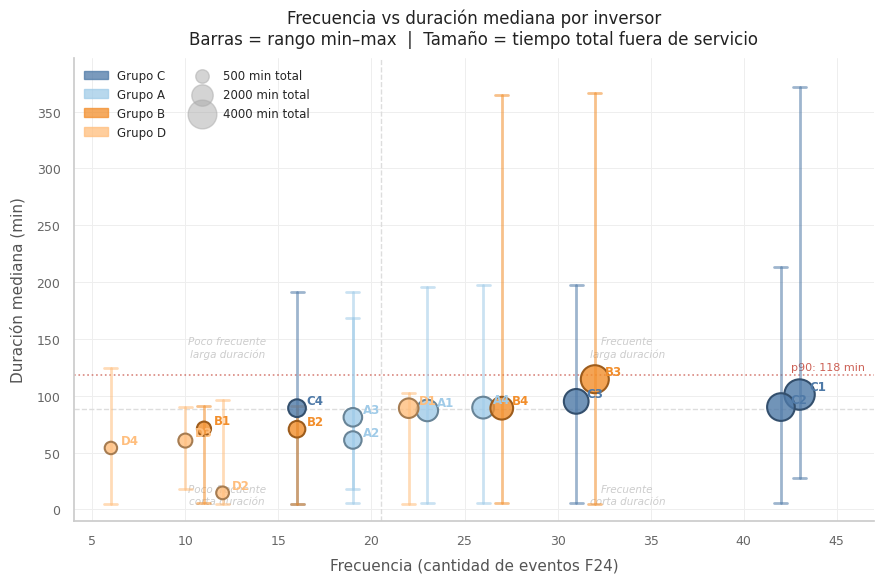

In [ ]:
# ─────────────────────────────────────────────
# F24 — Scatter: frecuencia × duración por inversor
# Eje X: cantidad de eventos (frecuencia)
# Eje Y: duración mediana por inversor
# Tamaño: tiempo total fuera de servicio
# Color: grupo del inversor
# ─────────────────────────────────────────────

color_grupo = {
    'C': '#4e79a7',
    'A': '#a0cbe8',
    'B': '#f28e2b',
    'D': '#ffbe7d'
}

# ── Preparación ──────────────────────────────
f24['grupo'] = f24['inversor'].str[0]

resumen_inv = (
    f24
    .groupby(['inversor', 'grupo'])
    .agg(
        frecuencia   =('evento_minutos', 'count'),
        dur_mediana  =('evento_minutos', 'median'),
        dur_media    =('evento_minutos', 'mean'),
        dur_min      =('evento_minutos', 'min'),
        dur_max      =('evento_minutos', 'max'),
        dur_total    =('evento_minutos', 'sum'),
        n_outliers   =('evento_minutos', lambda x: (x > 118).sum())
    )
    .reset_index()
    .sort_values('frecuencia', ascending=False)
)

print("═" * 65)
print("RESUMEN POR INVERSOR: FRECUENCIA × DURACIÓN")
print("═" * 65)
print(resumen_inv[['inversor','grupo','frecuencia','dur_mediana','dur_min',
                   'dur_max','dur_media','dur_total','n_outliers']].to_string(index=False))
print()

# ── Normalizar tamaño del punto ───────────────
min_tot = resumen_inv['dur_total'].min()
max_tot = resumen_inv['dur_total'].max()
sizes = 80 + 400 * (resumen_inv['dur_total'] - min_tot) / (max_tot - min_tot)

# ═══════════════════════════════════════════════
# GRÁFICA — Scatter frecuencia × duración mediana
# ═══════════════════════════════════════════════
p90      = f24['evento_minutos'].quantile(0.90)
y_min    = resumen_inv['dur_min'].min() - 15
y_max    = resumen_inv['dur_max'].max() + 25
x_min    = resumen_inv['frecuencia'].min() - 2
x_max    = resumen_inv['frecuencia'].max() + 4
med_freq = resumen_inv['frecuencia'].median()
med_dur  = resumen_inv['dur_mediana'].median()

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# fijar límites ANTES de dibujar
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# cuadrantes de referencia
ax.axvline(med_freq, color='#dddddd', lw=1, linestyle='--', zorder=1)
ax.axhline(med_dur,  color='#dddddd', lw=1, linestyle='--', zorder=1)

# etiquetas de cuadrantes — posición fija basada en límites
ax.text(x_min + (med_freq - x_min)*0.5, med_dur + (y_max - med_dur)*0.15,
        'Poco frecuente\nlarga duración',
        ha='center', fontsize=7.5, color='#cccccc', style='italic')
ax.text(med_freq + (x_max - med_freq)*0.5, med_dur + (y_max - med_dur)*0.15,
        'Frecuente\nlarga duración',
        ha='center', fontsize=7.5, color='#cccccc', style='italic')
ax.text(x_min + (med_freq - x_min)*0.5, y_min + (med_dur - y_min)*0.15,
        'Poco frecuente\ncorta duración',
        ha='center', fontsize=7.5, color='#cccccc', style='italic')
ax.text(med_freq + (x_max - med_freq)*0.5, y_min + (med_dur - y_min)*0.15,
        'Frecuente\ncorta duración',
        ha='center', fontsize=7.5, color='#cccccc', style='italic')

# p90 línea horizontal
ax.axhline(p90, color='#c0392b', lw=1.2, linestyle=':',
           alpha=0.6, zorder=2)
ax.text(x_max - 0.5, p90 + 3, f'p90: {p90:.0f} min',
        fontsize=8, color='#c0392b', alpha=0.8,
        va='bottom', ha='right')

# ── dibujar por grupo ─────────────────────────
for grupo, col in color_grupo.items():
    sub      = resumen_inv[resumen_inv['grupo'] == grupo].copy()
    sub_idx  = resumen_inv['grupo'] == grupo
    sub_sizes = sizes[sub_idx].values

    r = int(col[1:3], 16)/255
    g = int(col[3:5], 16)/255
    b = int(col[5:7], 16)/255

    # 1 — barras de error (min–max) primero, zorder bajo
    for _, row in sub.iterrows():
        ax.plot([row['frecuencia'], row['frecuencia']],
                [row['dur_min'], row['dur_max']],
                color=(r, g, b, 0.55),
                lw=2, zorder=3, solid_capstyle='round')
        # caps superior e inferior
        for y_cap in [row['dur_min'], row['dur_max']]:
            ax.plot([row['frecuencia'] - 0.35, row['frecuencia'] + 0.35],
                    [y_cap, y_cap],
                    color=(r, g, b, 0.55),
                    lw=2, zorder=3)

    # 2 — puntos encima
    ax.scatter(sub['frecuencia'], sub['dur_mediana'],
               s=sub_sizes,
               color=(r, g, b, 0.80),
               edgecolors=(r*0.65, g*0.65, b*0.65, 1.0),
               linewidths=1.5,
               zorder=5,
               label=f'Grupo {grupo}')

    # 3 — etiquetas
    for _, row in sub.iterrows():
        ax.annotate(row['inversor'],
                    (row['frecuencia'], row['dur_mediana']),
                    textcoords='offset points',
                    xytext=(7, 3),
                    fontsize=8.5,
                    color=col,
                    fontweight='bold',
                    zorder=6)

# ── formato ───────────────────────────────────
ax.set_xlabel('Frecuencia (cantidad de eventos F24)', fontsize=11,
              color='#555555', labelpad=8)
ax.set_ylabel('Duración mediana (min)', fontsize=11,
              color='#555555', labelpad=8)
ax.set_title('Frecuencia vs duración mediana por inversor\n'
             'Barras = rango min–max  |  Tamaño = tiempo total fuera de servicio',
             fontsize=12, fontweight='normal', color='#222222', pad=10)

ax.tick_params(colors='#666666', labelsize=9)
ax.grid(color='#eeeeee', linewidth=0.7, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')

# leyenda grupos
handles_grp = [
    mpatches.Patch(color=col, alpha=0.75, label=f'Grupo {g}')
    for g, col in color_grupo.items()
]
# leyenda tamaño
size_refs = []
for mins in [500, 2000, 4000]:
    s = 80 + 400 * (mins - min_tot) / (max_tot - min_tot)
    h = ax.scatter([], [], s=max(s, 20), color='#aaaaaa',
                   alpha=0.5, label=f'{mins} min total')
    size_refs.append(h)

ax.legend(handles=handles_grp + size_refs,
          fontsize=8.5, frameon=False,
          loc='upper left', ncol=2)

plt.tight_layout()
plt.show()


════════════════════════════════════════════════════════════
CUADRANTE CRÍTICO — RANGO DE DURACIÓN
════════════════════════════════════════════════════════════
inversor  frecuencia  dur_min  dur_mediana  dur_max  dur_total
      A1          23        6         87.0      196       2020
      B4          27        6         89.0      365       2308
      D1          22        5         89.0      102       1585
      A4          26        6         89.5      197       2083
      C2          42        6         90.0      213       3653
      C3          31        6         95.0      197       2820
      C1          43       28        101.0      372       4522
      B3          32        5        114.5      366       3754



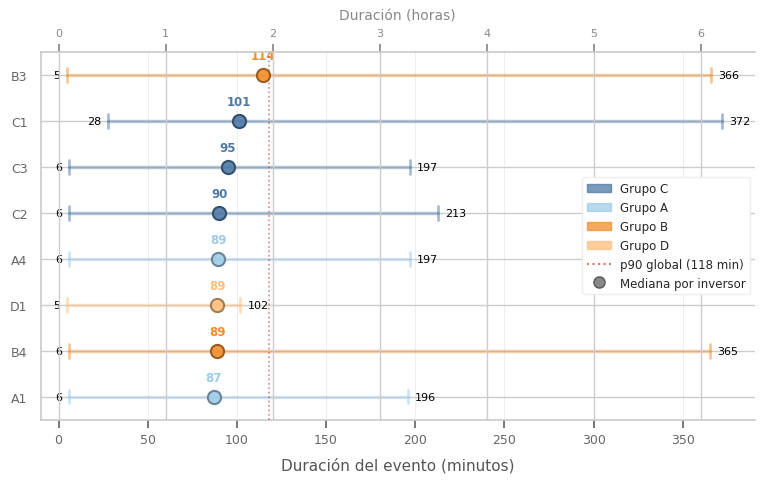

In [ ]:
# ─────────────────────────────────────────────
# F24 — Lollipop: rango de duración
# Inversores del cuadrante crítico
# Muestra min, mediana y max por inversor
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

color_grupo = {
    'C': '#4e79a7',
    'A': '#a0cbe8',
    'B': '#f28e2b',
    'D': '#ffbe7d'
}

# ── Inversores cuadrante crítico ──────────────
criticos = ['B3', 'C1', 'C3', 'C2', 'B4', 'A4', 'A1', 'D1']

resumen_crit = (
    f24[f24['inversor'].isin(criticos)]
    .groupby('inversor')
    .agg(
        dur_min    =('evento_minutos', 'min'),
        dur_mediana=('evento_minutos', 'median'),
        dur_max    =('evento_minutos', 'max'),
        frecuencia =('evento_minutos', 'count'),
        dur_total  =('evento_minutos', 'sum'),
    )
    .reset_index()
)
resumen_crit['grupo'] = resumen_crit['inversor'].str[0]

# ordenar por duración mediana descendente
resumen_crit = resumen_crit.sort_values('dur_mediana', ascending=True)

print("═" * 60)
print("CUADRANTE CRÍTICO — RANGO DE DURACIÓN")
print("═" * 60)
print(resumen_crit[['inversor','frecuencia','dur_min',
                    'dur_mediana','dur_max','dur_total']].to_string(index=False))
print()

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np

# ═══════════════════════════════════════════════
# GRÁFICA — Lollipop horizontal
# eje Y = inversores, eje X = duración (min)
# ═══════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

p90 = f24['evento_minutos'].quantile(0.90)
y_pos = np.arange(len(resumen_crit))

for i, (_, row) in enumerate(resumen_crit.iterrows()):
    col = color_grupo[row['grupo']]
    r = int(col[1:3], 16)/255
    g = int(col[3:5], 16)/255
    b = int(col[5:7], 16)/255

    # línea min–max
    ax.plot([row['dur_min'], row['dur_max']],
            [i, i],
            color=(r, g, b, 0.4),
            lw=2.5, zorder=2, solid_capstyle='round')

    # caps
    for x_cap in [row['dur_min'], row['dur_max']]:
        ax.plot([x_cap, x_cap], [i - 0.15, i + 0.15],
                color=(r, g, b, 0.5),
                lw=2, zorder=2)

    # punto mediana
    ax.scatter(row['dur_mediana'], i,
               s=90, color=(r, g, b, 0.9),
               edgecolors=(r*0.65, g*0.65, b*0.65, 1.0),
               linewidths=1.5, zorder=4)

    # anotaciones min, mediana, max
    ax.text(row['dur_min'] - 4, i, f"{int(row['dur_min'])}",
            ha='right', va='center', fontsize=8, color='black')
    ax.text(row['dur_mediana'], i + 0.28, f"{int(row['dur_mediana'])}",
            ha='center', va='bottom', fontsize=8.5,
            color=col, fontweight='bold')
    ax.text(row['dur_max'] + 4, i, f"{int(row['dur_max'])}",
            ha='left', va='center', fontsize=8, color='black')

# p90 línea vertical
ax.axvline(p90, color='#c0392b', lw=1.2, linestyle=':', alpha=0.6, zorder=3)

# ejes
ax.set_yticks(y_pos)
ax.set_yticklabels(resumen_crit['inversor'], fontsize=10, color='#555555')
ax.set_xlabel('Duración del evento (minutos)', fontsize=11, color='#555555', labelpad=8)

# Ajuste de límites del eje X principal
ax.set_xlim(left=resumen_crit['dur_min'].min() - 15)

# eje secundario en horas
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim()[0]/60, ax.get_xlim()[1]/60)
ax2.set_xlabel('Duración (horas)', fontsize=10, color='#888888', labelpad=6)
ax2.tick_params(colors='#888888', labelsize=8)
ax2.spines['top'].set_color('#cccccc')
ax2.spines[['right', 'left', 'bottom']].set_visible(False)

ax.tick_params(colors='#666666', labelsize=9)
ax.grid(axis='x', color='#eeeeee', linewidth=0.7, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')

# ── CONSTRUCCIÓN DE LA LEYENDA EXTENDIDA ──

# 1. Parches de Grupos
handles_grp = [
    mpatches.Patch(color=col, alpha=0.75, label=f'Grupo {g}')
    for g, col in color_grupo.items()
    if g in resumen_crit['grupo'].values
]

# 2. Línea de referencia p90
linea_p90 = Line2D([0], [0], color='#c0392b', lw=1.5, linestyle=':', alpha=0.7,
                   label=f'p90 global ({int(p90)} min)')

# 3. Marcador de Mediana
marcador_mediana = Line2D([0], [0], marker='o', color='none',
                          markerfacecolor='#888888', markeredgecolor='#555555',
                          markersize=8, label='Mediana por inversor')

# Consolidamos todos los elementos en orden
handles_all = handles_grp + [linea_p90, marcador_mediana]

# MODIFICACIÓN CRUCIAL: Llamamos a la leyenda desde 'ax2' para que se dibuje por encima de su grid
leg = ax2.legend(handles=handles_all, fontsize=8.5, frameon=True,
                 loc='center left', bbox_to_anchor=(0.75, 0.5))

# Forzamos las propiedades de opacidad y jerarquía de capas (zorder) sobre el recuadro
frame = leg.get_frame()
frame.set_facecolor('white')
frame.set_alpha(1.0)            # 1.0 evita que cualquier línea del fondo se trasluzca
frame.set_edgecolor('#eeeeee')  # Contorno gris sutil en vez del negro por defecto
leg.set_zorder(99)              # Coloca la leyenda al frente de capas del gráfico y grids

plt.tight_layout()
plt.show()

##### Reincidencias

═══════════════════════════════════════════════════════
RACHAS DE DÍAS CONSECUTIVOS CON F24 — PARQUE
═══════════════════════════════════════════════════════
Total rachas:          16
Racha más larga:       4 días
Racha promedio:        2.6 días
Días aislados (n=1):   3

Distribución de rachas:
  1 día(s): 3 racha(s)
  2 día(s): 4 racha(s)
  3 día(s): 5 racha(s)
  4 día(s): 4 racha(s)

Top 5 rachas más largas:
fecha_inicio  longitud
  2026-04-16         4
  2026-04-23         4
  2026-04-06         4
  2026-03-29         4
  2026-02-28         3

═════════════════════════════════════════════════════════════════
RACHAS POR INVERSOR
═════════════════════════════════════════════════════════════════
inversor grupo  n_rachas  racha_max  racha_media  dias_aislados  pct_aislados
      C1     C        16          4          2.6              3          18.8
      C2     C        16          4          2.4              5          31.2
      A2     A        12          4          1.5              

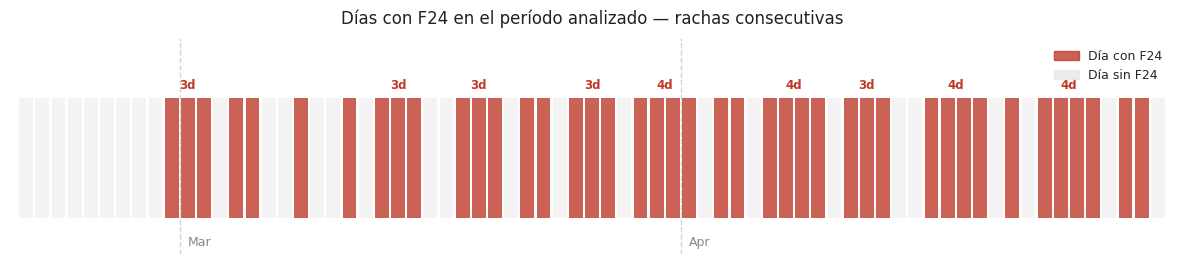

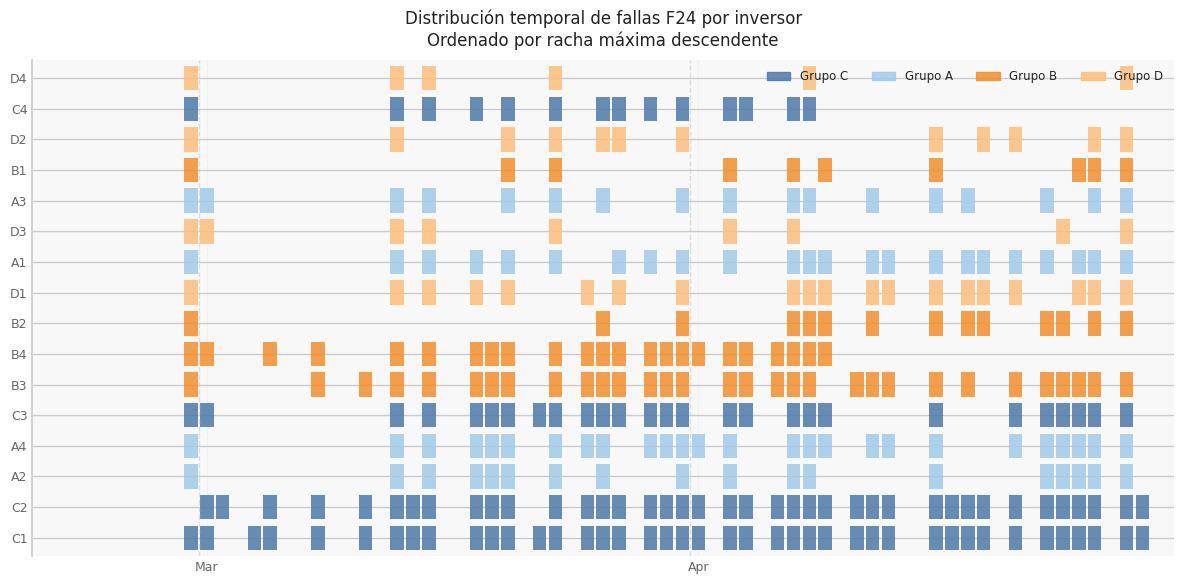

In [ ]:
# ─────────────────────────────────────────────
# F24 — Reincidencia: rachas de días consecutivos
# Nivel 1: parque (f24_dias)
# Nivel 2: inversor individual (f24)
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import groupby

BASE_COLOR = '#4e79a7'
ORANGE     = '#f28e2b'
RED        = '#c0392b'
color_grupo = {
    'C': '#4e79a7',
    'A': '#a0cbe8',
    'B': '#f28e2b',
    'D': '#ffbe7d'
}

# ── Preparación base ──────────────────────────
# reconstruir f24_dias si no está en memoria
f24['fecha_dia'] = f24['fecha_referencia_abierta'].dt.normalize()

todos_los_dias = pd.DataFrame({
    'fecha_dia': pd.to_datetime(df_clima['time'].dt.normalize().unique())
}).sort_values('fecha_dia').reset_index(drop=True)

dias_con_f24 = f24['fecha_dia'].drop_duplicates()
todos_los_dias['f24'] = todos_los_dias['fecha_dia'].isin(dias_con_f24).astype(int)

# ═══════════════════════════════════════════════
# NIVEL 1 — Rachas a nivel parque
# ═══════════════════════════════════════════════
def calcular_rachas(serie_binaria):
    """Retorna lista de longitudes de rachas de 1s consecutivos."""
    rachas = []
    racha_actual = 0
    inicio_racha = None
    inicios = []
    for i, val in enumerate(serie_binaria):
        if val == 1:
            if racha_actual == 0:
                inicio_racha = i
            racha_actual += 1
        else:
            if racha_actual > 0:
                rachas.append(racha_actual)
                inicios.append(inicio_racha)
                racha_actual = 0
    if racha_actual > 0:
        rachas.append(racha_actual)
        inicios.append(inicio_racha)
    return rachas, inicios

rachas_parque, inicios_parque = calcular_rachas(todos_los_dias['f24'].values)
fechas_inicio = [todos_los_dias['fecha_dia'].iloc[i] for i in inicios_parque]

df_rachas_parque = pd.DataFrame({
    'fecha_inicio': fechas_inicio,
    'longitud':     rachas_parque
}).sort_values('longitud', ascending=False)

print("═" * 55)
print("RACHAS DE DÍAS CONSECUTIVOS CON F24 — PARQUE")
print("═" * 55)
print(f"Total rachas:          {len(rachas_parque)}")
print(f"Racha más larga:       {max(rachas_parque)} días")
print(f"Racha promedio:        {np.mean(rachas_parque):.1f} días")
print(f"Días aislados (n=1):   {rachas_parque.count(1)}")
print()
print("Distribución de rachas:")
from collections import Counter
dist = Counter(rachas_parque)
for k in sorted(dist.keys()):
    print(f"  {k} día(s): {dist[k]} racha(s)")
print()
print("Top 5 rachas más largas:")
print(df_rachas_parque.head().to_string(index=False))
print()

# ═══════════════════════════════════════════════
# NIVEL 2 — Rachas por inversor
# ═══════════════════════════════════════════════
resultados_inv = []

for inv in f24['inversor'].unique():
    dias_inv = f24[f24['inversor'] == inv]['fecha_dia'].drop_duplicates()
    serie = todos_los_dias['fecha_dia'].isin(dias_inv).astype(int).values
    rachas_inv, _ = calcular_rachas(serie)
    if rachas_inv:
        resultados_inv.append({
            'inversor':       inv,
            'grupo':          inv[0],
            'n_rachas':       len(rachas_inv),
            'racha_max':      max(rachas_inv),
            'racha_media':    np.mean(rachas_inv),
            'dias_aislados':  rachas_inv.count(1),
            'pct_aislados':   rachas_inv.count(1) / len(rachas_inv) * 100,
        })

df_inv_rachas = (
    pd.DataFrame(resultados_inv)
    .sort_values('racha_max', ascending=False)
)

print("═" * 65)
print("RACHAS POR INVERSOR")
print("═" * 65)
print(df_inv_rachas.round(1).to_string(index=False))
print()

# resumen por grupo
print("─" * 65)
print("RESUMEN POR GRUPO")
print("─" * 65)
grp = df_inv_rachas.groupby('grupo').agg(
    racha_max_grupo=('racha_max', 'max'),
    racha_media_grupo=('racha_media', 'mean'),
    pct_aislados_grupo=('pct_aislados', 'mean')
).round(1)
print(grp.to_string())
print()

# ═══════════════════════════════════════════════
# GRÁFICA 1 — Calendario de rachas a nivel parque
# ═══════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(12, 2.8))
fig1.patch.set_facecolor('white')
ax1.set_facecolor('white')

# línea de días con/sin F24
for i, row in todos_los_dias.iterrows():
    color = RED if row['f24'] == 1 else '#e8e8e8'
    ax1.bar(i, 1, color=color, width=0.85,
            alpha=0.8 if row['f24'] == 1 else 0.5,
            linewidth=0, zorder=3)

# anotar rachas > 3 días
for fecha, long in zip(fechas_inicio, rachas_parque):
    if long >= 3:
        idx = todos_los_dias[todos_los_dias['fecha_dia'] == fecha].index[0]
        ax1.text(idx + long/2 - 0.5, 1.05, f'{long}d',
                 ha='center', va='bottom', fontsize=8.5,
                 color=RED, fontweight='bold')

# separadores de mes
for mes_inicio in todos_los_dias[todos_los_dias['fecha_dia'].dt.day == 1].index:
    ax1.axvline(mes_inicio - 0.5, color='#aaaaaa',
                lw=1, linestyle='--', alpha=0.5, zorder=4)
    mes_label = todos_los_dias['fecha_dia'].iloc[mes_inicio].strftime('%b')
    ax1.text(mes_inicio, -0.15, mes_label,
             ha='left', va='top', fontsize=9, color='#888888')

ax1.set_xlim(-1, len(todos_los_dias))
ax1.set_ylim(-0.3, 1.5)
ax1.axis('off')
ax1.set_title('Días con F24 en el período analizado — rachas consecutivas',
              fontsize=12, fontweight='normal', color='#222222', pad=10)

parche_f24 = mpatches.Patch(color=RED, alpha=0.8, label='Día con F24')
parche_no  = mpatches.Patch(color='#e8e8e8', alpha=0.8, label='Día sin F24')
ax1.legend(handles=[parche_f24, parche_no], fontsize=9,
           frameon=False, loc='upper right')

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════
# GRÁFICA 2 — Rachas por inversor (heatmap)
# eje X = días del período, eje Y = inversor
# ═══════════════════════════════════════════════
inversores_ord = f24['inversor'].unique()
inversores_ord = sorted(inversores_ord,
    key=lambda x: df_inv_rachas[df_inv_rachas['inversor']==x]['racha_max'].values[0]
    if x in df_inv_rachas['inversor'].values else 0,
    reverse=True
)

fig2, ax2 = plt.subplots(figsize=(12, 6))
fig2.patch.set_facecolor('white')
ax2.set_facecolor('#f8f8f8')

for yi, inv in enumerate(inversores_ord):
    dias_inv = set(f24[f24['inversor'] == inv]['fecha_dia'].dt.normalize())
    grupo = inv[0]
    col = color_grupo[grupo]
    r = int(col[1:3], 16)/255
    g = int(col[3:5], 16)/255
    b = int(col[5:7], 16)/255

    for xi, row in todos_los_dias.iterrows():
        if row['fecha_dia'] in dias_inv:
            ax2.bar(xi, 0.8, bottom=yi - 0.4,
                    color=(r, g, b, 0.85),
                    width=0.85, linewidth=0, zorder=3)

# separadores de mes
for mes_inicio in todos_los_dias[todos_los_dias['fecha_dia'].dt.day == 1].index:
    ax2.axvline(mes_inicio - 0.5, color='#cccccc',
                lw=1, linestyle='--', alpha=0.6, zorder=4)

ax2.set_xlim(-1, len(todos_los_dias))
ax2.set_ylim(-0.6, len(inversores_ord) - 0.4)
ax2.set_yticks(range(len(inversores_ord)))
ax2.set_yticklabels(inversores_ord, fontsize=9, color='#555555')

# etiquetas de mes en eje X
mes_ticks = todos_los_dias[todos_los_dias['fecha_dia'].dt.day == 1].index.tolist()
mes_labels = [todos_los_dias['fecha_dia'].iloc[i].strftime('%b') for i in mes_ticks]
ax2.set_xticks(mes_ticks)
ax2.set_xticklabels(mes_labels, fontsize=9, color='#666666')

ax2.set_title('Distribución temporal de fallas F24 por inversor\n'
              'Ordenado por racha máxima descendente',
              fontsize=12, fontweight='normal', color='#222222', pad=10)
ax2.grid(axis='x', color='#eeeeee', linewidth=0.5, zorder=0)
ax2.spines[['top', 'right', 'bottom']].set_visible(False)
ax2.spines['left'].set_color('#cccccc')
ax2.tick_params(colors='#666666', labelsize=9, length=0)

handles_grp = [
    mpatches.Patch(color=col, alpha=0.85, label=f'Grupo {g}')
    for g, col in color_grupo.items()
]
ax2.legend(handles=handles_grp, fontsize=8.5,
           frameon=False, loc='upper right', ncol=4)

plt.tight_layout()
plt.show()


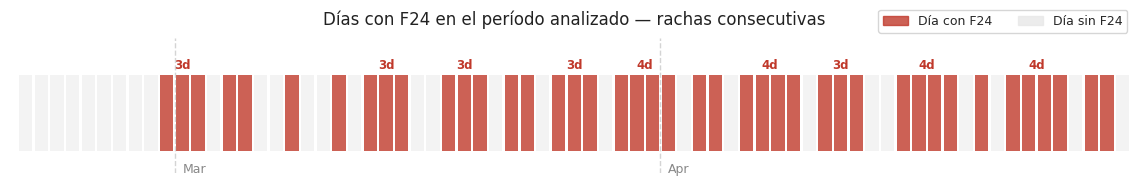

In [ ]:
# ═══════════════════════════════════════════════
# GRÁFICA 1 — Calendario de rachas a nivel parque
# ═══════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(12, 2))
fig1.patch.set_facecolor('white')
ax1.set_facecolor('white')

# línea de días con/sin F24
for i, row in todos_los_dias.iterrows():
    color = RED if row['f24'] == 1 else '#e8e8e8'
    ax1.bar(i, 1, color=color, width=0.85,
            alpha=0.8 if row['f24'] == 1 else 0.5,
            linewidth=0, zorder=3)

# anotar rachas > 3 días
for fecha, long in zip(fechas_inicio, rachas_parque):
    if long >= 3:
        idx = todos_los_dias[todos_los_dias['fecha_dia'] == fecha].index[0]
        ax1.text(idx + long/2 - 0.5, 1.05, f'{long}d',
                 ha='center', va='bottom', fontsize=8.5,
                 color=RED, fontweight='bold')

# separadores de mes
for mes_inicio in todos_los_dias[todos_los_dias['fecha_dia'].dt.day == 1].index:
    ax1.axvline(mes_inicio - 0.5, color='#aaaaaa',
                lw=1, linestyle='--', alpha=0.5, zorder=4)
    mes_label = todos_los_dias['fecha_dia'].iloc[mes_inicio].strftime('%b')
    ax1.text(mes_inicio, -0.15, mes_label,
             ha='left', va='top', fontsize=9, color='#888888')

ax1.set_xlim(-1, len(todos_los_dias))
ax1.set_ylim(-0.3, 1.5)
ax1.axis('off')
ax1.set_title('Días con F24 en el período analizado — rachas consecutivas',
              fontsize=12, fontweight='normal', color='#222222', pad=10)

parche_f24 = mpatches.Patch(color=RED, alpha=0.8, label='Día con F24')
parche_no  = mpatches.Patch(color='#e8e8e8', alpha=0.8, label='Día sin F24')
ax1.legend(handles=[parche_f24, parche_no], fontsize=9,
           frameon=True, bbox_to_anchor=(0.764, 0.99),ncol=2)

plt.tight_layout()
plt.show()


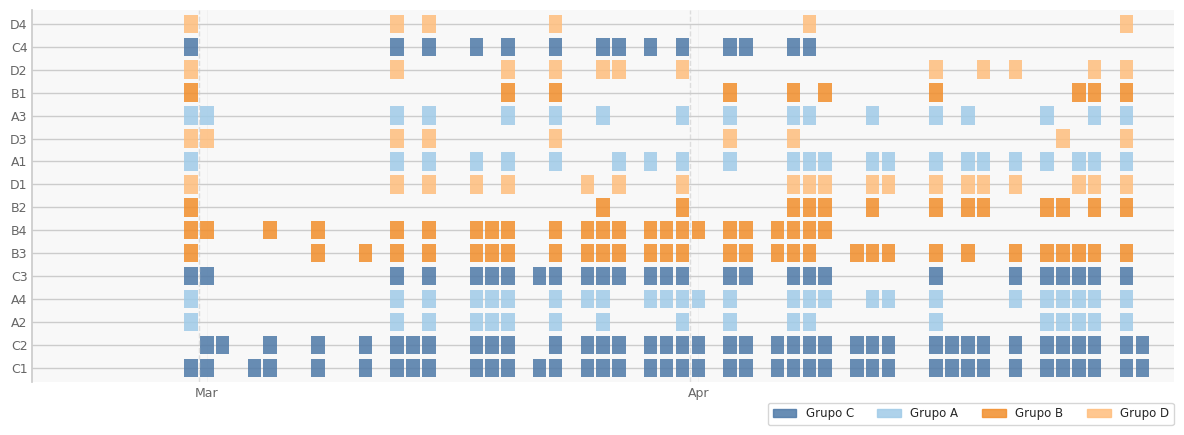

In [ ]:
# ═══════════════════════════════════════════════
# GRÁFICA 2 — Rachas por inversor (heatmap)
# eje X = días del período, eje Y = inversor
# ═══════════════════════════════════════════════
inversores_ord = f24['inversor'].unique()
inversores_ord = sorted(inversores_ord,
    key=lambda x: df_inv_rachas[df_inv_rachas['inversor']==x]['racha_max'].values[0]
    if x in df_inv_rachas['inversor'].values else 0,
    reverse=True
)

fig2, ax2 = plt.subplots(figsize=(12, 4.5))
fig2.patch.set_facecolor('white')
ax2.set_facecolor('#f8f8f8')

for yi, inv in enumerate(inversores_ord):
    dias_inv = set(f24[f24['inversor'] == inv]['fecha_dia'].dt.normalize())
    grupo = inv[0]
    col = color_grupo[grupo]
    r = int(col[1:3], 16)/255
    g = int(col[3:5], 16)/255
    b = int(col[5:7], 16)/255

    for xi, row in todos_los_dias.iterrows():
        if row['fecha_dia'] in dias_inv:
            ax2.bar(xi, 0.8, bottom=yi - 0.4,
                    color=(r, g, b, 0.85),
                    width=0.85, linewidth=0, zorder=3)

# separadores de mes
for mes_inicio in todos_los_dias[todos_los_dias['fecha_dia'].dt.day == 1].index:
    ax2.axvline(mes_inicio - 0.5, color='#cccccc',
                lw=1, linestyle='--', alpha=0.6, zorder=4)

ax2.set_xlim(-1, len(todos_los_dias))
ax2.set_ylim(-0.6, len(inversores_ord) - 0.4)
ax2.set_yticks(range(len(inversores_ord)))
ax2.set_yticklabels(inversores_ord, fontsize=9, color='#555555')

# etiquetas de mes en eje X
mes_ticks = todos_los_dias[todos_los_dias['fecha_dia'].dt.day == 1].index.tolist()
mes_labels = [todos_los_dias['fecha_dia'].iloc[i].strftime('%b') for i in mes_ticks]
ax2.set_xticks(mes_ticks)
ax2.set_xticklabels(mes_labels, fontsize=9, color='#666666')

#ax2.set_title('Distribución temporal de fallas F24 por inversor\n'
#              'Ordenado por racha máxima descendente',
#              fontsize=12, fontweight='normal', color='#222222', pad=10)
ax2.grid(axis='x', color='#eeeeee', linewidth=0.5, zorder=0)
ax2.spines[['top', 'right', 'bottom']].set_visible(False)
ax2.spines['left'].set_color('#cccccc')
ax2.tick_params(colors='#666666', labelsize=9, length=0)

handles_grp = [
    mpatches.Patch(color=col, alpha=0.85, label=f'Grupo {g}')
    for g, col in color_grupo.items()
]
ax2.legend(handles=handles_grp, fontsize=8.5,
           frameon=True, ncol=4,bbox_to_anchor=(1.005, -0.04))

plt.tight_layout()
plt.show()


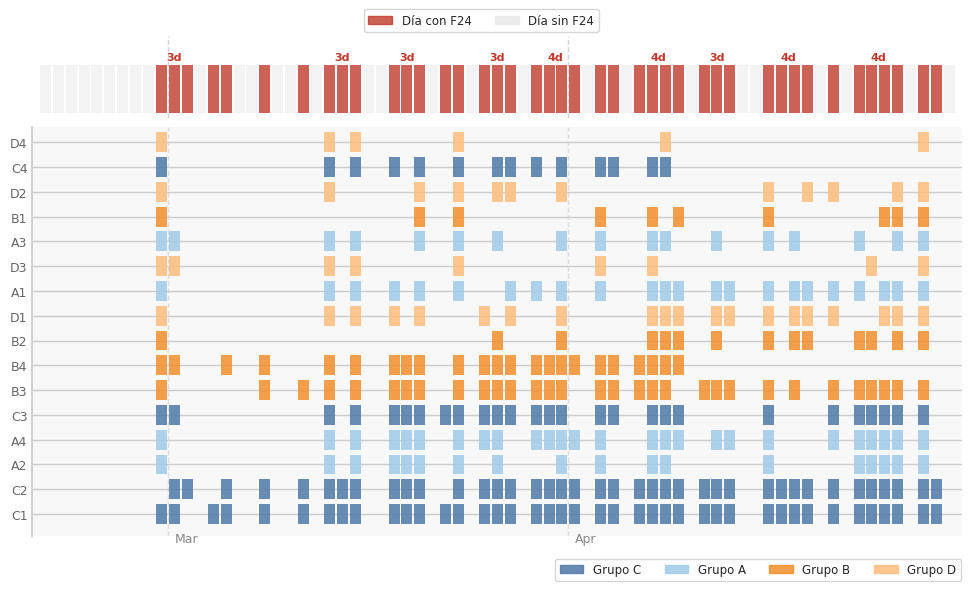

In [ ]:
# ═══════════════════════════════════════════════
# GRÁFICA COMBINADA — Reincidencia F24
# Panel superior: calendario de rachas (parque)
# Panel inferior: heatmap por inversor
# Eje X compartido y alineado
# ═══════════════════════════════════════════════

inversores_ord = f24['inversor'].unique()
inversores_ord = sorted(inversores_ord,
    key=lambda x: df_inv_rachas[df_inv_rachas['inversor']==x]['racha_max'].values[0]
    if x in df_inv_rachas['inversor'].values else 0,
    reverse=True
)

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 6.5),
    sharex=True,
    gridspec_kw={'height_ratios': [1, 5], 'hspace': 0.04}
)
fig.patch.set_facecolor('white')

# ── Panel superior: calendario de rachas ──────
ax1.set_facecolor('white')

for i, row in todos_los_dias.iterrows():
    color = RED if row['f24'] == 1 else '#e8e8e8'
    ax1.bar(i, 1, color=color, width=0.85,
            alpha=0.8 if row['f24'] == 1 else 0.5,
            linewidth=0, zorder=3)

# anotar rachas >= 3 días
for fecha, long in zip(fechas_inicio, rachas_parque):
    if long >= 3:
        idx = todos_los_dias[todos_los_dias['fecha_dia'] == fecha].index[0]
        ax1.text(idx + long/2 - 0.5, 1.05, f'{long}d',
                 ha='center', va='bottom', fontsize=8,
                 color=RED, fontweight='bold')

# separadores de mes
for mes_inicio in todos_los_dias[
        todos_los_dias['fecha_dia'].dt.day == 1].index:
    ax1.axvline(mes_inicio - 0.5, color='#aaaaaa',
                lw=1, linestyle='--', alpha=0.5, zorder=4)

ax1.set_xlim(-1, len(todos_los_dias))
ax1.set_ylim(-0.1, 1.6)
ax1.axis('off')

parche_f24 = mpatches.Patch(color=RED,     alpha=0.8, label='Día con F24')
parche_no  = mpatches.Patch(color='#e8e8e8', alpha=0.8, label='Día sin F24')
ax1.legend(handles=[parche_f24, parche_no],
           fontsize=8.5, frameon=True,
           bbox_to_anchor=(0.35, 0.98), ncol=2)

#ax1.set_title('Reincidencia F24 — rachas consecutivas por día e inversor',
#              fontsize=12, fontweight='normal', color='#222222', pad=10)

# ── Panel inferior: heatmap por inversor ──────
ax2.set_facecolor('#f8f8f8')

for yi, inv in enumerate(inversores_ord):
    dias_inv = set(f24[f24['inversor'] == inv]['fecha_dia'].dt.normalize())
    grupo = inv[0]
    col   = color_grupo[grupo]
    r = int(col[1:3], 16)/255
    g = int(col[3:5], 16)/255
    b = int(col[5:7], 16)/255

    for xi, row in todos_los_dias.iterrows():
        if row['fecha_dia'] in dias_inv:
            ax2.bar(xi, 0.8, bottom=yi - 0.4,
                    color=(r, g, b, 0.85),
                    width=0.85, linewidth=0, zorder=3)

# separadores de mes en panel inferior
for mes_inicio in todos_los_dias[
        todos_los_dias['fecha_dia'].dt.day == 1].index:
    ax2.axvline(mes_inicio - 0.5, color='#cccccc',
                lw=1, linestyle='--', alpha=0.6, zorder=4)
    mes_label = todos_los_dias['fecha_dia'].iloc[mes_inicio].strftime('%b')
    ax2.text(mes_inicio, -0.75, mes_label,
             ha='left', va='top', fontsize=9, color='#888888')

ax2.set_xlim(-1, len(todos_los_dias))
ax2.set_ylim(-0.9, len(inversores_ord) - 0.4)
ax2.set_yticks(range(len(inversores_ord)))
ax2.set_yticklabels(inversores_ord, fontsize=9, color='#555555')
ax2.set_xticks([])  # ocultar eje X — etiquetas van como texto

ax2.grid(axis='x', color='#eeeeee', linewidth=0.5, zorder=0)
ax2.spines[['top', 'right', 'bottom']].set_visible(False)
ax2.spines['left'].set_color('#cccccc')
ax2.tick_params(colors='#666666', labelsize=9, length=0)

handles_grp = [
    mpatches.Patch(color=col, alpha=0.85, label=f'Grupo {g}')
    for g, col in color_grupo.items()
]
ax2.legend(handles=handles_grp, fontsize=8.5,
           frameon=True,bbox_to_anchor=(1.005, -0.04), ncol=4)

plt.show()
#print("✓ Guardada: f24_reincidencia_combinada.png")

##### Riesgo de condensacion por hora del evento

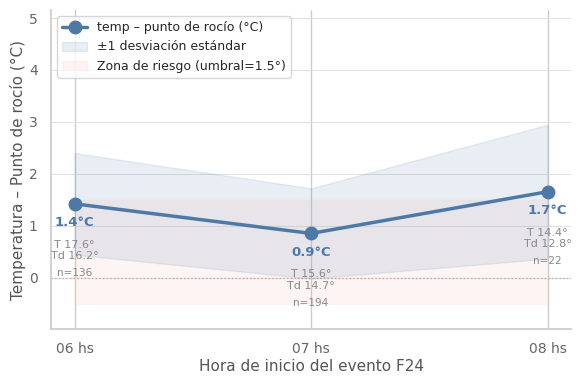

In [ ]:
# ── Configuración de colores base ──────────────────────────────
BASE_COLOR = '#4e79a7'
ORANGE     = '#f28e2b'

# ── Preparación ──────────────────────────────
f24['hora_int'] = f24['fecha_referencia_abierta'].dt.hour

# ═══════════════════════════════════════════════
# GRÁFICA 1 — Riesgo de condensación por hora
# ═══════════════════════════════════════════════
perfil = (
    f24
    .groupby('hora_int')
    .agg(
        rc_mean=('riesgo_condensacion', 'mean'),
        rc_std=('riesgo_condensacion', 'std'),
        temp_mean=('temp', 'mean'),
        dwpt_mean=('dwpt', 'mean'),
        n=('riesgo_condensacion', 'count')
    )
    .reset_index()
    .sort_values('hora_int')
)
perfil_main = perfil[perfil['n'] >= 10].copy()

fig1, ax1 = plt.subplots(figsize=(6, 4))
fig1.patch.set_facecolor('white')
ax1.set_facecolor('white')

# 1. AJUSTE: Área sombreada crítica acotada estrictamente hasta las 8 hs
hora_min = perfil_main['hora_int'].min()
ax1.fill_between([hora_min, 8], -0.5, 1.5, color='#fdecea', alpha=0.5, zorder=0)

# Línea guía en el cero absoluto
ax1.axhline(0, color='#c0392b', lw=1, linestyle=':', alpha=0.4, zorder=1)

# 2. Línea principal y su banda de desviación
linea_rc, = ax1.plot(perfil_main['hora_int'], perfil_main['rc_mean'],
                     color=BASE_COLOR, lw=2.5, marker='o', markersize=9,
                     zorder=4, label='temp – punto de rocío (°C)')

banda_std = ax1.fill_between(perfil_main['hora_int'],
                             perfil_main['rc_mean'] - perfil_main['rc_std'],
                             perfil_main['rc_mean'] + perfil_main['rc_std'],
                             color=BASE_COLOR, alpha=0.12, zorder=3,
                             label='±1 desviación estándar')

# 3. Anotaciones por punto desplazadas verticalmente hacia abajo
for _, row in perfil_main.iterrows():
    # La etiqueta principal del valor (°C) ahora inicia donde antes estaba la segunda línea
    ax1.annotate(f"{row['rc_mean']:.1f}°C",
                 (row['hora_int'], row['rc_mean']),
                 textcoords='offset points', xytext=(0, -16),
                 ha='center', fontsize=9.5, color=BASE_COLOR, fontweight='bold')

    ax1.annotate(f"T {row['temp_mean']:.1f}°\nTd {row['dwpt_mean']:.1f}°",
                 (row['hora_int'], row['rc_mean']),
                 textcoords='offset points', xytext=(0, -40),
                 ha='center', fontsize=8, color='#888888')

    ax1.annotate(f"n={int(row['n'])}",
                 (row['hora_int'], row['rc_mean']),
                 textcoords='offset points', xytext=(0, -52),
                 ha='center', fontsize=7.5, color='#888888')

# Ejes y formato
ax1.set_xlabel('Hora de inicio del evento F24', fontsize=11, color='#555555', labelpad=2)
ax1.set_ylabel('Temperatura – Punto de rocío (°C)', fontsize=11, color='#555555', labelpad=2)

ax1.set_xticks(perfil_main['hora_int'])
ax1.set_xticklabels([f'{h:02d} hs' for h in perfil_main['hora_int']], fontsize=10, color='#666666')
ax1.tick_params(axis='y', colors='#666666', labelsize=10)

# Ajuste de límites para dar suficiente aire inferior por las nuevas posiciones del texto
ax1.set_ylim(-0.99, perfil_main['rc_mean'].max() + 3.5)
ax1.grid(axis='y', color='#e0e0e0', linewidth=0.7, zorder=0)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#cccccc')

# 4. Agrego el área de condensación directo a las leyendas de forma limpia
parche_condensacion = mpatches.Patch(color='#fdecea', alpha=0.6, label='Zona de riesgo (umbral=1.5°)')

# Renderizar leyenda unificada
ax1.legend(handles=[linea_rc, banda_std, parche_condensacion],
           fontsize=9, frameon=True, loc='upper left')

plt.tight_layout()
plt.show()


##### Retrospectiva climatica - Antecedentes

 horas_previas  rhum_mean  temp_mean  rc_mean  n
             8  81.169014  19.426761 3.436620 71
             7  83.521127  18.990141 2.940845 71
             6  85.380282  18.598592 2.570423 71
             5  87.239437  18.205634 2.221127 71
             4  89.042254  17.840845 1.877465 71
             3  90.154930  17.556338 1.683099 71
             2  91.830986  17.171831 1.374648 71
             1  92.450704  16.776056 1.257746 71


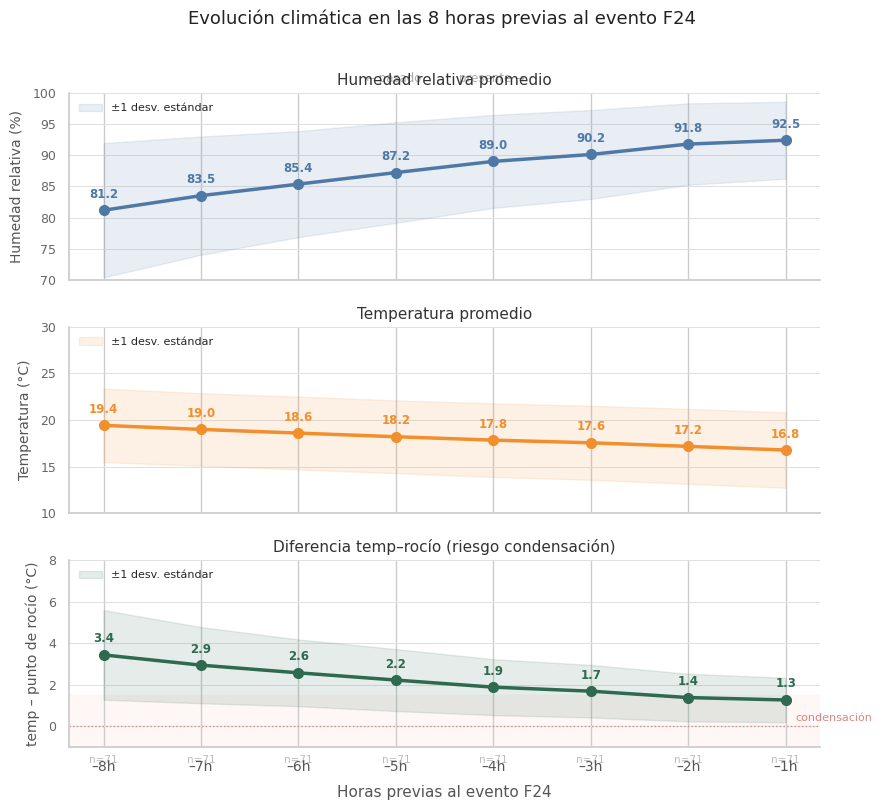

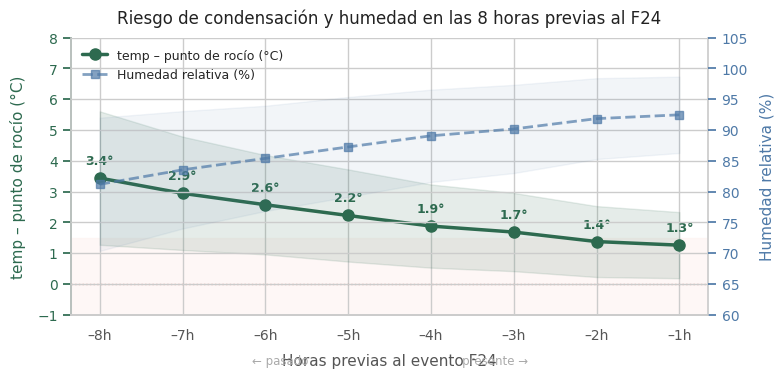

In [ ]:
# ─────────────────────────────────────────────
# F24 — Ventana retrospectiva climática
# Para cada evento F24, tomar las N horas previas
# del dataset de clima y analizar la evolución de:
#   - rhum
#   - temp
#   - riesgo_condensacion (temp - dwpt)
# Fuente: f24 + df_clima
# ─────────────────────────────────────────────

BASE_COLOR = '#4e79a7'
ORANGE     = '#f28e2b'
RED        = '#c0392b'

# ── Preparación ──────────────────────────────
# Indexar df_clima por time para lookup eficiente
clima_idx = df_clima.set_index('time').sort_index()

# Horas únicas de eventos F24 (una por hora-evento)
horas_f24 = f24['fecha_referencia_abierta'].drop_duplicates().sort_values()

# Ventana: horas previas a analizar (1 a 8)
VENTANA = list(range(1, 9))

# ── Construcción de la matriz retrospectiva ──
# Para cada evento y cada hora previa, extraer variables
registros = []
for hora_evento in horas_f24:
    for h_prev in VENTANA:
        hora_buscar = hora_evento - pd.Timedelta(hours=h_prev)
        if hora_buscar in clima_idx.index:
            row = clima_idx.loc[hora_buscar]
            registros.append({
                'hora_evento':  hora_evento,
                'horas_previas': h_prev,
                'rhum':          row['rhum'],
                'temp':          row['temp'],
                'dwpt':          row['dwpt'],
                'riesgo_condensacion': row['riesgo_condensacion'],
            })

df_ventana = pd.DataFrame(registros)

# ── Promedio por ventana ──────────────────────
resumen = (
    df_ventana
    .groupby('horas_previas')
    .agg(
        rhum_mean=('rhum', 'mean'),
        rhum_std=('rhum', 'std'),
        temp_mean=('temp', 'mean'),
        temp_std=('temp', 'std'),
        rc_mean=('riesgo_condensacion', 'mean'),
        rc_std=('riesgo_condensacion', 'std'),
        n=('rhum', 'count')
    )
    .reset_index()
    .sort_values('horas_previas', ascending=False)  # de -8h a -1h
)

# invertir para que el eje X vaya de -8h a -1h (izq a der = pasado a presente)
resumen['label'] = resumen['horas_previas'].apply(lambda h: f'–{h}h')

print(resumen[['horas_previas','rhum_mean','temp_mean','rc_mean','n']].to_string(index=False))


# ═══════════════════════════════════════════════
# GRÁFICA — Evolución climática previa al F24
# 3 paneles: rhum / temp / riesgo_condensacion
# ═══════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
fig.patch.set_facecolor('white')

x = np.arange(len(resumen))
xlabels = resumen['label'].tolist()

configs = [
    dict(col_mean='rhum_mean', col_std='rhum_std',
         color=BASE_COLOR, ylabel='Humedad relativa (%)',
         title='Humedad relativa promedio', ylim=(70, 100),
         hline=None),
    dict(col_mean='temp_mean', col_std='temp_std',
         color=ORANGE, ylabel='Temperatura (°C)',
         title='Temperatura promedio', ylim=(10, 30),
         hline=None),
    dict(col_mean='rc_mean', col_std='rc_std',
         color='#2d6a4f', ylabel='temp – punto de rocío (°C)',
         title='Diferencia temp–rocío (riesgo condensación)', ylim=(-1, 8),
         hline=0),
]

for ax, cfg in zip(axes, configs):
    ax.set_facecolor('white')

    # zona crítica solo en el panel de condensación
    if cfg['hline'] is not None:
        ax.axhspan(-1, 1.5, color='#fdecea', alpha=0.4, zorder=0)
        ax.axhline(0, color=RED, lw=1, linestyle=':', alpha=0.5, zorder=1)
        ax.text(x[-1] + 0.1, 0.15, 'condensación',
                fontsize=8, color=RED, alpha=0.6, va='bottom')

    # línea + banda
    y     = resumen[cfg['col_mean']].values
    y_std = resumen[cfg['col_std']].values

    ax.plot(x, y, color=cfg['color'], lw=2.5, marker='o',
            markersize=7, zorder=4)
    ax.fill_between(x, y - y_std, y + y_std,
                    color=cfg['color'], alpha=0.12, zorder=3,
                    label='±1 desv. estándar')

    # anotaciones
    for xi, (yi, ni) in enumerate(zip(y, resumen['n'])):
        ax.annotate(f'{yi:.1f}',
                    (xi, yi), textcoords='offset points',
                    xytext=(0, 9), ha='center',
                    fontsize=8.5, color=cfg['color'], fontweight='bold')

    # flecha indicando dirección temporal
    if ax == axes[0]:
        ax.annotate('← pasado          presente →',
                    xy=(0.5, 1.06), xycoords='axes fraction',
                    ha='center', fontsize=8.5, color='#aaaaaa')

    ax.set_ylabel(cfg['ylabel'], fontsize=10, color='#555555', labelpad=6)
    ax.set_title(cfg['title'], fontsize=11, fontweight='normal',
                 color='#333333', pad=6)
    ax.set_ylim(cfg['ylim'])
    ax.grid(axis='y', color='#e0e0e0', linewidth=0.7, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#cccccc')
    ax.tick_params(colors='#666666', labelsize=9)
    ax.legend(fontsize=8, frameon=False, loc='upper left')

# eje X compartido
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(xlabels, fontsize=10, color='#555555')
axes[-1].set_xlabel('Horas previas al evento F24', fontsize=11,
                    color='#555555', labelpad=8)

# n por ventana al pie
for xi, ni in enumerate(resumen['n']):
    axes[-1].text(xi, axes[-1].get_ylim()[0] - 0.8,
                  f'n={ni}', ha='center', fontsize=7.5, color='#bbbbbb')

fig.suptitle('Evolución climática en las 8 horas previas al evento F24',
             fontsize=13, fontweight='normal', color='#222222', y=1.01)

plt.tight_layout()
plt.show()


# ═══════════════════════════════════════════════
# BONUS — Versión compacta: solo riesgo_condensacion
# con rhum como contexto en eje secundario
# ═══════════════════════════════════════════════
fig2, ax_rc = plt.subplots(figsize=(8, 4))
fig2.patch.set_facecolor('white')
ax_rc.set_facecolor('white')
ax_rh = ax_rc.twinx()

# zona crítica
ax_rc.axhspan(-1, 1.5, color='#fdecea', alpha=0.4, zorder=0)
ax_rc.axhline(0, color=RED, lw=1, linestyle=':', alpha=0.5)

# riesgo condensación
y_rc  = resumen['rc_mean'].values
ys_rc = resumen['rc_std'].values
ax_rc.plot(x, y_rc, color='#2d6a4f', lw=2.5, marker='o',
           markersize=8, zorder=4, label='temp – punto de rocío (°C)')
ax_rc.fill_between(x, y_rc - ys_rc, y_rc + ys_rc,
                   color='#2d6a4f', alpha=0.12, zorder=3)
for xi, yi in enumerate(y_rc):
    ax_rc.annotate(f'{yi:.1f}°',
                   (xi, yi), textcoords='offset points',
                   xytext=(0, 10), ha='center',
                   fontsize=9, color='#2d6a4f', fontweight='bold')

# humedad en eje secundario
y_rh  = resumen['rhum_mean'].values
ys_rh = resumen['rhum_std'].values
ax_rh.plot(x, y_rh, color=BASE_COLOR, lw=2, marker='s',
           markersize=6, linestyle='--', alpha=0.7,
           zorder=3, label='Humedad relativa (%)')
ax_rh.fill_between(x, y_rh - ys_rh, y_rh + ys_rh,
                   color=BASE_COLOR, alpha=0.07, zorder=2)

# ejes
ax_rc.set_ylabel('temp – punto de rocío (°C)', fontsize=11,
                 color='#2d6a4f', labelpad=8)
ax_rh.set_ylabel('Humedad relativa (%)', fontsize=11,
                 color=BASE_COLOR, labelpad=8)
ax_rc.set_ylim(-1, 8)
ax_rh.set_ylim(60, 105)
ax_rc.tick_params(axis='y', colors='#2d6a4f', labelsize=10)
ax_rh.tick_params(axis='y', colors=BASE_COLOR, labelsize=10)
ax_rc.set_xticks(x)
ax_rc.set_xticklabels(xlabels, fontsize=10, color='#555555')
ax_rc.set_xlabel('Horas previas al evento F24', fontsize=11,
                 color='#555555', labelpad=8)
ax_rc.set_title('Riesgo de condensación y humedad en las 8 horas previas al F24',
                fontsize=12, fontweight='normal', color='#222222', pad=10)
ax_rc.grid(axis='y', color='#e0e0e0', linewidth=0.7, zorder=0)
ax_rc.spines[['top']].set_visible(False)
ax_rc.spines[['left']].set_color('#2d6a4f')
ax_rc.spines[['bottom']].set_color('#cccccc')
ax_rh.spines[['top', 'right']].set_visible(False)
ax_rh.spines[['right']].set_color(BASE_COLOR)

lines1, lab1 = ax_rc.get_legend_handles_labels()
lines2, lab2 = ax_rh.get_legend_handles_labels()
ax_rc.legend(lines1 + lines2, lab1 + lab2,
             fontsize=9, frameon=False, loc='upper left')

ax_rc.annotate('← pasado                                         presente →',
               xy=(0.5, -0.18), xycoords='axes fraction',
               ha='center', fontsize=8.5, color='#aaaaaa')

plt.tight_layout()
plt.show()


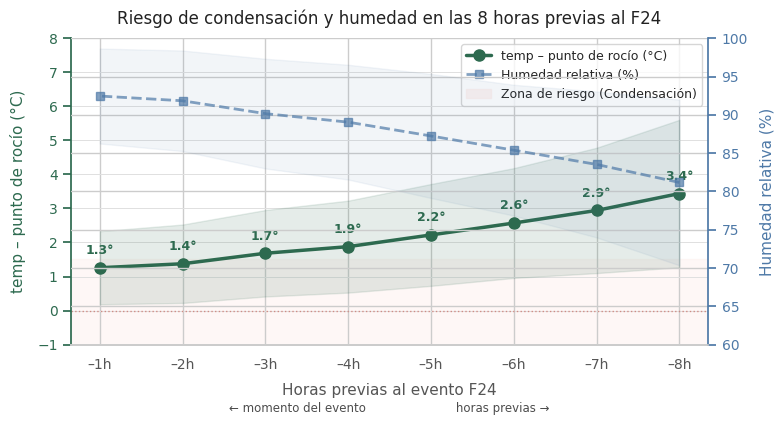

In [ ]:
# Aseguramos que 'RED' y 'BASE_COLOR' existan si no vienen definidos atrás
if 'RED' not in locals(): RED = '#c0392b'
if 'BASE_COLOR' not in locals(): BASE_COLOR = '#4e79a7'

# ═══════════════════════════════════════════════
# BONUS — Versión compacta: solo riesgo_condensacion
# con rhum como contexto en eje secundario
# ═══════════════════════════════════════════════
fig2, ax_rc = plt.subplots(figsize=(8, 4.5))
fig2.patch.set_facecolor('white')
ax_rc.set_facecolor('white')
ax_rh = ax_rc.twinx()

# SOLUCIÓN: Usar el índice o los datos reales del dataframe para garantizar que X e Y coincidan
x_real = resumen.index if 'hora_int' not in resumen.columns else resumen['hora_int']

# zona crítica (Guardamos el área en una variable para la leyenda)
zona_critica = ax_rc.axhspan(-1, 1.5, color='#fdecea', alpha=0.4, zorder=0)
ax_rc.axhline(0, color=RED, lw=1, linestyle=':', alpha=0.5)

# riesgo condensación
y_rc  = resumen['rc_mean'].values
ys_rc = resumen['rc_std'].values

linea_rc, = ax_rc.plot(x_real, y_rc, color='#2d6a4f', lw=2.5, marker='o',
                       markersize=8, zorder=4, label='temp – punto de rocío (°C)')
ax_rc.fill_between(x_real, y_rc - ys_rc, y_rc + ys_rc,
                   color='#2d6a4f', alpha=0.12, zorder=3)

# CORRECCIÓN: zip permite emparejar la coordenada X correcta con su valor Y para el texto
for xi, yi in zip(x_real, y_rc):
    ax_rc.annotate(f'{yi:.1f}°',
                   (xi, yi), textcoords='offset points',
                   xytext=(0, 10), ha='center',
                   fontsize=9, color='#2d6a4f', fontweight='bold')

# humedad en eje secundario
y_rh  = resumen['rhum_mean'].values
ys_rh = resumen['rhum_std'].values
linea_rh, = ax_rh.plot(x_real, y_rh, color=BASE_COLOR, lw=2, marker='s',
                       markersize=6, linestyle='--', alpha=0.7,
                       zorder=3, label='Humedad relativa (%)')
ax_rh.fill_between(x_real, y_rh - ys_rh, y_rh + ys_rh,
                   color=BASE_COLOR, alpha=0.07, zorder=2)

# ejes
ax_rc.set_ylabel('temp – punto de rocío (°C)', fontsize=11, color='#2d6a4f', labelpad=8)
ax_rh.set_ylabel('Humedad relativa (%)', fontsize=11, color=BASE_COLOR, labelpad=8)

ax_rc.set_ylim(-1, 8)
ax_rh.set_ylim(60, 100)

ax_rc.tick_params(axis='y', colors='#2d6a4f', labelsize=10)
ax_rh.tick_params(axis='y', colors=BASE_COLOR, labelsize=10)

ax_rc.set_xticks(x_real)
if 'xlabels' in locals() and len(xlabels) == len(x_real):
    ax_rc.set_xticklabels(xlabels, fontsize=10, color='#555555')
else:
    ax_rc.set_xticklabels([f'{int(i)}h' for i in x_real], fontsize=10, color='#555555')

ax_rc.set_xlabel('Horas previas al evento F24', fontsize=11, color='#555555', labelpad=8)
ax_rc.set_title('Riesgo de condensación y humedad en las 8 horas previas al F24',
                fontsize=12, fontweight='normal', color='#222222', pad=10)

ax_rc.grid(axis='y', color='#e0e0e0', linewidth=0.7, zorder=0)

# Limpieza y personalización de bordes (Spines)
ax_rc.spines[['top', 'right']].set_visible(False)
ax_rc.spines[['left']].set_color('#2d6a4f')
ax_rc.spines[['bottom']].set_color('#cccccc')

# Activamos el borde derecho de ax_rh para que se pinte del color de su variable
ax_rh.spines[['top']].set_visible(False)
ax_rh.spines[['left']].set_visible(False)
ax_rh.spines[['right']].set_visible(True)
ax_rh.spines[['right']].set_color(BASE_COLOR)

# Creamos un parche artificial con el mismo color y opacidad que el axhspan
parche_riesgo = mpatches.Patch(color='#fdecea', alpha=0.6, label='Zona de riesgo (Condensación)')

# Unificamos todos los elementos (Línea RC, Línea RH y el Parche) en una sola leyenda
ax_rc.legend(handles=[linea_rc, linea_rh, parche_riesgo], fontsize=9, frameon=True, loc='upper right')

# Anotación temporal inferior ajustable
ax_rc.annotate('← momento del evento                        horas previas →',
               xy=(0.5, -0.22), xycoords='axes fraction',
               ha='center', fontsize=8.5, color='black', alpha=0.7)

plt.tight_layout()
plt.show()

Total horas en f24_clima: 1704
Horas con F24:            71
Horas sin F24:            1633

══════════════════════════════════════════════════════════════════════
CORRELACIÓN DE PEARSON POR VENTANA ACUMULADA
══════════════════════════════════════════════════════════════════════

── rhum ──
stat       mean     min     std
ventana                        
1        0.2117  0.2117     NaN
2        0.2118  0.2082 -0.0114
3        0.2117  0.2148 -0.0654
4        0.2085  0.2236 -0.1127
5        0.2058  0.2332 -0.1478
6        0.2019  0.2364 -0.1650
7        0.1972  0.2326 -0.1712
8        0.1918  0.2260 -0.1719

── temp ──
stat       mean     min     std
ventana                        
1       -0.1812 -0.1812     NaN
2       -0.1777 -0.1735 -0.0482
3       -0.1727 -0.1608 -0.0772
4       -0.1676 -0.1469 -0.1154
5       -0.1633 -0.1333 -0.1430
6       -0.1590 -0.1202 -0.1615
7       -0.1545 -0.1081 -0.1730
8       -0.1497 -0.0961 -0.1827

── riesgo_condensacion ──
stat       mean     min     st

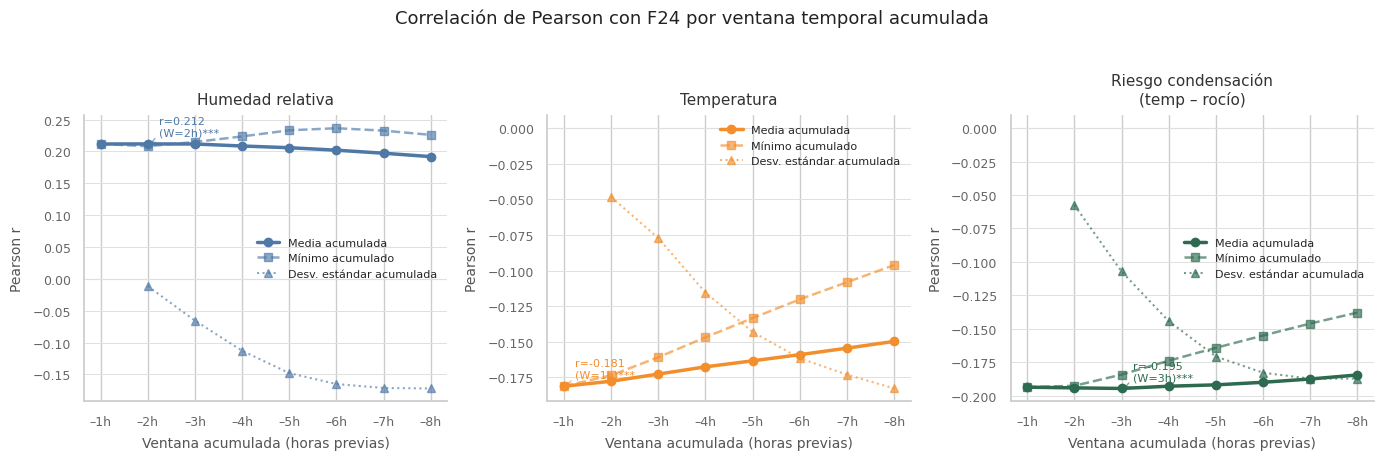


═
═
MEJOR VENTANA POR VARIABLE (mayor |r| en media acumulada)
══════════════════════════════════════════════════════════════════════
           variable  ventana  pearson_r      p_value sig
               rhum        2   0.211784 1.012110e-18 ***
riesgo_condensacion        3  -0.194687 5.335289e-16 ***
               temp        1  -0.181198 4.818188e-14 ***


In [ ]:
# ─────────────────────────────────────────────
# F24 — Ventana acumulada retrospectiva
# Para cada ventana W (1 a 8 horas):
#   calcular estadísticos acumulados [–W a 0]
#   y correlacionar contra ocurrencia de F24
# Fuente: df_clima + f24
# No se modifica df_clima — se trabaja sobre f24_clima
# ─────────────────────────────────────────────

BASE_COLOR = '#4e79a7'
ORANGE     = '#f28e2b'
GREEN      = '#2d6a4f'
RED        = '#c0392b'

# ═══════════════════════════════════════════════
# 1. Construir f24_clima
#    Copia de df_clima + columna binaria f24
# ═══════════════════════════════════════════════
f24_clima = df_clima.copy().sort_values('time').reset_index(drop=True)

# horas únicas con F24
horas_f24 = set(f24['fecha_referencia_abierta'].dt.floor('h').unique())

f24_clima['f24'] = f24_clima['time'].dt.floor('h').isin(horas_f24).astype(int)

print(f"Total horas en f24_clima: {len(f24_clima)}")
print(f"Horas con F24:            {f24_clima['f24'].sum()}")
print(f"Horas sin F24:            {(f24_clima['f24'] == 0).sum()}")
print()

# ═══════════════════════════════════════════════
# 2. Para cada ventana W, calcular estadísticos
#    acumulados rolling hacia atrás
#    Variables: rhum, temp, riesgo_condensacion
# ═══════════════════════════════════════════════
VENTANAS   = list(range(1, 9))
VARIABLES  = ['rhum', 'temp', 'riesgo_condensacion']
STATS      = ['mean', 'min', 'std']

resultados = []

for W in VENTANAS:
    for var in VARIABLES:
        for stat in STATS:
            col_name = f'{var}_{stat}_w{W}'
            if stat == 'mean':
                f24_clima[col_name] = (
                    f24_clima[var]
                    .rolling(window=W, min_periods=W)
                    .mean()
                )
            elif stat == 'min':
                f24_clima[col_name] = (
                    f24_clima[var]
                    .rolling(window=W, min_periods=W)
                    .min()
                )
            elif stat == 'std':
                f24_clima[col_name] = (
                    f24_clima[var]
                    .rolling(window=W, min_periods=W)
                    .std()
                )

            # correlación de Pearson contra f24
            df_valid = f24_clima[['f24', col_name]].dropna()
            if len(df_valid) > 10:
                r, p = stats.pearsonr(df_valid[col_name], df_valid['f24'])
                resultados.append({
                    'ventana':   W,
                    'variable':  var,
                    'stat':      stat,
                    'col':       col_name,
                    'pearson_r': r,
                    'p_value':   p,
                    'sig':       '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
                })

df_resultados = pd.DataFrame(resultados)

print("═" * 70)
print("CORRELACIÓN DE PEARSON POR VENTANA ACUMULADA")
print("═" * 70)
for var in VARIABLES:
    print(f"\n── {var} ──")
    sub = df_resultados[df_resultados['variable'] == var].pivot(
        index='ventana', columns='stat', values='pearson_r'
    ).round(4)
    print(sub.to_string())

# ═══════════════════════════════════════════════
# 3. Gráfica: correlación vs ventana por variable y estadístico
# ═══════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)
fig.patch.set_facecolor('white')

var_config = [
    dict(var='rhum',               color=BASE_COLOR, label='Humedad relativa'),
    dict(var='temp',               color=ORANGE,     label='Temperatura'),
    dict(var='riesgo_condensacion',color=GREEN,       label='Riesgo condensación\n(temp – rocío)'),
]

stat_styles = {
    'mean': dict(ls='-',  marker='o', lw=2.5, label='Media acumulada'),
    'min':  dict(ls='--', marker='s', lw=1.8, label='Mínimo acumulado'),
    'std':  dict(ls=':',  marker='^', lw=1.5, label='Desv. estándar acumulada'),
}

for ax, vcfg in zip(axes, var_config):
    ax.set_facecolor('white')
    ax.axhline(0, color='#cccccc', lw=0.8, zorder=0)

    sub = df_resultados[df_resultados['variable'] == vcfg['var']]

    for stat, sty in stat_styles.items():
        s = sub[sub['stat'] == stat].sort_values('ventana')
        cr = int(vcfg['color'][1:3], 16)/255
        cg = int(vcfg['color'][3:5], 16)/255
        cb = int(vcfg['color'][5:7], 16)/255
        alpha = 1.0 if stat == 'mean' else 0.65
        ax.plot(s['ventana'], s['pearson_r'],
                color=(*( cr, cg, cb), alpha),
                linestyle=sty['ls'], marker=sty['marker'],
                markersize=6, lw=sty['lw'],
                label=sty['label'], zorder=3)

        # marcar ventana con mayor |r| para mean
        if stat == 'mean':
            idx_max = s['pearson_r'].abs().idxmax()
            best = s.loc[idx_max]
            ax.annotate(f"r={best['pearson_r']:.3f}\n(W={int(best['ventana'])}h){best['sig']}",
                        (best['ventana'], best['pearson_r']),
                        textcoords='offset points',
                        xytext=(8, 6), fontsize=8,
                        color=vcfg['color'],
                        arrowprops=dict(arrowstyle='->', color=vcfg['color'],
                                        lw=1, alpha=0.6))

    ax.set_xlabel('Ventana acumulada (horas previas)', fontsize=10,
                  color='#555555', labelpad=6)
    ax.set_ylabel('Pearson r', fontsize=10, color='#555555', labelpad=6)
    ax.set_title(vcfg['label'], fontsize=11, fontweight='normal',
                 color='#333333', pad=8)
    ax.set_xticks(VENTANAS)
    ax.set_xticklabels([f'–{w}h' for w in VENTANAS], fontsize=9)
    ax.tick_params(colors='#666666', labelsize=9)
    ax.grid(axis='y', color='#e0e0e0', linewidth=0.7, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#cccccc')
    ax.legend(fontsize=8, frameon=False, loc='best')

fig.suptitle('Correlación de Pearson con F24 por ventana temporal acumulada',
             fontsize=13, fontweight='normal', color='#222222', y=1.02)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════
# 4. Tabla resumen: mejor ventana por variable
# ═══════════════════════════════════════════════
print("\n═" * 2)
print("MEJOR VENTANA POR VARIABLE (mayor |r| en media acumulada)")
print("═" * 70)
best = (
    df_resultados[df_resultados['stat'] == 'mean']
    .loc[df_resultados[df_resultados['stat'] == 'mean']
         .groupby('variable')['pearson_r']
         .apply(lambda x: x.abs().idxmax())]
    [['variable', 'ventana', 'pearson_r', 'p_value', 'sig']]
    .sort_values('pearson_r', key=abs, ascending=False)
)
print(best.to_string(index=False))

In [ ]:
# ─────────────────────────────────────────────
# F24 — Ventana acumulada: Paso 1
# Filtro f24_clima al rango horario 06–08 hs
# y verificar balance de clases
# ─────────────────────────────────────────────

# ── Filtro horario ────────────────────────────
f24_clima['hora_int'] = f24_clima['time'].dt.hour
f24_ventana = f24_clima[f24_clima['hora_int'].isin([6, 7, 8])].copy()

# ── Balance de clases ─────────────────────────
total     = len(f24_ventana)
con_f24   = f24_ventana['f24'].sum()
sin_f24   = (f24_ventana['f24'] == 0).sum()
pct_f24   = con_f24 / total * 100

print("═" * 50)
print("BALANCE DE CLASES — rango 06 a 08 hs")
print("═" * 50)
print(f"Total horas en ventana:    {total}")
print(f"Horas con F24:             {con_f24}  ({pct_f24:.1f}%)")
print(f"Horas sin F24:             {sin_f24}  ({100-pct_f24:.1f}%)")
print()

# ── Comparativa con dataset completo ─────────
total_orig   = len(f24_clima)
con_f24_orig = f24_clima['f24'].sum()
pct_orig     = con_f24_orig / total_orig * 100

print("─" * 50)
print("COMPARATIVA: dataset completo vs filtrado")
print("─" * 50)
print(f"{'':30} {'Completo':>10} {'06–08 hs':>10}")
print(f"{'Total horas':30} {total_orig:>10} {total:>10}")
print(f"{'Horas con F24':30} {con_f24_orig:>10} {con_f24:>10}")
print(f"{'% con F24':30} {pct_orig:>9.1f}% {pct_f24:>9.1f}%")
print()

# ── Distribución por hora dentro del filtro ──
print("─" * 50)
print("DISTRIBUCIÓN POR HORA dentro del filtro")
print("─" * 50)
dist = f24_ventana.groupby('hora_int')['f24'].agg(
    total='count',
    con_f24='sum',
).assign(
    sin_f24=lambda x: x['total'] - x['con_f24'],
    pct_f24=lambda x: (x['con_f24'] / x['total'] * 100).round(1)
)
print(dist.to_string())

══════════════════════════════════════════════════
BALANCE DE CLASES — rango 06 a 08 hs
══════════════════════════════════════════════════
Total horas en ventana:    213
Horas con F24:             68  (31.9%)
Horas sin F24:             145  (68.1%)

──────────────────────────────────────────────────
COMPARATIVA: dataset completo vs filtrado
──────────────────────────────────────────────────
                                 Completo   06–08 hs
Total horas                          1704        213
Horas con F24                          71         68
% con F24                            4.2%      31.9%

──────────────────────────────────────────────────
DISTRIBUCIÓN POR HORA dentro del filtro
──────────────────────────────────────────────────
          total  con_f24  sin_f24  pct_f24
hora_int                                  
6            71       24       47     33.8
7            71       31       40     43.7
8            71       13       58     18.3


##### Corrimiento horario F24

══════════════════════════════════════════════════
EVENTOS F24 POR HORA Y MES
══════════════════════════════════════════════════
hora_int     6   7  8
mes_nombre           
Febrero      1   1  0
Marzo       19   9  4
Abril        4  21  9

──────────────────────────────────────────────────
HORA PROMEDIO DE OCURRENCIA F24 POR MES
──────────────────────────────────────────────────
            mean  median   std  count
mes_nombre                           
Febrero     6.50     6.5  0.71      2
Marzo       6.53     6.0  0.72     32
Abril       7.15     7.0  0.61     34

──────────────────────────────────────────────────
% DE HORAS CON F24 POR MES Y HORA
──────────────────────────────────────────────────
                     total  con_f24   pct
mes_nombre hora_int                      
Febrero    6            10        1  10.0
           7            10        1  10.0
           8            10        0   0.0
Marzo      6            31       19  61.3
           7            31        9  29

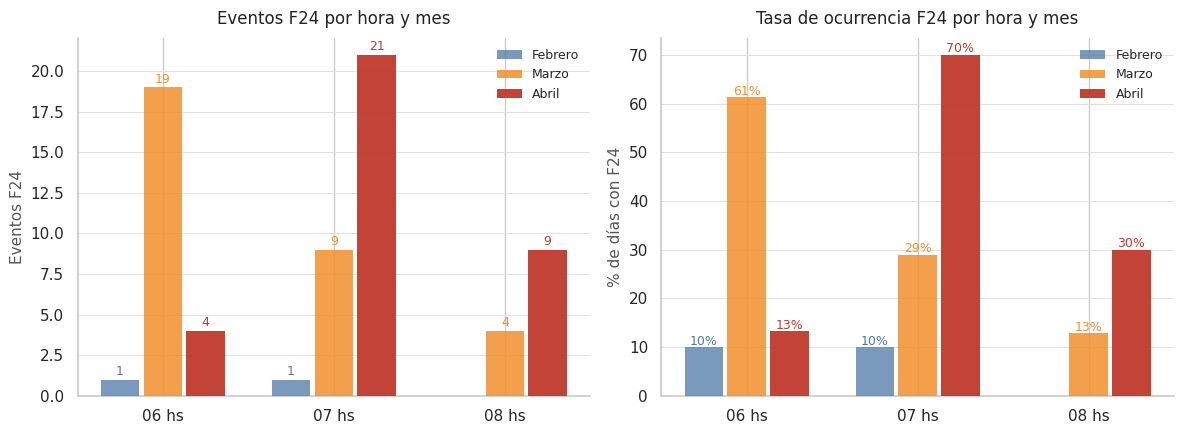

In [ ]:
# ─────────────────────────────────────────────
# F24 — corrimiento horario de F24
# por mes: febrero → marzo → abril
# ─────────────────────────────────────────────

BASE_COLOR = '#4e79a7'
ORANGE     = '#f28e2b'
RED        = '#c0392b'

# ── Preparación ──────────────────────────────
f24_ventana['mes']     = f24_ventana['time'].dt.month
f24_ventana['mes_str'] = f24_ventana['time'].dt.strftime('%B')
mes_orden = {2: 'Febrero', 3: 'Marzo', 4: 'Abril'}
f24_ventana['mes_nombre'] = f24_ventana['mes'].map(mes_orden)

# ── 1. Distribución hora × mes ────────────────
pivot = (
    f24_ventana[f24_ventana['f24'] == 1]
    .groupby(['mes_nombre', 'hora_int'])
    .size()
    .unstack(fill_value=0)
    .reindex(['Febrero', 'Marzo', 'Abril'])
)

print("═" * 50)
print("EVENTOS F24 POR HORA Y MES")
print("═" * 50)
print(pivot.to_string())
print()

# ── 2. Hora promedio de ocurrencia por mes ────
hora_prom = (
    f24_ventana[f24_ventana['f24'] == 1]
    .groupby('mes_nombre')['hora_int']
    .agg(['mean', 'median', 'std', 'count'])
    .reindex(['Febrero', 'Marzo', 'Abril'])
    .round(2)
)
print("─" * 50)
print("HORA PROMEDIO DE OCURRENCIA F24 POR MES")
print("─" * 50)
print(hora_prom.to_string())
print()

# ── 3. % de F24 por hora dentro de cada mes ──
pct_mes_hora = (
    f24_ventana
    .groupby(['mes_nombre', 'hora_int'])['f24']
    .agg(total='count', con_f24='sum')
    .assign(pct=lambda x: (x['con_f24'] / x['total'] * 100).round(1))
    .reindex(['Febrero', 'Marzo', 'Abril'], level=0)
)
print("─" * 50)
print("% DE HORAS CON F24 POR MES Y HORA")
print("─" * 50)
print(pct_mes_hora.to_string())
print()

# ═══════════════════════════════════════════════
# GRÁFICA — Corrimiento horario por mes
# ═══════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.patch.set_facecolor('white')

meses    = ['Febrero', 'Marzo', 'Abril']
colores  = [BASE_COLOR, ORANGE, RED]
horas    = [6, 7, 8]

# ── Panel 1: conteo de eventos por hora y mes ─
ax1 = axes[0]
ax1.set_facecolor('white')
x     = np.arange(len(horas))
width = 0.25

for i, (mes, col) in enumerate(zip(meses, colores)):
    if mes in pivot.index:
        vals = [pivot.loc[mes, h] if h in pivot.columns else 0 for h in horas]
        bars = ax1.bar(x + i*width, vals, width=width*0.9,
                      color=col, alpha=0.75 + i*0.1,
                      label=mes, linewidth=0, zorder=3)
        for bar, v in zip(bars, vals):
            if v > 0:
                ax1.text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + 0.3, str(v),
                         ha='center', fontsize=9, color=col)

ax1.set_xticks(x + width)
ax1.set_xticklabels([f'{h:02d} hs' for h in horas], fontsize=11)
ax1.set_ylabel('Eventos F24', fontsize=11, color='#555555')
ax1.set_title('Eventos F24 por hora y mes', fontsize=12,
              fontweight='normal', color='#222222', pad=10)
ax1.legend(fontsize=9, frameon=False)
ax1.grid(axis='y', color='#e0e0e0', linewidth=0.7, zorder=0)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#cccccc')

# ── Panel 2: % de ocurrencia por hora y mes ───
ax2 = axes[1]
ax2.set_facecolor('white')

for i, (mes, col) in enumerate(zip(meses, colores)):
    if mes in pct_mes_hora.index.get_level_values(0):
        sub = pct_mes_hora.loc[mes]
        pcts = [sub.loc[h, 'pct'] if h in sub.index else 0 for h in horas]
        bars = ax2.bar(x + i*width, pcts, width=width*0.9,
                      color=col, alpha=0.75 + i*0.1,
                      label=mes, linewidth=0, zorder=3)
        for bar, v in zip(bars, pcts):
            if v > 0:
                ax2.text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + 0.5, f'{v:.0f}%',
                         ha='center', fontsize=9, color=col)

ax2.set_xticks(x + width)
ax2.set_xticklabels([f'{h:02d} hs' for h in horas], fontsize=11)
ax2.set_ylabel('% de días con F24', fontsize=11, color='#555555')
ax2.set_title('Tasa de ocurrencia F24 por hora y mes', fontsize=12,
              fontweight='normal', color='#222222', pad=10)
ax2.legend(fontsize=9, frameon=False)
ax2.grid(axis='y', color='#e0e0e0', linewidth=0.7, zorder=0)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#cccccc')

plt.tight_layout()
plt.show()


══════════════════════════════════════════════════
EVENTOS F24 POR HORA Y MES
══════════════════════════════════════════════════
hora_int     6   7  8
mes_nombre           
Febrero      1   1  0
Marzo       19   9  4
Abril        4  21  9

──────────────────────────────────────────────────
HORA PROMEDIO DE OCURRENCIA F24 POR MES
──────────────────────────────────────────────────
            mean  median   std  count
mes_nombre                           
Febrero     6.50     6.5  0.71      2
Marzo       6.53     6.0  0.72     32
Abril       7.15     7.0  0.61     34

──────────────────────────────────────────────────
% DE HORAS CON F24 POR MES Y HORA
──────────────────────────────────────────────────
                     total  con_f24   pct
mes_nombre hora_int                      
Febrero    6            10        1  10.0
           7            10        1  10.0
           8            10        0   0.0
Marzo      6            31       19  61.3
           7            31        9  29

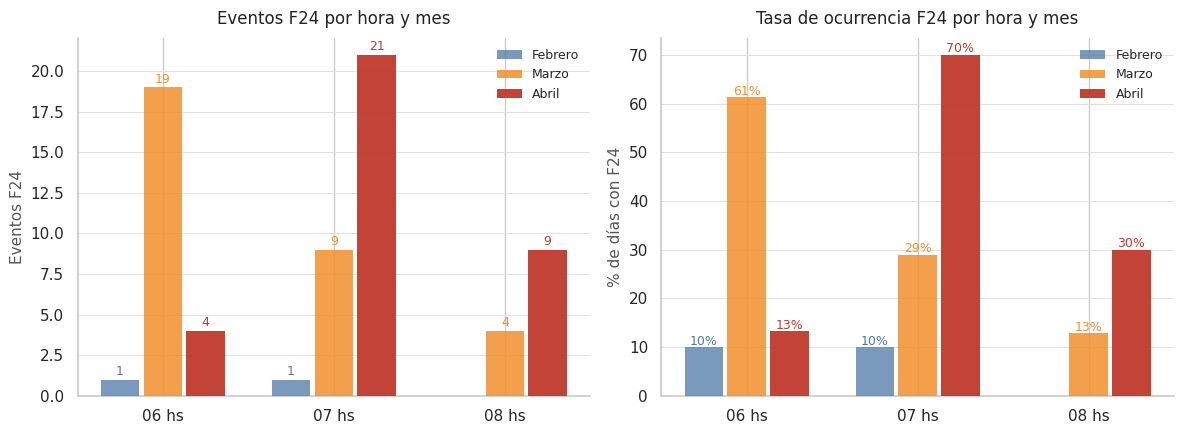

In [ ]:
# ─────────────────────────────────────────────
# F24 — corrimiento horario de F24
# por mes: febrero → marzo → abril
# ─────────────────────────────────────────────

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

BASE_COLOR = '#4e79a7'
ORANGE     = '#f28e2b'
RED        = '#c0392b'

# ── Preparación ──────────────────────────────
f24_ventana['mes']     = f24_ventana['time'].dt.month
f24_ventana['mes_str'] = f24_ventana['time'].dt.strftime('%B')
mes_orden = {2: 'Febrero', 3: 'Marzo', 4: 'Abril'}
f24_ventana['mes_nombre'] = f24_ventana['mes'].map(mes_orden)

# ── 1. Distribución hora × mes ────────────────
pivot = (
    f24_ventana[f24_ventana['f24'] == 1]
    .groupby(['mes_nombre', 'hora_int'])
    .size()
    .unstack(fill_value=0)
    .reindex(['Febrero', 'Marzo', 'Abril'])
)

print("═" * 50)
print("EVENTOS F24 POR HORA Y MES")
print("═" * 50)
print(pivot.to_string())
print()

# ── 2. Hora promedio de ocurrencia por mes ────
hora_prom = (
    f24_ventana[f24_ventana['f24'] == 1]
    .groupby('mes_nombre')['hora_int']
    .agg(['mean', 'median', 'std', 'count'])
    .reindex(['Febrero', 'Marzo', 'Abril'])
    .round(2)
)
print("─" * 50)
print("HORA PROMEDIO DE OCURRENCIA F24 POR MES")
print("─" * 50)
print(hora_prom.to_string())
print()

# ── 3. % de F24 por hora dentro de cada mes ──
pct_mes_hora = (
    f24_ventana
    .groupby(['mes_nombre', 'hora_int'])['f24']
    .agg(total='count', con_f24='sum')
    .assign(pct=lambda x: (x['con_f24'] / x['total'] * 100).round(1))
    .reindex(['Febrero', 'Marzo', 'Abril'], level=0)
)
print("─" * 50)
print("% DE HORAS CON F24 POR MES Y HORA")
print("─" * 50)
print(pct_mes_hora.to_string())
print()

# ═══════════════════════════════════════════════
# GRÁFICA — Corrimiento horario por mes
# ═══════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.patch.set_facecolor('white')

meses    = ['Febrero', 'Marzo', 'Abril']
colores  = [BASE_COLOR, ORANGE, RED]
horas    = [6, 7, 8]

# ── Panel 1: conteo de eventos por hora y mes ─
ax1 = axes[0]
ax1.set_facecolor('white')
x     = np.arange(len(horas))
width = 0.25

for i, (mes, col) in enumerate(zip(meses, colores)):
    if mes in pivot.index:
        vals = [pivot.loc[mes, h] if h in pivot.columns else 0 for h in horas]
        bars = ax1.bar(x + i*width, vals, width=width*0.9,
                      color=col, alpha=0.75 + i*0.1,
                      label=mes, linewidth=0, zorder=3)
        for bar, v in zip(bars, vals):
            if v > 0:
                ax1.text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + 0.3, str(v),
                         ha='center', fontsize=9, color=col)

ax1.set_xticks(x + width)
ax1.set_xticklabels([f'{h:02d} hs' for h in horas], fontsize=11)
ax1.set_ylabel('Eventos F24', fontsize=11, color='#555555')
ax1.set_title('Eventos F24 por hora y mes', fontsize=12,
              fontweight='normal', color='#222222', pad=10)
ax1.legend(fontsize=9, frameon=False)
ax1.grid(axis='y', color='#e0e0e0', linewidth=0.7, zorder=0)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#cccccc')

# ── Panel 2: % de ocurrencia por hora y mes ───
ax2 = axes[1]
ax2.set_facecolor('white')

for i, (mes, col) in enumerate(zip(meses, colores)):
    if mes in pct_mes_hora.index.get_level_values(0):
        sub = pct_mes_hora.loc[mes]
        pcts = [sub.loc[h, 'pct'] if h in sub.index else 0 for h in horas]
        bars = ax2.bar(x + i*width, pcts, width=width*0.9,
                      color=col, alpha=0.75 + i*0.1,
                      label=mes, linewidth=0, zorder=3)
        for bar, v in zip(bars, pcts):
            if v > 0:
                ax2.text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + 0.5, f'{v:.0f}%',
                         ha='center', fontsize=9, color=col)

ax2.set_xticks(x + width)
ax2.set_xticklabels([f'{h:02d} hs' for h in horas], fontsize=11)
ax2.set_ylabel('% de días con F24', fontsize=11, color='#555555')
ax2.set_title('Tasa de ocurrencia F24 por hora y mes', fontsize=12,
              fontweight='normal', color='#222222', pad=10)
ax2.legend(fontsize=9, frameon=False)
ax2.grid(axis='y', color='#e0e0e0', linewidth=0.7, zorder=0)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#cccccc')

plt.tight_layout()
plt.show()


In [ ]:
print(df_horarios_sol.head(5).to_string())
print()
print(df_horarios_sol['salida'].dtype)
print(df_horarios_sol['salida'].iloc[0])

       fecha              salida              puesta
0 2026-01-01 2026-01-01 05:49:00 2026-01-01 20:06:00
1 2026-01-02 2026-01-02 05:49:00 2026-01-02 20:06:00
2 2026-01-03 2026-01-03 05:50:00 2026-01-03 20:06:00
3 2026-01-04 2026-01-04 05:51:00 2026-01-04 20:06:00
4 2026-01-05 2026-01-05 05:52:00 2026-01-05 20:06:00

datetime64[ns]
2026-01-01 05:49:00


##### Distribucion minutos desde amanecer

═══════════════════════════════════════════════════════
VERIFICACIÓN — join con horarios de sol
═══════════════════════════════════════════════════════
Filas sin match (salida NaT): 0

Muestra de eventos F24 con tiempo relativo al amanecer:
               time              salida  min_desde_amanecer  hora_int mes_nombre
2026-02-28 06:00:00 2026-02-28 06:42:00               -42.0         6    Febrero
2026-02-28 07:00:00 2026-02-28 06:42:00                18.0         7    Febrero
2026-03-01 06:00:00 2026-03-01 06:42:00               -42.0         6      Marzo
2026-03-02 06:00:00 2026-03-02 06:43:00               -43.0         6      Marzo
2026-03-04 06:00:00 2026-03-04 06:45:00               -45.0         6      Marzo
2026-03-05 06:00:00 2026-03-05 06:46:00               -46.0         6      Marzo
2026-03-08 06:00:00 2026-03-08 06:48:00               -48.0         6      Marzo
2026-03-11 06:00:00 2026-03-11 06:50:00               -50.0         6      Marzo
2026-03-13 06:00:00 2026-03-13

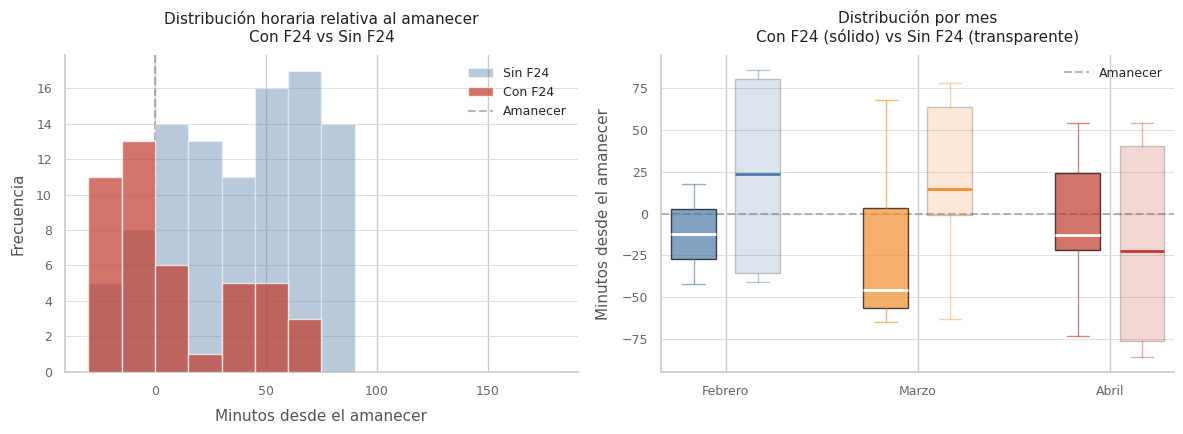

In [ ]:
# ─────────────────────────────────────────────
# F24 — Normalizo hora de eventos relativa al amanecer
# usando df_horarios_sol
# ─────────────────────────────────────────────

BASE_COLOR = '#4e79a7'
ORANGE     = '#f28e2b'
RED        = '#c0392b'

# ── Join f24_ventana con horarios de sol ──────
# clave: fecha del día (sin hora)
f24_ventana['fecha_dia'] = f24_ventana['time'].dt.normalize()
sol = df_horarios_sol[['fecha', 'salida']].copy()
sol['fecha_dia'] = pd.to_datetime(sol['fecha']).dt.normalize()

f24_ventana = f24_ventana.merge(
    sol[['fecha_dia', 'salida']],
    on='fecha_dia',
    how='left'
)

# ── Calcular minutos desde el amanecer ────────
# positivo = después del amanecer
# negativo = antes del amanecer (no debería ocurrir pero por si acaso)
f24_ventana['min_desde_amanecer'] = (
    f24_ventana['time'] - f24_ventana['salida']
).dt.total_seconds() / 60

f24_ventana['hs_desde_amanecer'] = f24_ventana['min_desde_amanecer'] / 60

# ── Verificación ──────────────────────────────
print("═" * 55)
print("VERIFICACIÓN — join con horarios de sol")
print("═" * 55)
print(f"Filas sin match (salida NaT): {f24_ventana['salida'].isna().sum()}")
print()

# muestra de eventos con F24
muestra = (
    f24_ventana[f24_ventana['f24'] == 1]
    [['time', 'salida', 'min_desde_amanecer', 'hora_int', 'mes_nombre']]
    .head(10)
)
print("Muestra de eventos F24 con tiempo relativo al amanecer:")
print(muestra.to_string(index=False))
print()

# ── Estadísticos por mes ──────────────────────
print("─" * 55)
print("MINUTOS DESDE AMANECER — eventos F24 por mes")
print("─" * 55)
stats_sol = (
    f24_ventana[f24_ventana['f24'] == 1]
    .groupby('mes_nombre')['min_desde_amanecer']
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
    .reindex(['Febrero', 'Marzo', 'Abril'])
    .round(1)
)
print(stats_sol.to_string())
print()

# ── Estadísticos dataset completo (con y sin F24)
print("─" * 55)
print("MINUTOS DESDE AMANECER — con F24 vs sin F24")
print("─" * 55)
comp = (
    f24_ventana
    .groupby('f24')['min_desde_amanecer']
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
    .round(1)
)
comp.index = ['Sin F24', 'Con F24']
print(comp.to_string())
print()

# ═══════════════════════════════════════════════
# GRÁFICA — Distribución de minutos desde amanecer
# con F24 vs sin F24, separado por mes
# ═══════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.patch.set_facecolor('white')

# ── Panel 1: histograma con F24 vs sin F24 ────
ax1 = axes[0]
ax1.set_facecolor('white')

bins = np.arange(-30, 181, 15)  # de -30 a 180 min, bins de 15 min

ax1.hist(f24_ventana[f24_ventana['f24'] == 0]['min_desde_amanecer'],
         bins=bins, color=BASE_COLOR, alpha=0.4,
         label='Sin F24', zorder=3)
ax1.hist(f24_ventana[f24_ventana['f24'] == 1]['min_desde_amanecer'],
         bins=bins, color=RED, alpha=0.7,
         label='Con F24', zorder=4)

ax1.axvline(0, color='#888888', lw=1.5, linestyle='--', alpha=0.6,
            label='Amanecer')
ax1.set_xlabel('Minutos desde el amanecer', fontsize=11,
               color='#555555', labelpad=8)
ax1.set_ylabel('Frecuencia', fontsize=11, color='#555555', labelpad=8)
ax1.set_title('Distribución horaria relativa al amanecer\nCon F24 vs Sin F24',
              fontsize=11, fontweight='normal', color='#222222', pad=10)
ax1.legend(fontsize=9, frameon=False)
ax1.grid(axis='y', color='#e0e0e0', linewidth=0.7, zorder=0)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#cccccc')
ax1.tick_params(colors='#666666', labelsize=9)

# ── Panel 2: boxplot por mes ──────────────────
ax2 = axes[1]
ax2.set_facecolor('white')

meses   = ['Febrero', 'Marzo', 'Abril']
colores = [BASE_COLOR, ORANGE, RED]

for i, (mes, col) in enumerate(zip(meses, colores)):
    sub_f24    = f24_ventana[(f24_ventana['mes_nombre'] == mes) &
                              (f24_ventana['f24'] == 1)]['min_desde_amanecer']
    sub_no_f24 = f24_ventana[(f24_ventana['mes_nombre'] == mes) &
                              (f24_ventana['f24'] == 0)]['min_desde_amanecer']

    pos_f24    = i * 3 + 1
    pos_no_f24 = i * 3 + 2

    bp1 = ax2.boxplot(sub_f24.dropna(), positions=[pos_f24],
                      widths=0.7, patch_artist=True,
                      boxprops=dict(facecolor=col, alpha=0.7),
                      medianprops=dict(color='white', lw=2),
                      whiskerprops=dict(color=col, alpha=0.6),
                      capprops=dict(color=col, alpha=0.6),
                      flierprops=dict(marker='o', markerfacecolor=col,
                                      markersize=4, alpha=0.4),
                      zorder=3)
    bp2 = ax2.boxplot(sub_no_f24.dropna(), positions=[pos_no_f24],
                      widths=0.7, patch_artist=True,
                      boxprops=dict(facecolor=col, alpha=0.2),
                      medianprops=dict(color=col, lw=2),
                      whiskerprops=dict(color=col, alpha=0.4),
                      capprops=dict(color=col, alpha=0.4),
                      flierprops=dict(marker='o', markerfacecolor=col,
                                      markersize=4, alpha=0.3),
                      zorder=3)

ax2.axhline(0, color='#888888', lw=1.5, linestyle='--', alpha=0.6,
            label='Amanecer')

# etiquetas eje X
tick_pos    = [i*3 + 1.5 for i in range(len(meses))]
tick_labels = meses
ax2.set_xticks(tick_pos)
ax2.set_xticklabels(tick_labels, fontsize=10, color='#555555')
ax2.set_ylabel('Minutos desde el amanecer', fontsize=11,
               color='#555555', labelpad=8)
ax2.set_title('Distribución por mes\nCon F24 (sólido) vs Sin F24 (transparente)',
              fontsize=11, fontweight='normal', color='#222222', pad=10)
ax2.grid(axis='y', color='#e0e0e0', linewidth=0.7, zorder=0)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#cccccc')
ax2.tick_params(colors='#666666', labelsize=9)
ax2.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()


In [ ]:
# hora real de inicio por evento horario (primer inversor en abrir)
hora_real = (
    f24
    .groupby('fecha_referencia_abierta')['hora_abierta']
    .min()
    .reset_index()
    .rename(columns={'hora_abierta': 'hora_real_inicio'})
)

# agregar hora real a f24_ventana sin modificar columnas existentes
f24_ventana = f24_ventana.merge(
    hora_real,
    left_on='time',
    right_on='fecha_referencia_abierta',
    how='left'
)

# para filas sin F24 no hay hora_real_inicio — usar time como fallback
f24_ventana['hora_real_inicio'] = f24_ventana['hora_real_inicio'].fillna(
    f24_ventana['time']
)

# recalcular min_desde_amanecer con hora real
f24_ventana['min_desde_amanecer'] = (
    f24_ventana['hora_real_inicio'] - f24_ventana['salida']
).dt.total_seconds() / 60

# verificación rápida
print("Rango min_desde_amanecer corregido:")
print(f"  Con F24:  min={f24_ventana[f24_ventana['f24']==1]['min_desde_amanecer'].min():.0f}  "
      f"max={f24_ventana[f24_ventana['f24']==1]['min_desde_amanecer'].max():.0f}  "
      f"mediana={f24_ventana[f24_ventana['f24']==1]['min_desde_amanecer'].median():.0f}")
print(f"  Sin F24:  min={f24_ventana[f24_ventana['f24']==0]['min_desde_amanecer'].min():.0f}  "
      f"max={f24_ventana[f24_ventana['f24']==0]['min_desde_amanecer'].max():.0f}  "
      f"mediana={f24_ventana[f24_ventana['f24']==0]['min_desde_amanecer'].median():.0f}")

Rango min_desde_amanecer corregido:
  Con F24:  min=-15  max=84  mediana=-7
  Sin F24:  min=-86  max=86  mediana=14


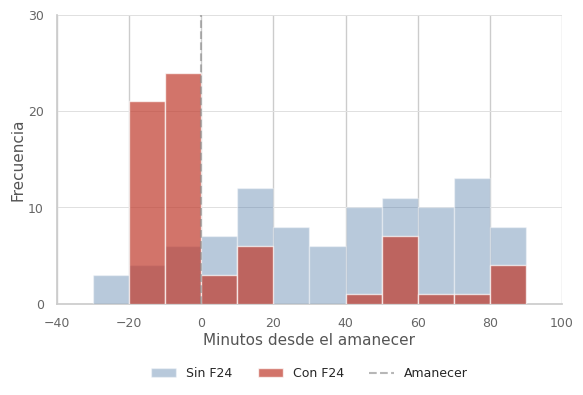

In [ ]:
# ═══════════════════════════════════════════════
# GRÁFICA — Distribución de minutos desde amanecer
# con F24 vs sin F24 (Panel Simple Ajustado)
# ═══════════════════════════════════════════════

# Configuración de figura única
fig, ax = plt.subplots(figsize=(6, 4)) # Aumentamos ligeramente el alto para dar espacio a la leyenda inferior
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Definición de contenedores (bins)
#bins = np.arange(-30, 181, 15)  # de -30 a 180 min, bins de 15 min
bins = np.arange(-30, 100, 10)  # bins de 10 min, de -30 a 100
# Histograma Sin F24
ax.hist(f24_ventana[f24_ventana['f24'] == 0]['min_desde_amanecer'],
        bins=bins, color=BASE_COLOR, alpha=0.4,
        label='Sin F24', zorder=3)

# Histograma Con F24
ax.hist(f24_ventana[f24_ventana['f24'] == 1]['min_desde_amanecer'],
        bins=bins, color=RED, alpha=0.7,
        label='Con F24', zorder=4)

# Línea de referencia del amanecer
ax.axvline(0, color='#888888', lw=1.5, linestyle='--', alpha=0.6,
           label='Amanecer', zorder=5)

# Ejes y formato de etiquetas
ax.set_xlabel('Minutos desde el amanecer', fontsize=11, color='#555555', labelpad=2)
ax.set_ylabel('Frecuencia', fontsize=11, color='#555555', labelpad=2)
#ax.set_title('Distribución horaria relativa al amanecer\nCon F24 vs Sin F24',
#             fontsize=12, fontweight='normal', color='#222222', pad=10)

# AJUSTE 1: Forzar el eje X para que llegue exactamente a 100
ax.set_xlim(-40, 100)
ax.set_yticks(range(0, 101, 10))
ax.set_ylim(0,30)
ax.set_yticks(range(0, 31, 10))
# AJUSTE 2: Mover la leyenda ABAJO del eje X, centrada y en 3 columnas
# bbox_to_anchor=(0.5, -0.2) posiciona la leyenda debajo del gráfico
ax.legend(fontsize=9, frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3)

# Grilla sutil posterior
ax.grid(axis='y', color='#e0e0e0', linewidth=0.7, zorder=0)

# Limpieza estándar de bordes (spines)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')
ax.tick_params(colors='#666666', labelsize=9)

# Ajuste controlado de márgenes para que no se corte la leyenda inferior
plt.tight_layout()
fig.subplots_adjust(bottom=0.22)

plt.show()

Son horas unicas, quedaros afuera los eventos unicos a las 9,10 y 11

In [ ]:
print(f"Filas en f24_ventana con F24:  {(f24_ventana['f24']==1).sum()}")
print(f"Filas en f24_ventana sin F24:  {(f24_ventana['f24']==0).sum()}")
print(f"Suma frecuencias histograma Con F24 debería ser: 68")

# verificar que el histograma suma bien
con_f24_vals = f24_ventana[f24_ventana['f24']==1]['min_desde_amanecer'].dropna()
print(f"Valores Con F24 en rango del histograma: {len(con_f24_vals)}")

Filas en f24_ventana con F24:  68
Filas en f24_ventana sin F24:  145
Suma frecuencias histograma Con F24 debería ser: 68
Valores Con F24 en rango del histograma: 68


In [ ]:
print(f"Total filas f24_ventana: {len(f24_ventana)}")
print(f"Con F24:  {(f24_ventana['f24']==1).sum()}")
print(f"Sin F24:  {(f24_ventana['f24']==0).sum()}")

Total filas f24_ventana: 213
Con F24:  68
Sin F24:  145


In [ ]:
# ─────────────────────────────────────────────
# F24 — Reformulación: día como unidad
# Para cada día del período:
#   - ¿Hubo F24 en ventana 06-08 hs?
#   - Si sí: min_desde_amanecer del PRIMER evento
#   - Si no: min_desde_amanecer del arranque del día
# ─────────────────────────────────────────────

BASE_COLOR = '#4e79a7'
RED        = '#c0392b'
ORANGE     = '#f28e2b'

# ── Preparación ──────────────────────────────
# fecha del día para f24 (slice de F24 con hora real)
f24['fecha_dia'] = f24['fecha_referencia_abierta'].dt.normalize()
f24['hora_int']  = f24['fecha_referencia_abierta'].dt.hour

# ── Días con F24 en ventana 06-08 hs ─────────
# toma el PRIMER evento del día (hora_abierta mínima)
f24_por_dia = (
    f24[f24['hora_int'].isin([6, 7, 8])]
    .groupby('fecha_dia')
    .agg(
        hora_primer_evento=('hora_abierta', 'min'),
        n_eventos=('inversor', 'count'),
        horas_afectadas=('hora_int', lambda x: sorted(x.unique().tolist())),
        duracion_max=('evento_minutos', 'max')
    )
    .reset_index()
)
f24_por_dia['f24'] = 1



In [ ]:
print(f"Fecha inicio: {f24['fecha_dia'].min()}")
print(f"Fecha fin:    {f24['fecha_dia'].max()}")
print(f"Días únicos en f24: {f24['fecha_dia'].nunique()}")
print(f"Días en todos_los_dias: {len(todos_los_dias)}")
print(f"Días con F24 en 06-08 hs: {len(f24_por_dia)}")
print(f"Días sin F24: {len(dias_sin_f24)}")

Fecha inicio: 2026-02-28 00:00:00
Fecha fin:    2026-04-29 00:00:00
Días únicos en f24: 42
Días en todos_los_dias: 71
Días con F24 en 06-08 hs: 42
Días sin F24: 29


In [ ]:
# verificar contra df_clima que tiene el período completo
print(f"Período df_clima: {df_clima['time'].min()} → {df_clima['time'].max()}")
print(f"Total días df_clima: {df_clima['time'].dt.normalize().nunique()}")


Período df_clima: 2026-02-19 00:00:00 → 2026-04-30 23:00:00
Total días df_clima: 71


In [ ]:
# ── Revisar eventos con min_desde_amanecer extremos ──
print("═" * 65)
print("EVENTOS F24 CON min_desde_amanecer < -60 min")
print("═" * 65)
outliers = (
    f24_ventana[
        (f24_ventana['f24'] == 1) &
        (f24_ventana['min_desde_amanecer'] < -60)
    ]
    [['time', 'salida', 'min_desde_amanecer', 'hora_int', 'mes_nombre']]
    .sort_values('min_desde_amanecer')
)
print(outliers.to_string(index=False))
print(f"\nTotal: {len(outliers)} eventos")

print()
print("═" * 65)
print("EVENTOS SIN F24 CON min_desde_amanecer < -60 min")
print("═" * 65)
outliers_no = (
    f24_ventana[
        (f24_ventana['f24'] == 0) &
        (f24_ventana['min_desde_amanecer'] < -60)
    ]
    [['time', 'salida', 'min_desde_amanecer', 'hora_int', 'mes_nombre']]
    .sort_values('min_desde_amanecer')
)
print(outliers_no.to_string(index=False))
print(f"\nTotal: {len(outliers_no)} eventos")

═════════════════════════════════════════════════════════════════
EVENTOS F24 CON min_desde_amanecer < -60 min
═════════════════════════════════════════════════════════════════
Empty DataFrame
Columns: [time, salida, min_desde_amanecer, hora_int, mes_nombre]
Index: []

Total: 0 eventos

═════════════════════════════════════════════════════════════════
EVENTOS SIN F24 CON min_desde_amanecer < -60 min
═════════════════════════════════════════════════════════════════
               time              salida  min_desde_amanecer  hora_int mes_nombre
2026-04-29 06:00:00 2026-04-29 07:26:00               -86.0         6      Abril
2026-04-30 06:00:00 2026-04-30 07:26:00               -86.0         6      Abril
2026-04-28 06:00:00 2026-04-28 07:25:00               -85.0         6      Abril
2026-04-27 06:00:00 2026-04-27 07:24:00               -84.0         6      Abril
2026-04-25 06:00:00 2026-04-25 07:23:00               -83.0         6      Abril
2026-04-26 06:00:00 2026-04-26 07:23:00      

In [ ]:
df_bitacora_alertas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1191 entries, 0 to 1190
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   fecha                     1191 non-null   object        
 1   nombre_de_alerta          1191 non-null   object        
 2   estado                    1191 non-null   object        
 3   sn                        1191 non-null   int64         
 4   hora_abierta              1191 non-null   datetime64[ns]
 5   hora_cerrada              1190 non-null   datetime64[ns]
 6   inversor                  1191 non-null   object        
 7   fecha_referencia_abierta  1191 non-null   datetime64[ns]
 8   fecha_referencia_cerrada  1190 non-null   datetime64[ns]
 9   evento_minutos            1191 non-null   int64         
dtypes: datetime64[ns](4), int64(2), object(4)
memory usage: 93.2+ KB


In [ ]:
# ─────────────────────────────────────────────
# F24 — Correlación min_desde_amanecer vs f24
# ─────────────────────────────────────────────

BASE_COLOR = '#4e79a7'
RED        = '#c0392b'

# ── Correlación de Pearson ────────────────────
df_valid = f24_ventana[['f24', 'min_desde_amanecer',
                         'riesgo_condensacion', 'rhum']].dropna()

r, p = stats.pearsonr(df_valid['min_desde_amanecer'], df_valid['f24'])
print("═" * 50)
print("CORRELACIÓN min_desde_amanecer vs f24")
print("═" * 50)
print(f"Pearson r:   {r:.4f}")
print(f"p-valor:     {p:.2e}")
print(f"r²:          {r**2:.4f}  ({r**2*100:.1f}% varianza explicada)")
print()

# ── Comparativa con predictores climáticos ───
print("─" * 50)
print("COMPARATIVA vs predictores climáticos")
print("─" * 50)
vars_comp = ['min_desde_amanecer', 'riesgo_condensacion', 'rhum']
for v in vars_comp:
    r_v, p_v = stats.pearsonr(df_valid[v], df_valid['f24'])
    print(f"{v:30} r={r_v:+.4f}  r²={r_v**2*100:.1f}%  p={p_v:.2e}")
print()

# ── Punto de corte operativo ──
# a qué valor de min_desde_amanecer la tasa de F24 es mayor
bins = pd.cut(df_valid['min_desde_amanecer'],
              bins=[-90, -60, -45, -30, -15, 0, 15, 30, 60, 90])
tasa = df_valid.groupby(bins)['f24'].agg(['mean', 'count']).round(3)
tasa.columns = ['tasa_f24', 'n']
tasa['pct_f24'] = (tasa['tasa_f24'] * 100).round(1)
print("─" * 50)
print("TASA DE F24 POR RANGO DE min_desde_amanecer")
print("─" * 50)
print(tasa.to_string())

══════════════════════════════════════════════════
CORRELACIÓN min_desde_amanecer vs f24
══════════════════════════════════════════════════
Pearson r:   0.0273
p-valor:     6.92e-01
r²:          0.0007  (0.1% varianza explicada)

──────────────────────────────────────────────────
COMPARATIVA vs predictores climáticos
──────────────────────────────────────────────────
min_desde_amanecer             r=+0.0273  r²=0.1%  p=6.92e-01
riesgo_condensacion            r=-0.0779  r²=0.6%  p=2.58e-01
rhum                           r=+0.0687  r²=0.5%  p=3.18e-01

──────────────────────────────────────────────────
TASA DE F24 POR RANGO DE min_desde_amanecer
──────────────────────────────────────────────────
                    tasa_f24   n  pct_f24
min_desde_amanecer                       
(-90, -60]             0.000  28      0.0
(-60, -45]             0.000   9      0.0
(-45, -30]             0.000  10      0.0
(-30, -15]             0.250   8     25.0
(-15, 0]               0.843  51     84.3
(0,

/tmp/ipykernel_27973/2361028160.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa = df_valid.groupby(bins)['f24'].agg(['mean', 'count']).round(3)


In [ ]:
# ─────────────────────────────────────────────
# F24 — Correlación min_desde_amanecer vs f24
# ─────────────────────────────────────────────

BASE_COLOR = '#4e79a7'
RED        = '#c0392b'

# ── Correlación de Pearson ────────────────────
df_valid = f24_ventana[['f24', 'min_desde_amanecer',
                         'riesgo_condensacion', 'rhum']].dropna()

r, p = stats.pearsonr(df_valid['min_desde_amanecer'], df_valid['f24'])
print("═" * 50)
print("CORRELACIÓN min_desde_amanecer vs f24")
print("═" * 50)
print(f"Pearson r:   {r:.4f}")
print(f"p-valor:     {p:.2e}")
print(f"r²:          {r**2:.4f}  ({r**2*100:.1f}% varianza explicada)")
print()

# ── Comparativa con predictores climáticos ───
print("─" * 50)
print("COMPARATIVA vs predictores climáticos")
print("─" * 50)
vars_comp = ['min_desde_amanecer', 'riesgo_condensacion', 'rhum']
for v in vars_comp:
    r_v, p_v = stats.pearsonr(df_valid[v], df_valid['f24'])
    print(f"{v:30} r={r_v:+.4f}  r²={r_v**2*100:.1f}%  p={p_v:.2e}")
print()

# ── Punto de corte operativo ──────────────────
# a qué valor de min_desde_amanecer la tasa de F24 es mayor
bins = pd.cut(df_valid['min_desde_amanecer'],
              bins=[-90, -60, -45, -30, -15, 0, 15, 30, 60, 90])
tasa = df_valid.groupby(bins)['f24'].agg(['mean', 'count']).round(3)
tasa.columns = ['tasa_f24', 'n']
tasa['pct_f24'] = (tasa['tasa_f24'] * 100).round(1)
print("─" * 50)
print("TASA DE F24 POR RANGO DE min_desde_amanecer")
print("─" * 50)
print(tasa.to_string())

══════════════════════════════════════════════════
CORRELACIÓN min_desde_amanecer vs f24
══════════════════════════════════════════════════
Pearson r:   0.0273
p-valor:     6.92e-01
r²:          0.0007  (0.1% varianza explicada)

──────────────────────────────────────────────────
COMPARATIVA vs predictores climáticos
──────────────────────────────────────────────────
min_desde_amanecer             r=+0.0273  r²=0.1%  p=6.92e-01
riesgo_condensacion            r=-0.0779  r²=0.6%  p=2.58e-01
rhum                           r=+0.0687  r²=0.5%  p=3.18e-01

──────────────────────────────────────────────────
TASA DE F24 POR RANGO DE min_desde_amanecer
──────────────────────────────────────────────────
                    tasa_f24   n  pct_f24
min_desde_amanecer                       
(-90, -60]             0.000  28      0.0
(-60, -45]             0.000   9      0.0
(-45, -30]             0.000  10      0.0
(-30, -15]             0.250   8     25.0
(-15, 0]               0.843  51     84.3
(0,

/tmp/ipykernel_27973/3619824845.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa = df_valid.groupby(bins)['f24'].agg(['mean', 'count']).round(3)


In [ ]:
# ─────────────────────────────────────────────
# F24 — scatter nivel + tendencia
# riesgo_condensacion para W = 1 a 6 horas
# Color: rojo = con F24, azul = sin F24
# Fuente: f24_ventana + df_clima
# ─────────────────────────────────────────────

BASE_COLOR = '#4e79a7'
RED        = '#c0392b'

# ── Preparación ──────────────────────────────
# f24_ventana ya tiene f24 binario y hora filtrada 06-08 hs
# necesitamos join con df_clima para obtener las horas previas

clima_idx = df_clima.set_index('time').sort_index()

VENTANAS = list(range(1, 7))
VAR      = 'riesgo_condensacion'


##### Condiciones previas

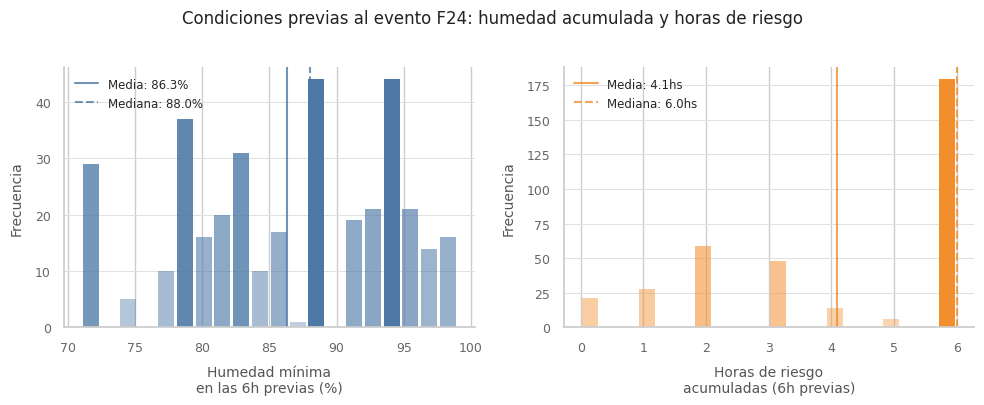

In [ ]:
# ═══════════════════════════════════════════════
# Distribución de predictores
# f2x_rhum_min_6h y f2x_horas_riesgo_6h
# ═══════════════════════════════════════════════
fig2, axes = plt.subplots(1, 2, figsize=(10, 4))
fig2.patch.set_facecolor('white')

vars_plot = [
    dict(col='f2x_rhum_min_6h',
         label='Humedad mínima\nen las 6h previas (%)',
         color=BASE_COLOR,
         unit='%'),
    dict(col='f2x_horas_riesgo_6h',
         label='Horas de riesgo\nacumuladas (6h previas)',
         color=ORANGE,
         unit='hs'),
]

for ax, v in zip(axes, vars_plot):
    data = f24[v['col']].dropna()
    cr, cg, cb_ = tuple(int(v['color'].lstrip('#')[i:i+2], 16)/255 for i in (0,2,4))

    # histograma
    n_bins = 20
    counts, edges = np.histogram(data, bins=n_bins)
    max_c = counts.max()
    bin_centers = (edges[:-1] + edges[1:]) / 2

    bar_colors = [(cr, cg, cb_, 0.35 + 0.65*(c/max_c)) for c in counts]
    ax.bar(bin_centers, counts, width=(edges[1]-edges[0])*0.85,
           color=bar_colors, linewidth=0)

    # líneas de estadísticos
    for stat, ls, lbl in [
        (data.mean(),   '-',  f'Media: {data.mean():.1f}{v["unit"]}'),
        (data.median(), '--', f'Mediana: {data.median():.1f}{v["unit"]}'),
    ]:
        ax.axvline(stat, color=v['color'], lw=1.5, linestyle=ls,
                   alpha=0.8, label=lbl)

    ax.set_xlabel(v['label'], fontsize=10, color='#555555', labelpad=8)
    ax.set_ylabel('Frecuencia', fontsize=10, color='#555555', labelpad=8)
    ax.tick_params(colors='#666666', labelsize=9)
    ax.grid(axis='y', color='#e0e0e0', linewidth=0.7)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#cccccc')
    ax.legend(fontsize=8.5, frameon=False)
    ax.set_facecolor('white')

fig2.suptitle('Condiciones previas al evento F24: humedad acumulada y horas de riesgo',
              fontsize=12, fontweight='normal', color='#222222', y=1.01)

plt.tight_layout()
plt.show()

##### Correlaciones

##### Distribucion temporal

/tmp/ipykernel_27973/1190400930.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


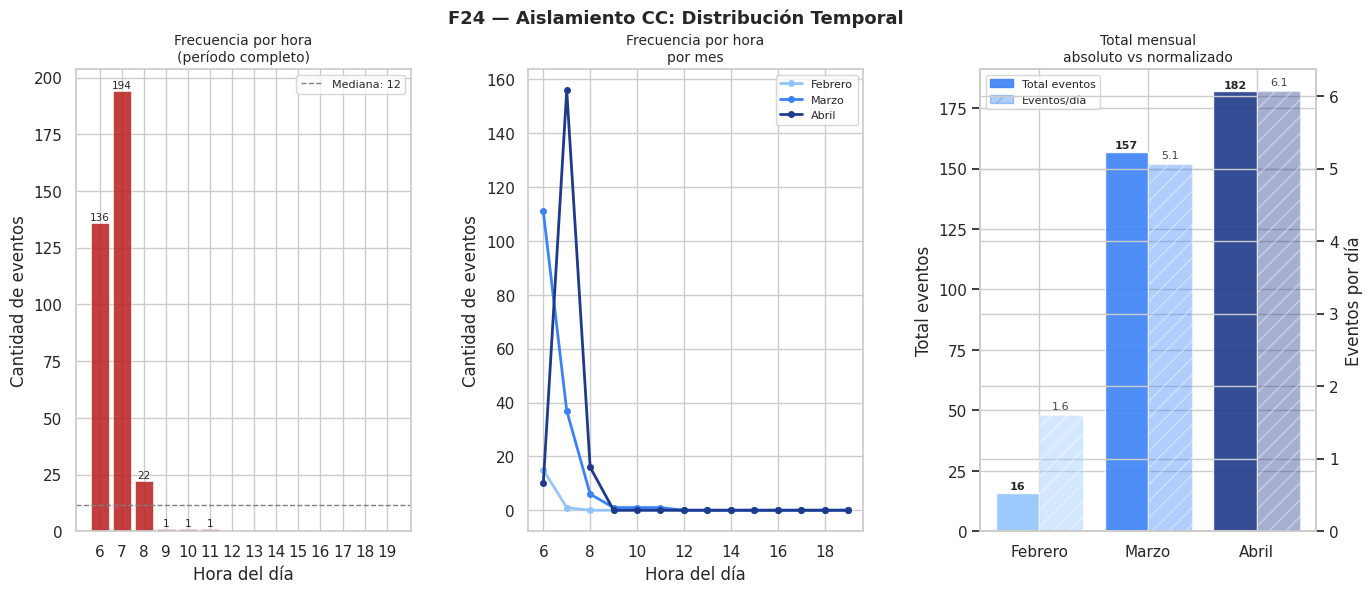


RESUMEN F24 — DISTRIBUCIÓN TEMPORAL

Total eventos F24: 355

Por mes:
  Febrero: 16 eventos (1.6/día)
  Marzo: 157 eventos (5.1/día)
  Abril: 182 eventos (6.1/día)

Por hora (top 5):
hora
7     194
6     136
8      22
9       1
10      1
dtype: int64

Ventana 6-8hs: 0 eventos (0.0%)
Ventana 12-16hs: 0 eventos (0.0%)


In [ ]:
# Distribución temporal: hora del día y mes

sns.set_theme(style="whitegrid")

# ─────────────────────────────────────────────
# PREPARACIÓN
# ─────────────────────────────────────────────
f24 = df_fallas_clima[df_fallas_clima['nombre_de_alerta'] == 'Fallo_Aislam_CC F24'].copy()
f24['hora']   = f24['hora_abierta'].dt.hour
f24['mes_str'] = f24['mes'].astype(str)  # '2026-02', '2026-03', '2026-04'

COLOR_F24   = '#b91c1c'
COLORES_MES = {
    '2026-02': '#93c5fd',
    '2026-03': '#3b82f6',
    '2026-04': '#1e3a8a'
}
LABELS_MES = {
    '2026-02': 'Febrero',
    '2026-03': 'Marzo',
    '2026-04': 'Abril'
}

# Total eventos y días del período por mes (para normalizar)
DIAS_MES = {'2026-02': 10, '2026-03': 31, '2026-04': 30}  # ajustar si es necesario

# ─────────────────────────────────────────────
# FIGURA: DISTRIBUCIÓN TEMPORAL F24
# 3 subplots: hora global | hora por mes | total por mes normalizado
# ─────────────────────────────────────────────

fig = plt.figure(figsize=(16, 6))
fig.suptitle('F24 — Aislamiento CC: Distribución Temporal',
             fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)


# ── SUBPLOT 1: Frecuencia por hora del día (toda la flota) ──────────────────
ax1 = fig.add_subplot(gs[0])

freq_hora = f24.groupby('hora').size().reindex(range(6, 20), fill_value=0)

bars = ax1.bar(freq_hora.index, freq_hora.values,
               color=COLOR_F24, alpha=0.85, edgecolor='white', linewidth=0.5)

# Anotar valor encima de cada barra
for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                 str(int(h)), ha='center', va='bottom', fontsize=7.5)

# Línea de mediana horaria como referencia
mediana_hora = freq_hora[freq_hora > 0].median()
ax1.axhline(mediana_hora, color='gray', linestyle='--', linewidth=1,
            label=f'Mediana: {mediana_hora:.0f}')

ax1.set_xlabel('Hora del día')
ax1.set_ylabel('Cantidad de eventos')
ax1.set_title('Frecuencia por hora\n(período completo)', fontsize=10)
ax1.set_xticks(range(6, 20))
ax1.legend(fontsize=8)


# ── SUBPLOT 2: Frecuencia por hora del día, separado por mes ────────────────
ax2 = fig.add_subplot(gs[1])

for mes, color in COLORES_MES.items():
    datos_mes = f24[f24['mes_str'] == mes]
    freq = datos_mes.groupby('hora').size().reindex(range(6, 20), fill_value=0)
    ax2.plot(freq.index, freq.values,
             marker='o', linewidth=2, markersize=4,
             color=color, label=LABELS_MES[mes])

ax2.set_xlabel('Hora del día')
ax2.set_ylabel('Cantidad de eventos')
ax2.set_title('Frecuencia por hora\npor mes', fontsize=10)
ax2.set_xticks(range(6, 20))
ax2.legend(fontsize=8)
ax2.xaxis.set_major_locator(plt.MaxNLocator(integer=True))


# ── SUBPLOT 3: Total mensual absoluto y normalizado por días ────────────────
ax3 = fig.add_subplot(gs[2])

resumen_mes = f24.groupby('mes_str').size().reindex(COLORES_MES.keys(), fill_value=0)
por_dia = {mes: resumen_mes[mes] / DIAS_MES[mes] for mes in COLORES_MES.keys()}

x = np.arange(len(COLORES_MES))
width = 0.4
colores_bars = [COLORES_MES[m] for m in COLORES_MES.keys()]
labels_x = [LABELS_MES[m] for m in COLORES_MES.keys()]

# Barras absolutas
bars_abs = ax3.bar(x - width/2, resumen_mes.values, width,
                   color=colores_bars, alpha=0.9, edgecolor='white',
                   label='Total eventos')

# Eje secundario: eventos por día
ax3b = ax3.twinx()
bars_norm = ax3b.bar(x + width/2, [por_dia[m] for m in COLORES_MES.keys()],
                     width, color=colores_bars, alpha=0.4,
                     edgecolor='white', hatch='//', label='Eventos/día')

# Anotar valores
for bar, val in zip(bars_abs, resumen_mes.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(int(val)), ha='center', va='bottom', fontsize=8, fontweight='bold')

for bar, val in zip(bars_norm, por_dia.values()):
    ax3b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
              f'{val:.1f}', ha='center', va='bottom', fontsize=8, color='#444')

ax3.set_xticks(x)
ax3.set_xticklabels(labels_x)
ax3.set_ylabel('Total eventos')
ax3b.set_ylabel('Eventos por día')
ax3.set_title('Total mensual\nabsoluto vs normalizado', fontsize=10)

# Leyenda combinada
from matplotlib.patches import Patch
patch_abs  = Patch(color='#3b82f6', alpha=0.9, label='Total eventos')
patch_norm = Patch(color='#3b82f6', alpha=0.4, hatch='//', label='Eventos/día')
ax3.legend(handles=[patch_abs, patch_norm], fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# RESUMEN NUMÉRICO
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("RESUMEN F24 — DISTRIBUCIÓN TEMPORAL")
print("="*50)
print(f"\nTotal eventos F24: {len(f24)}")
print(f"\nPor mes:")
for mes in COLORES_MES.keys():
    n = resumen_mes[mes]
    print(f"  {LABELS_MES[mes]}: {n} eventos ({por_dia[mes]:.1f}/día)")

print(f"\nPor hora (top 5):")
print(freq_hora.sort_values(ascending=False).head())

print(f"\nVentana 6-8hs: {freq_hora[6:9].sum()} eventos ({freq_hora[6:9].sum()/len(f24)*100:.1f}%)")
print(f"Ventana 12-16hs: {freq_hora[12:17].sum()} eventos ({freq_hora[12:17].sum()/len(f24)*100:.1f}%)")